# E5: MedVAE-re — mnist

基于 `sSegUnet-medvae-sd-cifar10 copy.ipynb`。训练 **vae / sd(ours) / iwae** 三种算法：保留 medvae 的全部 loss 项 (L1 重建 + LPIPS + GAN 判别器)，仅把 KL 正则项替换为 Score Divergence (Dq+KL_t) 或 IWAE bound。

## lib

In [1]:
# ==========================================
# 1. 导入所有必需的库
# ==========================================
import os
import sys
import math
import numpy as np
from PIL import Image
from collections import namedtuple
import functools

import datasets
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import make_grid
import torchvision.transforms.functional as TF
from einops import rearrange
from tqdm import tqdm
import requests
from datetime import datetime

# ==========================================
# 2. 配置参数
# ==========================================
time_now = datetime.now().strftime("%m-%d_%H-%M")
RUN_FAMILY = "medvae-re"  # medvae 全部 loss 项不变，仅替换 KL 正则项 (vae/sd/iwae)

class Config:
    DATASET_NAME = "mnist"
    DATASET_DIR = "/home/yzm/data_mnist"
    TRAIN_DATASET_DIR = os.path.join(DATASET_DIR, "train")
    TEST_DATASET_DIR = os.path.join(DATASET_DIR, "test")
    VAL_SPLIT_RATIO = 0.1
    SPLIT_SEED = 42
    IMAGE_KEY = "image"
    IMG_SIZE = 28
    IMG_CHANNELS = 1
    BATCH_SIZE = 64
    BASE_LEARNING_RATE = 4.5e-6
    NUM_WORKERS = 4
    MAX_EPOCHS = 10
    SAVE_DIR = f"/home/yzm/ipy/checkpoints/medvae-re-mnist-{time_now}"
    CUDA_NUM = 1

config = Config()
os.makedirs(config.SAVE_DIR, exist_ok=True)

device = torch.device(f"cuda:{config.CUDA_NUM}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Run family: {RUN_FAMILY}")
print(f"Dataset: {config.DATASET_NAME} ({config.IMG_SIZE}x{config.IMG_SIZE}x{config.IMG_CHANNELS})")
print(f"Dataset dir: {config.DATASET_DIR}")
print(f"Validation split: {1 - config.VAL_SPLIT_RATIO:.0%}/{config.VAL_SPLIT_RATIO:.0%} (seed={config.SPLIT_SEED})")
print(f"Save dir: {config.SAVE_DIR}")


Using device: cuda:1
Run family: medvae-re
Dataset: mnist (28x28x1)
Dataset dir: /home/yzm/data_mnist
Validation split: 90%/10% (seed=42)
Save dir: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42


## MedVAE 

In [2]:
# ==========================================
# MedVAE 核心组件: Encoder & Decoder
# ==========================================

def nonlinearity(x):
    """Swish激活函数"""
    return x * torch.sigmoid(x)

def Normalize(in_channels, num_groups=32):
    return nn.GroupNorm(num_groups=num_groups, num_channels=in_channels, eps=1e-6, affine=True)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x)
        q, k, v = rearrange(qkv, "b (qkv heads c) h w -> qkv b heads c (h w)", heads=self.heads, qkv=3)
        k = k.softmax(dim=-1)
        context = torch.einsum("bhdn,bhen->bhde", k, v)
        out = torch.einsum("bhde,bhdn->bhen", context, q)
        out = rearrange(out, "b heads c (h w) -> b (heads c) h w", heads=self.heads, h=h, w=w)
        return self.to_out(out)

class LinAttnBlock(LinearAttention):
    def __init__(self, in_channels):
        super().__init__(dim=in_channels, heads=1, dim_head=in_channels)

class AttnBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.norm = Normalize(in_channels)
        self.q = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.k = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.v = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        h_ = self.norm(x)
        q, k, v = self.q(h_), self.k(h_), self.v(h_)
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).permute(0, 2, 1)
        k = k.reshape(b, c, h * w)
        w_ = torch.bmm(q, k) * (int(c) ** (-0.5))
        w_ = F.softmax(w_, dim=2)
        v = v.reshape(b, c, h * w)
        w_ = w_.permute(0, 2, 1)
        h_ = torch.bmm(v, w_).reshape(b, c, h, w)
        return x + self.proj_out(h_)

def make_attn(in_channels, attn_type="vanilla"):
    if attn_type == "vanilla":
        return AttnBlock(in_channels)
    elif attn_type == "none":
        return nn.Identity(in_channels)
    else:
        return LinAttnBlock(in_channels)

class Upsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        if self.with_conv:
            x = self.conv(x)
        return x

class Downsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=0)

    def forward(self, x):
        if self.with_conv:
            x = F.pad(x, (0, 1, 0, 1), mode="constant", value=0)
            x = self.conv(x)
        else:
            x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels=None, conv_shortcut=False, dropout, temb_channels=512):
        super().__init__()
        self.in_channels = in_channels
        out_channels = in_channels if out_channels is None else out_channels
        self.out_channels = out_channels
        self.use_conv_shortcut = conv_shortcut

        self.norm1 = Normalize(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        if temb_channels > 0:
            self.temb_proj = nn.Linear(temb_channels, out_channels)
        self.norm2 = Normalize(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                self.conv_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            else:
                self.nin_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x, temb):
        h = nonlinearity(self.norm1(x))
        h = self.conv1(h)
        if temb is not None:
            h = h + self.temb_proj(nonlinearity(temb))[:, :, None, None]
        h = nonlinearity(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        if self.in_channels != self.out_channels:
            x = self.conv_shortcut(x) if self.use_conv_shortcut else self.nin_shortcut(x)
        return x + h

In [3]:
# ==========================================
# Encoder 和 Decoder 类
# ==========================================

class Encoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 double_z=True, use_linear_attn=False, attn_type="vanilla", **ignore_kwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels

        # downsampling
        self.conv_in = nn.Conv2d(in_channels, self.ch, kernel_size=3, stride=1, padding=1)
        curr_res = resolution
        in_ch_mult = (1,) + tuple(ch_mult)
        self.down = nn.ModuleList()
        
        for i_level in range(self.num_resolutions):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_in = ch * in_ch_mult[i_level]
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            down = nn.Module()
            down.block = block
            down.attn = attn
            if i_level != self.num_resolutions - 1:
                down.downsample = Downsample(block_in, resamp_with_conv)
                curr_res = curr_res // 2
            self.down.append(down)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, 2 * z_channels if double_z else z_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        temb = None
        hs = [self.conv_in(x)]
        for i_level in range(self.num_resolutions):
            for i_block in range(self.num_res_blocks):
                h = self.down[i_level].block[i_block](hs[-1], temb)
                if len(self.down[i_level].attn) > 0:
                    h = self.down[i_level].attn[i_block](h)
                hs.append(h)
            if i_level != self.num_resolutions - 1:
                hs.append(self.down[i_level].downsample(hs[-1]))
        h = hs[-1]
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h


class Decoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 give_pre_end=False, tanh_out=False, use_linear_attn=False, attn_type="vanilla", **ignorekwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels
        self.give_pre_end = give_pre_end
        self.tanh_out = tanh_out

        block_in = ch * ch_mult[self.num_resolutions - 1]
        curr_res = resolution // 2 ** (self.num_resolutions - 1)

        # z to block_in
        self.conv_in = nn.Conv2d(z_channels, block_in, kernel_size=3, stride=1, padding=1)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # upsampling
        self.up = nn.ModuleList()
        for i_level in reversed(range(self.num_resolutions)):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks + 1):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            up = nn.Module()
            up.block = block
            up.attn = attn
            if i_level != 0:
                up.upsample = Upsample(block_in, resamp_with_conv)
                curr_res = curr_res * 2
            self.up.insert(0, up)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, out_ch, kernel_size=3, stride=1, padding=1)

    def forward(self, z):
        temb = None
        h = self.conv_in(z)
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        for i_level in reversed(range(self.num_resolutions)):
            for i_block in range(self.num_res_blocks + 1):
                h = self.up[i_level].block[i_block](h, temb)
                if len(self.up[i_level].attn) > 0:
                    h = self.up[i_level].attn[i_block](h)
            if i_level != 0:
                h = self.up[i_level].upsample(h)
        if self.give_pre_end:
            return h
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        if self.tanh_out:
            h = torch.tanh(h)
        return h

In [4]:
# ==========================================
# DiagonalGaussianDistribution (潜在空间分布)
# ==========================================

class DiagonalGaussianDistribution:
    def __init__(self, parameters, deterministic=False):
        self.parameters = parameters
        self.mean, self.logvar = torch.chunk(parameters, 2, dim=1)
        self.logvar = torch.clamp(self.logvar, -30.0, 20.0)
        self.deterministic = deterministic
        self.std = torch.exp(0.5 * self.logvar)
        self.var = torch.exp(self.logvar)
        if self.deterministic:
            self.var = self.std = torch.zeros_like(self.mean).to(device=self.parameters.device)

    def sample(self):
        x = self.mean + self.std * torch.randn(self.mean.shape).to(device=self.parameters.device)
        return x

    def kl(self, other=None):
        if self.deterministic:
            return torch.Tensor([0.0])
        if other is None:
            return 0.5 * torch.sum(torch.pow(self.mean, 2) + self.var - 1.0 - self.logvar, dim=[1, 2, 3])
        else:
            return 0.5 * torch.sum(
                torch.pow(self.mean - other.mean, 2) / other.var + self.var / other.var - 1.0 - self.logvar + other.logvar,
                dim=[1, 2, 3],
            )

    def nll(self, sample, dims=[1, 2, 3]):
        if self.deterministic:
            return torch.Tensor([0.0])
        logtwopi = np.log(2.0 * np.pi)
        return 0.5 * torch.sum(logtwopi + self.logvar + torch.pow(sample - self.mean, 2) / self.var, dim=dims)

    def mode(self):
        return self.mean

## data

In [5]:
# ==========================================
# mnist Hugging Face 数据集 (VAE训练用，归一化到[-1,1])
# ==========================================
class HFImageDataset(Dataset):
    """
    Hugging Face mnist 数据集封装
    输出图像归一化到 [-1, 1] 范围
    """
    def __init__(self, split='train', augment=False):
        split_to_path = {
            'train': config.TRAIN_DATASET_DIR,
            'test': config.TEST_DATASET_DIR,
        }
        if split not in split_to_path:
            raise ValueError(f"Unsupported split: {split}")

        self.split = split
        self.dataset_path = split_to_path[split]
        self.image_key = config.IMAGE_KEY
        self.dataset = datasets.load_from_disk(self.dataset_path)
        transform_ops = [
            transforms.Resize(config.IMG_SIZE),
            transforms.CenterCrop(config.IMG_SIZE),
        ]
        if augment:
            transform_ops.append(transforms.RandomHorizontalFlip())
        transform_ops.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5] * config.IMG_CHANNELS, [0.5] * config.IMG_CHANNELS),
        ])
        self.transform = transforms.Compose(transform_ops)

        print(f"[{self.split}] 数据集路径: {self.dataset_path}")
        print(f"[{self.split}] 数据集大小: {len(self.dataset)}")
        print(f"[{self.split}] 数据集列: {self.dataset.column_names}")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img = self.dataset[idx][self.image_key]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB" if config.IMG_CHANNELS == 3 else "L")
        return self.transform(img)


## vae class

In [6]:
# ==========================================
# AutoencoderKL 模型 (更适合 CIFAR10 重建的配置)
# ==========================================

class AutoencoderKL(nn.Module):
    """
    2D VAE 模型
    - 4x 空间压缩
    - RGB 三通道输入
    - 更大的潜在容量用于提升 CIFAR10 重建质量
    """
    def __init__(self, ddconfig, embed_dim, ckpt_path=None, ignore_keys=[], apply_channel_ds=False):
        super().__init__()
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)

        assert ddconfig["double_z"]
        self.quant_conv = nn.Conv2d(2 * ddconfig["z_channels"], 2 * embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(embed_dim, ddconfig["z_channels"], 1)
        self.embed_dim = embed_dim
        self.latent_downsample_factor = 2 ** (len(ddconfig["ch_mult"]) - 1)
        self.latent_resolution = ddconfig["resolution"] // self.latent_downsample_factor

        self.apply_channel_ds = apply_channel_ds
        if self.apply_channel_ds:
            self.channel_ds = nn.Sequential(
                nn.Conv2d(self.embed_dim, 64, 1),
                nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding="same"),
                nn.ReLU(),
                nn.Conv2d(64, self.embed_dim, 1),
            )
            self.channel_proj = nn.Conv2d(self.embed_dim, self.embed_dim, 1)

        if ckpt_path is not None:
            self.init_from_ckpt(ckpt_path, ignore_keys=ignore_keys)

    def init_from_ckpt(self, path, ignore_keys=[]):
        sd = torch.load(path, map_location="cpu")
        if "state_dict" in sd:
            sd = sd["state_dict"]
        keys = list(sd.keys())
        for k in keys:
            for ik in ignore_keys:
                if k.startswith(ik):
                    print(f"Deleting key {k} from state_dict.")
                    del sd[k]
        self.load_state_dict(sd, strict=False)
        print(f"Restored from {path}")

    def encode(self, x):
        """编码: 图像 -> 潜在分布"""
        h = self.encoder(x)
        moments = self.quant_conv(h)
        posterior = DiagonalGaussianDistribution(moments)
        return posterior

    def decode(self, z):
        """解码: 潜在向量 -> 图像"""
        z = self.post_quant_conv(z)
        dec = self.decoder(z)
        return dec

    def forward(self, input, sample_posterior=True):
        """前向传播"""
        posterior = self.encode(input)
        if sample_posterior:
            z = posterior.sample()
        else:
            z = posterior.mode()

        if self.apply_channel_ds:
            z = self.channel_proj(self.channel_ds(z) + z)

        dec = self.decode(z)
        return dec, posterior, z

    def get_last_layer(self):
        """获取decoder最后一层权重 (用于自适应权重计算)"""
        return self.decoder.conv_out.weight


ddconfig = {
    "double_z": True,
    "z_channels": 4,
    "resolution": config.IMG_SIZE,
    "in_channels": config.IMG_CHANNELS,
    "out_ch": config.IMG_CHANNELS,
    "ch": 32,
    "ch_mult": [1, 2],
    "num_res_blocks": 2,
    "attn_resolutions": [config.IMG_SIZE // 2],  # 与基准 cifar10 (32//2=16) 一致，按分辨率适配
    "dropout": 0.0
}
embed_dim = 4
latent_downsample_factor = 2 ** (len(ddconfig["ch_mult"]) - 1)
latent_resolution = ddconfig["resolution"] // latent_downsample_factor

print(f"模型配置: medvae_{config.DATASET_NAME}_recon")
print(f"  输入分辨率: {ddconfig['resolution']}x{ddconfig['resolution']}")
print(f"  输入通道: {ddconfig['in_channels']}")
print(f"  潜在空间: {embed_dim} 通道, {latent_resolution}x{latent_resolution} 分辨率")
print(f"  空间下采样倍数: {latent_downsample_factor}x")

模型配置: medvae_mnist_recon
  输入分辨率: 28x28
  输入通道: 1
  潜在空间: 4 通道, 14x14 分辨率
  空间下采样倍数: 2x


## loss

In [7]:
# ==========================================
# LPIPS 感知损失 + 判别器
# ==========================================

def hinge_loss(logits_real, logits_fake):
    """Hinge loss for discriminator"""
    loss_real = torch.mean(F.relu(1.0 - logits_real))
    loss_fake = torch.mean(F.relu(1.0 + logits_fake))
    return 0.5 * (loss_real + loss_fake)

class ScalingLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("shift", torch.Tensor([-0.030, -0.088, -0.188])[None, :, None, None])
        self.register_buffer("scale", torch.Tensor([0.458, 0.448, 0.450])[None, :, None, None])

    def forward(self, inp):
        return (inp - self.shift) / self.scale

class NetLinLayer(nn.Module):
    def __init__(self, chn_in, chn_out=1, use_dropout=False):
        super().__init__()
        layers = [nn.Dropout()] if use_dropout else []
        layers += [nn.Conv2d(chn_in, chn_out, 1, stride=1, padding=0, bias=False)]
        self.model = nn.Sequential(*layers)

class vgg16(nn.Module):
    def __init__(self, requires_grad=False):
        super().__init__()
        vgg_pretrained_features = models.vgg16(weights="VGG16_Weights.IMAGENET1K_V1").features
        self.slice1 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(4)])
        self.slice2 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(4, 9)])
        self.slice3 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(9, 16)])
        self.slice4 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(16, 23)])
        self.slice5 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(23, 30)])
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_2 = h
        h = self.slice2(h)
        h_relu2_2 = h
        h = self.slice3(h)
        h_relu3_3 = h
        h = self.slice4(h)
        h_relu4_3 = h
        h = self.slice5(h)
        h_relu5_3 = h
        return namedtuple("VggOutputs", ["relu1_2", "relu2_2", "relu3_3", "relu4_3", "relu5_3"])(
            h_relu1_2, h_relu2_2, h_relu3_3, h_relu4_3, h_relu5_3
        )

def normalize_tensor(x, eps=1e-10):
    return x / (torch.sqrt(torch.sum(x**2, dim=1, keepdim=True)) + eps)

def spatial_average(x, keepdim=True):
    return x.mean([2, 3], keepdim=keepdim)

def get_ckpt_path(name, root, check=False):
    """下载VGG LPIPS权重"""
    vgg_url = "https://heibox.uni-heidelberg.de/f/607503859c864bc1b30b/?dl=1"
    path = os.path.join(root, "vgg.pth")
    if not os.path.exists(path):
        print(f"Downloading {name} model from {vgg_url} to {path}")
        os.makedirs(root, exist_ok=True)
        with requests.get(vgg_url, stream=True) as r:
            total_size = int(r.headers.get("content-length", 0))
            with tqdm(total=total_size, unit="B", unit_scale=True) as pbar:
                with open(path, "wb") as f:
                    for data in r.iter_content(chunk_size=1024):
                        if data:
                            f.write(data)
                            pbar.update(len(data))
    return path

class LPIPS(nn.Module):
    """LPIPS感知损失"""
    def __init__(self, use_dropout=True):
        super().__init__()
        self.scaling_layer = ScalingLayer()
        self.chns = [64, 128, 256, 512, 512]
        self.net = vgg16(requires_grad=False)
        self.lin0 = NetLinLayer(self.chns[0], use_dropout=use_dropout)
        self.lin1 = NetLinLayer(self.chns[1], use_dropout=use_dropout)
        self.lin2 = NetLinLayer(self.chns[2], use_dropout=use_dropout)
        self.lin3 = NetLinLayer(self.chns[3], use_dropout=use_dropout)
        self.lin4 = NetLinLayer(self.chns[4], use_dropout=use_dropout)
        self.load_from_pretrained()
        for param in self.parameters():
            param.requires_grad = False

    def load_from_pretrained(self, name="vgg_lpips"):
        ckpt = get_ckpt_path(name, ".cache")
        self.load_state_dict(torch.load(ckpt, map_location="cpu"), strict=False)
        print(f"Loaded pretrained LPIPS from {ckpt}")

    def forward(self, input, target):
        # LPIPS需要3通道输入，单通道需要复制
        if input.shape[1] == 1:
            input = input.repeat(1, 3, 1, 1)
            target = target.repeat(1, 3, 1, 1)
        
        in0_input, in1_input = self.scaling_layer(input), self.scaling_layer(target)
        outs0, outs1 = self.net(in0_input), self.net(in1_input)
        
        lins = [self.lin0, self.lin1, self.lin2, self.lin3, self.lin4]
        val = 0
        for kk in range(len(self.chns)):
            feats0, feats1 = normalize_tensor(outs0[kk]), normalize_tensor(outs1[kk])
            diffs = (feats0 - feats1) ** 2
            val += spatial_average(lins[kk].model(diffs), keepdim=True)
        return val


class NLayerDiscriminator(nn.Module):
    """PatchGAN判别器"""
    def __init__(self, input_nc=3, ndf=64, n_layers=3, use_actnorm=False):
        super().__init__()
        norm_layer = nn.BatchNorm2d
        kw, padw = 4, 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        
        nf_mult = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=False),
                norm_layer(ndf * nf_mult),
                nn.LeakyReLU(0.2, True),
            ]
        
        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=False),
            norm_layer(ndf * nf_mult),
            nn.LeakyReLU(0.2, True),
        ]
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]
        self.main = nn.Sequential(*sequence)

    def forward(self, input):
        return self.main(input)

In [8]:
# ==========================================
# Score Divergence 损失函数
# ==========================================

def score_fn_2d(z: torch.Tensor, x_target: torch.Tensor, decoder, sigma2=1.0) -> torch.Tensor:
    """
    计算 ∇_z log p(z, x_target) 用于2D图像VAE
    
    参数：
        z: [B, C, H, W]，需要设置 requires_grad=True
        x_target: [B, C_img, H_img, W_img]，原始图像
        decoder: VAE的decoder (包含post_quant_conv)
        sigma2: 高斯观测模型的方差
    返回：
        score: [B, C, H, W]，对应每个 z 的梯度
    """
    assert z.requires_grad, "z must have requires_grad=True"
    
    B = z.shape[0]
    
    # 解码重建
    x_rec = decoder(z)  # [B, C_img, H_img, W_img]
    
    # log p(z) = -0.5 * ||z||^2 (标准正态先验)
    # 对于2D潜在空间，在所有维度上求和
    # grad_pz = -z  # [B, C, H, W]
    
    # log p(x|z) = -1/(2σ²) * ||x - decoder(z)||²
    diff = x_target - x_rec
    logpx = -0.5 / sigma2 * (diff ** 2).sum(dim=[1, 2,  3])  # [B]
    
    # 对 z 求梯度
    grad_px = torch.autograd.grad(logpx.sum(), z, create_graph=True, retain_graph=True)[0]
    
    # 合并: g(z) = ∇ log p(z) + ∇ log p(x|z)
    g = -z + grad_px  # [B, C, H, W]
    
    return g


def score_divergence_loss(mu, logvar, x_target, decoder, sample_K=2, sigma2=1.0):
    """
    Score Divergence 损失 (Dq) - 适配2D VAE
    
    参数：
        mu: [N, C, H, W] - 潜在空间均值
        logvar: [N, C, H, W] - 潜在空间log方差
        x_target: [N, C_img, H_img, W_img] - 原始图像
        decoder: VAE decoder
        sample_K: 每个样本采样K个z
        sigma2: 观测噪声方差
    返回：
        标量 loss
    """
    N, C, H, W = mu.shape
    D = C * H * W  # 潜在空间总维度
    
    # 重参数化采样 z: [N, K, C, H, W]
    std = torch.exp(0.5 * logvar)
    var = std ** 2
    eps = torch.randn(N, sample_K, C, H, W, device=mu.device)
    z = mu.unsqueeze(1) + eps * std.unsqueeze(1)  # [N, K, C, H, W]
    
    # 展平为 [N*K, C, H, W] 用于批量计算
    z_flat = z.view(N * sample_K, C, H, W)
    z_flat.requires_grad_(True)
    
    # 扩展 x_target: [N, ...] -> [N*K, ...]
    x_rep = x_target.unsqueeze(1).expand(N, sample_K, *x_target.shape[1:])
    x_rep = x_rep.reshape(N * sample_K, *x_target.shape[1:])
    
    # 计算 score
    scores_flat = score_fn_2d(z_flat, x_rep, decoder, sigma2)  # [N*K, C, H, W]
    scores = scores_flat.view(N, sample_K, C, H, W)  # [N, K, C, H, W]
    
    # Score-matching 损失计算
    # term2: E[g^T Σ g] = E[sum_d var_d * g_d^2]
    var_expanded = var.unsqueeze(1)  # [N, 1, C, H, W]
    g_norm2_sigma = (var_expanded * scores ** 2).sum(dim=[2, 3, 4])  # [N, K]
    
    # term3: 2 * E[(z - mu)^T g]
    mu_expanded = mu.unsqueeze(1)  # [N, 1, C, H, W]
    align_term = ((z - mu_expanded) * scores).sum(dim=[2, 3, 4])  # [N, K]
    
    # Score Divergence = term2 + 2*term3 (省略常数项 tr(I)=D)
    term2 = g_norm2_sigma.mean(dim=1)  # [N]
    term3 = 2 * align_term.mean(dim=1)  # [N]
    
    score_div = term2 + term3  # [N]
    
    return score_div.mean()


def compute_kl_t(mu, logvar, mu_old, logvar_old):
    """
    计算当前分布与上一次迭代分布之间的 KL 散度
    KL(q_old || q_new)  (对齐论文/141, 旧在前)
    
    参数：
        mu, logvar: 当前分布参数 [N, C, H, W]
        mu_old, logvar_old: 上一次迭代的分布参数 [N, C, H, W]
    返回：
        KL_t: 标量
    """
    var = torch.exp(logvar)
    var_old = torch.exp(logvar_old)
    
    # E5 修正: 对齐论文 Eq.(obj) 与 141 真值 = KL(q_old || q_new) (旧在前, 新在后)
    #   高斯 KL(N(m1,v1)||N(m0,v0)) = 0.5*[log(v0/v1) + (v1+(m1-m0)^2)/v0 - 1]
    #   代 (1=old, 0=new): log(v_new/v_old) + (v_old+(mu_old-mu_new)^2)/v_new - 1
    #   (旧版写反为 KL(q_new||q_old), 会鼓励后验方差坍缩)
    kl_per_sample = 0.5 * (
        torch.log(var / var_old) +
        (var_old + (mu_old - mu).pow(2)) / var - 1
    ).sum(dim=[1, 2, 3])  # [N]
    
    return kl_per_sample.mean()

In [9]:
# ==========================================
# IWAE 损失 (适配 2D 潜在空间，对应 14x notebook 的 loss_iwae_gauss)
# ==========================================

def iwae_loss_2d(mu, logvar, x_target, decoder, k=2, sigma2=1.0):
    """
    负的 IWAE bound (-L_k)，对 batch 取均值。

    参数：
        mu, logvar: [B, C, H, W] - 潜在分布参数
        x_target: [B, C_img, H_img, W_img] - 原始图像
        decoder: VAE decoder (包含 post_quant_conv)
        k: importance 样本数
        sigma2: 高斯观测模型的方差
    返回：
        标量 loss = -mean_B(L_k)
    """
    B, C, H, W = mu.shape
    std = torch.exp(0.5 * logvar)

    # 采样 k 个 z: [B, k, C, H, W]
    eps = torch.randn(B, k, C, H, W, device=mu.device)
    z = mu.unsqueeze(1) + std.unsqueeze(1) * eps

    log_2pi = math.log(2 * math.pi)

    # log p(z) 标准正态先验: [B, k]
    log_pz = -0.5 * (z ** 2 + log_2pi).sum(dim=[2, 3, 4])

    # log q(z|x): [B, k]
    log_qz = -0.5 * (
        ((z - mu.unsqueeze(1)) ** 2) / (std.unsqueeze(1) ** 2)
        + logvar.unsqueeze(1)
        + log_2pi
    ).sum(dim=[2, 3, 4])

    # 解码: [B*k, C, H, W] -> [B*k, C_img, H_img, W_img]
    z_flat = z.reshape(B * k, C, H, W)
    x_rec = decoder(z_flat)
    x_rep = x_target.unsqueeze(1).expand(B, k, *x_target.shape[1:]).reshape(B * k, *x_target.shape[1:])
    diff = (x_rep - x_rec).reshape(B * k, -1)

    # log p(x|z) 高斯似然，固定方差 sigma2: [B, k]
    D = diff.shape[1]
    const_px = 0.5 * D * math.log(2 * math.pi * sigma2)
    log_px = (-0.5 * (diff ** 2 / sigma2).sum(dim=1) - const_px).view(B, k)

    # importance weights: log-sum-exp 聚合
    log_w = log_px + log_pz - log_qz                    # [B, k]
    Lk = torch.logsumexp(log_w, dim=1) - math.log(k)    # [B]

    return -Lk.mean()


In [10]:
# ==========================================
# VAE损失函数: LPIPS + Discriminator + (KL / Score Divergence / IWAE)
# E5: 保留 medvae 的全部 loss 项，仅把 KL 正则项替换为 sd / iwae
# ==========================================

class LPIPSWithDiscriminator(nn.Module):
    """
    VAE完整损失函数
    - vae:  L1重建损失 + LPIPS感知损失 + KL散度 + GAN判别器损失
    - sd:   L1重建损失 + LPIPS感知损失 + (Dq + KL_t) + GAN判别器损失
    - iwae: L1重建损失 + LPIPS感知损失 + (-IWAE bound) + GAN判别器损失
    """
    def __init__(self, disc_start=3125, kl_weight=1.0e-06, dq_weight=0.5, klt_weight=0.02, pixelloss_weight=1.0,
                 perceptual_weight=1.0, disc_weight=0.5, disc_in_channels=3,
                 sample_K=2, sigma2=1.0, loss_mode="vae", sd_reg_inside_kl=False):
        super().__init__()
        assert loss_mode in ("vae", "sd", "iwae")
        self.loss_mode = loss_mode
        # E5 消融开关: sd 分支 reg 是否套在 kl_weight 外层。
        #   False = 当前(修复A): loss = nll + (dq_w*Dq + klt_w*KL_t) + d*g    (dq_w/klt_w 为绝对系数)
        #   True  = bck 工作点:  loss = nll + kl_weight*(dq_w*Dq + klt_w*KL_t) + d*g  (有效系数 = kl_weight*dq_w)
        self.sd_reg_inside_kl = sd_reg_inside_kl
        self.kl_weight = kl_weight
        self.dq_weight = dq_weight
        self.klt_weight = klt_weight
        self.sample_K = sample_K
        self.sigma2 = sigma2
        self.pixel_weight = pixelloss_weight
        self.perceptual_weight = perceptual_weight
        self.disc_weight = disc_weight

        self.perceptual_loss = LPIPS().eval()
        self.discriminator = NLayerDiscriminator(input_nc=disc_in_channels, n_layers=3)
        self.discriminator_iter_start = disc_start

    def calculate_adaptive_weight(self, nll_loss, g_loss, last_layer):
        """自适应权重: 平衡重建损失和GAN损失"""
        nll_grads = torch.autograd.grad(nll_loss, last_layer, retain_graph=True)[0]
        g_grads = torch.autograd.grad(g_loss, last_layer, retain_graph=True)[0]
        d_weight = torch.norm(nll_grads) / (torch.norm(g_grads) + 1e-4)
        d_weight = torch.clamp(d_weight, 0.0, 1e4).detach()
        return d_weight * self.disc_weight

    def forward(self, inputs, reconstructions, posteriors, optimizer_idx, global_step,
                last_layer=None, decoder=None, mu_old=None, logvar_old=None):
        rec_loss = torch.abs(inputs.contiguous() - reconstructions.contiguous())
        p_loss = self.perceptual_loss(inputs.contiguous(), reconstructions.contiguous())
        rec_loss = rec_loss + self.perceptual_weight * p_loss
        nll_loss = rec_loss.mean()

        if optimizer_idx == 0:
            log = {}
            if self.loss_mode == "sd":
                mu = posteriors.mean
                logvar = posteriors.logvar
                if decoder is not None:
                    dq_loss = score_divergence_loss(
                        mu, logvar, inputs, decoder,
                        sample_K=self.sample_K, sigma2=self.sigma2
                    )
                else:
                    dq_loss = posteriors.kl().mean()

                if mu_old is not None and logvar_old is not None:
                    kl_t_loss = compute_kl_t(mu, logvar, mu_old, logvar_old)
                else:
                    kl_t_loss = posteriors.kl().mean()

                reg_loss = self.dq_weight * dq_loss + self.klt_weight * kl_t_loss
                log["dq_loss"] = dq_loss.item()
                log["kl_t_loss"] = kl_t_loss.item()
            elif self.loss_mode == "iwae":
                mu = posteriors.mean
                logvar = posteriors.logvar
                if decoder is not None:
                    iwae_loss = iwae_loss_2d(
                        mu, logvar, inputs, decoder,
                        k=self.sample_K, sigma2=self.sigma2
                    )
                else:
                    # 验证阶段不传 decoder，退化为 KL（与 sd 分支一致，仅用于占位，不影响 rec_loss 统计）
                    iwae_loss = posteriors.kl().mean()
                reg_loss = iwae_loss
                log["iwae_loss"] = iwae_loss.item()
            else:
                kl_loss = posteriors.kl().mean()
                reg_loss = kl_loss
                log["kl_loss"] = kl_loss.item()

            if global_step >= self.discriminator_iter_start:
                logits_fake = self.discriminator(reconstructions.contiguous())
                g_loss = -torch.mean(logits_fake)
                try:
                    d_weight = self.calculate_adaptive_weight(nll_loss, g_loss, last_layer)
                except RuntimeError:
                    d_weight = torch.tensor(self.disc_weight, device=inputs.device)
            else:
                g_loss = torch.tensor(0.0, device=inputs.device)
                d_weight = torch.tensor(0.0, device=inputs.device)

            # E5 消融: sd 分支 reg 是否乘 kl_weight 由 sd_reg_inside_kl 控制 (见 __init__ 注释)
            #   修复A(默认 False): reg 用绝对系数, loss = nll + reg + d*g
            #   bck 工作点(True):  reg 套 kl_weight, loss = nll + kl_weight*reg + d*g
            # vae/iwae 分支始终 nll + kl_weight*reg
            if self.loss_mode == "sd" and not self.sd_reg_inside_kl:
                loss = nll_loss + reg_loss + d_weight * g_loss
            else:
                loss = nll_loss + self.kl_weight * reg_loss + d_weight * g_loss

            log.update({
                "total_loss": loss.item(),
                "rec_loss": nll_loss.item(),
                "reg_loss": reg_loss.item(),
                "g_loss": g_loss.item() if isinstance(g_loss, torch.Tensor) else g_loss,
                "d_weight": d_weight.item() if isinstance(d_weight, torch.Tensor) else d_weight,
            })
            return loss, log

        elif optimizer_idx == 1:
            logits_real = self.discriminator(inputs.contiguous().detach())
            logits_fake = self.discriminator(reconstructions.contiguous().detach())
            d_loss = hinge_loss(logits_real, logits_fake)

            log = {
                "disc_loss": d_loss.item(),
                "logits_real": logits_real.mean().item(),
                "logits_fake": logits_fake.mean().item(),
            }
            return self.disc_weight * d_loss, log


## eval

In [11]:
import json

try:
    from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
    from torchmetrics.image.fid import FrechetInceptionDistance
    TORCHMETRICS_AVAILABLE = True
    TORCHMETRICS_IMPORT_ERROR = None
except ImportError as error:
    TORCHMETRICS_AVAILABLE = False
    TORCHMETRICS_IMPORT_ERROR = error

# torchmetrics FID still references np.float_, which NumPy 2 removed.
if not hasattr(np, "float_"):
    np.float_ = np.float64

def _to_display_range(images):
    return ((images + 1) / 2).clamp(0, 1)


@torch.no_grad()
def evaluate_reconstruction_metrics(model, dataloader, device, perceptual_loss=None, max_batches=None, compute_fid=True):
    """计算重建任务的评估指标（兼容灰度数据集）。"""
    model.eval()

    if perceptual_loss is None:
        perceptual_loss = LPIPS().to(device).eval()
    else:
        perceptual_loss = perceptual_loss.eval()

    use_torchmetrics = TORCHMETRICS_AVAILABLE
    if not use_torchmetrics and compute_fid:
        print(f"torchmetrics 不可用，跳过 FID/PSNR/SSIM: {TORCHMETRICS_IMPORT_ERROR}")

    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device) if use_torchmetrics else None
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device) if use_torchmetrics else None
    fid_metric = FrechetInceptionDistance(feature=2048).to(device) if use_torchmetrics and compute_fid else None

    total_l1 = 0.0
    total_mse = 0.0
    total_lpips = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    num_samples = 0

    for batch_idx, images in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        reconstructions, _, _ = model(images)

        l1_loss = torch.abs(images - reconstructions).mean(dim=(1, 2, 3))
        mse_loss = F.mse_loss(reconstructions, images, reduction="none").mean(dim=(1, 2, 3))
        lpips_loss = perceptual_loss(images, reconstructions).view(images.size(0), -1).mean(dim=1)

        total_l1 += l1_loss.sum().item()
        total_mse += mse_loss.sum().item()
        total_lpips += lpips_loss.sum().item()
        num_samples += images.size(0)

        real_img = _to_display_range(images)
        fake_img = _to_display_range(reconstructions)

        if use_torchmetrics:
            total_psnr += psnr_metric(fake_img, real_img).item() * images.size(0)
            total_ssim += ssim_metric(fake_img, real_img).item() * images.size(0)

        if fid_metric is not None:
            # FID 的 Inception 网络需要 3 通道输入，灰度数据集复制通道
            if real_img.shape[1] == 1:
                real_img = real_img.repeat(1, 3, 1, 1)
                fake_img = fake_img.repeat(1, 3, 1, 1)
            real_rs = F.interpolate(real_img, size=(299, 299), mode="bilinear", align_corners=False)
            fake_rs = F.interpolate(fake_img, size=(299, 299), mode="bilinear", align_corners=False)
            fid_metric.update((real_rs * 255).to(torch.uint8), real=True)
            fid_metric.update((fake_rs * 255).to(torch.uint8), real=False)

    if num_samples == 0:
        raise ValueError("No samples were evaluated. Check dataloader or max_batches.")

    results = {
        "l1": total_l1 / num_samples,
        "mse": total_mse / num_samples,
        "lpips": total_lpips / num_samples,
        "num_samples": num_samples,
    }

    if use_torchmetrics:
        results["psnr"] = total_psnr / num_samples
        results["ssim"] = total_ssim / num_samples
    if fid_metric is not None:
        results["fid"] = fid_metric.compute().item()

    model.eval()
    return results


def print_eval_results(results, split_name="test"):
    print(f"\n{split_name} evaluation results")
    print(f"  L1    : {results['l1']:.6f}")
    print(f"  MSE   : {results['mse']:.6f}")
    print(f"  LPIPS : {results['lpips']:.6f}")
    if "psnr" in results:
        print(f"  PSNR  : {results['psnr']:.4f} dB")
    if "ssim" in results:
        print(f"  SSIM  : {results['ssim']:.6f}")
    if "fid" in results:
        print(f"  FID   : {results['fid']:.4f}")


@torch.no_grad()
def evaluate_and_save_results(model, dataloader, device, save_dir, split_name="test", run_tag="model", perceptual_loss=None, max_batches=None, criterion=None):
    results = evaluate_reconstruction_metrics(
        model=model,
        dataloader=dataloader,
        device=device,
        perceptual_loss=perceptual_loss,
        max_batches=max_batches,
        compute_fid=True,
    )
    print_eval_results(results, split_name=split_name)

    save_path = os.path.join(save_dir, f"eval_{split_name}_{run_tag}.json")
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(results, file, indent=2)
    print(f"评估结果已保存到: {save_path}")

    # --- append run result to a single per-notebook log file ---
    from datetime import datetime as _dt
    log_path = os.path.join(config.SAVE_DIR, f"medvae-re-{config.DATASET_NAME}.log")
    _lines = []
    _lines.append("=" * 60)
    _lines.append(f"[{_dt.now().strftime('%Y-%m-%d %H:%M:%S')}] run={run_tag}  split={split_name}")
    _lines.append(f"  L1    : {results['l1']:.6f}")
    _lines.append(f"  MSE   : {results['mse']:.6f}")
    _lines.append(f"  LPIPS : {results['lpips']:.6f}")
    if "psnr" in results:
        _lines.append(f"  PSNR  : {results['psnr']:.4f} dB")
    if "ssim" in results:
        _lines.append(f"  SSIM  : {results['ssim']:.6f}")
    if "fid" in results:
        _lines.append(f"  FID   : {results['fid']:.4f}")
    _lines.append(f"  num_samples : {results.get('num_samples', 'N/A')}")
    # --- run hyper-params from criterion ---
    if criterion is not None:
        _lines.append("  -- hyper-params (LPIPSWithDiscriminator) --")
        _hp = [
            ("disc_start", getattr(criterion, "discriminator_iter_start", None)),
            ("kl_weight", getattr(criterion, "kl_weight", None)),
            ("dq_weight", getattr(criterion, "dq_weight", None)),
            ("klt_weight", getattr(criterion, "klt_weight", None)),
            ("pixelloss_weight", getattr(criterion, "pixel_weight", None)),
            ("perceptual_weight", getattr(criterion, "perceptual_weight", None)),
            ("disc_weight", getattr(criterion, "disc_weight", None)),
            ("sample_K", getattr(criterion, "sample_K", None)),
            ("sigma2", getattr(criterion, "sigma2", None)),
            ("loss_mode", getattr(criterion, "loss_mode", None)),
        ]
        for _k, _v in _hp:
            _lines.append(f"    {_k} = {_v}")
    with open(log_path, "a", encoding="utf-8") as _lf:
        _lf.write("\n".join(_lines) + "\n")
    print(f"评估结果已追加到日志: {log_path}")
    return results


## run

In [12]:
# ==========================================
# 创建数据加载器
# ==========================================

full_train_dataset = HFImageDataset(split='train', augment=False)
full_train_eval_dataset = HFImageDataset(split='train', augment=False)
test_dataset = HFImageDataset(split='test', augment=False)

num_total_train = len(full_train_dataset)
num_val_samples = int(num_total_train * config.VAL_SPLIT_RATIO)
num_val_samples = max(1, num_val_samples)
num_train_samples = num_total_train - num_val_samples

split_generator = torch.Generator().manual_seed(config.SPLIT_SEED)
indices = torch.randperm(num_total_train, generator=split_generator).tolist()
train_indices = indices[:num_train_samples]
val_indices = indices[num_train_samples:]

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_eval_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    drop_last=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    drop_last=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    drop_last=False,
    pin_memory=True
)

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"训练/验证划分: {len(train_dataset)} / {len(val_dataset)} (seed={config.SPLIT_SEED})")
print(f"每epoch训练步数: {len(train_loader)}")
print("训练增强: 关闭，优先提升重建保真度")


[train] 数据集路径: /home/yzm/data_mnist/train
[train] 数据集大小: 60000
[train] 数据集列: ['image', 'label']
[train] 数据集路径: /home/yzm/data_mnist/train
[train] 数据集大小: 60000
[train] 数据集列: ['image', 'label']
[test] 数据集路径: /home/yzm/data_mnist/test
[test] 数据集大小: 10000
[test] 数据集列: ['image', 'label']
训练集大小: 54000
验证集大小: 6000
测试集大小: 10000
训练/验证划分: 54000 / 6000 (seed=42)
每epoch训练步数: 843
训练增强: 关闭，优先提升重建保真度


In [13]:
import copy
# ==========================================
# 训练循环 (vae / sd / iwae 三种正则项)
# ==========================================

def create_decoder_fn(model):
    """创建一个用于 Score Divergence / IWAE 的 decoder 函数"""
    def decoder_fn(z):
        z = model.post_quant_conv(z)
        dec = model.decoder(z)
        return dec
    return decoder_fn


def train_one_epoch(model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step):
    model.train()
    criterion.discriminator.train()

    total_rec_loss = 0
    total_disc_loss = 0
    total_reg_loss = 0
    total_kl_t_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [{criterion.loss_mode}]")

    decoder_fn = create_decoder_fn(model) if criterion.loss_mode in ("sd", "iwae") else None
    mu_old = None
    logvar_old = None

    # E5 对齐 141: proximal target 用 epoch 开头的 encoder/quant_conv 权重 (对同一 x 算旧分布)
    model_t = None
    if criterion.loss_mode == "sd":
        model_t = copy.deepcopy(model)
        model_t.eval()
        for p in model_t.parameters():
            p.requires_grad_(False)
        model_t.encoder.load_state_dict(model.encoder.state_dict())
        model_t.quant_conv.load_state_dict(model.quant_conv.state_dict())

    for batch_idx, images in enumerate(pbar):
        images = images.to(device)

        # 对同一 x 用 epoch 头的旧权重算 proximal 目标分布 q_old
        if criterion.loss_mode == "sd" and model_t is not None:
            with torch.no_grad():
                h_old = model_t.encoder(images)
                moments_old = model_t.quant_conv(h_old)
                mu_old, logvar_old = torch.chunk(moments_old, 2, dim=1)
                logvar_old = torch.clamp(logvar_old, -30.0, 20.0)

        reconstructions, posterior, z = model(images)

        ae_loss, ae_log = criterion(
            inputs=images,
            reconstructions=reconstructions,
            posteriors=posterior,
            optimizer_idx=0,
            global_step=global_step,
            last_layer=model.get_last_layer(),
            decoder=decoder_fn,
            mu_old=mu_old,
            logvar_old=logvar_old
        )

        optimizer_ae.zero_grad()
        ae_loss.backward()
        optimizer_ae.step()

        # (已移除 batch-to-batch 的 mu_old 更新; proximal 目标改为 epoch 级,见循环开头)

        total_rec_loss += ae_log["rec_loss"]
        total_reg_loss += ae_log["reg_loss"]
        if criterion.loss_mode == "sd":
            total_kl_t_loss += ae_log["kl_t_loss"]

        disc_loss_val = 0
        if global_step >= criterion.discriminator_iter_start:
            with torch.no_grad():
                reconstructions, posterior, z = model(images)

            disc_loss, disc_log = criterion(
                inputs=images,
                reconstructions=reconstructions,
                posteriors=posterior,
                optimizer_idx=1,
                global_step=global_step
            )

            optimizer_disc.zero_grad()
            disc_loss.backward()
            optimizer_disc.step()

            disc_loss_val = disc_log["disc_loss"]
            total_disc_loss += disc_loss_val

        postfix = {
            "rec": f"{ae_log['rec_loss']:.4f}",
            "g": f"{ae_log['g_loss']:.4f}",
            "d": f"{disc_loss_val:.4f}" if disc_loss_val > 0 else "N/A"
        }
        if criterion.loss_mode == "sd":
            postfix["Dq"] = f"{ae_log['dq_loss']:.4f}"
            postfix["KLt"] = f"{ae_log['kl_t_loss']:.4f}"
        elif criterion.loss_mode == "iwae":
            postfix["IWAE"] = f"{ae_log['iwae_loss']:.4f}"
        else:
            postfix["KL"] = f"{ae_log['kl_loss']:.4f}"
        pbar.set_postfix(postfix)

        global_step += 1

    metrics = {
        "rec_loss": total_rec_loss / len(train_loader),
        "reg_loss": total_reg_loss / len(train_loader),
        "disc_loss": total_disc_loss / len(train_loader) if global_step > criterion.discriminator_iter_start else 0,
    }
    if criterion.loss_mode == "sd":
        metrics["kl_t_loss"] = total_kl_t_loss / len(train_loader)

    return global_step, metrics


@torch.no_grad()
def validate(model, criterion, val_loader, global_step):
    """验证函数 - 只统计重建损失"""
    model.eval()
    total_loss = 0

    for images in val_loader:
        images = images.to(device)
        reconstructions, posterior, z = model(images)

        ae_loss, ae_log = criterion(
            inputs=images,
            reconstructions=reconstructions,
            posteriors=posterior,
            optimizer_idx=0,
            global_step=global_step,
            last_layer=model.get_last_layer(),
            decoder=None,
            mu_old=None,
            logvar_old=None
        )
        total_loss += ae_log["rec_loss"]

    return total_loss / len(val_loader)


In [14]:
# ==========================================
# 可视化: 测试集重建对比 + 潜在空间采样生成 (兼容灰度)
# ==========================================
import matplotlib.pyplot as plt

def _imshow(ax, img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    if img.shape[-1] == 1:
        ax.imshow(img[..., 0], cmap='gray')
    else:
        ax.imshow(img)


@torch.no_grad()
def visualize_reconstruction(model, dataloader, save_dir, num_samples=8):
    """可视化原图和重建图的对比"""
    model.eval()

    all_images = []
    for images in dataloader:
        all_images.append(images)
        if sum(batch.shape[0] for batch in all_images) >= num_samples:
            break

    images = torch.cat(all_images, dim=0)[:num_samples].to(device)
    num_samples = images.shape[0]
    reconstructions, _, _ = model(images)

    images = ((images + 1) / 2).clamp(0, 1)
    reconstructions = ((reconstructions + 1) / 2).clamp(0, 1)

    fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))
    if num_samples == 1:
        axes = axes.reshape(2, 1)

    for i in range(num_samples):
        _imshow(axes[0, i], images[i])
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')

        _imshow(axes[1, i], reconstructions[i])
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'reconstruction_comparison.png'), dpi=150)
    plt.show()


@torch.no_grad()
def generate_samples(model, save_dir, num_samples=8, latent_size=None):
    """从潜在空间随机采样生成新图像"""
    model.eval()

    if latent_size is None:
        latent_size = getattr(model, "latent_resolution", config.IMG_SIZE // 4)

    z = torch.randn(num_samples, model.embed_dim, latent_size, latent_size).to(device)
    generated = model.decode(z)
    generated = ((generated + 1) / 2).clamp(0, 1)

    num_cols = 4
    num_rows = int(np.ceil(num_samples / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows))
    axes = np.array(axes).reshape(-1)

    for i in range(len(axes)):
        if i < num_samples:
            _imshow(axes[i], generated[i])
            axes[i].set_title(f'Generated {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'generated_samples.png'), dpi=150)
    plt.show()


In [15]:
# ==========================================
# E5 诊断: 测量 medvae 上 nll / Dq 的真实绝对量级
# 目的: 据此把 sd 的 dq_weight 标定到与原始 141 (0.5*Dq vs MSE) 同比例
# 只测量,不训练
# ==========================================
def measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0):
    model_m = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    model_m.train()
    perc = LPIPS().eval().to(device)
    dec_fn = create_decoder_fn(model_m)

    nlls, dqs = [], []
    it = iter(train_loader)
    for _ in range(n_batches):
        images = next(it).to(device)
        with torch.enable_grad():
            rec, post, z = model_m(images)
            l1 = torch.abs(images - rec)
            p  = perc(images.contiguous(), rec.contiguous())
            nll = (l1 + 0.25 * p).mean()
            dq = score_divergence_loss(post.mean, post.logvar, images, dec_fn,
                                       sample_K=sample_K, sigma2=sigma2)
        nlls.append(nll.item()); dqs.append(abs(dq.item()))

    import numpy as np
    nll_m = float(np.mean(nlls)); dq_m = float(np.mean(dqs))
    print(f"nll  ≈ {nll_m:.5f}")
    print(f"|Dq| ≈ {dq_m:.5f}   (sample_K={sample_K}, sigma2={sigma2})")
    print(f"nll/|Dq| = {nll_m/max(dq_m,1e-12):.3e}")
    # 目标: 让 dq_weight*|Dq| ≈ target_ratio * nll  (原始 141 中 0.5*Dq 与 MSE 同量级偏小)
    for target_ratio in [0.3, 0.6, 1.0]:
        dqw = target_ratio * nll_m / max(dq_m, 1e-12)
        print(f"  若想 dq_weight*|Dq| = {target_ratio:>4}*nll  ->  dq_weight ≈ {dqw:.3e}  (klt_weight ≈ {dqw/25:.3e})")
    del model_m, perc
    torch.cuda.empty_cache()
    return nll_m, dq_m

# 跑这个 cell, 把打印的 dq_weight 候选值填到下面 run_training 的 criterion
_nll, _dq = measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0)


# ==========================================
# E5: 一键训练某种算法 (vae / sd / iwae)
# 保留 medvae 的 L1+LPIPS+GAN，正则项按 loss_mode 切换
# ==========================================

def run_training(loss_mode, kl_weight=1e-5, sd_dq_weight=0.1, sd_klt_weight=None,
                 disc_start=2000, sd_reg_inside_kl=False, run_tag=None):
    assert loss_mode in ("vae", "sd", "iwae")
    torch.cuda.empty_cache()

    # run_tag: 区分同一 loss_mode 下的多次消融, 避免 checkpoint / eval json 互相覆盖
    if run_tag is None:
        run_tag = loss_mode

    save_dir = os.path.join(config.SAVE_DIR, run_tag)
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_prefix = f"medvae_{run_tag}"

    model = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    print(f"[{loss_mode}] 模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

    # E5: sd 分支 dq_weight/klt_weight 现在是【绝对系数】(不再被 kl_weight 缩放)
    #   先跑上面的 measure_sd_scale, 用打印的候选值填 sd_dq_weight。
    #   原始 141 比例: 0.5*Dq + 0.02*KL_t -> klt_weight = dq_weight/25
    # sd_dq_weight = 3e-3      # <-- 用 measure_sd_scale 的输出替换 (target_ratio≈0.6 那档)
    if sd_klt_weight is None:
        sd_klt_weight = sd_dq_weight / 25.0
    sd_sigma2 = 1.0          # 数据是 [-1,1]; 若 Dq 仍偏弱可试 sigma2=4.0

    criterion = LPIPSWithDiscriminator(
        disc_start=disc_start,                           # 消融可控: GAN 启动步数 (>总步数 即全程不启动)
        kl_weight=kl_weight,                                  # vae/iwae 分支; sd 当 sd_reg_inside_kl=True 时也乘它
        dq_weight=(sd_dq_weight if loss_mode == "sd" else 0.1),
        klt_weight=(sd_klt_weight if loss_mode == "sd" else 1e-10),
        pixelloss_weight=1.0,
        perceptual_weight=0.25,
        disc_weight=0.1,
        disc_in_channels=config.IMG_CHANNELS,
        sample_K=2,
        sigma2=(sd_sigma2 if loss_mode == "sd" else 1.0),
        loss_mode=loss_mode,
        sd_reg_inside_kl=sd_reg_inside_kl,               # 消融可控: sd reg 是否套 kl_weight
    ).to(device)

    lr = config.BATCH_SIZE * config.BASE_LEARNING_RATE

    optimizer_ae = torch.optim.Adam(
        list(model.encoder.parameters()) +
        list(model.decoder.parameters()) +
        list(model.quant_conv.parameters()) +
        list(model.post_quant_conv.parameters()),
        lr=lr,
        betas=(0.5, 0.9)
    )
    optimizer_disc = torch.optim.Adam(
        criterion.discriminator.parameters(),
        lr=lr,
        betas=(0.5, 0.9)
    )
    scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ae, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )
    scheduler_disc = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_disc, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )

    global_step = 0
    best_val_loss = float('inf')

    print("=" * 50)
    print(f"开始训练 MedVAE-re [{loss_mode}] (run_tag={run_tag}) on {config.DATASET_NAME}")
    if loss_mode == "sd":
        # 打印真实有效系数 (取决于 sd_reg_inside_kl)
        _env = criterion.kl_weight if criterion.sd_reg_inside_kl else 1.0
        eff_dq = _env * criterion.dq_weight
        eff_klt = _env * criterion.klt_weight
        _wire = f"{criterion.kl_weight}*(...)" if criterion.sd_reg_inside_kl else "(...)"
        print(f"损失函数: L_rec + {_wire} = L_rec + eff_dq({eff_dq:.3e})*Dq + eff_klt({eff_klt:.3e})*KL_t + d_weight*g_loss")
    elif loss_mode == "iwae":
        print(f"损失函数: L_rec + {criterion.kl_weight}*(-IWAE_bound, k={criterion.sample_K}) + d_weight*g_loss")
    else:
        print(f"损失函数: L_rec + {criterion.kl_weight}*KL + d_weight*g_loss")
    print(f"学习率: {lr:.2e}, 判别器启动步数: {criterion.discriminator_iter_start}")
    print("=" * 50)

    for epoch in range(config.MAX_EPOCHS):
        global_step, train_metrics = train_one_epoch(
            model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step
        )

        val_loss = validate(model, criterion, val_loader, global_step)
        scheduler_ae.step()
        scheduler_disc.step()

        print(f"\nEpoch {epoch+1}/{config.MAX_EPOCHS} [{loss_mode}]")
        print(
            f"  Train - Rec: {train_metrics['rec_loss']:.4f}, "
            f"Reg({loss_mode}): {train_metrics['reg_loss']:.4f}, "
            f"Disc: {train_metrics['disc_loss']:.4f}"
        )
        print(f"  Val   - Rec Loss: {val_loss:.4f}")
        print(f"  AE LR: {scheduler_ae.get_last_lr()[0]:.2e}")
        print(f"  Global Step: {global_step}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_best.pth'))
            print(f"  ✓ 保存最佳模型 (val_loss: {val_loss:.4f})")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_epoch{epoch+1}.pth'))

    print(f"\n[{loss_mode}] 训练完成! 最佳验证损失: {best_val_loss:.4f}")

    visualize_reconstruction(model, test_loader, save_dir, num_samples=8)
    generate_samples(model, save_dir, num_samples=8)

    final_eval_results = evaluate_and_save_results(
        model=model,
        dataloader=test_loader,
        device=device,
        save_dir=save_dir,
        split_name="test",
        run_tag=run_tag,
        criterion=criterion,
        perceptual_loss=criterion.perceptual_loss,
    )
    print(f"[{loss_mode}] 最终评估完成。")

    return model, criterion, best_val_loss, final_eval_results


# ==========================================
# E5 诊断: 测量 medvae 上 nll / Dq 的真实绝对量级
# 目的: 据此把 sd 的 dq_weight 标定到与原始 141 (0.5*Dq vs MSE) 同比例
# 只测量,不训练
# ==========================================
def measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0):
    model_m = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    model_m.train()
    perc = LPIPS().eval().to(device)
    dec_fn = create_decoder_fn(model_m)

    nlls, dqs = [], []
    it = iter(train_loader)
    for _ in range(n_batches):
        images = next(it).to(device)
        with torch.enable_grad():
            rec, post, z = model_m(images)
            l1 = torch.abs(images - rec)
            p  = perc(images.contiguous(), rec.contiguous())
            nll = (l1 + 0.25 * p).mean()
            dq = score_divergence_loss(post.mean, post.logvar, images, dec_fn,
                                       sample_K=sample_K, sigma2=sigma2)
        nlls.append(nll.item()); dqs.append(abs(dq.item()))

    import numpy as np
    nll_m = float(np.mean(nlls)); dq_m = float(np.mean(dqs))
    print(f"nll  ≈ {nll_m:.5f}")
    print(f"|Dq| ≈ {dq_m:.5f}   (sample_K={sample_K}, sigma2={sigma2})")
    print(f"nll/|Dq| = {nll_m/max(dq_m,1e-12):.3e}")
    # 目标: 让 dq_weight*|Dq| ≈ target_ratio * nll  (原始 141 中 0.5*Dq 与 MSE 同量级偏小)
    for target_ratio in [0.3, 0.6, 1.0]:
        dqw = target_ratio * nll_m / max(dq_m, 1e-12)
        print(f"  若想 dq_weight*|Dq| = {target_ratio:>4}*nll  ->  dq_weight ≈ {dqw:.3e}  (klt_weight ≈ {dqw/25:.3e})")
    del model_m, perc
    torch.cuda.empty_cache()
    return nll_m, dq_m

# 跑这个 cell, 把打印的 dq_weight 候选值填到下面 run_training 的 criterion
_nll, _dq = measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0)


# ==========================================
# E5: 一键训练某种算法 (vae / sd / iwae)
# 保留 medvae 的 L1+LPIPS+GAN，正则项按 loss_mode 切换
# ==========================================

def run_training(loss_mode, kl_weight=1e-5, sd_dq_weight=0.1, sd_klt_weight=None,
                 disc_start=2000, sd_reg_inside_kl=False, run_tag=None):
    assert loss_mode in ("vae", "sd", "iwae")
    torch.cuda.empty_cache()

    # run_tag: 区分同一 loss_mode 下的多次消融, 避免 checkpoint / eval json 互相覆盖
    if run_tag is None:
        run_tag = loss_mode

    save_dir = os.path.join(config.SAVE_DIR, run_tag)
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_prefix = f"medvae_{run_tag}"

    model = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    print(f"[{loss_mode}] 模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

    # E5: sd 分支 dq_weight/klt_weight 现在是【绝对系数】(不再被 kl_weight 缩放)
    #   先跑上面的 measure_sd_scale, 用打印的候选值填 sd_dq_weight。
    #   原始 141 比例: 0.5*Dq + 0.02*KL_t -> klt_weight = dq_weight/25
    # sd_dq_weight = 3e-3      # <-- 用 measure_sd_scale 的输出替换 (target_ratio≈0.6 那档)
    if sd_klt_weight is None:
        sd_klt_weight = sd_dq_weight / 25.0
    sd_sigma2 = 1.0          # 数据是 [-1,1]; 若 Dq 仍偏弱可试 sigma2=4.0

    criterion = LPIPSWithDiscriminator(
        disc_start=disc_start,                           # 消融可控: GAN 启动步数 (>总步数 即全程不启动)
        kl_weight=kl_weight,                                  # vae/iwae 分支; sd 当 sd_reg_inside_kl=True 时也乘它
        dq_weight=(sd_dq_weight if loss_mode == "sd" else 0.1),
        klt_weight=(sd_klt_weight if loss_mode == "sd" else 1e-10),
        pixelloss_weight=1.0,
        perceptual_weight=0.25,
        disc_weight=0.1,
        disc_in_channels=config.IMG_CHANNELS,
        sample_K=2,
        sigma2=(sd_sigma2 if loss_mode == "sd" else 1.0),
        loss_mode=loss_mode,
        sd_reg_inside_kl=sd_reg_inside_kl,               # 消融可控: sd reg 是否套 kl_weight
    ).to(device)

    lr = config.BATCH_SIZE * config.BASE_LEARNING_RATE

    optimizer_ae = torch.optim.Adam(
        list(model.encoder.parameters()) +
        list(model.decoder.parameters()) +
        list(model.quant_conv.parameters()) +
        list(model.post_quant_conv.parameters()),
        lr=lr,
        betas=(0.5, 0.9)
    )
    optimizer_disc = torch.optim.Adam(
        criterion.discriminator.parameters(),
        lr=lr,
        betas=(0.5, 0.9)
    )
    scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ae, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )
    scheduler_disc = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_disc, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )

    global_step = 0
    best_val_loss = float('inf')

    print("=" * 50)
    print(f"开始训练 MedVAE-re [{loss_mode}] (run_tag={run_tag}) on {config.DATASET_NAME}")
    if loss_mode == "sd":
        # 打印真实有效系数 (取决于 sd_reg_inside_kl)
        _env = criterion.kl_weight if criterion.sd_reg_inside_kl else 1.0
        eff_dq = _env * criterion.dq_weight
        eff_klt = _env * criterion.klt_weight
        _wire = f"{criterion.kl_weight}*(...)" if criterion.sd_reg_inside_kl else "(...)"
        print(f"损失函数: L_rec + {_wire} = L_rec + eff_dq({eff_dq:.3e})*Dq + eff_klt({eff_klt:.3e})*KL_t + d_weight*g_loss")
    elif loss_mode == "iwae":
        print(f"损失函数: L_rec + {criterion.kl_weight}*(-IWAE_bound, k={criterion.sample_K}) + d_weight*g_loss")
    else:
        print(f"损失函数: L_rec + {criterion.kl_weight}*KL + d_weight*g_loss")
    print(f"学习率: {lr:.2e}, 判别器启动步数: {criterion.discriminator_iter_start}")
    print("=" * 50)

    for epoch in range(config.MAX_EPOCHS):
        global_step, train_metrics = train_one_epoch(
            model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step
        )

        val_loss = validate(model, criterion, val_loader, global_step)
        scheduler_ae.step()
        scheduler_disc.step()

        print(f"\nEpoch {epoch+1}/{config.MAX_EPOCHS} [{loss_mode}]")
        print(
            f"  Train - Rec: {train_metrics['rec_loss']:.4f}, "
            f"Reg({loss_mode}): {train_metrics['reg_loss']:.4f}, "
            f"Disc: {train_metrics['disc_loss']:.4f}"
        )
        print(f"  Val   - Rec Loss: {val_loss:.4f}")
        print(f"  AE LR: {scheduler_ae.get_last_lr()[0]:.2e}")
        print(f"  Global Step: {global_step}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_best.pth'))
            print(f"  ✓ 保存最佳模型 (val_loss: {val_loss:.4f})")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_epoch{epoch+1}.pth'))

    print(f"\n[{loss_mode}] 训练完成! 最佳验证损失: {best_val_loss:.4f}")

    visualize_reconstruction(model, test_loader, save_dir, num_samples=8)
    generate_samples(model, save_dir, num_samples=8)

    final_eval_results = evaluate_and_save_results(
        model=model,
        dataloader=test_loader,
        device=device,
        save_dir=save_dir,
        split_name="test",
        run_tag=run_tag,
        criterion=criterion,
        perceptual_loss=criterion.perceptual_loss,
    )
    print(f"[{loss_mode}] 最终评估完成。")

    return model, criterion, best_val_loss, final_eval_results


Loaded pretrained LPIPS from .cache/vgg.pth
nll  ≈ 1.08782
|Dq| ≈ 71.24480   (sample_K=2, sigma2=1.0)
nll/|Dq| = 1.527e-02
  若想 dq_weight*|Dq| =  0.3*nll  ->  dq_weight ≈ 4.581e-03  (klt_weight ≈ 1.832e-04)
  若想 dq_weight*|Dq| =  0.6*nll  ->  dq_weight ≈ 9.161e-03  (klt_weight ≈ 3.665e-04)
  若想 dq_weight*|Dq| =  1.0*nll  ->  dq_weight ≈ 1.527e-02  (klt_weight ≈ 6.108e-04)
Loaded pretrained LPIPS from .cache/vgg.pth
nll  ≈ 0.93872
|Dq| ≈ 26.87053   (sample_K=2, sigma2=1.0)
nll/|Dq| = 3.493e-02
  若想 dq_weight*|Dq| =  0.3*nll  ->  dq_weight ≈ 1.048e-02  (klt_weight ≈ 4.192e-04)
  若想 dq_weight*|Dq| =  0.6*nll  ->  dq_weight ≈ 2.096e-02  (klt_weight ≈ 8.384e-04)
  若想 dq_weight*|Dq| =  1.0*nll  ->  dq_weight ≈ 3.493e-02  (klt_weight ≈ 1.397e-03)


### run vae (medvae 原版 KL)

[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:57<00:00, 14.64it/s, rec=0.0473, g=0.0000, d=N/A, KL=605.6819]
/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(



Epoch 1/10 [vae]
  Train - Rec: 0.0862, Reg(vae): 649.8219, Disc: 0.0000
  Val   - Rec Loss: 0.0396
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0396)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:58<00:00, 14.44it/s, rec=0.0294, g=0.0000, d=N/A, KL=544.8488]



Epoch 2/10 [vae]
  Train - Rec: 0.0349, Reg(vae): 564.1972, Disc: 0.0000
  Val   - Rec Loss: 0.0278
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0278)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0122, Reg(vae): 512.9688, Disc: 1.0000
  Val   - Rec Loss: 0.0118
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0118)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:24<00:00, 10.00it/s, rec=0.0101, g=0.0340, d=1.0000, KL=512.7747] 



Epoch 9/10 [vae]
  Train - Rec: 0.0109, Reg(vae): 515.3502, Disc: 1.0000
  Val   - Rec Loss: 0.0109
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0109)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:22<00:00, 10.17it/s, rec=0.0100, g=0.0854, d=1.0000, KL=514.9028]



Epoch 10/10 [vae]
  Train - Rec: 0.0102, Reg(vae): 516.5862, Disc: 1.0000
  Val   - Rec Loss: 0.0102
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0102)

[vae] 训练完成! 最佳验证损失: 0.0102


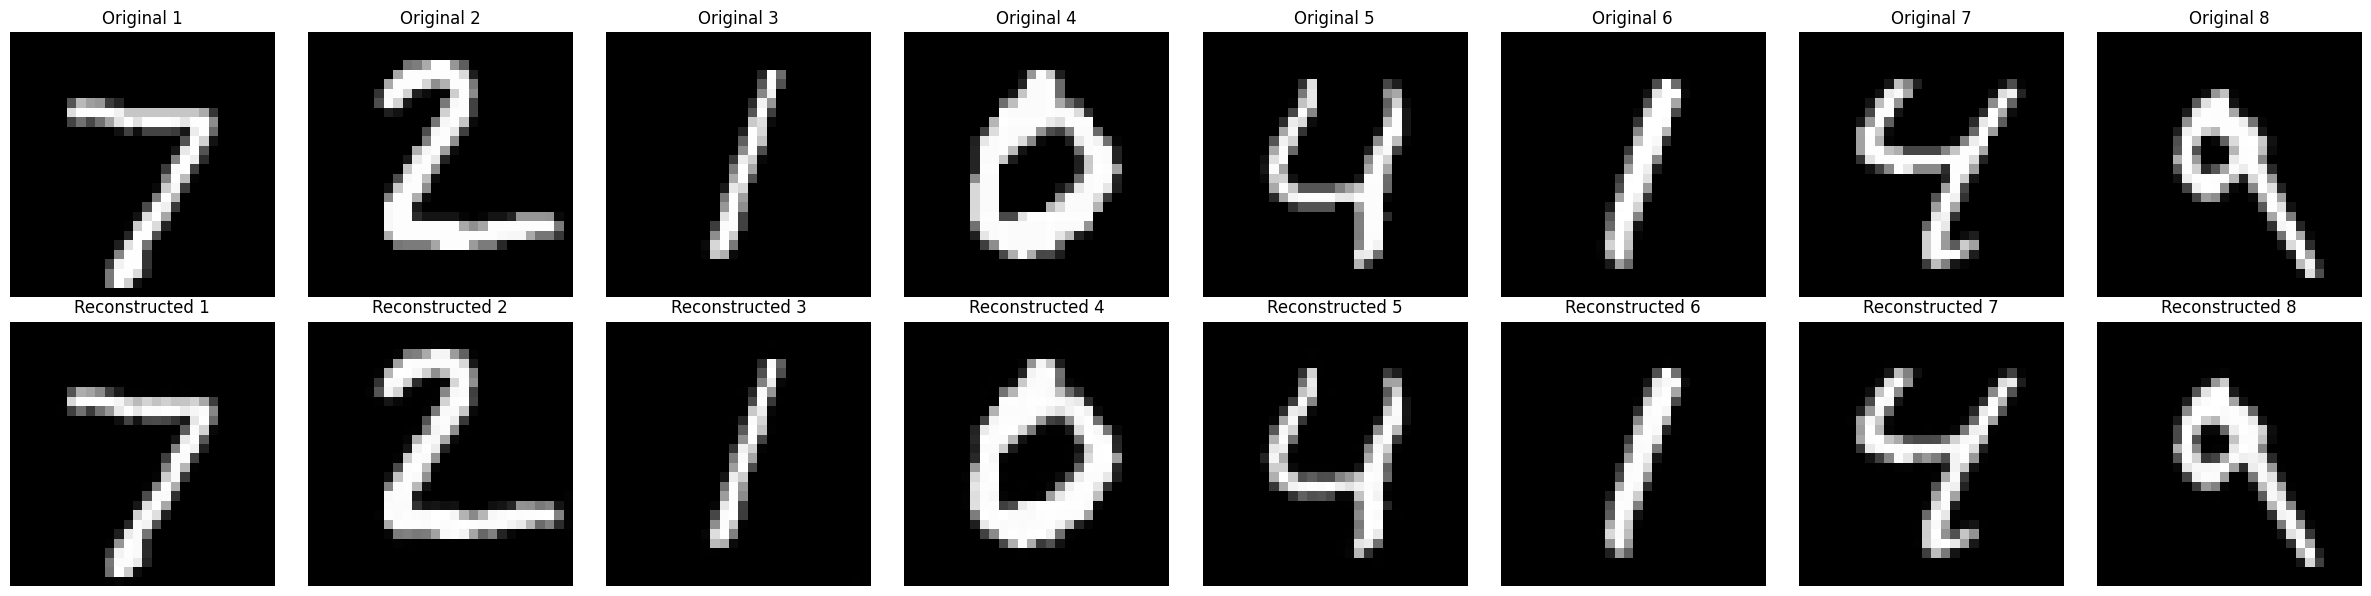

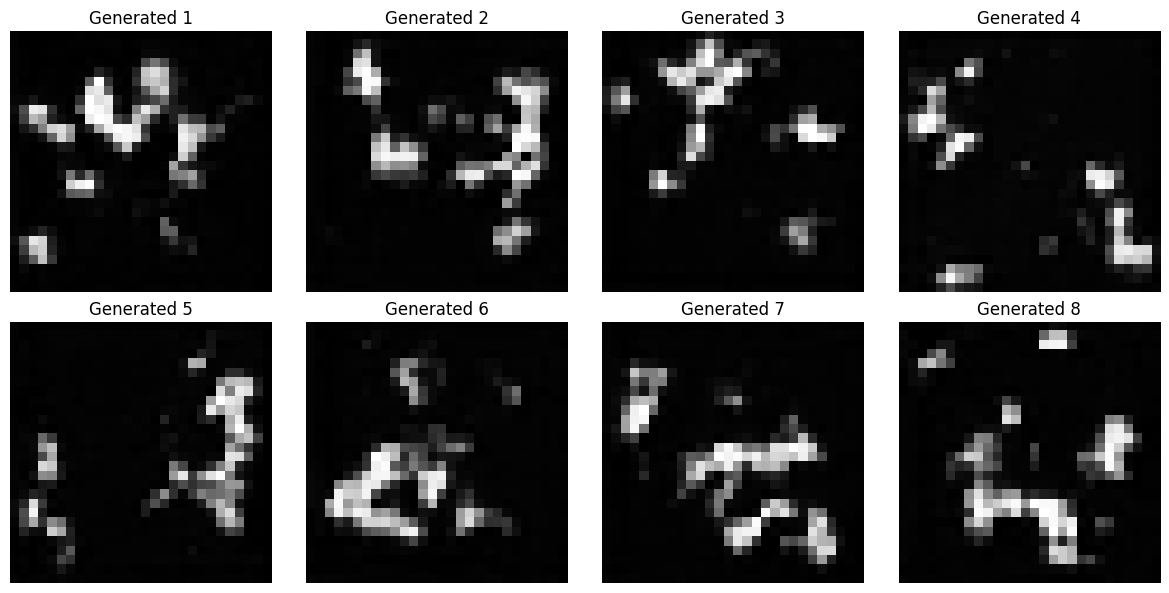

/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `SSIM` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `FrechetInceptionDistance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



test evaluation results
  L1    : 0.009734
  MSE   : 0.000677
  LPIPS : 0.001395
  PSNR  : 37.8399 dB
  SSIM  : 0.997617
  FID   : 0.5746
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:54<00:00, 15.40it/s, rec=0.0364, g=0.0000, d=N/A, KL=1552.5090]



Epoch 1/10 [vae]
  Train - Rec: 0.0841, Reg(vae): 1404.6958, Disc: 0.0000
  Val   - Rec Loss: 0.0381
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0381)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.21it/s, rec=0.0237, g=0.0000, d=N/A, KL=1426.9670]


...


Epoch 8/10 [vae]
  Train - Rec: 0.0107, Reg(vae): 1242.9978, Disc: 1.0000
  Val   - Rec Loss: 0.0108
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0108)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:25<00:00,  9.91it/s, rec=0.0096, g=0.0784, d=1.0000, KL=1240.8070]



Epoch 9/10 [vae]
  Train - Rec: 0.0094, Reg(vae): 1248.4020, Disc: 1.0000
  Val   - Rec Loss: 0.0092
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0092)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:27<00:00,  9.60it/s, rec=0.0088, g=0.1158, d=1.0000, KL=1264.2302]



Epoch 10/10 [vae]
  Train - Rec: 0.0086, Reg(vae): 1253.8746, Disc: 1.0000
  Val   - Rec Loss: 0.0083
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0083)

[vae] 训练完成! 最佳验证损失: 0.0083


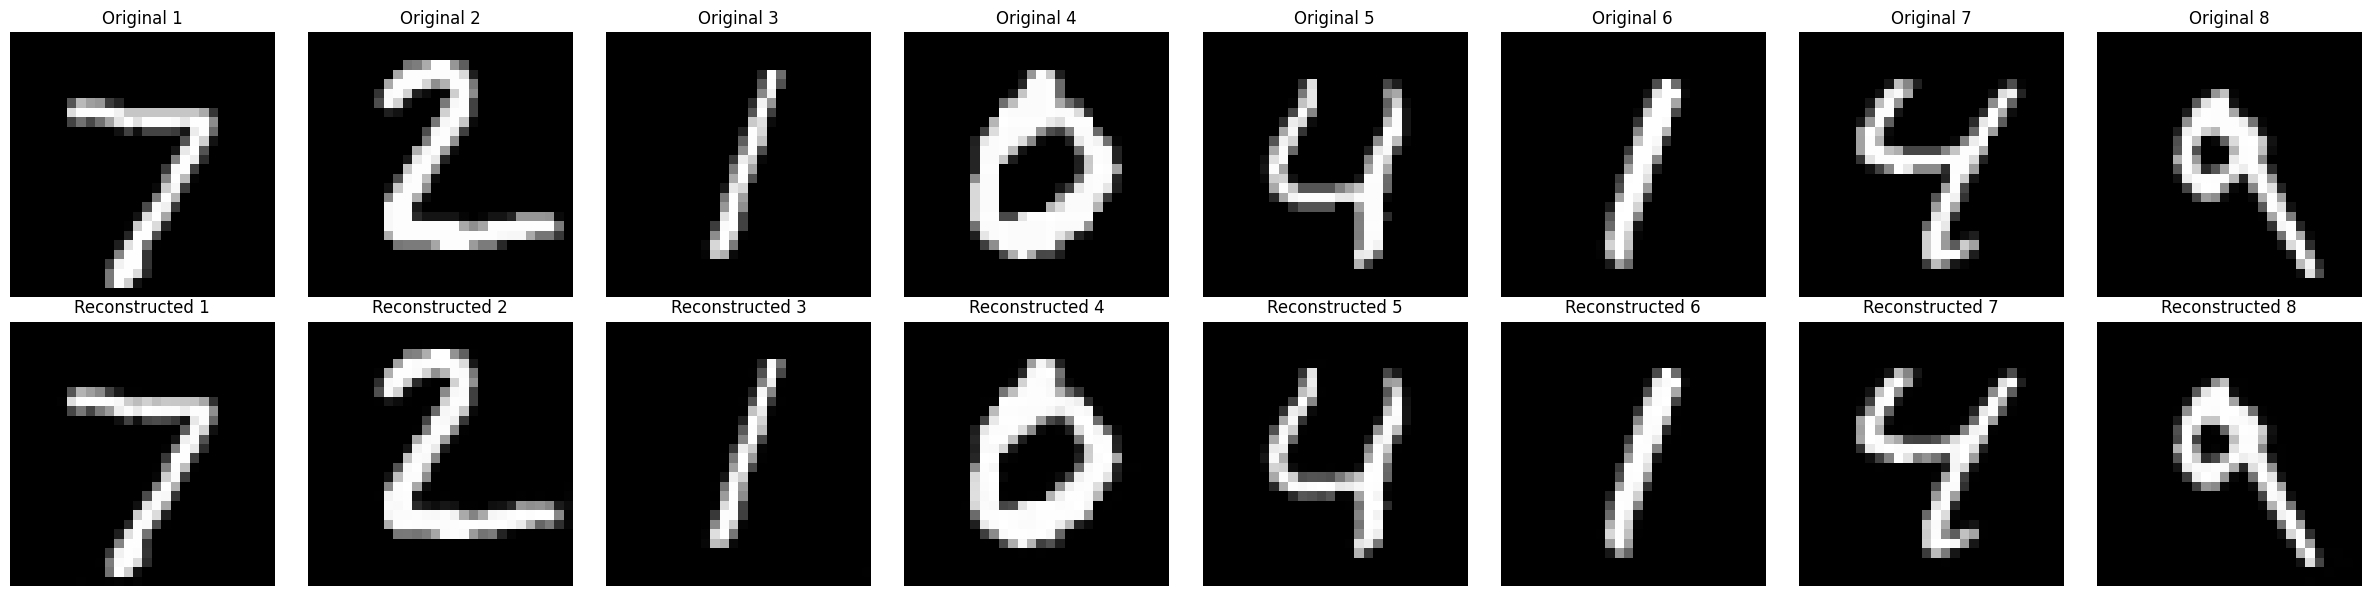

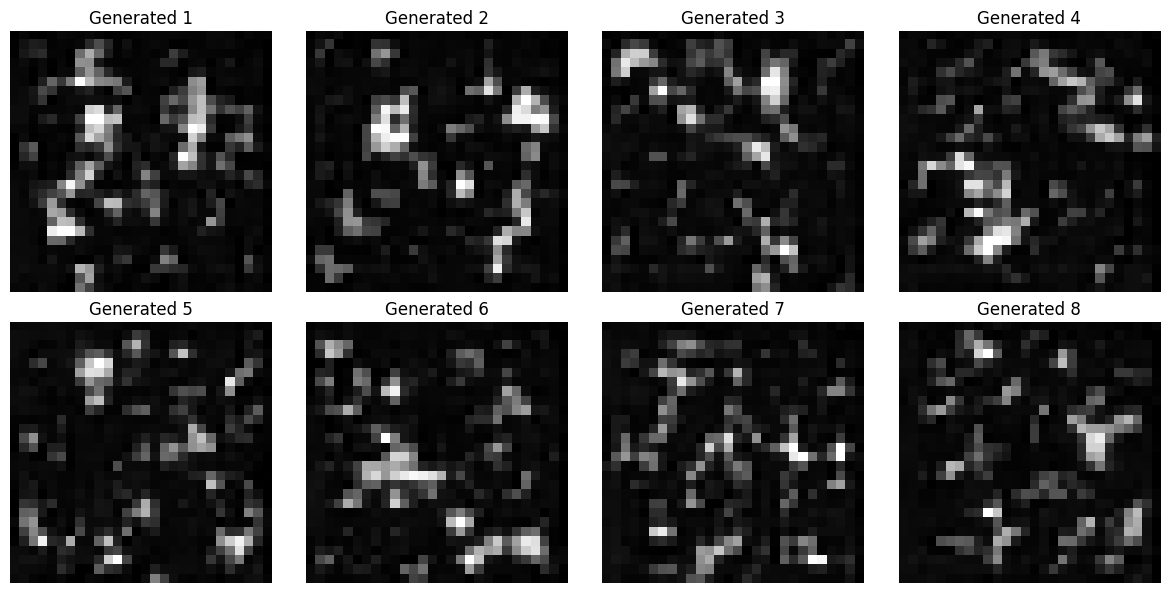


test evaluation results
  L1    : 0.008023
  MSE   : 0.000447
  LPIPS : 0.000943
  PSNR  : 39.7296 dB
  SSIM  : 0.998476
  FID   : 0.4409
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。


In [16]:
for w in [1e-5,1e-6]:
    for rep in range(1): 
        _ = run_training("vae", kl_weight=w, run_tag=f"vae_kl_{w:.0e}")


[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.06it/s, rec=0.0498, g=0.0000, d=N/A, KL=654.5331]



Epoch 1/10 [vae]
  Train - Rec: 0.0890, Reg(vae): 706.2621, Disc: 0.0000
  Val   - Rec Loss: 0.0525
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0525)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:56<00:00, 14.90it/s, rec=0.0387, g=0.0000, d=N/A, KL=565.2722]



Epoch 2/10 [vae]
  Train - Rec: 0.0384, Reg(vae): 599.0966, Disc: 0.0000
  Val   - Rec Loss: 0.0351
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0351)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0129, Reg(vae): 501.9623, Disc: 1.0000
  Val   - Rec Loss: 0.0125
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0125)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:23<00:00, 10.13it/s, rec=0.0107, g=0.0598, d=1.0000, KL=504.9659] 



Epoch 9/10 [vae]
  Train - Rec: 0.0116, Reg(vae): 504.6503, Disc: 1.0000
  Val   - Rec Loss: 0.0112
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0112)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:29<00:00,  9.47it/s, rec=0.0108, g=0.0800, d=1.0000, KL=493.4467]



Epoch 10/10 [vae]
  Train - Rec: 0.0108, Reg(vae): 505.3917, Disc: 1.0000
  Val   - Rec Loss: 0.0105
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0105)

[vae] 训练完成! 最佳验证损失: 0.0105


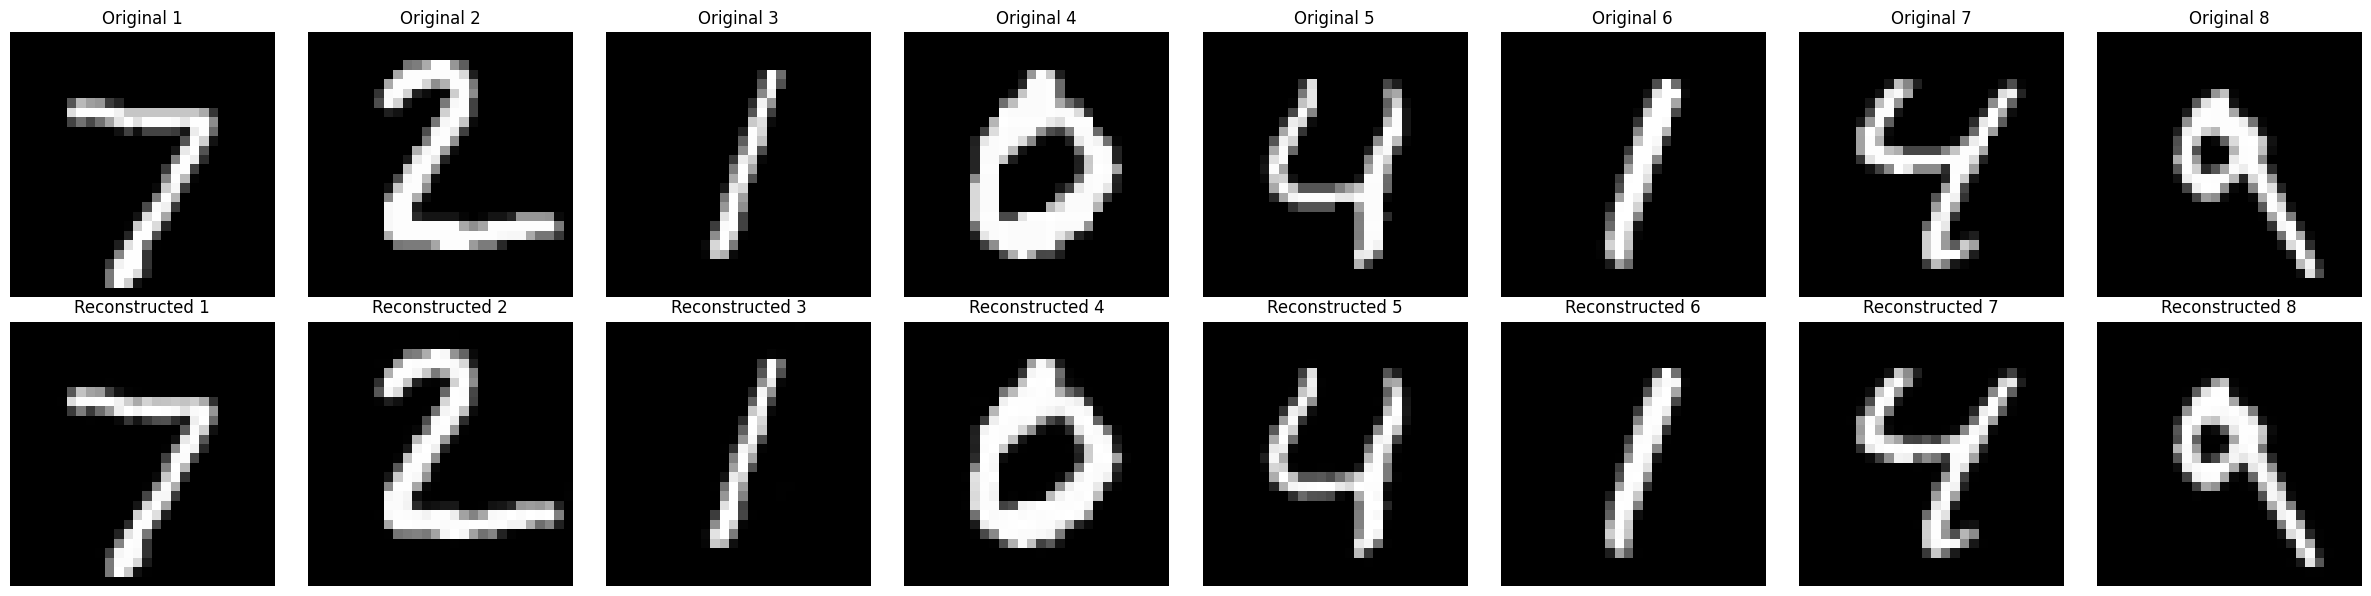

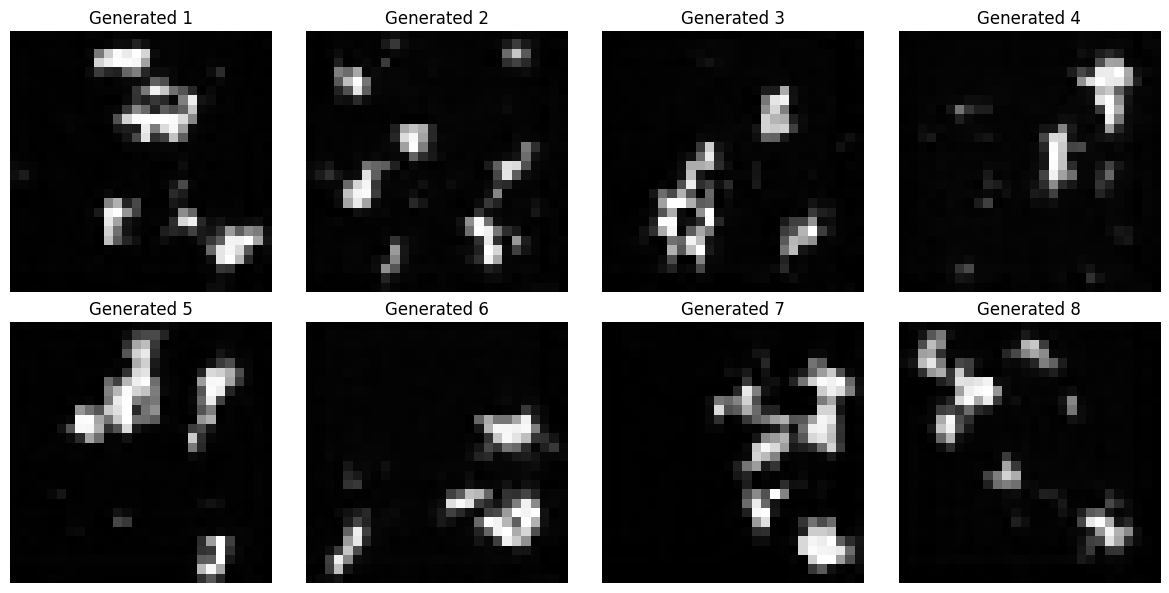


test evaluation results
  L1    : 0.010034
  MSE   : 0.000730
  LPIPS : 0.001447
  PSNR  : 37.5449 dB
  SSIM  : 0.997897
  FID   : 0.6255
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:57<00:00, 14.63it/s, rec=0.0487, g=0.0000, d=N/A, KL=468.8860]



Epoch 1/10 [vae]
  Train - Rec: 0.0842, Reg(vae): 490.2919, Disc: 0.0000
  Val   - Rec Loss: 0.0453
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0453)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:52<00:00, 16.11it/s, rec=0.0352, g=0.0000, d=N/A, KL=425.4705]



Epoch 2/10 [vae]
  Train - Rec: 0.0382, Reg(vae): 435.9943, Disc: 0.0000
  Val   - Rec Loss: 0.0377
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0377)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0156, Reg(vae): 424.5268, Disc: 0.9569
  Val   - Rec Loss: 0.0152
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0152)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:23<00:00, 10.09it/s, rec=0.0147, g=-0.8414, d=0.9472, KL=437.6213]



Epoch 9/10 [vae]
  Train - Rec: 0.0143, Reg(vae): 429.4773, Disc: 0.9359
  Val   - Rec Loss: 0.0137
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0137)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:25<00:00,  9.85it/s, rec=0.0135, g=0.0606, d=0.6728, KL=433.3927] 



Epoch 10/10 [vae]
  Train - Rec: 0.0133, Reg(vae): 432.4849, Disc: 0.8702
  Val   - Rec Loss: 0.0130
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0130)

[vae] 训练完成! 最佳验证损失: 0.0130


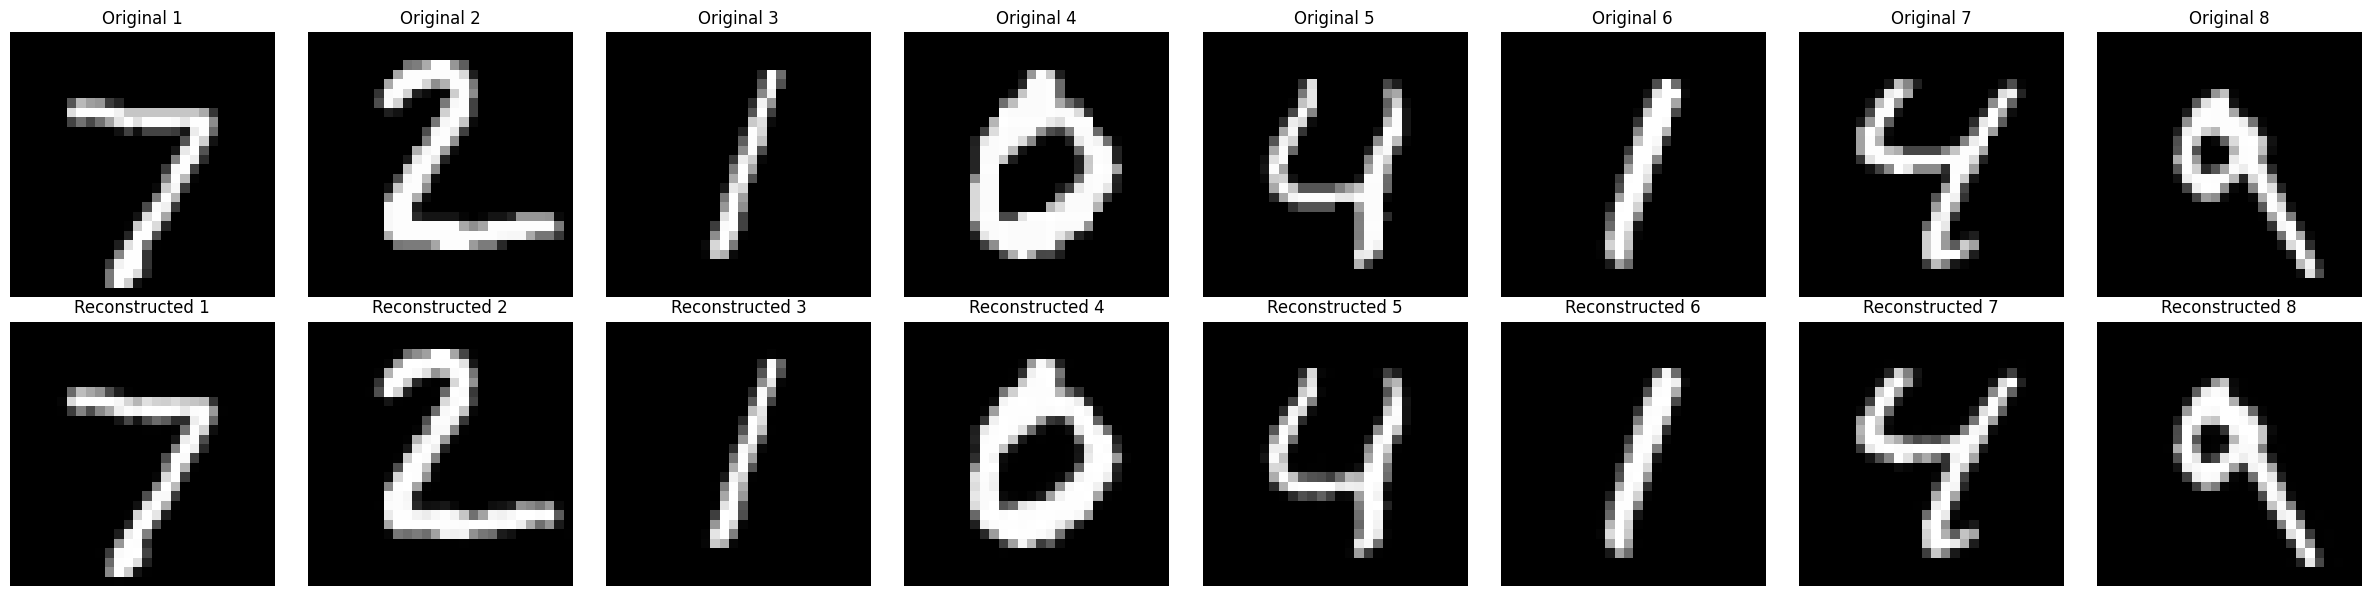

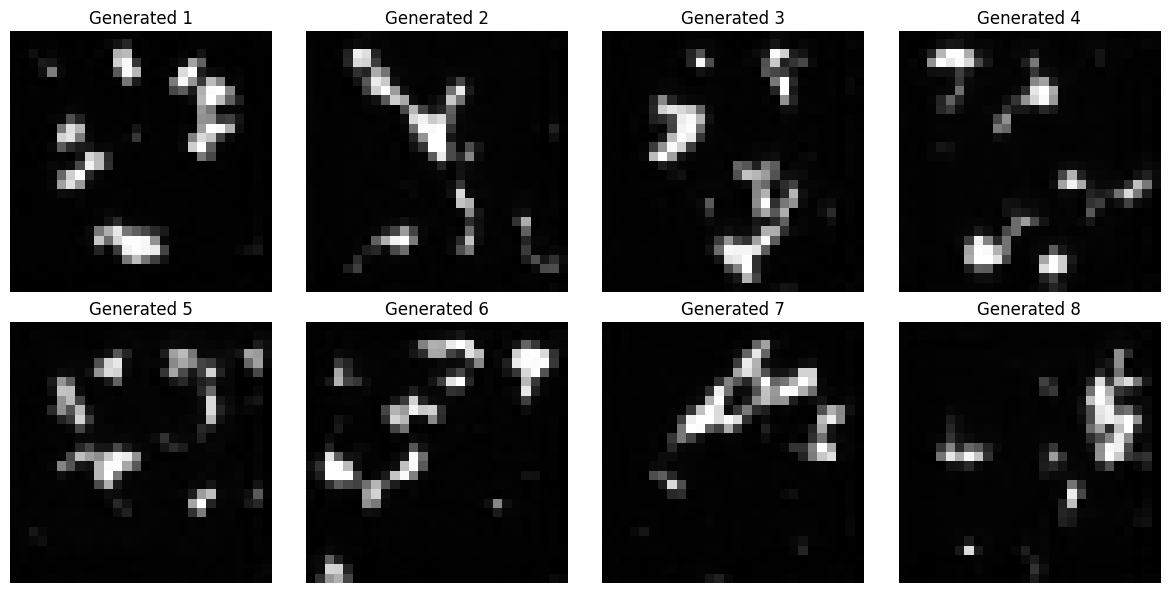


test evaluation results
  L1    : 0.012228
  MSE   : 0.001299
  LPIPS : 0.002590
  PSNR  : 35.0142 dB
  SSIM  : 0.996221
  FID   : 0.8202
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:56<00:00, 14.79it/s, rec=0.0409, g=0.0000, d=N/A, KL=619.8939]



Epoch 1/10 [vae]
  Train - Rec: 0.0841, Reg(vae): 665.4567, Disc: 0.0000
  Val   - Rec Loss: 0.0426
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0426)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:58<00:00, 14.53it/s, rec=0.0310, g=0.0000, d=N/A, KL=511.6259]



Epoch 2/10 [vae]
  Train - Rec: 0.0388, Reg(vae): 568.2449, Disc: 0.0000
  Val   - Rec Loss: 0.0336
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0336)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0149, Reg(vae): 453.9970, Disc: 0.9991
  Val   - Rec Loss: 0.0143
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0143)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:21<00:00, 10.28it/s, rec=0.0140, g=-0.0345, d=0.9278, KL=458.6557]



Epoch 9/10 [vae]
  Train - Rec: 0.0133, Reg(vae): 450.5486, Disc: 0.9802
  Val   - Rec Loss: 0.0130
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0130)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:25<00:00,  9.85it/s, rec=0.0127, g=0.3614, d=0.9194, KL=449.6718] 



Epoch 10/10 [vae]
  Train - Rec: 0.0123, Reg(vae): 452.4821, Disc: 0.9532
  Val   - Rec Loss: 0.0120
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0120)

[vae] 训练完成! 最佳验证损失: 0.0120


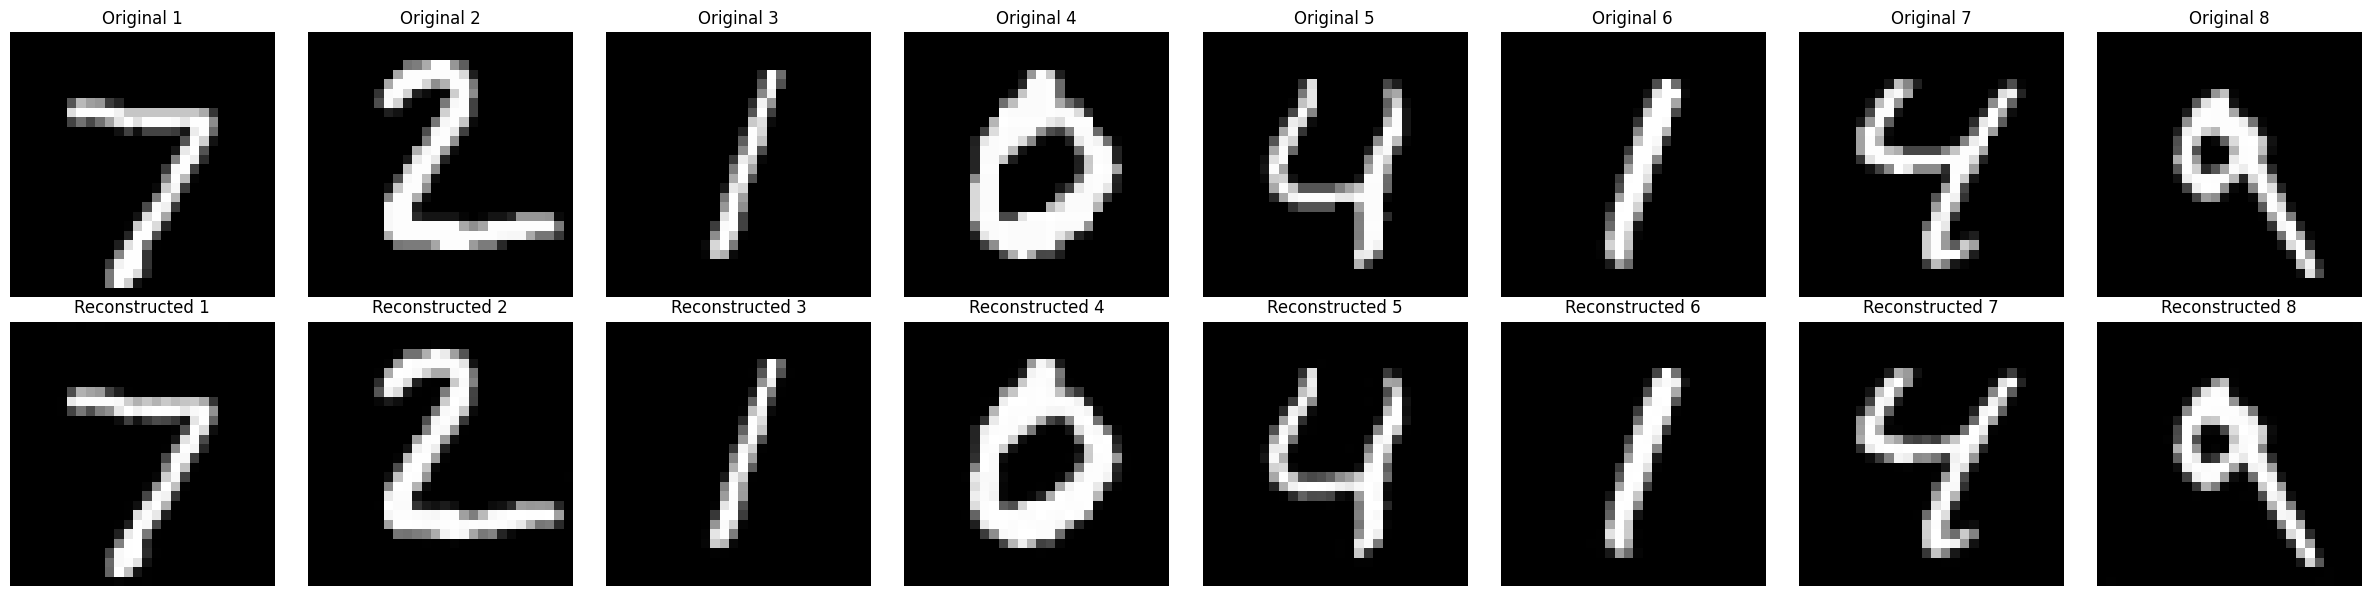

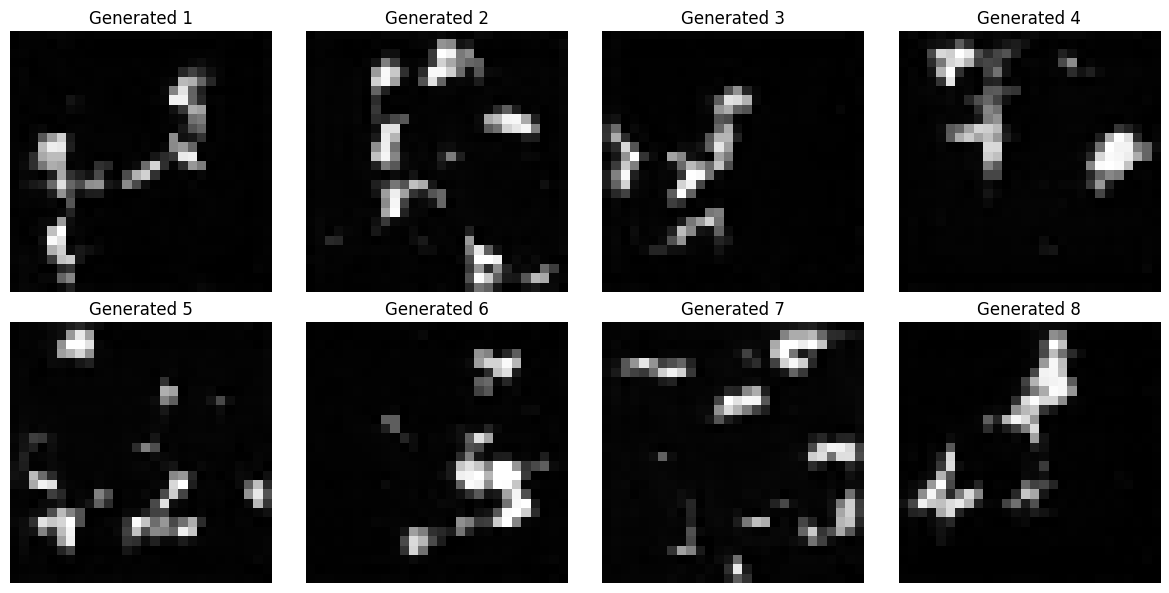


test evaluation results
  L1    : 0.011396
  MSE   : 0.001050
  LPIPS : 0.002154
  PSNR  : 35.9445 dB
  SSIM  : 0.997126
  FID   : 0.7555
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:56<00:00, 14.82it/s, rec=0.0454, g=0.0000, d=N/A, KL=568.9256]



Epoch 1/10 [vae]
  Train - Rec: 0.0830, Reg(vae): 656.2681, Disc: 0.0000
  Val   - Rec Loss: 0.0411
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0411)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:59<00:00, 14.25it/s, rec=0.0304, g=0.0000, d=N/A, KL=520.5646]



Epoch 2/10 [vae]
  Train - Rec: 0.0358, Reg(vae): 544.7973, Disc: 0.0000
  Val   - Rec Loss: 0.0307
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0307)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0120, Reg(vae): 505.1523, Disc: 1.0003
  Val   - Rec Loss: 0.0122
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0122)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:26<00:00,  9.79it/s, rec=0.0105, g=0.4474, d=0.9736, KL=509.3171] 



Epoch 9/10 [vae]
  Train - Rec: 0.0108, Reg(vae): 506.1379, Disc: 0.9862
  Val   - Rec Loss: 0.0105
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0105)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:34<00:00,  8.90it/s, rec=0.0099, g=-0.1588, d=0.9529, KL=501.3672]



Epoch 10/10 [vae]
  Train - Rec: 0.0101, Reg(vae): 506.0411, Disc: 0.9690
  Val   - Rec Loss: 0.0101
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0101)

[vae] 训练完成! 最佳验证损失: 0.0101


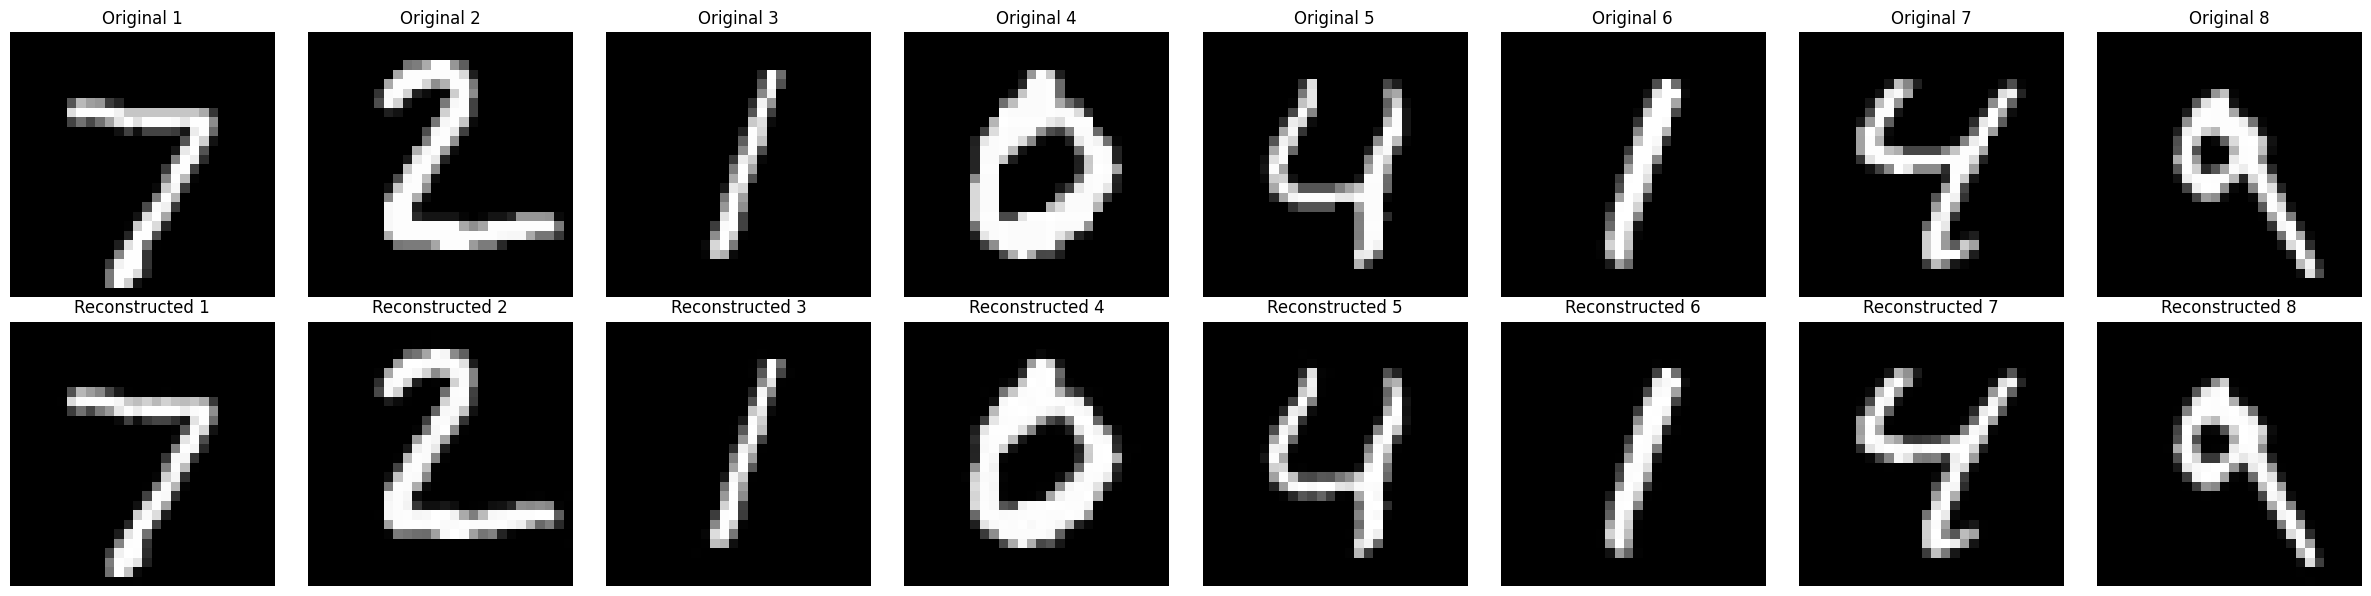

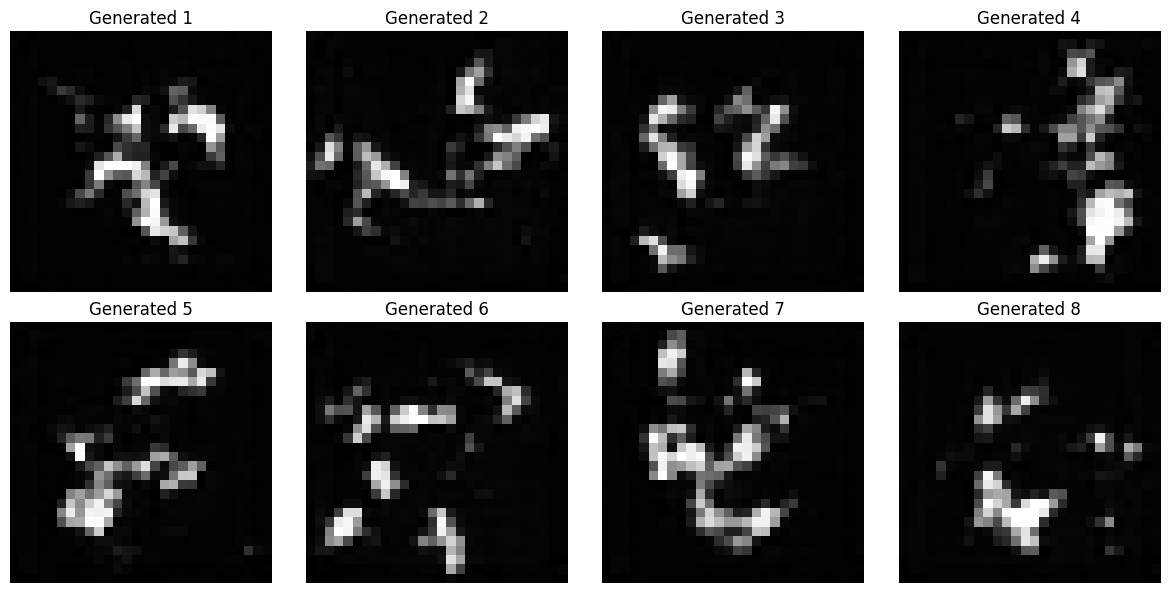


test evaluation results
  L1    : 0.009635
  MSE   : 0.000679
  LPIPS : 0.001324
  PSNR  : 37.8399 dB
  SSIM  : 0.997488
  FID   : 0.5125
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:53<00:00, 15.72it/s, rec=0.0400, g=0.0000, d=N/A, KL=497.8051]



Epoch 1/10 [vae]
  Train - Rec: 0.0847, Reg(vae): 550.7781, Disc: 0.0000
  Val   - Rec Loss: 0.0454
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0454)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:53<00:00, 15.62it/s, rec=0.0306, g=0.0000, d=N/A, KL=471.5380]



Epoch 2/10 [vae]
  Train - Rec: 0.0360, Reg(vae): 477.3169, Disc: 0.0000
  Val   - Rec Loss: 0.0287
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0287)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0124, Reg(vae): 487.7445, Disc: 1.0022
  Val   - Rec Loss: 0.0119
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0119)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:21<00:00, 10.39it/s, rec=0.0110, g=-0.0203, d=0.9907, KL=493.2561]



Epoch 9/10 [vae]
  Train - Rec: 0.0111, Reg(vae): 490.7300, Disc: 1.0036
  Val   - Rec Loss: 0.0108
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0108)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:22<00:00, 10.21it/s, rec=0.0100, g=0.0945, d=0.9945, KL=498.7699] 



Epoch 10/10 [vae]
  Train - Rec: 0.0103, Reg(vae): 491.9392, Disc: 0.9945
  Val   - Rec Loss: 0.0102
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0102)

[vae] 训练完成! 最佳验证损失: 0.0102


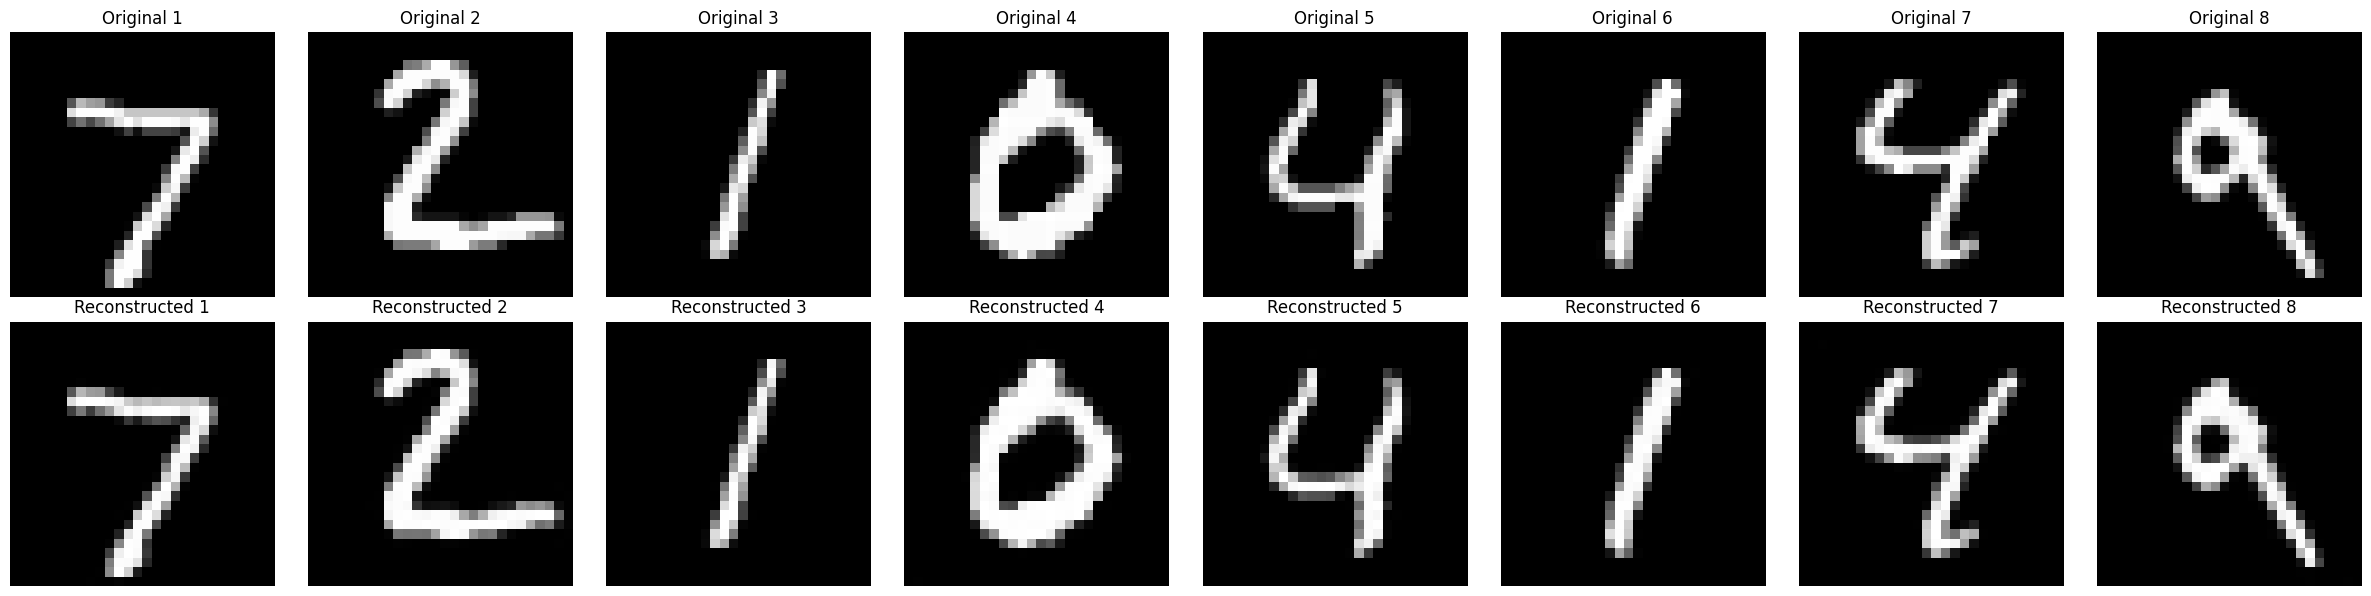

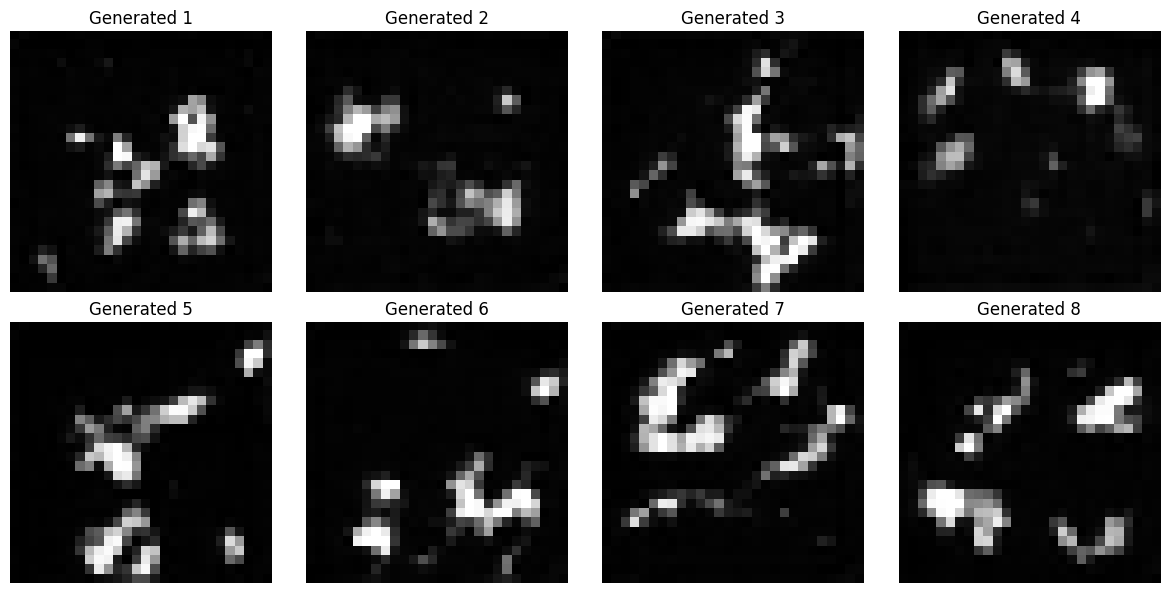


test evaluation results
  L1    : 0.009764
  MSE   : 0.000664
  LPIPS : 0.001371
  PSNR  : 37.9309 dB
  SSIM  : 0.997241
  FID   : 0.6013
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.23it/s, rec=0.0484, g=0.0000, d=N/A, KL=568.0473]



Epoch 1/10 [vae]
  Train - Rec: 0.0908, Reg(vae): 581.5274, Disc: 0.0000
  Val   - Rec Loss: 0.0417
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0417)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:53<00:00, 15.68it/s, rec=0.0298, g=0.0000, d=N/A, KL=524.6581]



Epoch 2/10 [vae]
  Train - Rec: 0.0357, Reg(vae): 549.9036, Disc: 0.0000
  Val   - Rec Loss: 0.0289
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0289)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0119, Reg(vae): 511.7543, Disc: 1.0055
  Val   - Rec Loss: 0.0118
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0118)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:17<00:00, 10.87it/s, rec=0.0098, g=-0.3420, d=0.9870, KL=495.3654]



Epoch 9/10 [vae]
  Train - Rec: 0.0107, Reg(vae): 514.4817, Disc: 0.9931
  Val   - Rec Loss: 0.0106
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0106)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:24<00:00, 10.02it/s, rec=0.0097, g=-0.1519, d=0.9896, KL=516.6281]



Epoch 10/10 [vae]
  Train - Rec: 0.0100, Reg(vae): 516.1621, Disc: 0.9816
  Val   - Rec Loss: 0.0098
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0098)

[vae] 训练完成! 最佳验证损失: 0.0098


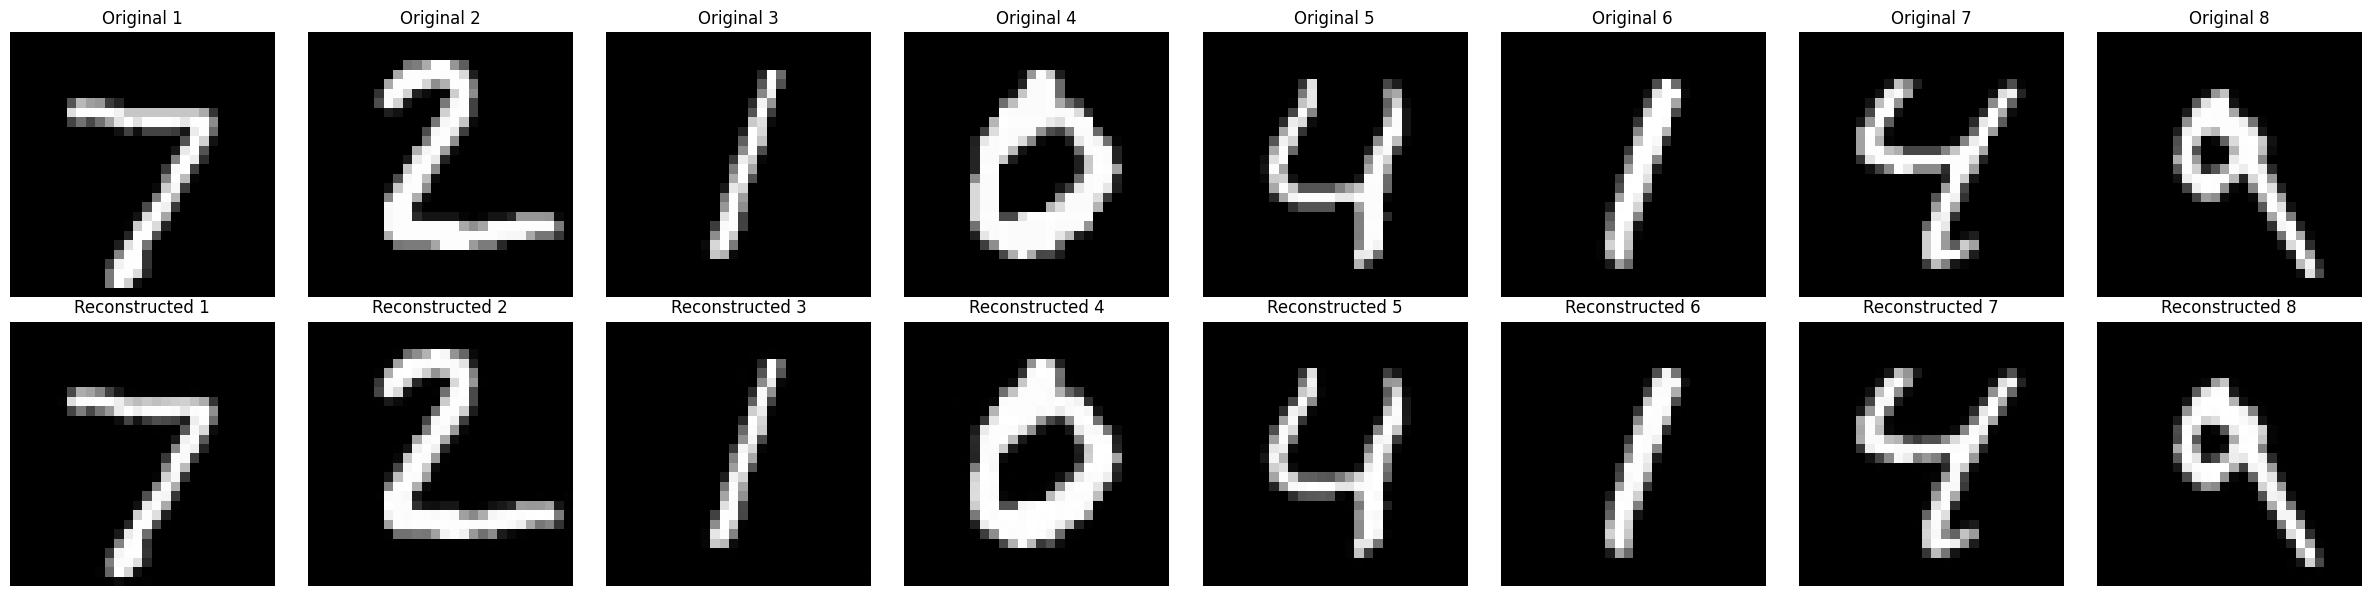

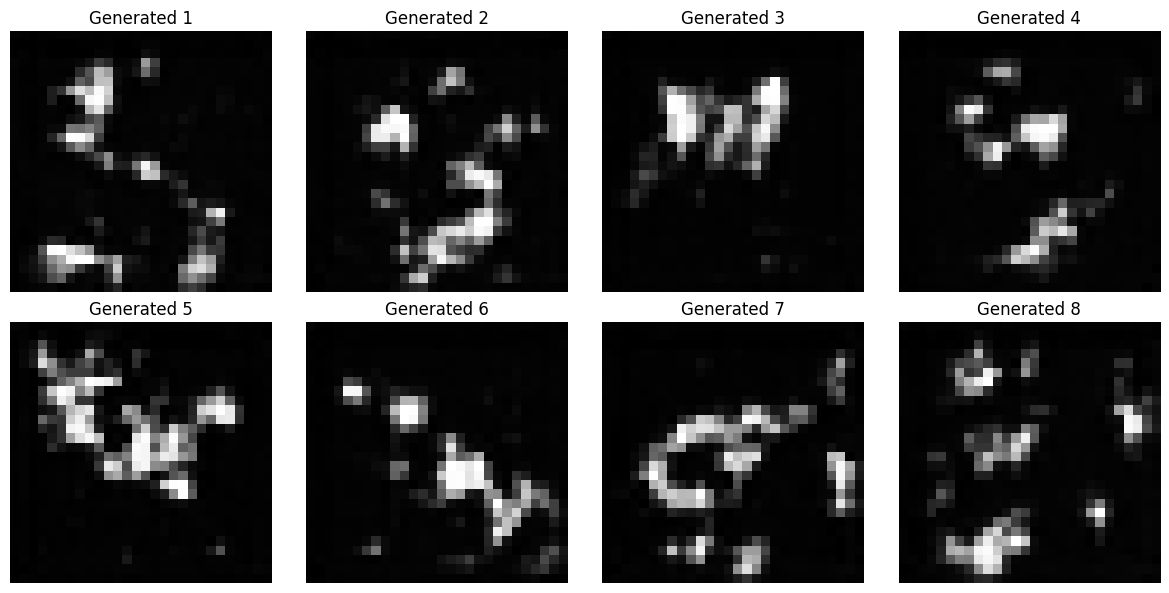


test evaluation results
  L1    : 0.009366
  MSE   : 0.000640
  LPIPS : 0.001299
  PSNR  : 38.1134 dB
  SSIM  : 0.998150
  FID   : 0.5256
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:56<00:00, 15.01it/s, rec=0.0398, g=0.0000, d=N/A, KL=492.5836]



Epoch 1/10 [vae]
  Train - Rec: 0.0858, Reg(vae): 529.2320, Disc: 0.0000
  Val   - Rec Loss: 0.0370
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0370)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:56<00:00, 14.93it/s, rec=0.0303, g=0.0000, d=N/A, KL=496.8162]



Epoch 2/10 [vae]
  Train - Rec: 0.0348, Reg(vae): 497.2138, Disc: 0.0000
  Val   - Rec Loss: 0.0319
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0319)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0118, Reg(vae): 495.5178, Disc: 0.9726
  Val   - Rec Loss: 0.0113
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0113)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:21<00:00, 10.36it/s, rec=0.0103, g=0.0607, d=1.0014, KL=493.8383] 



Epoch 9/10 [vae]
  Train - Rec: 0.0107, Reg(vae): 497.8701, Disc: 0.9581
  Val   - Rec Loss: 0.0106
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0106)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:24<00:00, 10.02it/s, rec=0.0095, g=0.1312, d=1.0368, KL=492.1625] 



Epoch 10/10 [vae]
  Train - Rec: 0.0100, Reg(vae): 498.9158, Disc: 0.9324
  Val   - Rec Loss: 0.0102
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0102)

[vae] 训练完成! 最佳验证损失: 0.0102


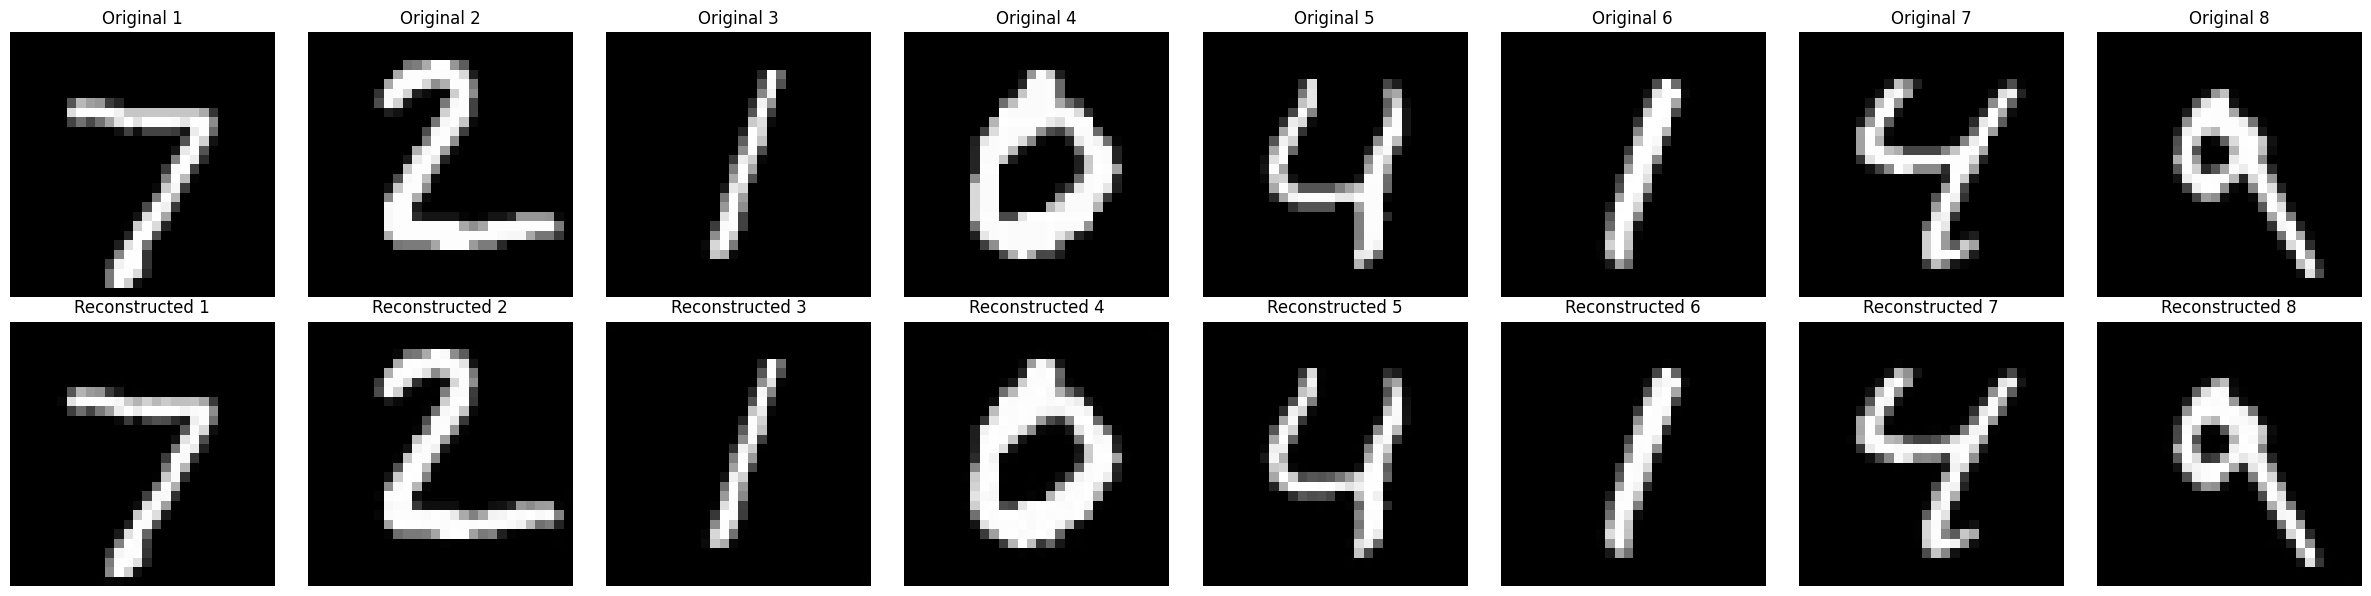

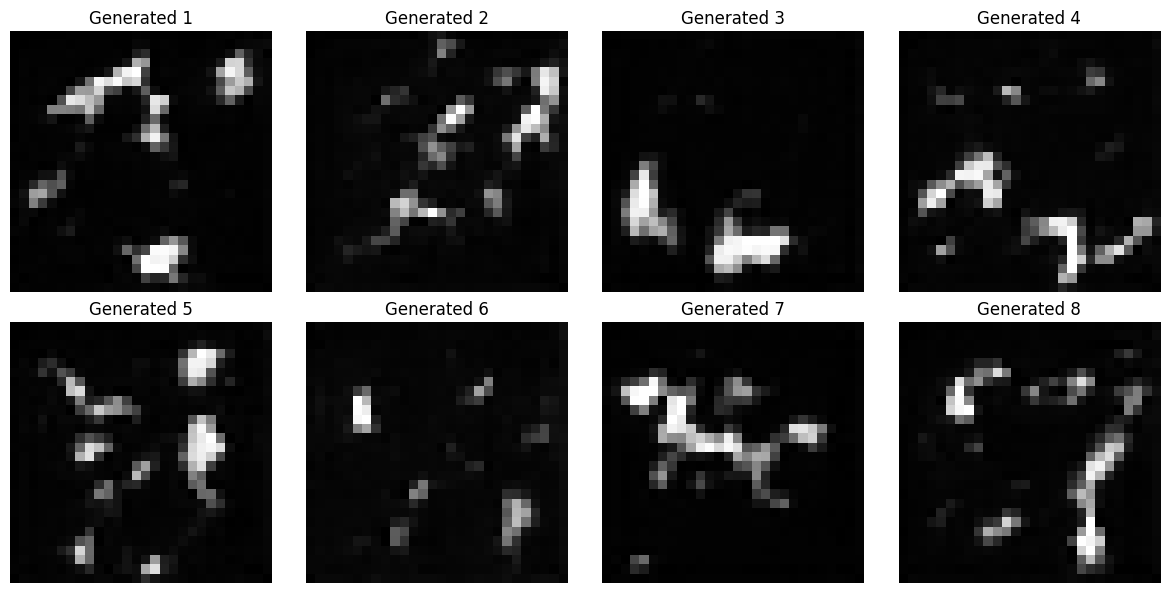


test evaluation results
  L1    : 0.009805
  MSE   : 0.000666
  LPIPS : 0.001305
  PSNR  : 37.9442 dB
  SSIM  : 0.997327
  FID   : 0.5349
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.14it/s, rec=0.0396, g=0.0000, d=N/A, KL=1641.7659]



Epoch 1/10 [vae]
  Train - Rec: 0.0793, Reg(vae): 1455.9221, Disc: 0.0000
  Val   - Rec Loss: 0.0437
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0437)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:57<00:00, 14.56it/s, rec=0.0254, g=0.0000, d=N/A, KL=1678.7661]



Epoch 2/10 [vae]
  Train - Rec: 0.0336, Reg(vae): 1665.2920, Disc: 0.0000
  Val   - Rec Loss: 0.0288
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0288)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0099, Reg(vae): 1647.3640, Disc: 1.0000
  Val   - Rec Loss: 0.0100
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0100)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:28<00:00,  9.49it/s, rec=0.0095, g=0.0291, d=1.0000, KL=1659.7649] 



Epoch 9/10 [vae]
  Train - Rec: 0.0085, Reg(vae): 1662.4430, Disc: 1.0000
  Val   - Rec Loss: 0.0084
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0084)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:22<00:00, 10.27it/s, rec=0.0078, g=0.0179, d=1.0000, KL=1651.2336] 



Epoch 10/10 [vae]
  Train - Rec: 0.0077, Reg(vae): 1674.5744, Disc: 1.0000
  Val   - Rec Loss: 0.0075
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0075)

[vae] 训练完成! 最佳验证损失: 0.0075


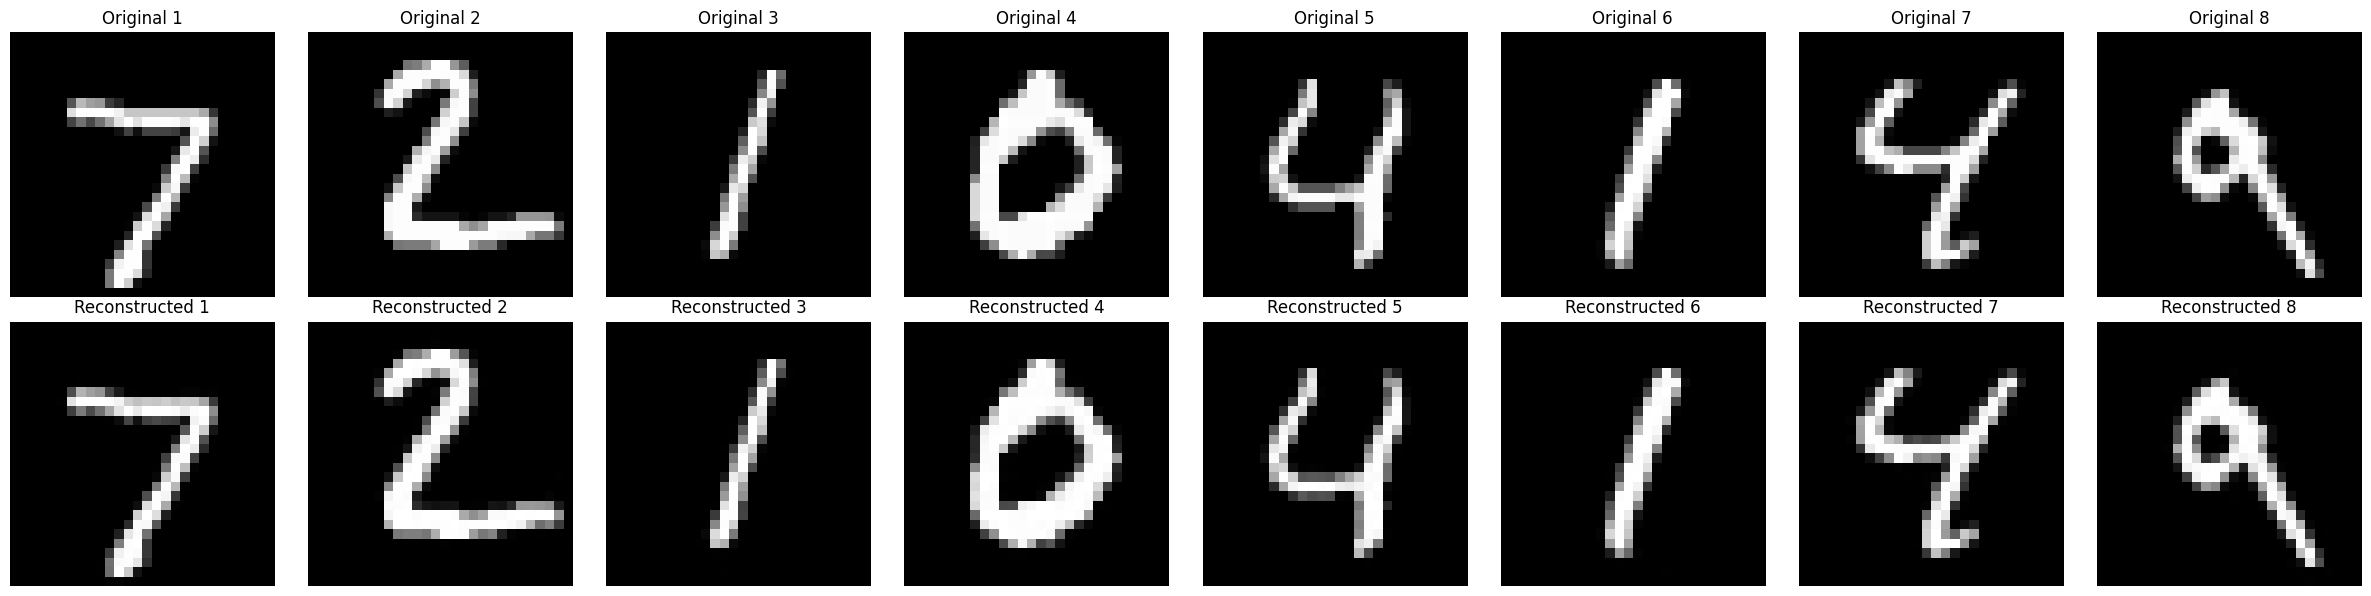

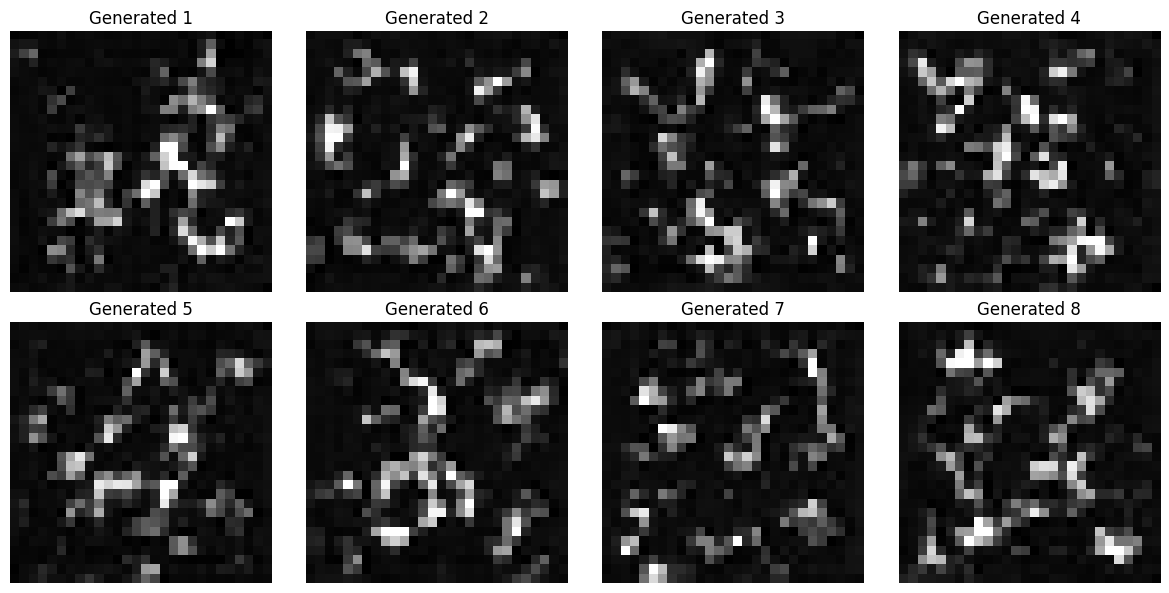


test evaluation results
  L1    : 0.007262
  MSE   : 0.000307
  LPIPS : 0.000721
  PSNR  : 41.3805 dB
  SSIM  : 0.998295
  FID   : 0.4114
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:54<00:00, 15.56it/s, rec=0.0408, g=0.0000, d=N/A, KL=1718.9473]



Epoch 1/10 [vae]
  Train - Rec: 0.0875, Reg(vae): 1940.7282, Disc: 0.0000
  Val   - Rec Loss: 0.0422
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0422)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:57<00:00, 14.53it/s, rec=0.0372, g=0.0000, d=N/A, KL=1633.2517]



Epoch 2/10 [vae]
  Train - Rec: 0.0361, Reg(vae): 1625.5374, Disc: 0.0000
  Val   - Rec Loss: 0.0305
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0305)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0110, Reg(vae): 1615.1333, Disc: 1.0000
  Val   - Rec Loss: 0.0113
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0113)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:20<00:00, 10.43it/s, rec=0.0101, g=-0.0260, d=1.0000, KL=1644.6470]



Epoch 9/10 [vae]
  Train - Rec: 0.0097, Reg(vae): 1618.6125, Disc: 1.0000
  Val   - Rec Loss: 0.0096
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0096)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:23<00:00, 10.14it/s, rec=0.0093, g=0.0392, d=1.0000, KL=1585.1918] 



Epoch 10/10 [vae]
  Train - Rec: 0.0089, Reg(vae): 1620.3335, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0088)

[vae] 训练完成! 最佳验证损失: 0.0088


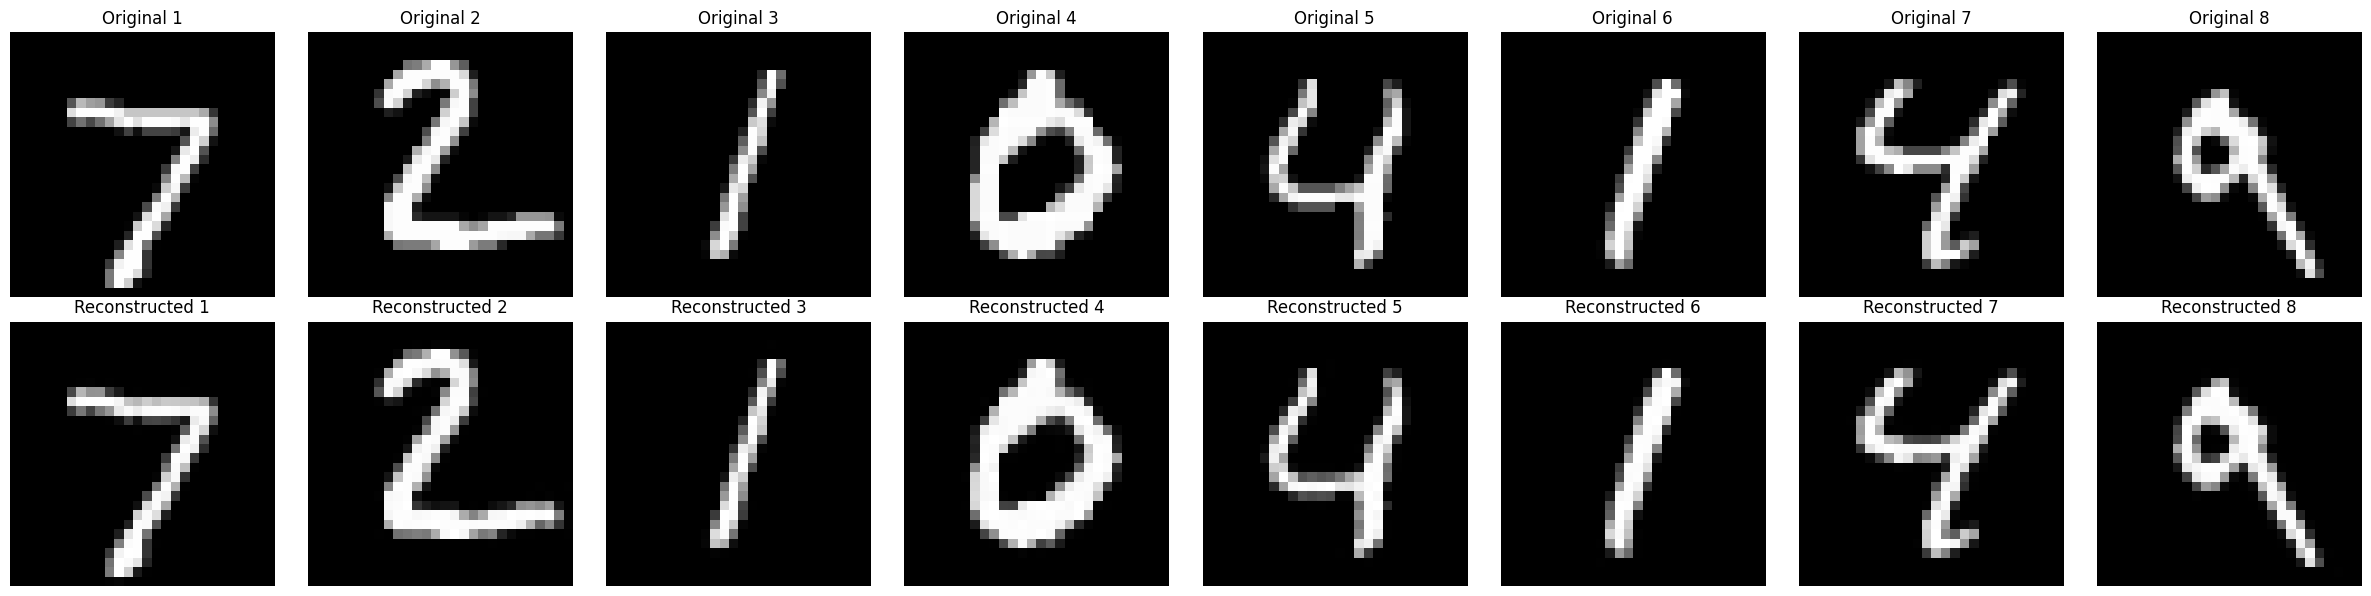

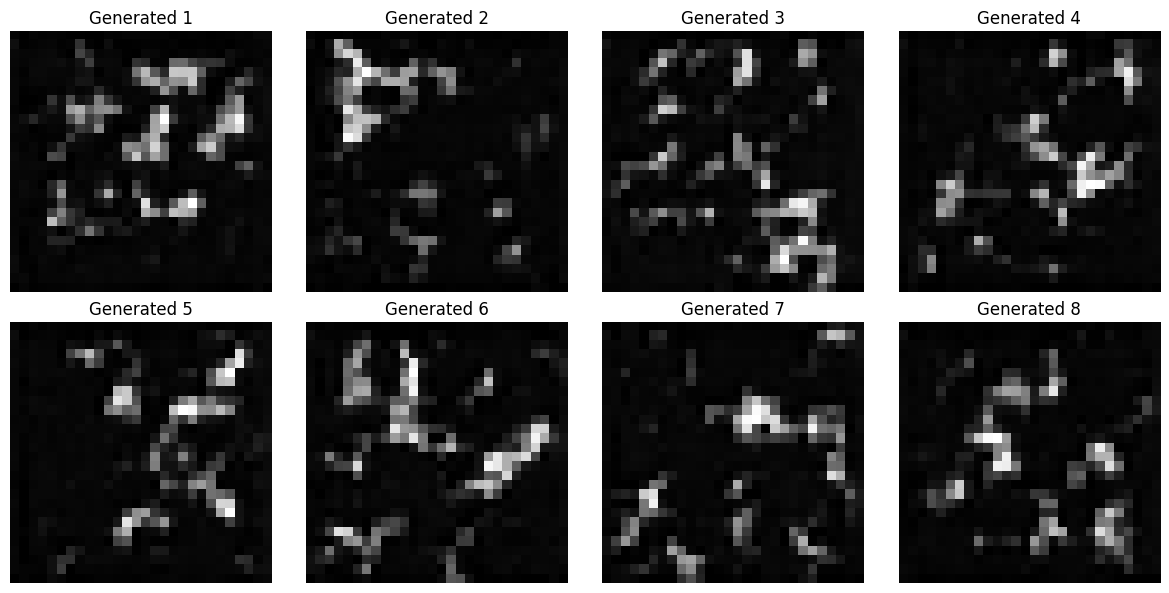


test evaluation results
  L1    : 0.008470
  MSE   : 0.000491
  LPIPS : 0.001062
  PSNR  : 39.3090 dB
  SSIM  : 0.998282
  FID   : 0.4883
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:49<00:00, 17.07it/s, rec=0.0354, g=0.0000, d=N/A, KL=1599.1317]



Epoch 1/10 [vae]
  Train - Rec: 0.0829, Reg(vae): 1373.3210, Disc: 0.0000
  Val   - Rec Loss: 0.0391
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0391)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:56<00:00, 14.98it/s, rec=0.0271, g=0.0000, d=N/A, KL=1518.6287]



Epoch 2/10 [vae]
  Train - Rec: 0.0314, Reg(vae): 1549.2866, Disc: 0.0000
  Val   - Rec Loss: 0.0272
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0272)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0102, Reg(vae): 1215.8979, Disc: 0.9867
  Val   - Rec Loss: 0.0094
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0094)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:21<00:00, 10.36it/s, rec=0.0092, g=-0.5289, d=0.9453, KL=1198.3694]



Epoch 9/10 [vae]
  Train - Rec: 0.0090, Reg(vae): 1211.9116, Disc: 0.9662
  Val   - Rec Loss: 0.0088
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0088)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:21<00:00, 10.34it/s, rec=0.0081, g=0.1996, d=0.8632, KL=1195.3525] 



Epoch 10/10 [vae]
  Train - Rec: 0.0084, Reg(vae): 1211.5903, Disc: 0.9406
  Val   - Rec Loss: 0.0083
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0083)

[vae] 训练完成! 最佳验证损失: 0.0083


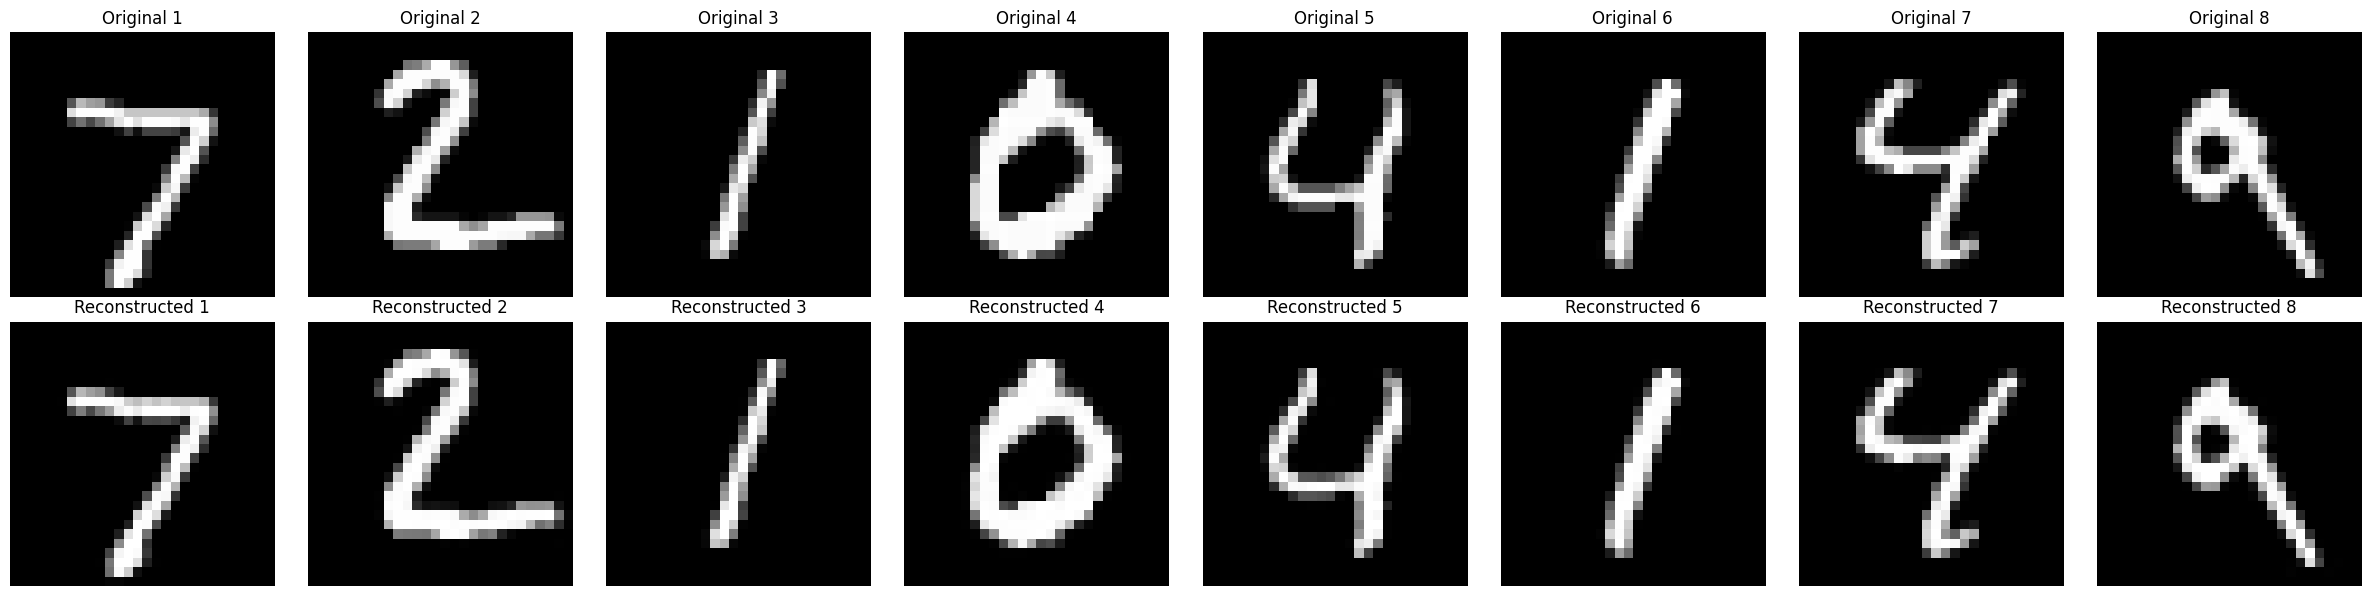

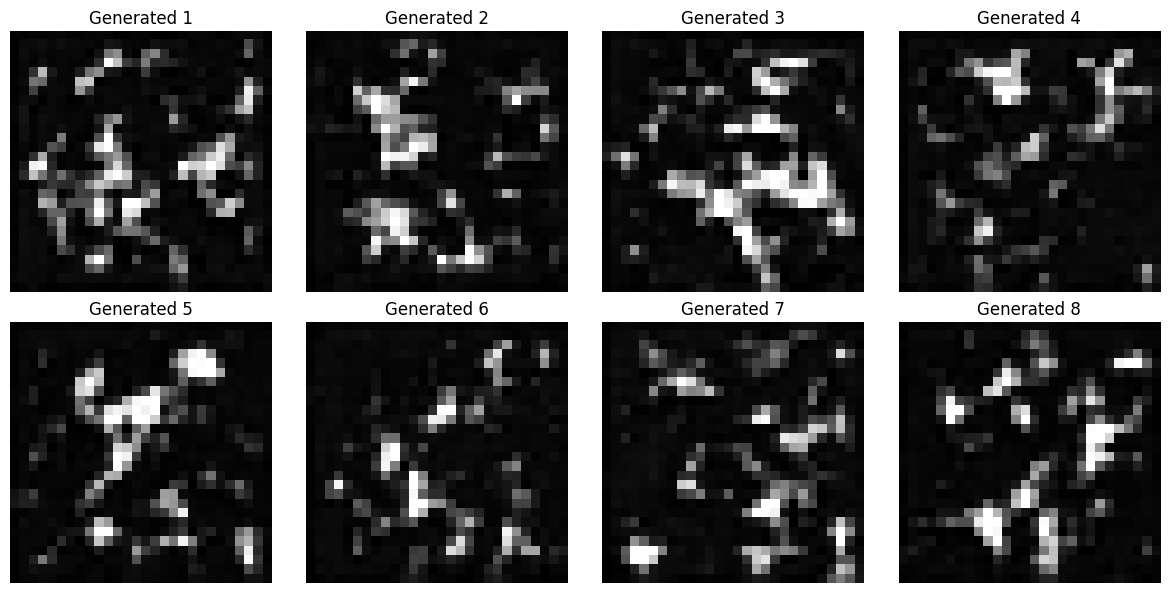


test evaluation results
  L1    : 0.007972
  MSE   : 0.000461
  LPIPS : 0.000904
  PSNR  : 39.6233 dB
  SSIM  : 0.998551
  FID   : 0.3871
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.30it/s, rec=0.0403, g=0.0000, d=N/A, KL=1500.0226]



Epoch 1/10 [vae]
  Train - Rec: 0.0876, Reg(vae): 1263.5551, Disc: 0.0000
  Val   - Rec Loss: 0.0395
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0395)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:56<00:00, 14.84it/s, rec=0.0274, g=0.0000, d=N/A, KL=1472.9283]



Epoch 2/10 [vae]
  Train - Rec: 0.0338, Reg(vae): 1471.2907, Disc: 0.0000
  Val   - Rec Loss: 0.0276
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0276)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0097, Reg(vae): 1458.1137, Disc: 1.0000
  Val   - Rec Loss: 0.0087
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0087)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:22<00:00, 10.17it/s, rec=0.0077, g=-0.0175, d=1.0000, KL=1456.9004]



Epoch 9/10 [vae]
  Train - Rec: 0.0083, Reg(vae): 1471.8382, Disc: 1.0000
  Val   - Rec Loss: 0.0081
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0081)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:30<00:00,  9.27it/s, rec=0.0076, g=-0.0372, d=1.0000, KL=1458.0447]



Epoch 10/10 [vae]
  Train - Rec: 0.0075, Reg(vae): 1482.1146, Disc: 1.0000
  Val   - Rec Loss: 0.0075
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0075)

[vae] 训练完成! 最佳验证损失: 0.0075


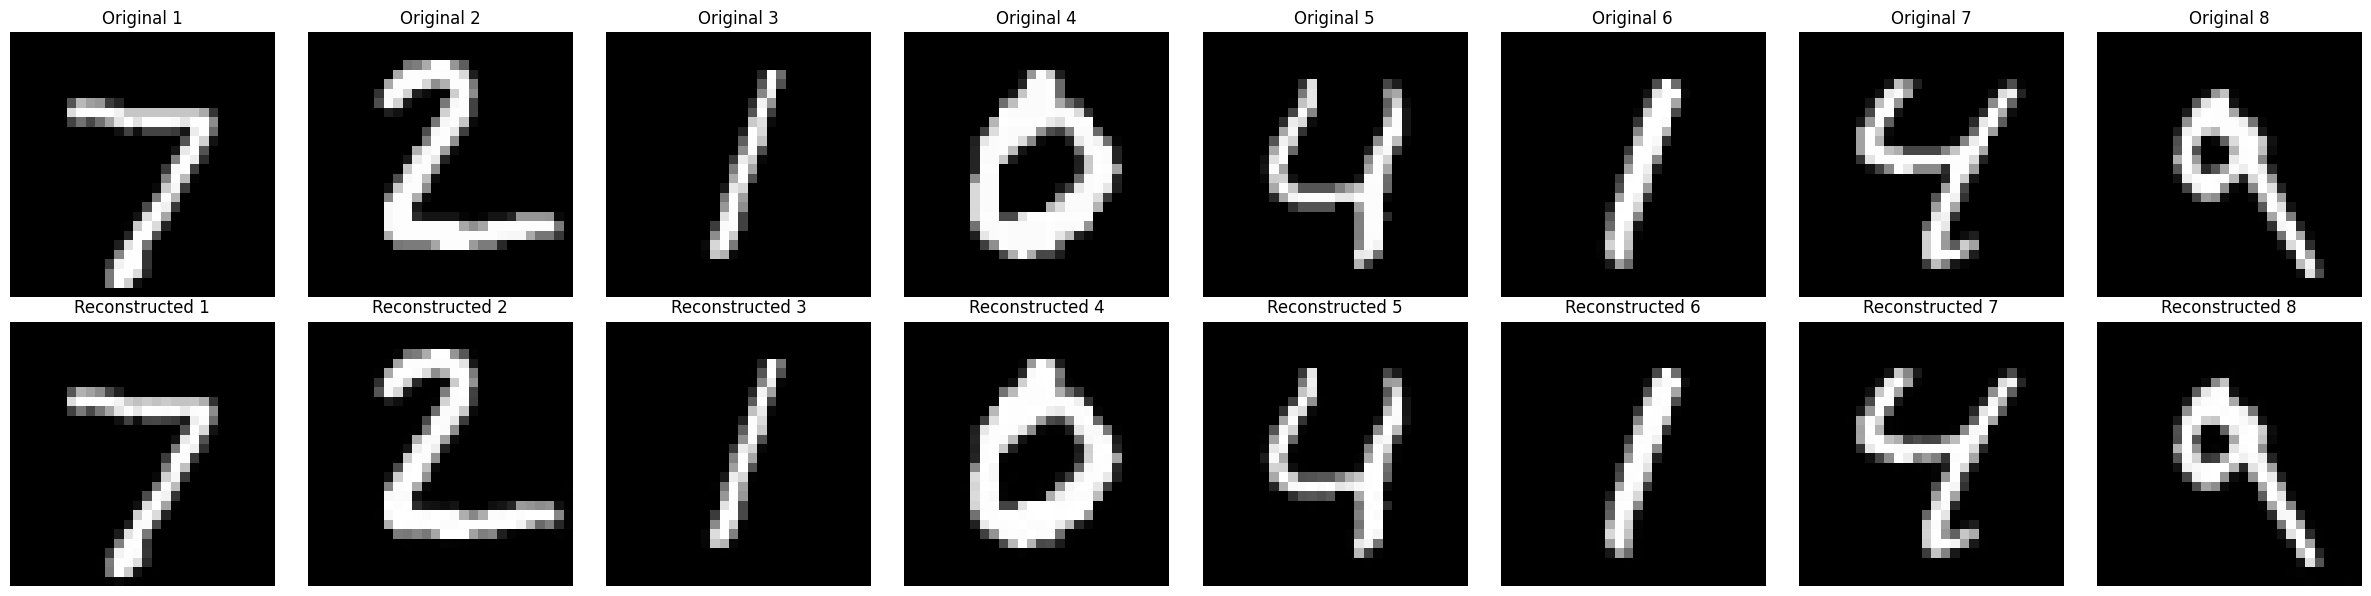

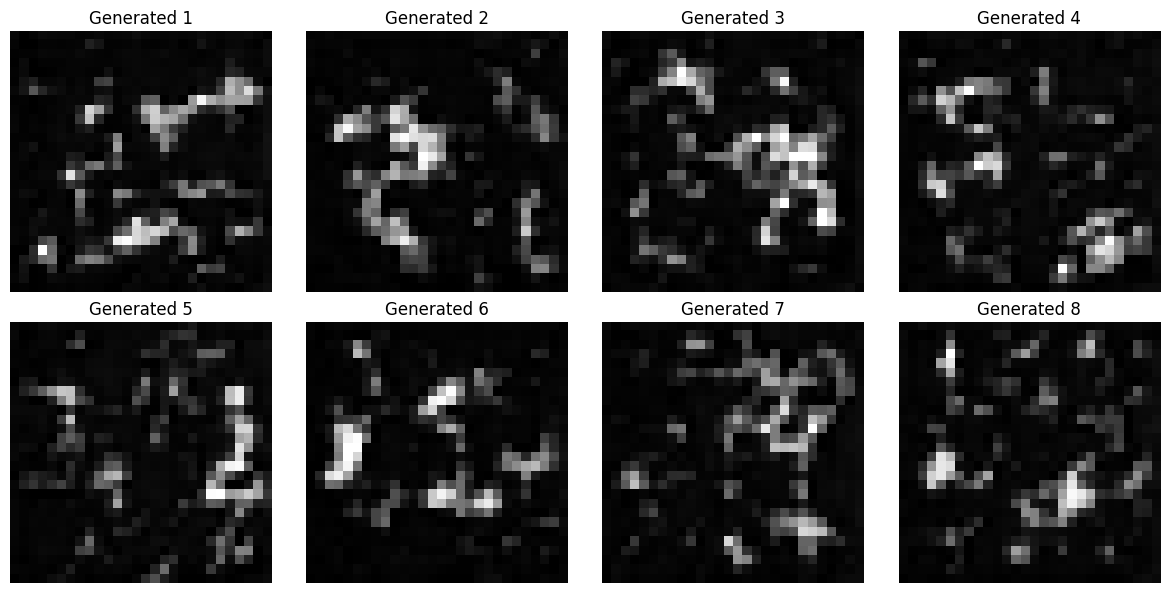


test evaluation results
  L1    : 0.007210
  MSE   : 0.000330
  LPIPS : 0.000706
  PSNR  : 41.1177 dB
  SSIM  : 0.999041
  FID   : 0.3298
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.13it/s, rec=0.0395, g=0.0000, d=N/A, KL=1634.0308]



Epoch 1/10 [vae]
  Train - Rec: 0.0797, Reg(vae): 1541.4158, Disc: 0.0000
  Val   - Rec Loss: 0.0385
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0385)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:59<00:00, 14.25it/s, rec=0.0291, g=0.0000, d=N/A, KL=1592.0088]



Epoch 2/10 [vae]
  Train - Rec: 0.0344, Reg(vae): 1607.1682, Disc: 0.0000
  Val   - Rec Loss: 0.0274
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0274)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0108, Reg(vae): 1442.2251, Disc: 1.0000
  Val   - Rec Loss: 0.0111
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0111)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:25<00:00,  9.89it/s, rec=0.0094, g=-0.0125, d=1.0000, KL=1423.8245]



Epoch 9/10 [vae]
  Train - Rec: 0.0095, Reg(vae): 1439.6982, Disc: 1.0000
  Val   - Rec Loss: 0.0093
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0093)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:24<00:00,  9.94it/s, rec=0.0092, g=0.0569, d=1.0000, KL=1463.1006] 



Epoch 10/10 [vae]
  Train - Rec: 0.0087, Reg(vae): 1438.0522, Disc: 1.0000
  Val   - Rec Loss: 0.0085
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0085)

[vae] 训练完成! 最佳验证损失: 0.0085


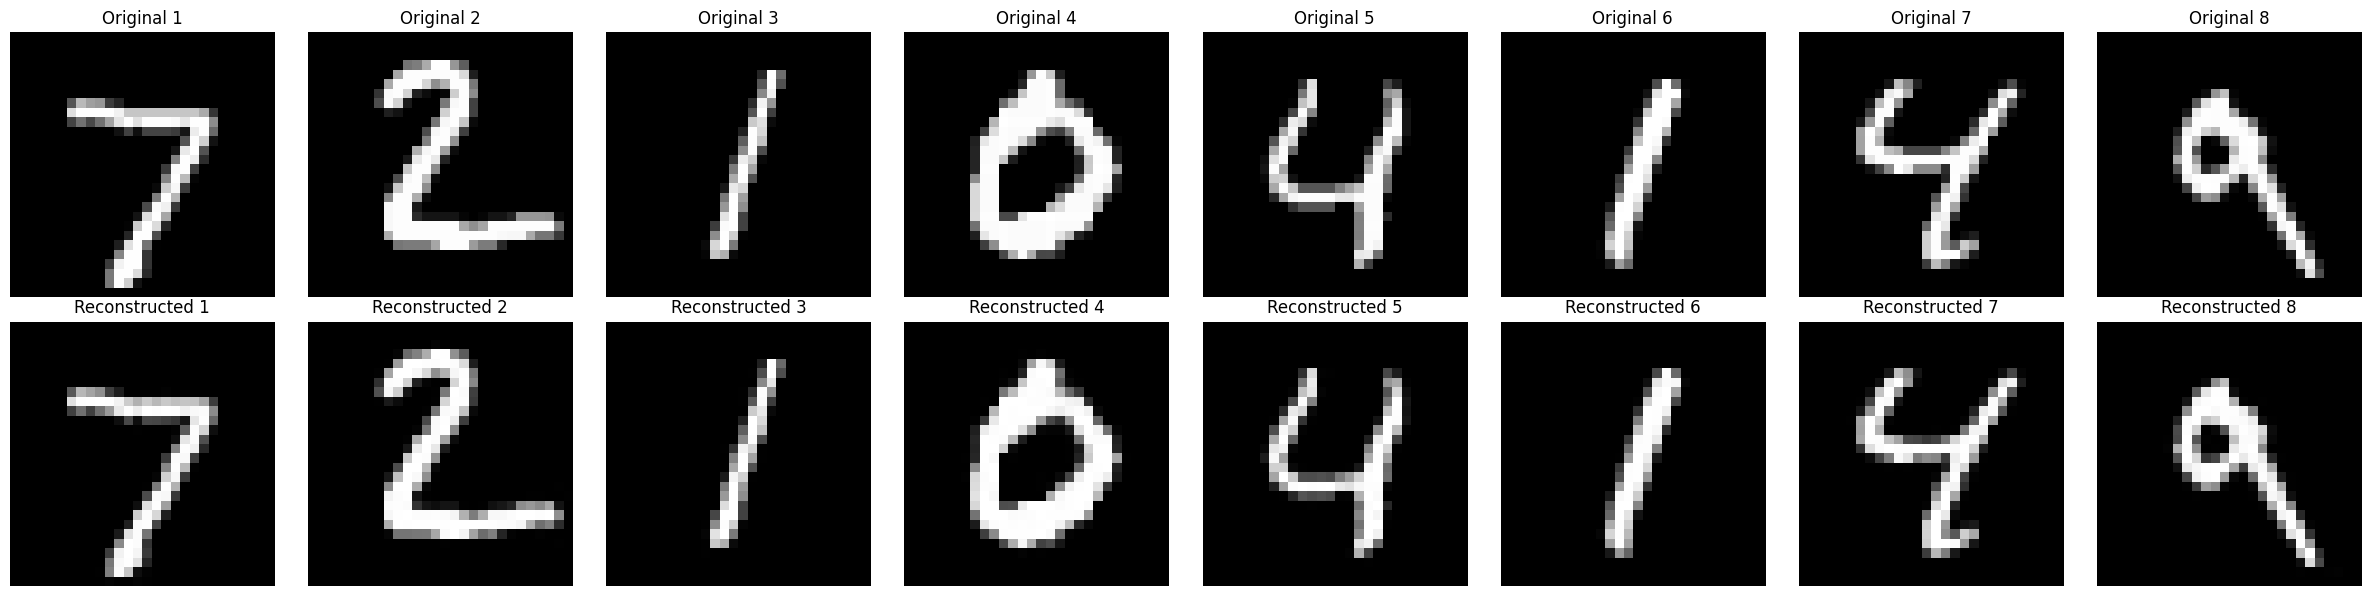

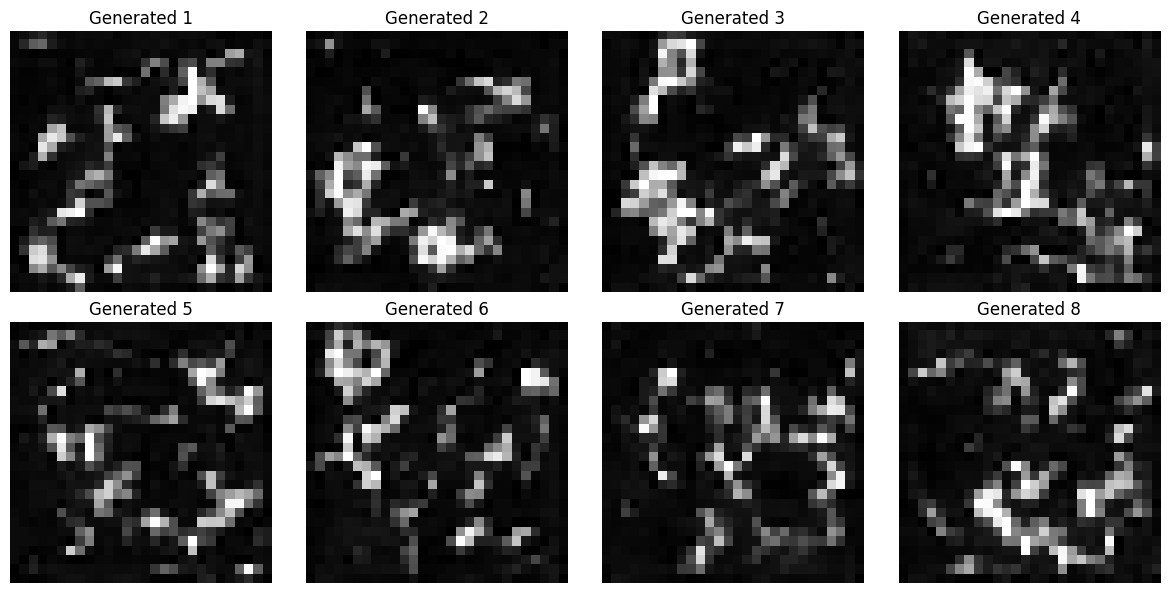


test evaluation results
  L1    : 0.008176
  MSE   : 0.000458
  LPIPS : 0.000985
  PSNR  : 39.6480 dB
  SSIM  : 0.998708
  FID   : 0.4341
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.29it/s, rec=0.0344, g=0.0000, d=N/A, KL=1599.1355]



Epoch 1/10 [vae]
  Train - Rec: 0.0861, Reg(vae): 1547.9398, Disc: 0.0000
  Val   - Rec Loss: 0.0396
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0396)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:55<00:00, 15.30it/s, rec=0.0276, g=0.0000, d=N/A, KL=1640.7563]



Epoch 2/10 [vae]
  Train - Rec: 0.0324, Reg(vae): 1631.3528, Disc: 0.0000
  Val   - Rec Loss: 0.0252
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0252)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0106, Reg(vae): 1507.4641, Disc: 1.0000
  Val   - Rec Loss: 0.0105
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0105)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:31<00:00,  9.25it/s, rec=0.0089, g=0.1122, d=1.0000, KL=1501.9933]



Epoch 9/10 [vae]
  Train - Rec: 0.0093, Reg(vae): 1517.5390, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0088)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:23<00:00, 10.08it/s, rec=0.0084, g=0.1322, d=1.0000, KL=1542.1284]



Epoch 10/10 [vae]
  Train - Rec: 0.0086, Reg(vae): 1525.6783, Disc: 1.0000
  Val   - Rec Loss: 0.0083
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0083)

[vae] 训练完成! 最佳验证损失: 0.0083


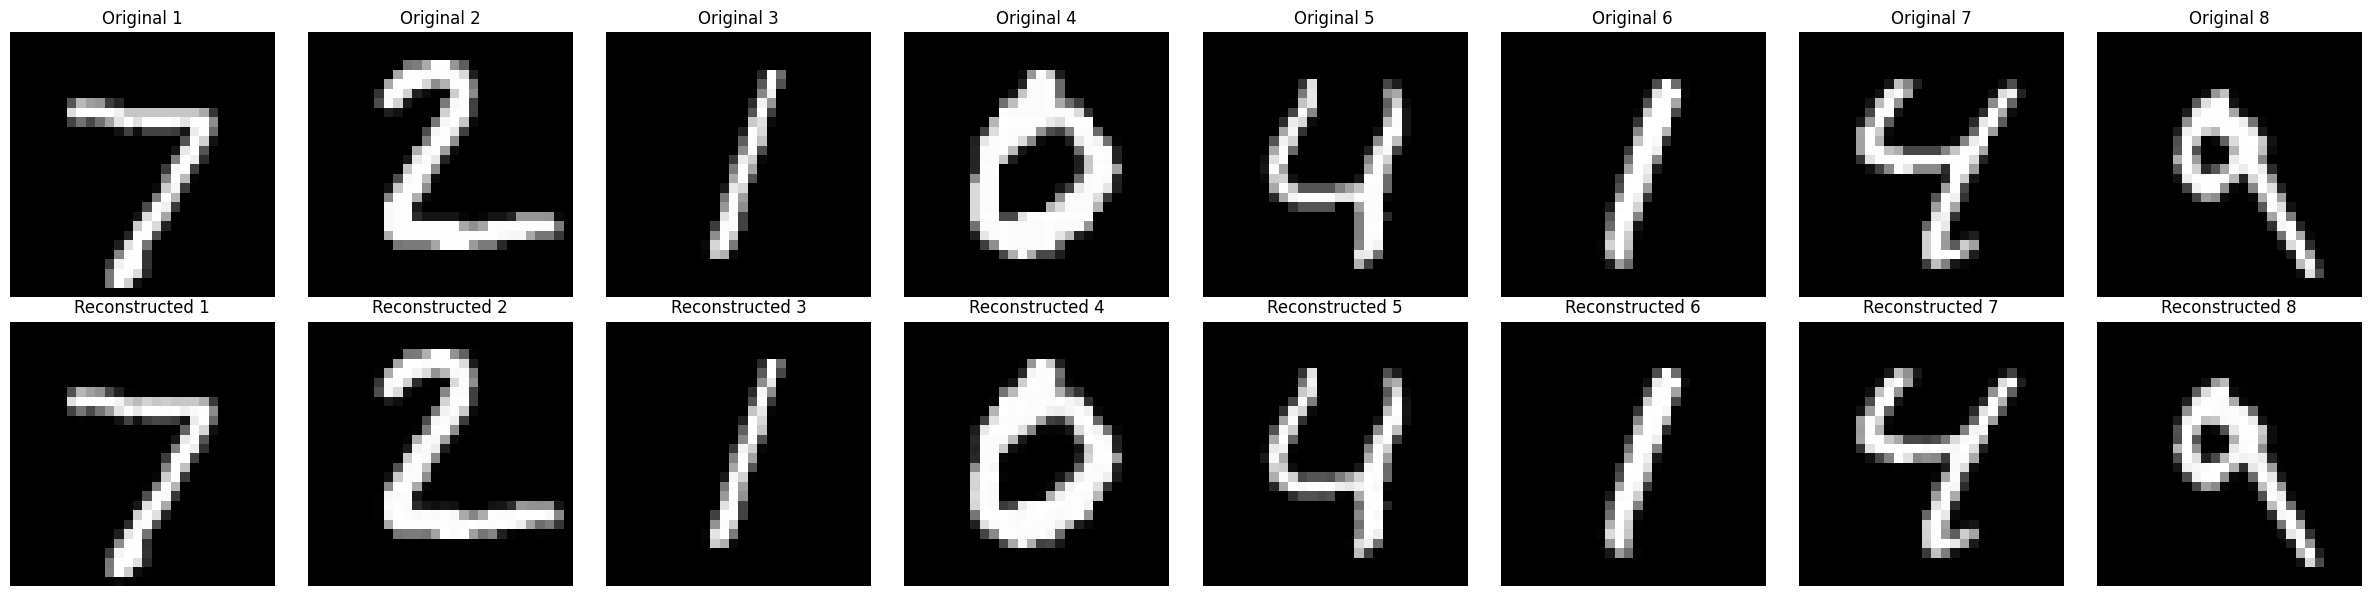

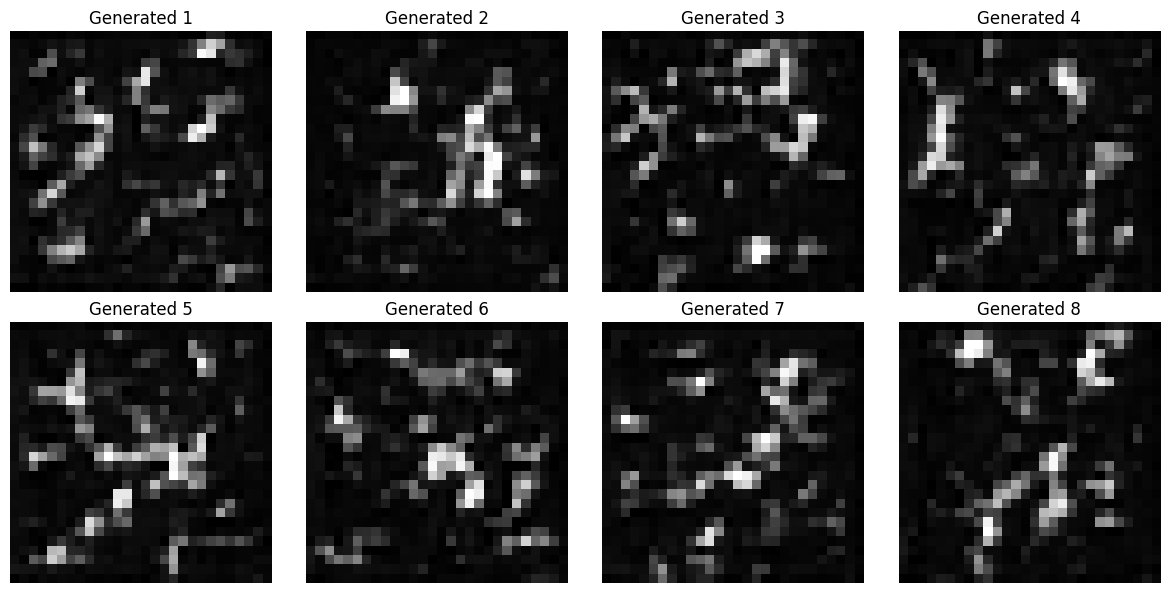


test evaluation results
  L1    : 0.007957
  MSE   : 0.000442
  LPIPS : 0.000926
  PSNR  : 39.7756 dB
  SSIM  : 0.998402
  FID   : 0.4463
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*KL + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 843/843 [00:57<00:00, 14.74it/s, rec=0.0349, g=0.0000, d=N/A, KL=1710.4530]



Epoch 1/10 [vae]
  Train - Rec: 0.0834, Reg(vae): 1403.2094, Disc: 0.0000
  Val   - Rec Loss: 0.0383
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0383)


Epoch 2 [vae]: 100%|██████████| 843/843 [00:56<00:00, 15.02it/s, rec=0.0288, g=0.0000, d=N/A, KL=1726.9735]



Epoch 2/10 [vae]
  Train - Rec: 0.0352, Reg(vae): 1707.1997, Disc: 0.0000
  Val   - Rec Loss: 0.0315
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0315)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0108, Reg(vae): 1717.8132, Disc: 1.0095
  Val   - Rec Loss: 0.0112
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0112)


Epoch 9 [vae]: 100%|██████████| 843/843 [01:25<00:00,  9.84it/s, rec=0.0094, g=0.0765, d=0.9824, KL=1705.7048] 



Epoch 9/10 [vae]
  Train - Rec: 0.0096, Reg(vae): 1724.1186, Disc: 0.9970
  Val   - Rec Loss: 0.0092
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0092)


Epoch 10 [vae]: 100%|██████████| 843/843 [01:32<00:00,  9.11it/s, rec=0.0088, g=-0.0378, d=0.9818, KL=1738.1265]



Epoch 10/10 [vae]
  Train - Rec: 0.0089, Reg(vae): 1728.8543, Disc: 0.9849
  Val   - Rec Loss: 0.0090
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0090)

[vae] 训练完成! 最佳验证损失: 0.0090


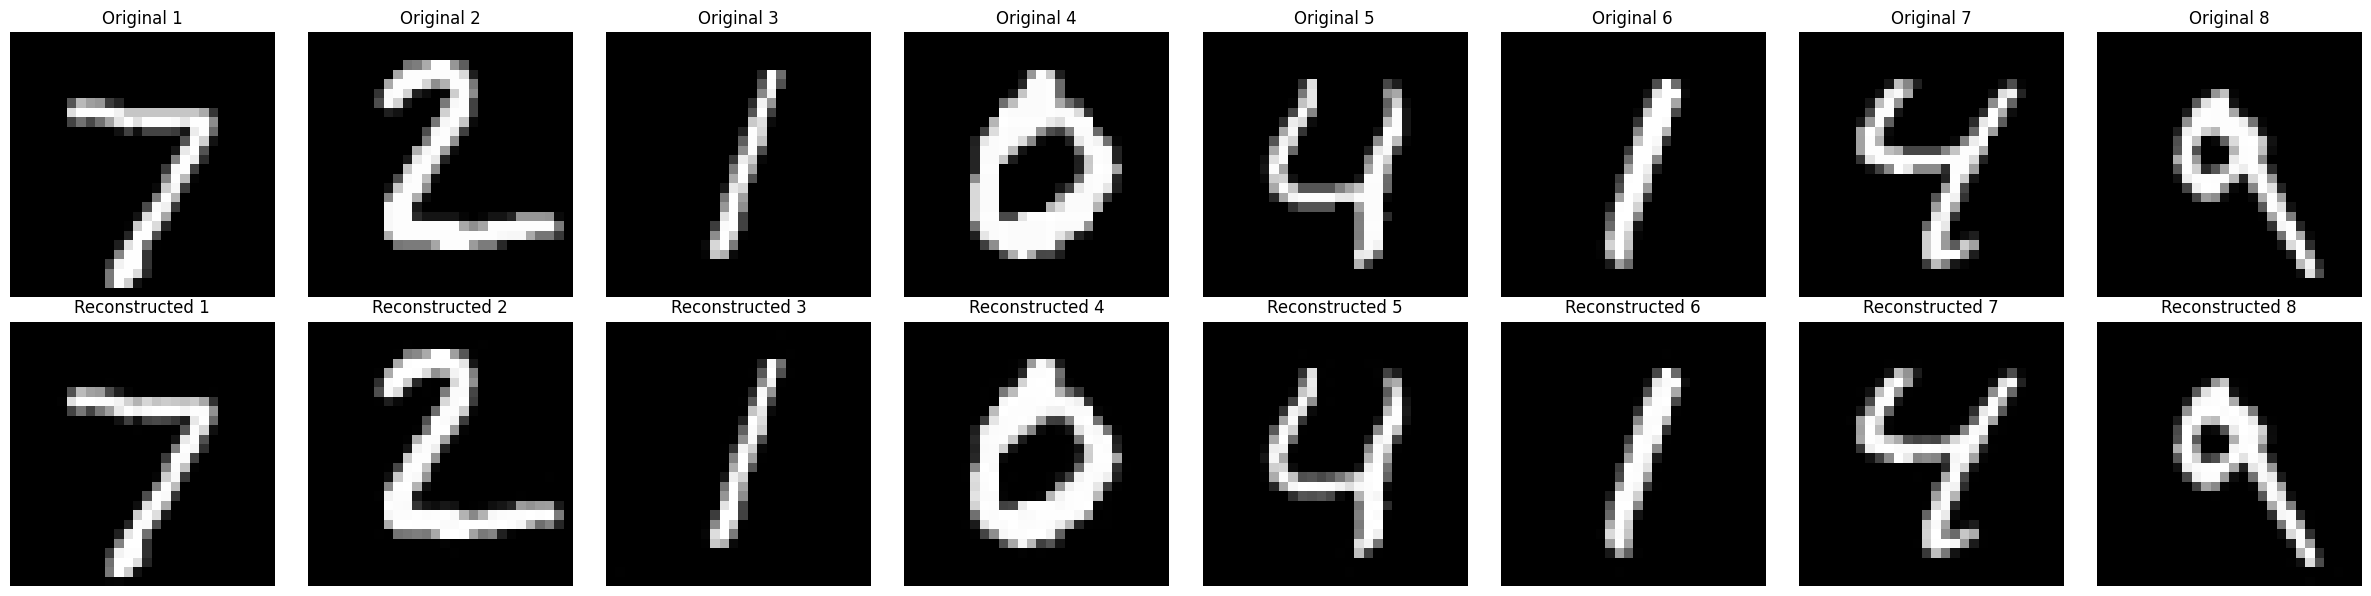

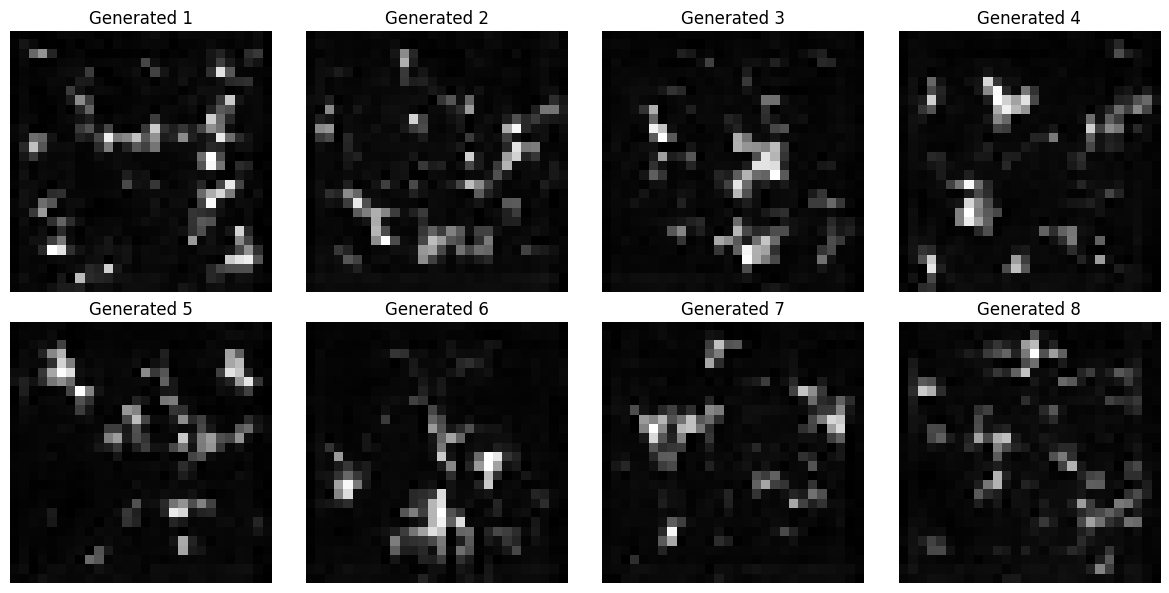


test evaluation results
  L1    : 0.008709
  MSE   : 0.000490
  LPIPS : 0.001056
  PSNR  : 39.3289 dB
  SSIM  : 0.997518
  FID   : 0.4822
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-06/eval_test_vae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[vae] 最终评估完成。


In [17]:
for w in [1e-5,1e-6]:
    for rep in range(7): 
        _ = run_training("vae", kl_weight=w, run_tag=f"vae_kl_{w:.0e}")


### run sd (ours)

[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:37<00:00,  5.35it/s, rec=0.0429, g=0.0000, d=N/A, Dq=-438.6215, KLt=49481.4062]



Epoch 1/10 [sd]
  Train - Rec: 0.0850, Reg(sd): -0.0034, Disc: 0.0000
  Val   - Rec Loss: 0.0384
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0384)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:48<00:00,  5.02it/s, rec=0.0280, g=0.0000, d=N/A, Dq=-483.8049, KLt=12132.2070]



Epoch 2/10 [sd]
  Train - Rec: 0.0340, Reg(sd): -0.0047, Disc: 0.0000
  Val   - Rec Loss: 0.0279
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0279)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0113, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0107
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0107)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.59it/s, rec=0.0100, g=0.2420, d=1.0000, Dq=-511.2860, KLt=1837.0342]



Epoch 9/10 [sd]
  Train - Rec: 0.0100, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0100
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0100)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:11<00:00,  4.41it/s, rec=0.0087, g=0.3139, d=1.0000, Dq=-512.8109, KLt=2018.9182]



Epoch 10/10 [sd]
  Train - Rec: 0.0093, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0091
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0091)

[sd] 训练完成! 最佳验证损失: 0.0091


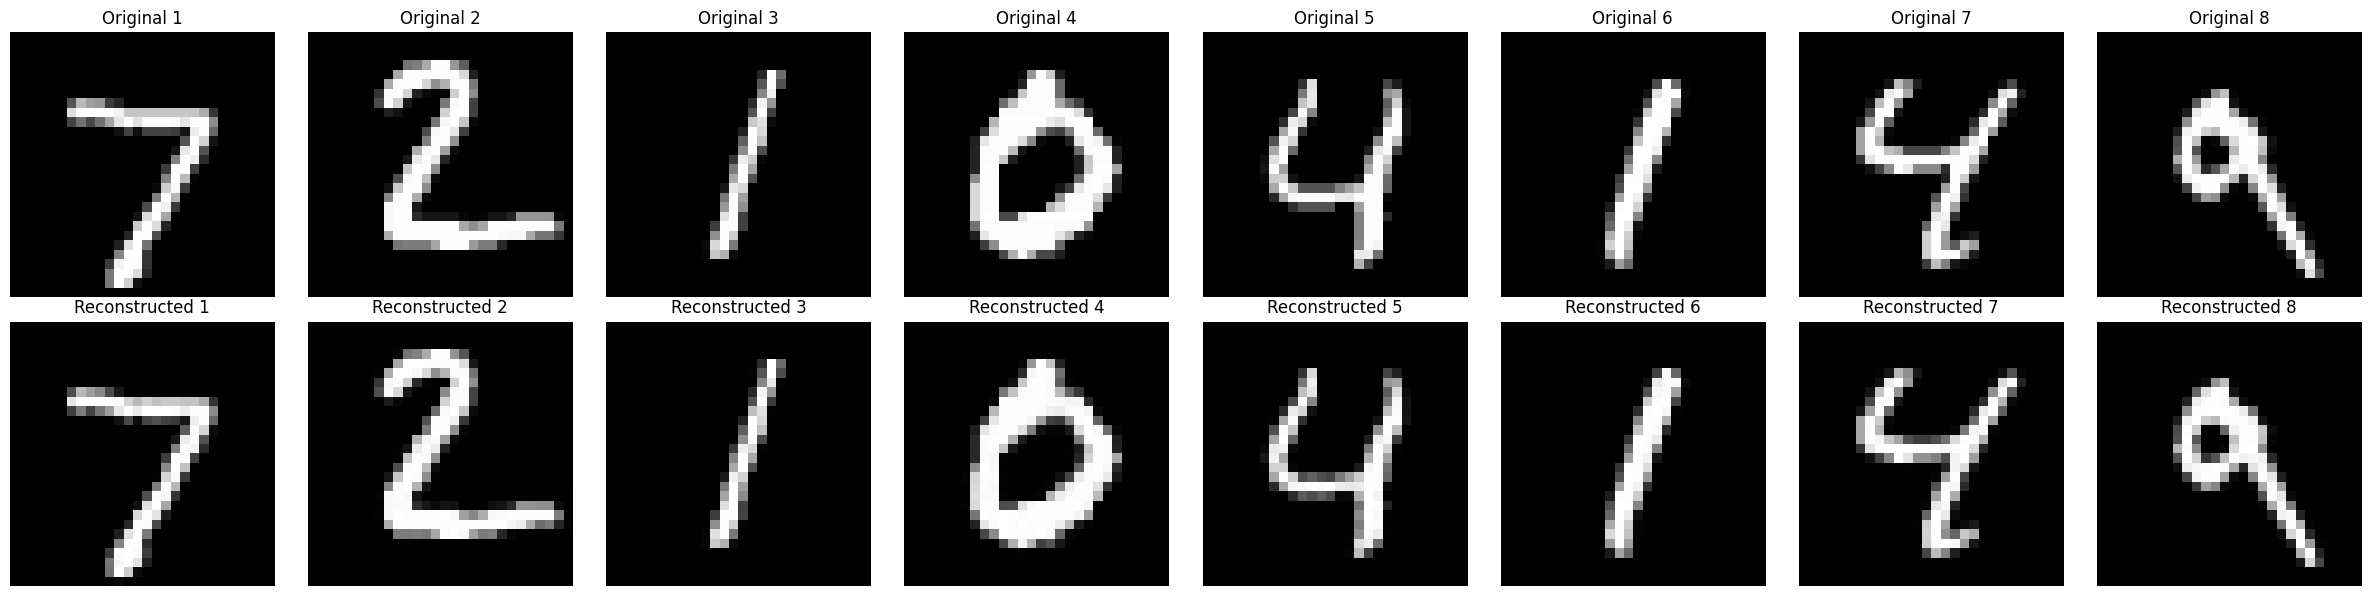

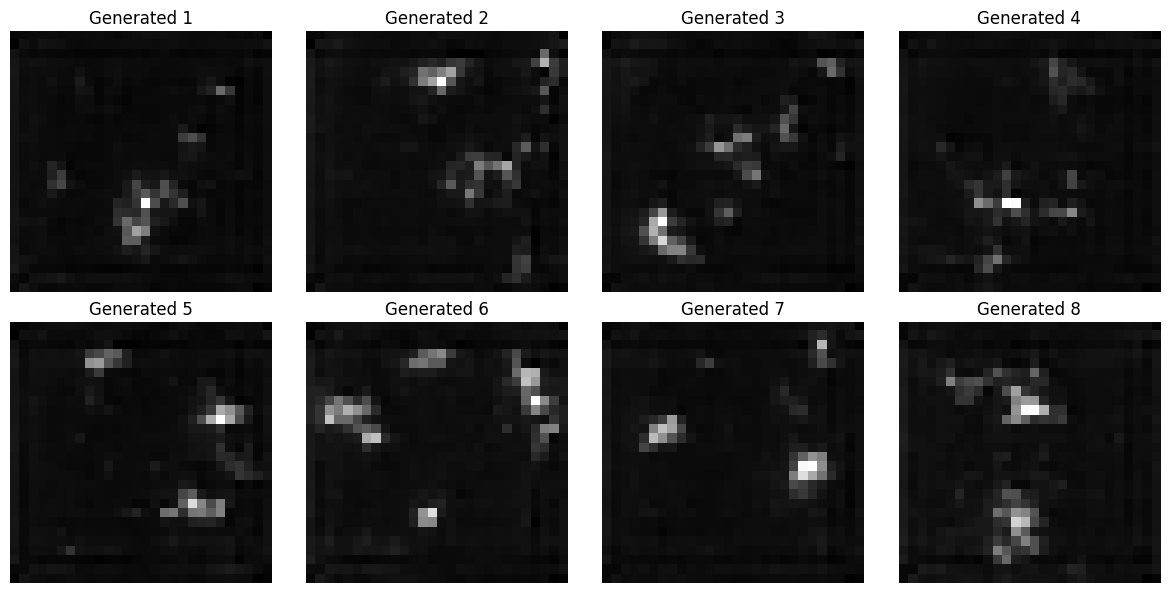


test evaluation results
  L1    : 0.008719
  MSE   : 0.000516
  LPIPS : 0.001140
  PSNR  : 39.0999 dB
  SSIM  : 0.998620
  FID   : 0.5456
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.53it/s, rec=0.0351, g=0.0000, d=N/A, Dq=-465.1563, KLt=56648.2344]



Epoch 1/10 [sd]
  Train - Rec: 0.0783, Reg(sd): -0.0035, Disc: 0.0000
  Val   - Rec Loss: 0.0406
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0406)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:35<00:00,  5.41it/s, rec=0.0298, g=0.0000, d=N/A, Dq=-492.9777, KLt=6773.7778] 



Epoch 2/10 [sd]
  Train - Rec: 0.0322, Reg(sd): -0.0048, Disc: 0.0000
  Val   - Rec Loss: 0.0257
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0257)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0110, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0111
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0111)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:14<00:00,  4.34it/s, rec=0.0089, g=0.0544, d=1.0000, Dq=-522.3702, KLt=1578.2080] 



Epoch 9/10 [sd]
  Train - Rec: 0.0097, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0091
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0091)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:01<00:00,  4.65it/s, rec=0.0088, g=0.0698, d=1.0000, Dq=-514.6252, KLt=1505.2666]



Epoch 10/10 [sd]
  Train - Rec: 0.0090, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0091
  AE LR: 2.88e-05
  Global Step: 8430

[sd] 训练完成! 最佳验证损失: 0.0091


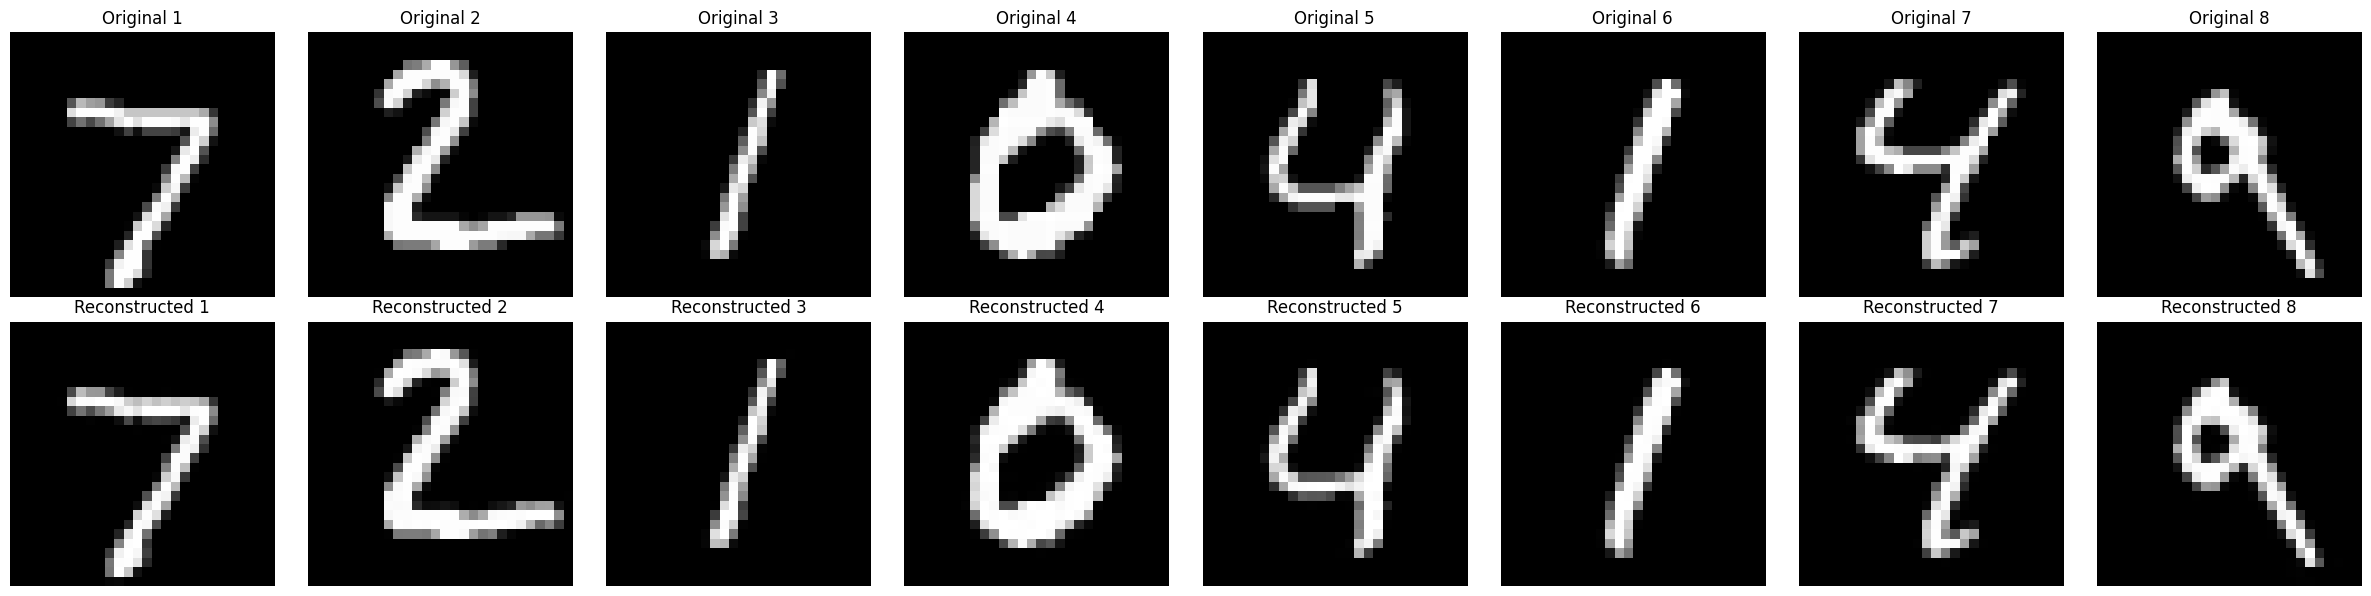

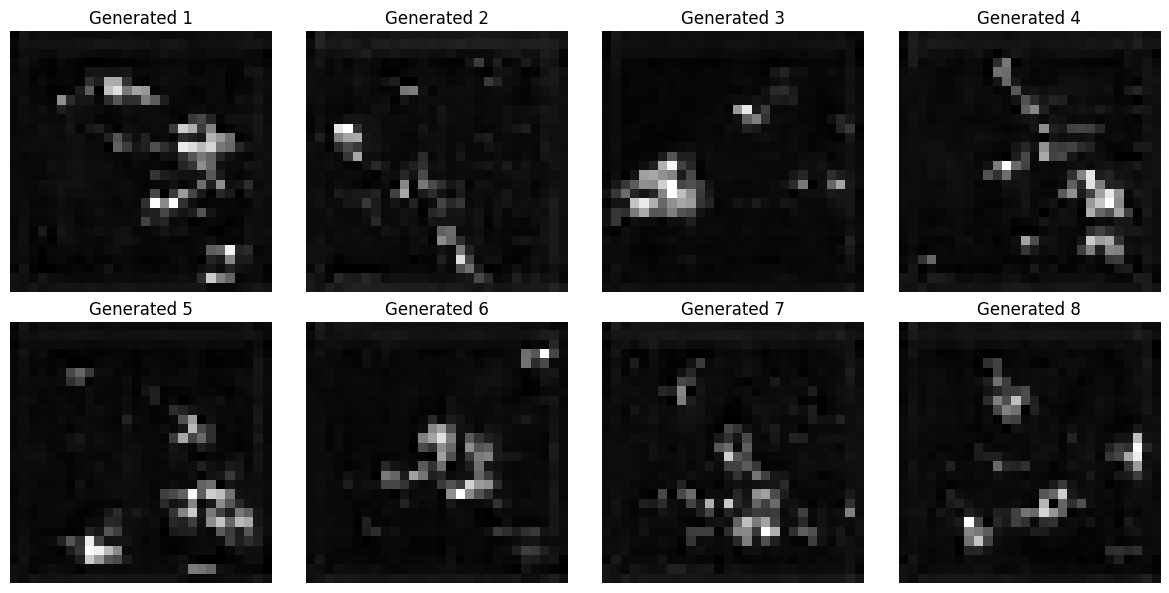


test evaluation results
  L1    : 0.008766
  MSE   : 0.000494
  LPIPS : 0.001072
  PSNR  : 39.3350 dB
  SSIM  : 0.998633
  FID   : 0.4218
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:42<00:00,  5.19it/s, rec=0.0442, g=0.0000, d=N/A, Dq=-421.0721, KLt=55249.2852]



Epoch 1/10 [sd]
  Train - Rec: 0.0926, Reg(sd): -0.0030, Disc: 0.0000
  Val   - Rec Loss: 0.0384
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0384)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:34<00:00,  5.46it/s, rec=0.0310, g=0.0000, d=N/A, Dq=-449.8701, KLt=11958.8271]



Epoch 2/10 [sd]
  Train - Rec: 0.0359, Reg(sd): -0.0044, Disc: 0.0000
  Val   - Rec Loss: 0.0300
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0300)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0108, Reg(sd): -0.0047, Disc: 0.9580
  Val   - Rec Loss: 0.0105
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0105)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:14<00:00,  4.34it/s, rec=0.0099, g=-0.6705, d=0.9131, Dq=-480.0217, KLt=2809.9858]



Epoch 9/10 [sd]
  Train - Rec: 0.0096, Reg(sd): -0.0048, Disc: 0.9346
  Val   - Rec Loss: 0.0092
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0092)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.39it/s, rec=0.0086, g=-0.8094, d=0.9524, Dq=-471.5638, KLt=1347.0540]



Epoch 10/10 [sd]
  Train - Rec: 0.0089, Reg(sd): -0.0048, Disc: 0.8982
  Val   - Rec Loss: 0.0089
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0089)

[sd] 训练完成! 最佳验证损失: 0.0089


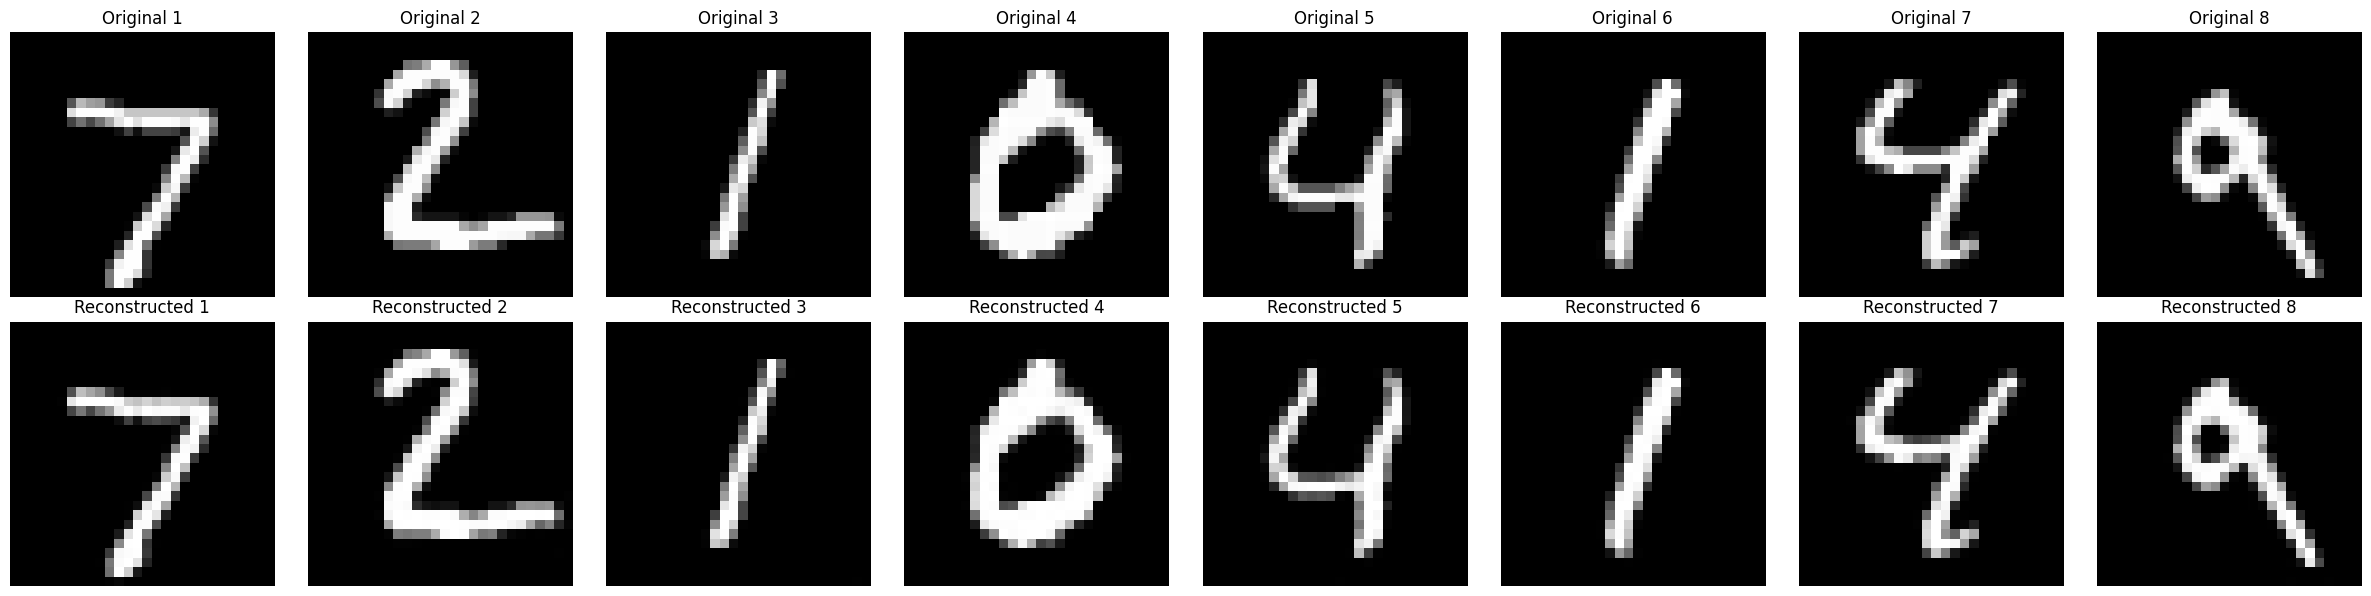

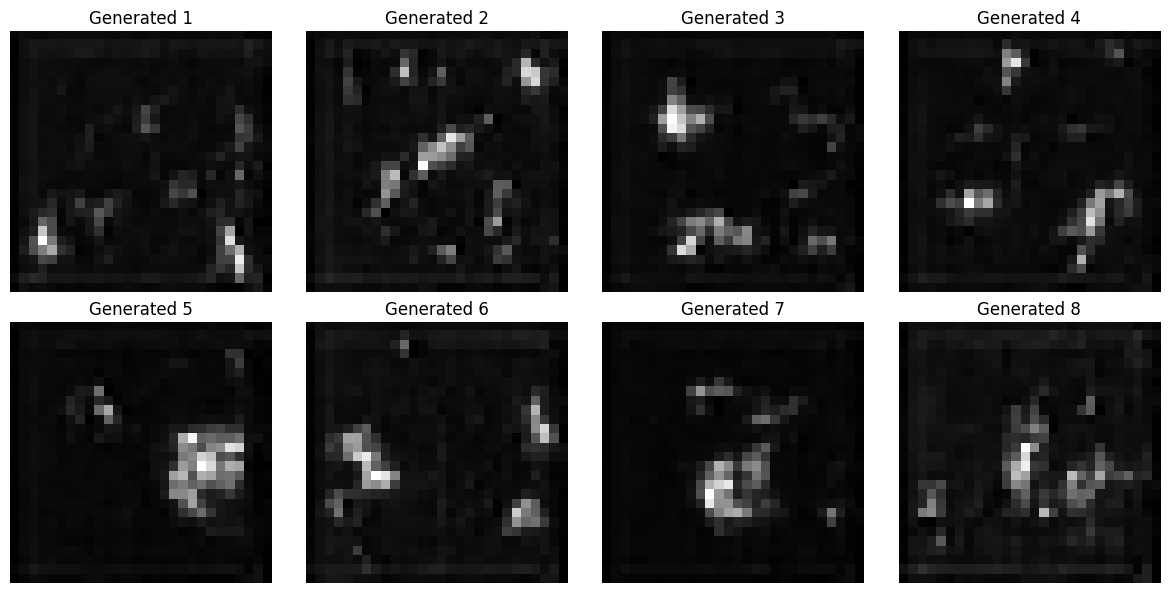


test evaluation results
  L1    : 0.008509
  MSE   : 0.000502
  LPIPS : 0.001040
  PSNR  : 39.2811 dB
  SSIM  : 0.998644
  FID   : 0.4183
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:43<00:00,  5.15it/s, rec=0.0370, g=0.0000, d=N/A, Dq=-478.4066, KLt=52507.5273]



Epoch 1/10 [sd]
  Train - Rec: 0.0784, Reg(sd): -0.0041, Disc: 0.0000
  Val   - Rec Loss: 0.0405
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0405)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:41<00:00,  5.21it/s, rec=0.0277, g=0.0000, d=N/A, Dq=-548.3965, KLt=9726.6211] 



Epoch 2/10 [sd]
  Train - Rec: 0.0320, Reg(sd): -0.0051, Disc: 0.0000
  Val   - Rec Loss: 0.0272
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0272)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0108, Reg(sd): -0.0058, Disc: 1.0000
  Val   - Rec Loss: 0.0100
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0100)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.37it/s, rec=0.0104, g=0.0483, d=1.0000, Dq=-583.4808, KLt=1556.4268]



Epoch 9/10 [sd]
  Train - Rec: 0.0096, Reg(sd): -0.0058, Disc: 1.0000
  Val   - Rec Loss: 0.0094
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0094)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.38it/s, rec=0.0088, g=0.0469, d=1.0000, Dq=-582.5814, KLt=1872.9128]



Epoch 10/10 [sd]
  Train - Rec: 0.0089, Reg(sd): -0.0058, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0088)

[sd] 训练完成! 最佳验证损失: 0.0088


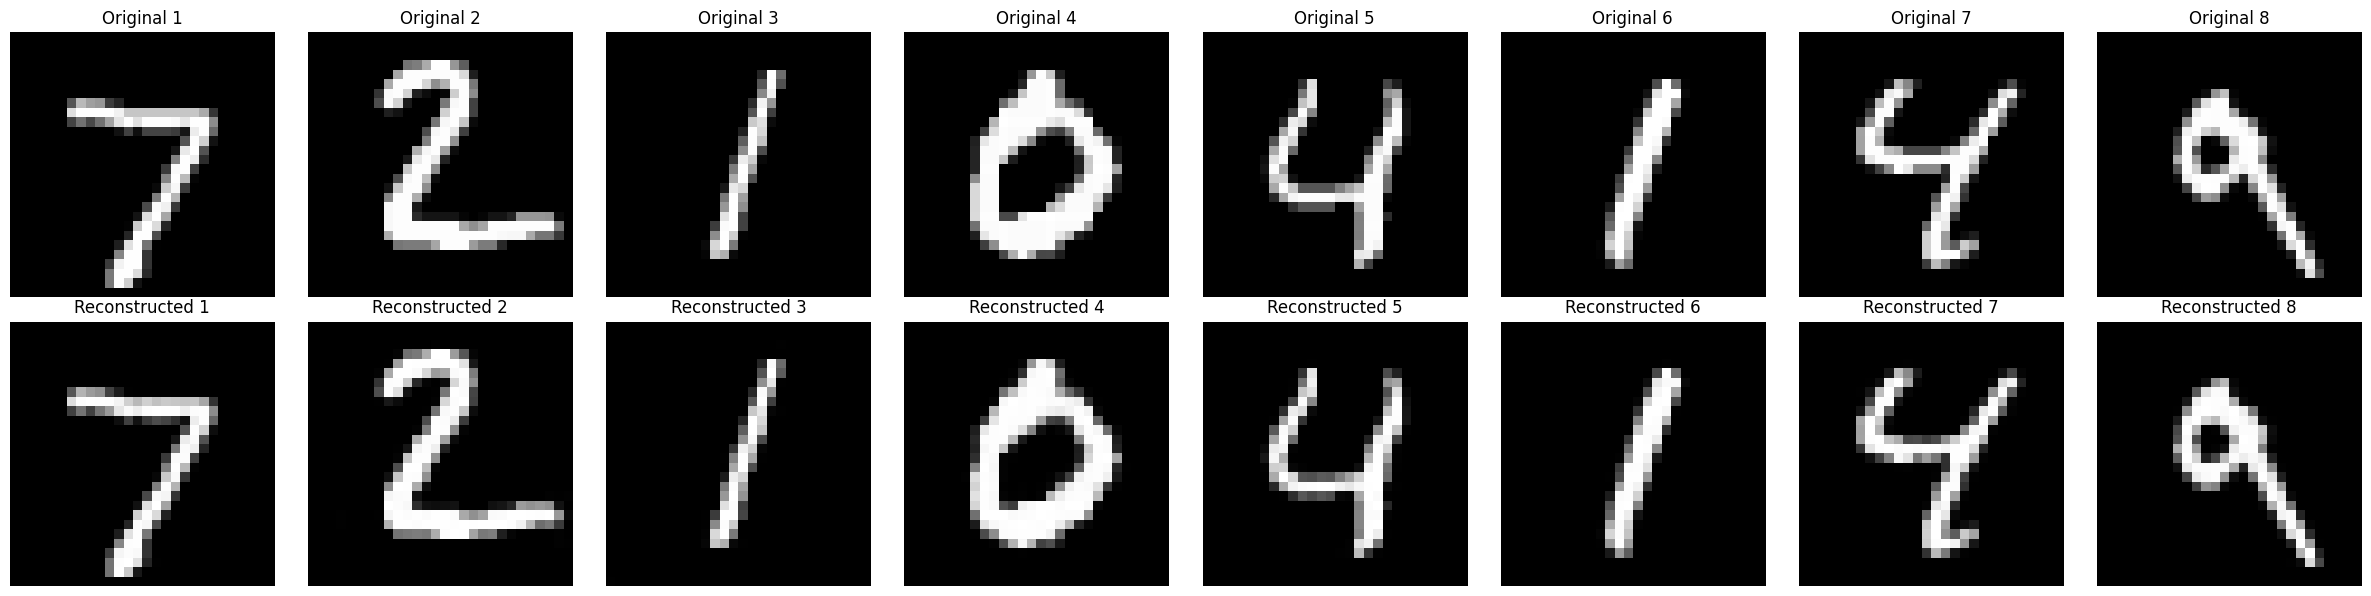

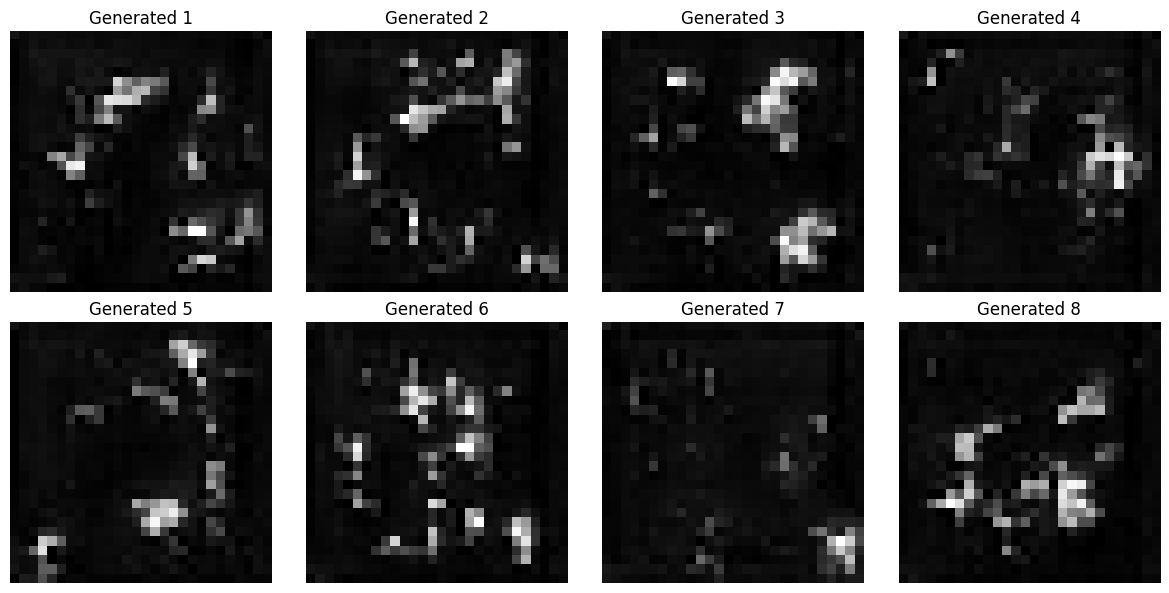


test evaluation results
  L1    : 0.008392
  MSE   : 0.000478
  LPIPS : 0.001040
  PSNR  : 39.4510 dB
  SSIM  : 0.998703
  FID   : 0.4442
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.11it/s, rec=0.0375, g=0.0000, d=N/A, Dq=50.2143, KLt=70218.1250]  



Epoch 1/10 [sd]
  Train - Rec: 0.0801, Reg(sd): 0.0006, Disc: 0.0000
  Val   - Rec Loss: 0.0389
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0389)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:39<00:00,  5.27it/s, rec=0.0251, g=0.0000, d=N/A, Dq=-8.1541, KLt=12110.4727] 



Epoch 2/10 [sd]
  Train - Rec: 0.0321, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0244
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0244)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0104, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0104
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0104)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:10<00:00,  4.43it/s, rec=0.0086, g=0.0737, d=1.0000, Dq=-0.6582, KLt=2636.0466]



Epoch 9/10 [sd]
  Train - Rec: 0.0092, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0091
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0091)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.59it/s, rec=0.0085, g=0.0900, d=1.0000, Dq=-1.0481, KLt=1943.5051]



Epoch 10/10 [sd]
  Train - Rec: 0.0085, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0084
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0084)

[sd] 训练完成! 最佳验证损失: 0.0084


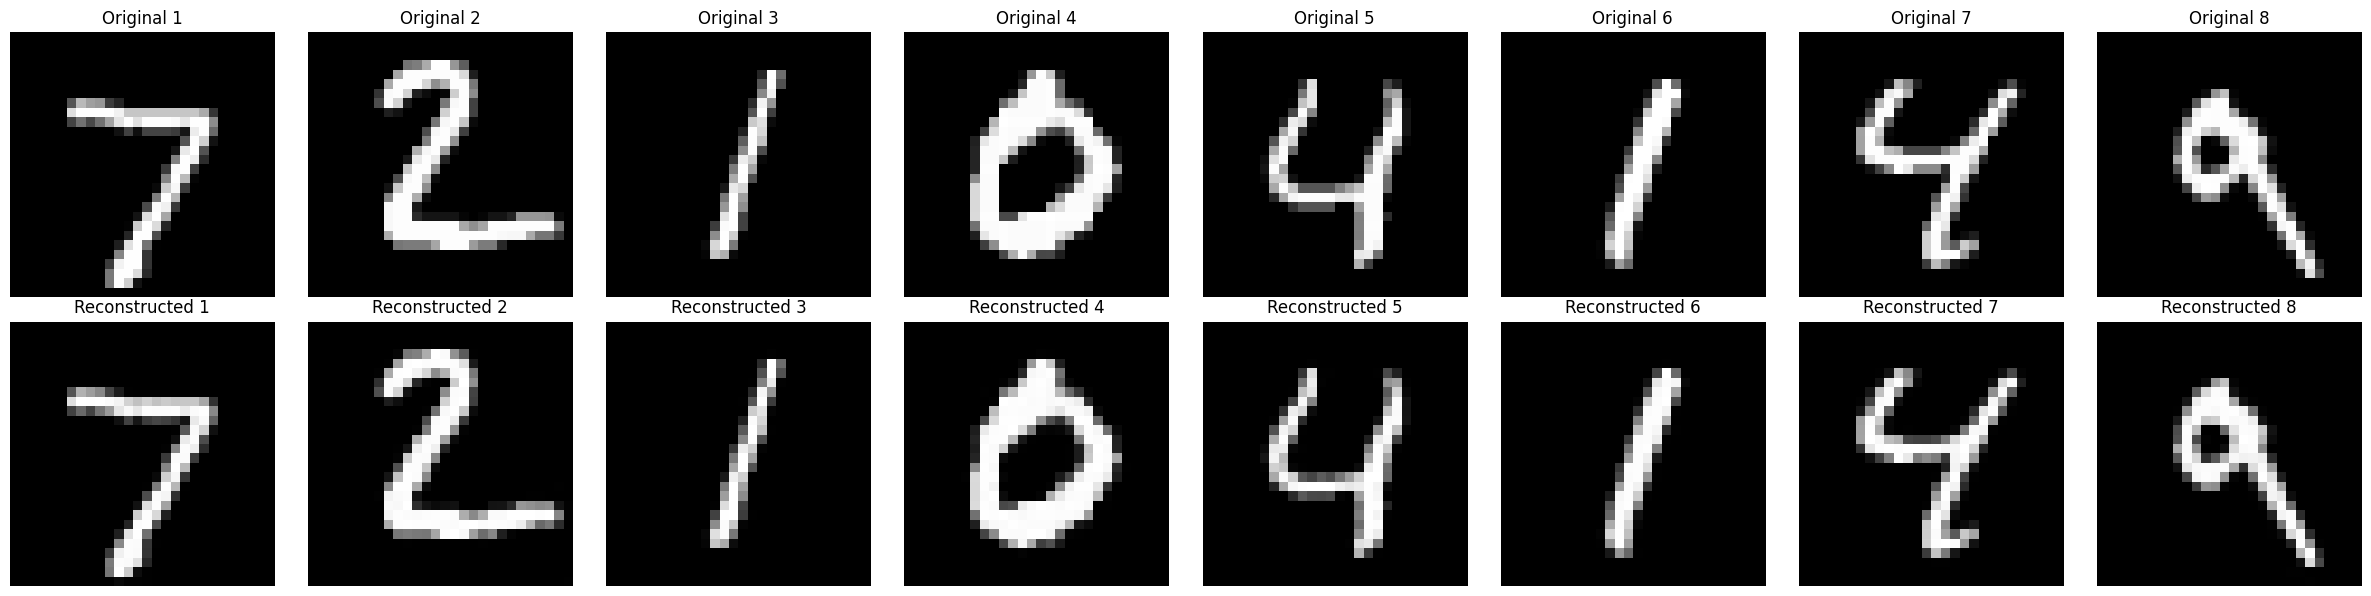

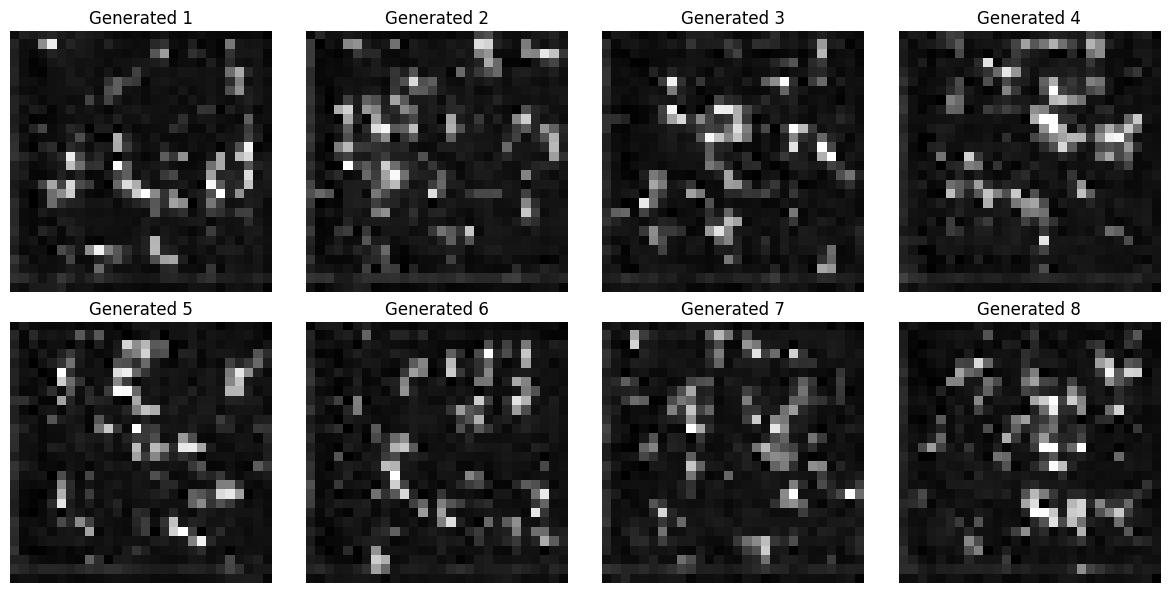


test evaluation results
  L1    : 0.008053
  MSE   : 0.000441
  LPIPS : 0.000932
  PSNR  : 39.7927 dB
  SSIM  : 0.998781
  FID   : 0.4440
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-08/eval_test_dq_1e-06_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:52<00:00,  4.88it/s, rec=0.0348, g=0.0000, d=N/A, Dq=-23.1336, KLt=60589.1406] 



Epoch 1/10 [sd]
  Train - Rec: 0.0803, Reg(sd): 0.0004, Disc: 0.0000
  Val   - Rec Loss: 0.0399
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0399)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:39<00:00,  5.29it/s, rec=0.0258, g=0.0000, d=N/A, Dq=-10.9065, KLt=11646.8984]



Epoch 2/10 [sd]
  Train - Rec: 0.0322, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0318
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0318)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0103, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0104
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0104)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:14<00:00,  4.34it/s, rec=0.0086, g=0.0243, d=1.0000, Dq=-0.6316, KLt=2260.9746] 



Epoch 9/10 [sd]
  Train - Rec: 0.0090, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0090
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0090)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:01<00:00,  4.66it/s, rec=0.0085, g=0.0259, d=1.0000, Dq=-0.6966, KLt=2090.1094] 



Epoch 10/10 [sd]
  Train - Rec: 0.0083, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0081
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0081)

[sd] 训练完成! 最佳验证损失: 0.0081


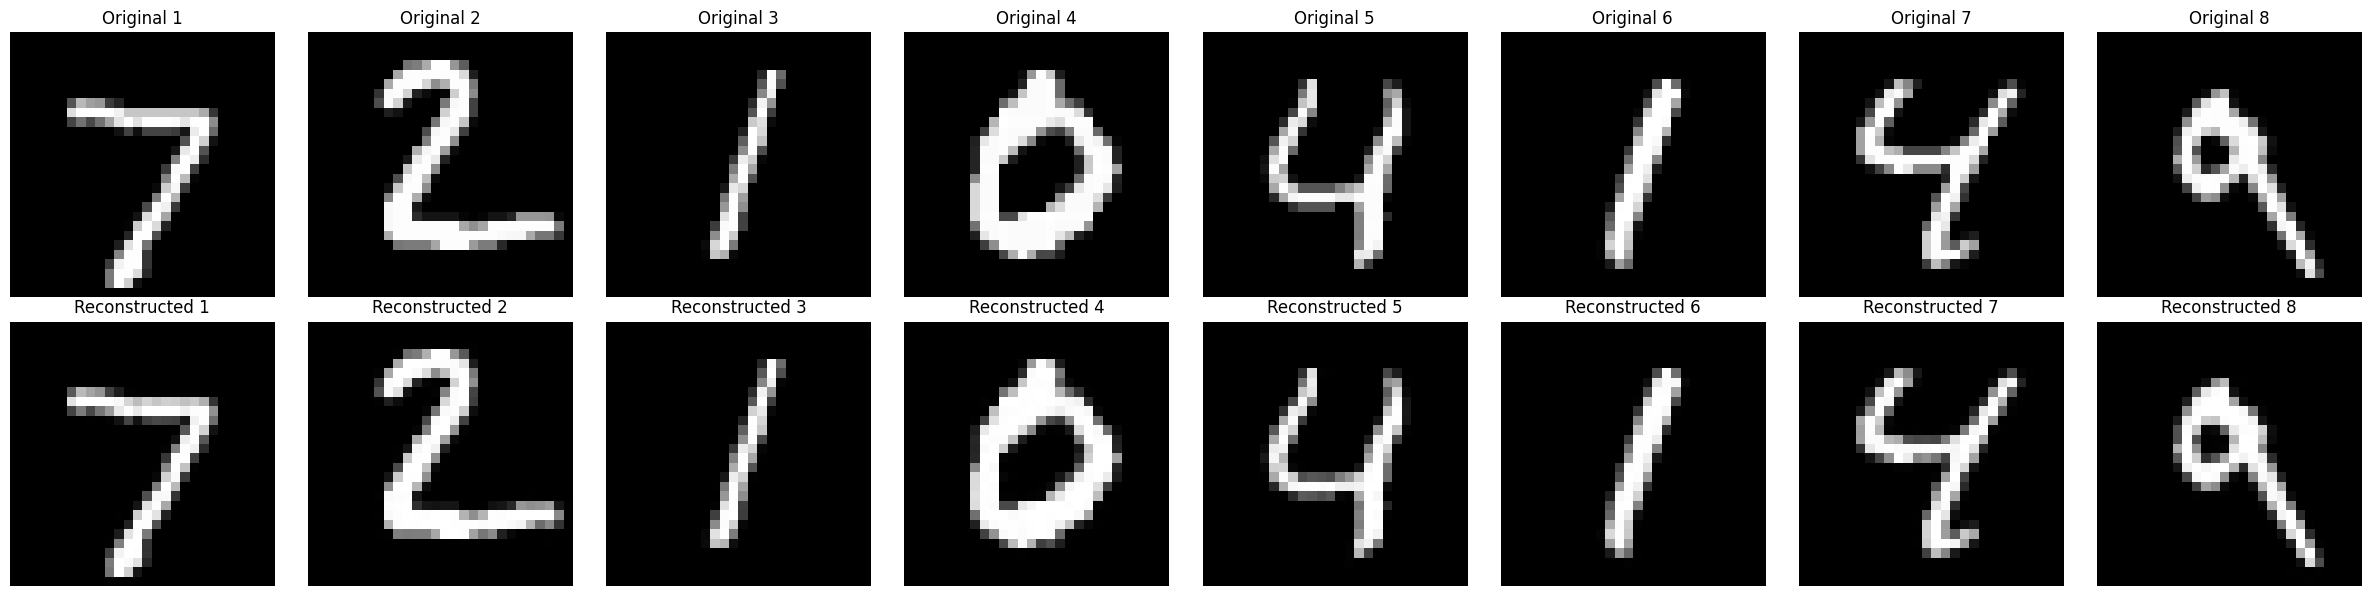

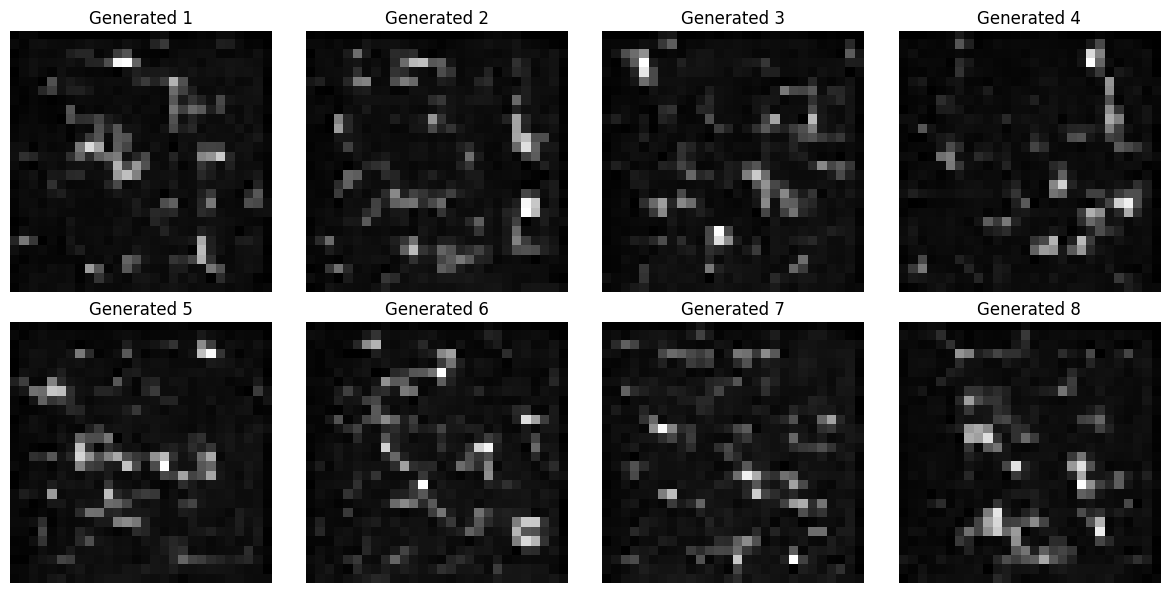


test evaluation results
  L1    : 0.007802
  MSE   : 0.000411
  LPIPS : 0.000837
  PSNR  : 40.1394 dB
  SSIM  : 0.998845
  FID   : 0.4122
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-08/eval_test_dq_1e-06_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:40<00:00,  5.27it/s, rec=0.0389, g=0.0000, d=N/A, Dq=-24.8387, KLt=61531.6406]



Epoch 1/10 [sd]
  Train - Rec: 0.0792, Reg(sd): 0.0005, Disc: 0.0000
  Val   - Rec Loss: 0.0392
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0392)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:47<00:00,  5.04it/s, rec=0.0284, g=0.0000, d=N/A, Dq=-6.2035, KLt=12206.1406] 



Epoch 2/10 [sd]
  Train - Rec: 0.0310, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0309
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0309)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0095, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0087
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0087)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:06<00:00,  4.52it/s, rec=0.0077, g=-0.1728, d=1.0001, Dq=-0.4758, KLt=1878.5366]



Epoch 9/10 [sd]
  Train - Rec: 0.0083, Reg(sd): 0.0000, Disc: 0.9999
  Val   - Rec Loss: 0.0084
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0084)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.37it/s, rec=0.0077, g=0.3502, d=0.9978, Dq=-0.5244, KLt=1715.8380] 



Epoch 10/10 [sd]
  Train - Rec: 0.0075, Reg(sd): 0.0000, Disc: 1.0001
  Val   - Rec Loss: 0.0074
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0074)

[sd] 训练完成! 最佳验证损失: 0.0074


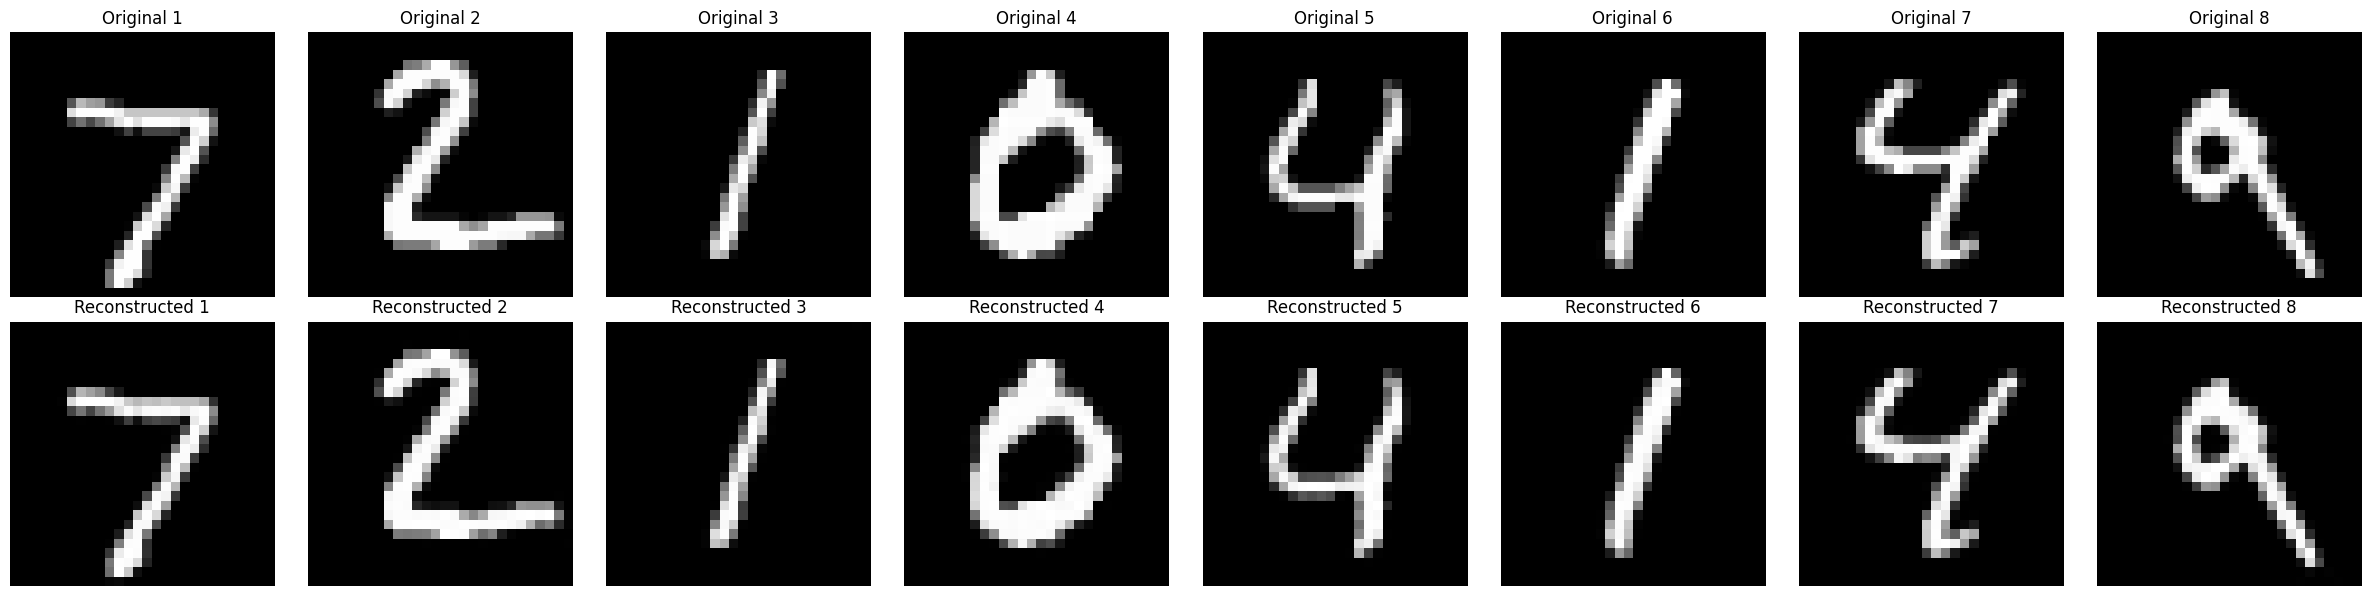

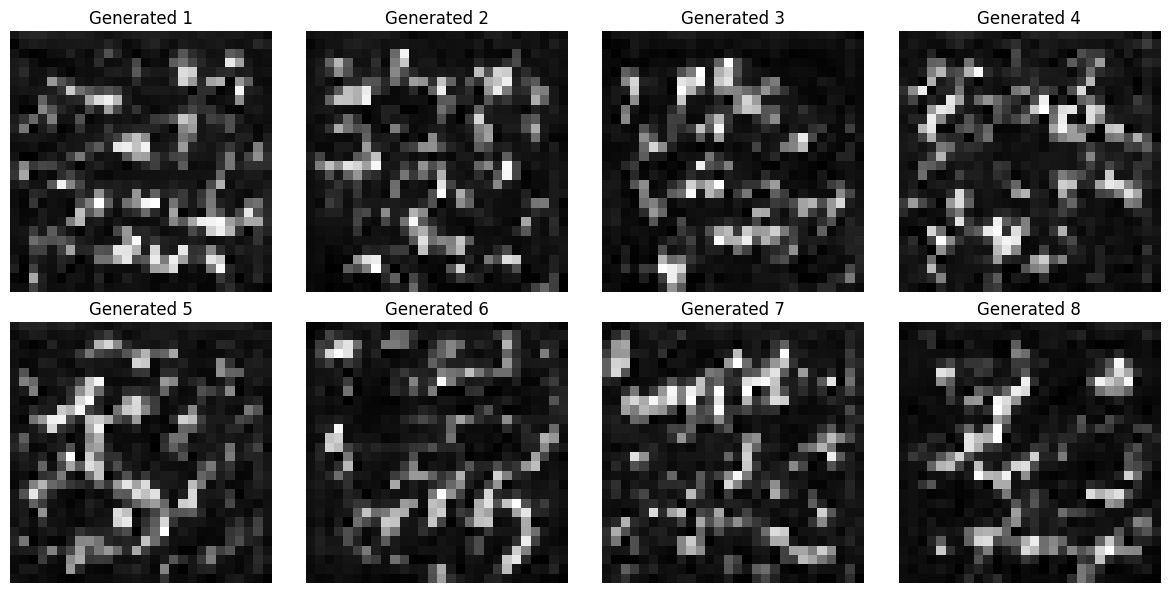


test evaluation results
  L1    : 0.007118
  MSE   : 0.000338
  LPIPS : 0.000705
  PSNR  : 40.9428 dB
  SSIM  : 0.999086
  FID   : 0.3882
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-08/eval_test_dq_1e-06_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:35<00:00,  5.41it/s, rec=0.0389, g=0.0000, d=N/A, Dq=5.7391, KLt=66943.5625]   



Epoch 1/10 [sd]
  Train - Rec: 0.0806, Reg(sd): 0.0006, Disc: 0.0000
  Val   - Rec Loss: 0.0420
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0420)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.51it/s, rec=0.0259, g=0.0000, d=N/A, Dq=-1.7919, KLt=10484.4707]



Epoch 2/10 [sd]
  Train - Rec: 0.0309, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0239
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0239)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0091, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0083
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0083)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:13<00:00,  4.37it/s, rec=0.0076, g=0.0969, d=1.0000, Dq=-0.0915, KLt=1850.7974]



Epoch 9/10 [sd]
  Train - Rec: 0.0078, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0078
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0078)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:05<00:00,  4.54it/s, rec=0.0066, g=0.0989, d=1.0000, Dq=-0.2755, KLt=1501.3818]



Epoch 10/10 [sd]
  Train - Rec: 0.0070, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0069
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0069)

[sd] 训练完成! 最佳验证损失: 0.0069


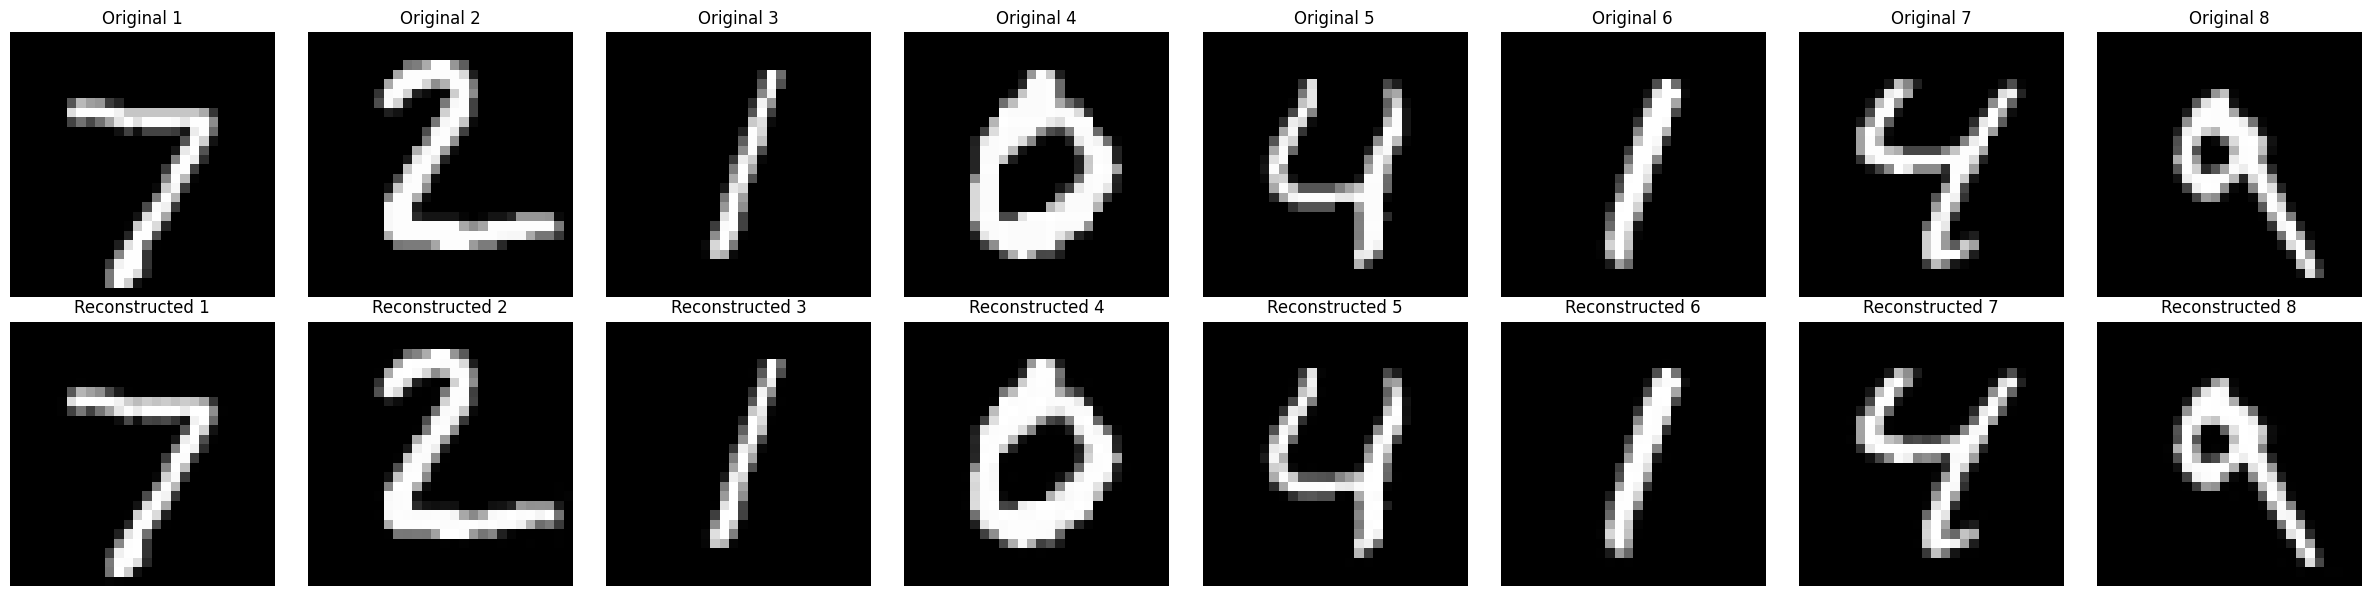

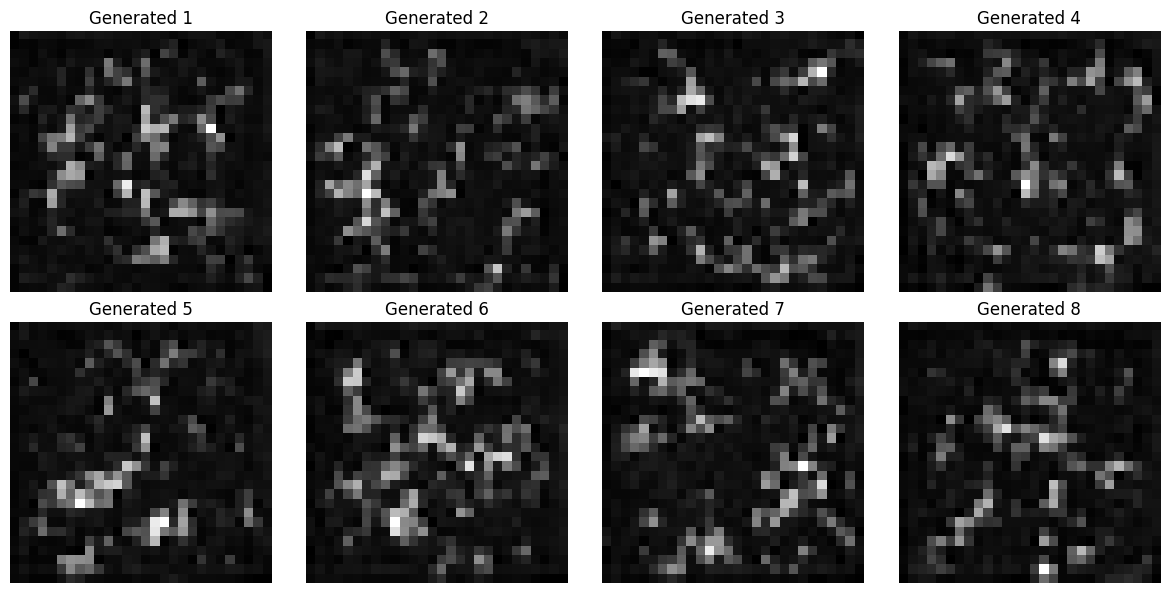


test evaluation results
  L1    : 0.006721
  MSE   : 0.000271
  LPIPS : 0.000596
  PSNR  : 41.9854 dB
  SSIM  : 0.998404
  FID   : 0.3324
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-08/eval_test_dq_1e-06_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:42<00:00,  5.20it/s, rec=0.0430, g=0.0000, d=N/A, Dq=-384.5659, KLt=22773.4492]



Epoch 1/10 [sd]
  Train - Rec: 0.0838, Reg(sd): -0.0027, Disc: 0.0000
  Val   - Rec Loss: 0.0474
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0474)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:36<00:00,  5.39it/s, rec=0.0294, g=0.0000, d=N/A, Dq=-430.0999, KLt=3877.3735]



Epoch 2/10 [sd]
  Train - Rec: 0.0361, Reg(sd): -0.0041, Disc: 0.0000
  Val   - Rec Loss: 0.0304
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0304)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0113, Reg(sd): -0.0044, Disc: 0.9862
  Val   - Rec Loss: 0.0118
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0118)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:06<00:00,  4.52it/s, rec=0.0103, g=-0.6371, d=0.9759, Dq=-445.0268, KLt=1459.4518]



Epoch 9/10 [sd]
  Train - Rec: 0.0101, Reg(sd): -0.0044, Disc: 0.9664
  Val   - Rec Loss: 0.0102
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0102)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.37it/s, rec=0.0091, g=0.1480, d=0.9089, Dq=-438.6146, KLt=502.2832]  



Epoch 10/10 [sd]
  Train - Rec: 0.0093, Reg(sd): -0.0044, Disc: 0.9415
  Val   - Rec Loss: 0.0092
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0092)

[sd] 训练完成! 最佳验证损失: 0.0092


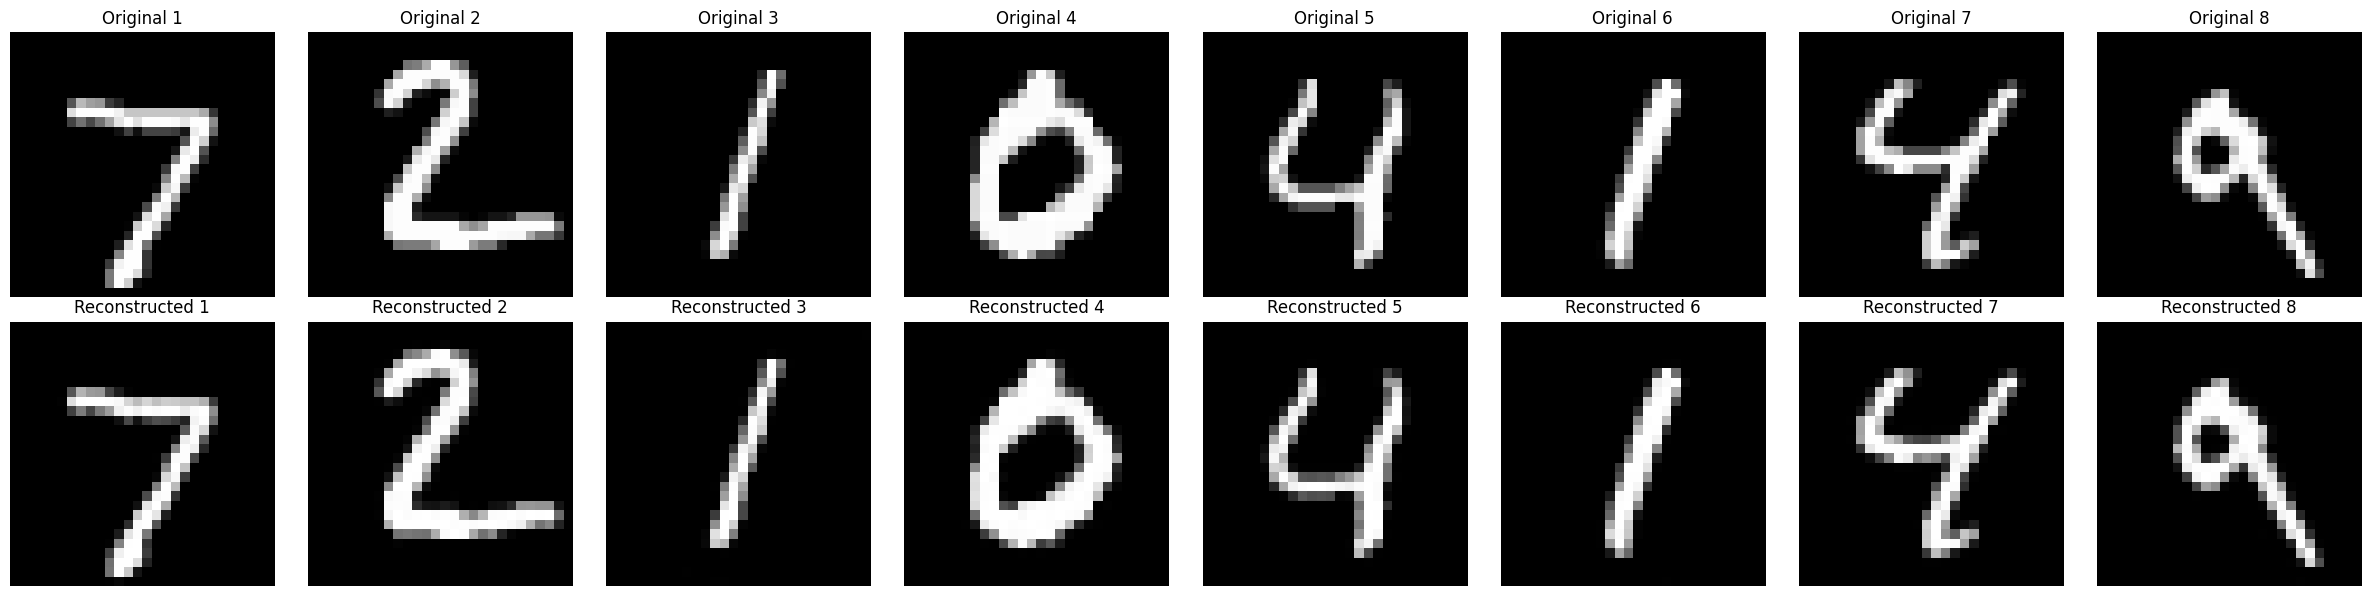

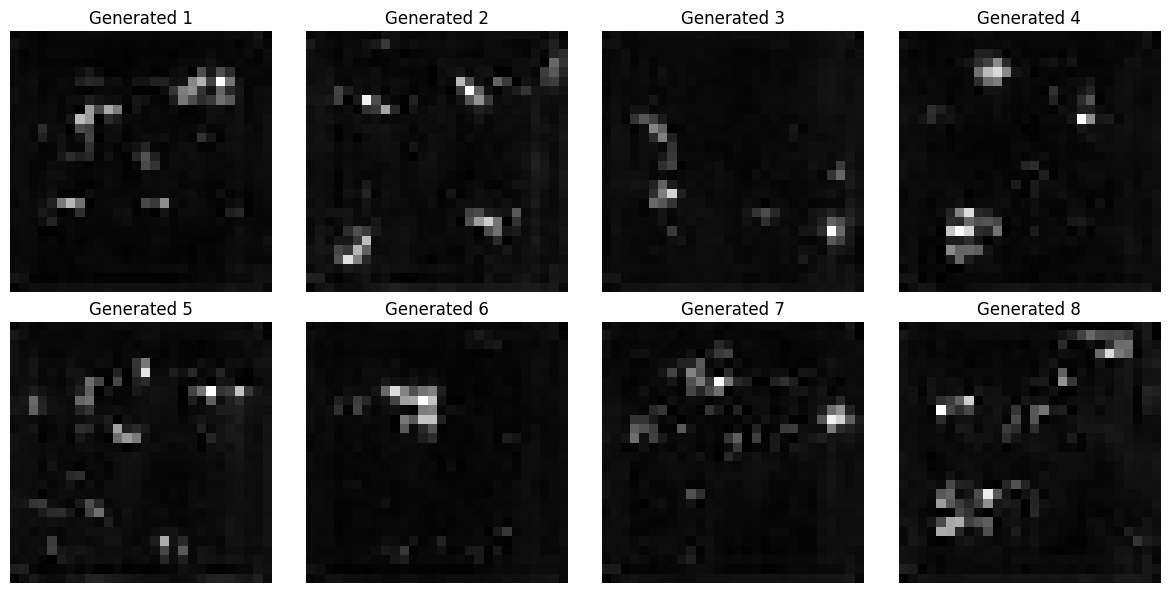


test evaluation results
  L1    : 0.008852
  MSE   : 0.000563
  LPIPS : 0.001149
  PSNR  : 38.7435 dB
  SSIM  : 0.998383
  FID   : 0.4475
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_4e-08/eval_test_dq_1e-05_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:42<00:00,  5.18it/s, rec=0.0401, g=0.0000, d=N/A, Dq=-381.4384, KLt=26965.2031]



Epoch 1/10 [sd]
  Train - Rec: 0.0802, Reg(sd): -0.0023, Disc: 0.0000
  Val   - Rec Loss: 0.0452
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0452)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:40<00:00,  5.27it/s, rec=0.0276, g=0.0000, d=N/A, Dq=-423.6015, KLt=5799.7529]



Epoch 2/10 [sd]
  Train - Rec: 0.0324, Reg(sd): -0.0040, Disc: 0.0000
  Val   - Rec Loss: 0.0290
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0290)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0107, Reg(sd): -0.0044, Disc: 1.0000
  Val   - Rec Loss: 0.0117
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0117)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:18<00:00,  4.24it/s, rec=0.0094, g=-0.1850, d=0.9969, Dq=-436.3605, KLt=1392.2927]



Epoch 9/10 [sd]
  Train - Rec: 0.0095, Reg(sd): -0.0044, Disc: 1.0002
  Val   - Rec Loss: 0.0095
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0095)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:10<00:00,  4.41it/s, rec=0.0088, g=-0.1842, d=0.9895, Dq=-441.3820, KLt=485.9898] 



Epoch 10/10 [sd]
  Train - Rec: 0.0088, Reg(sd): -0.0044, Disc: 0.9991
  Val   - Rec Loss: 0.0088
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0088)

[sd] 训练完成! 最佳验证损失: 0.0088


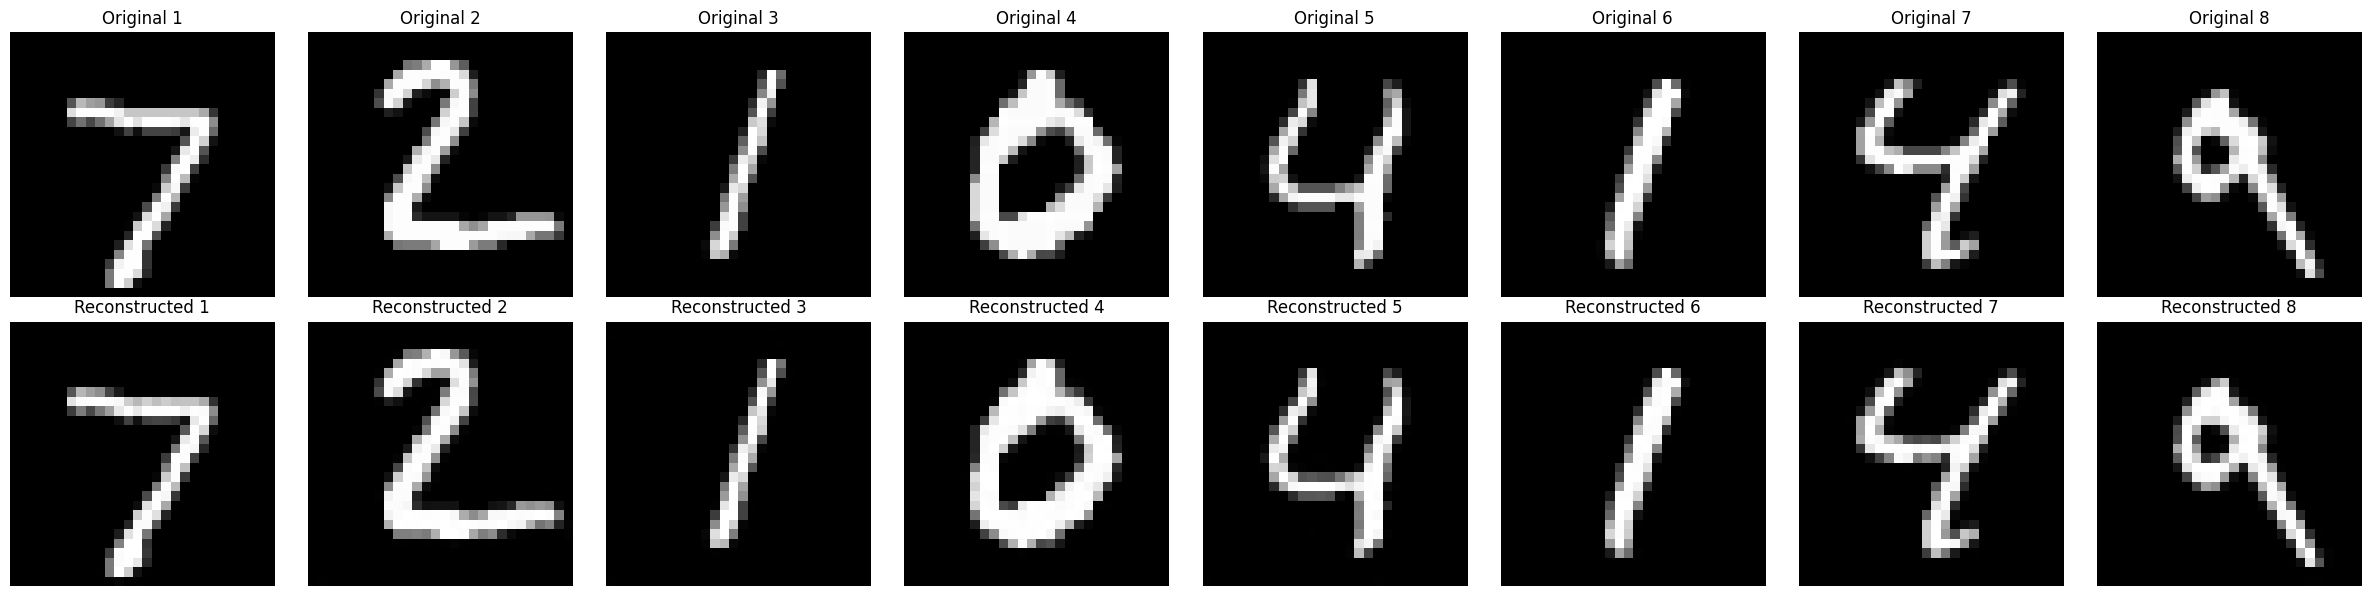

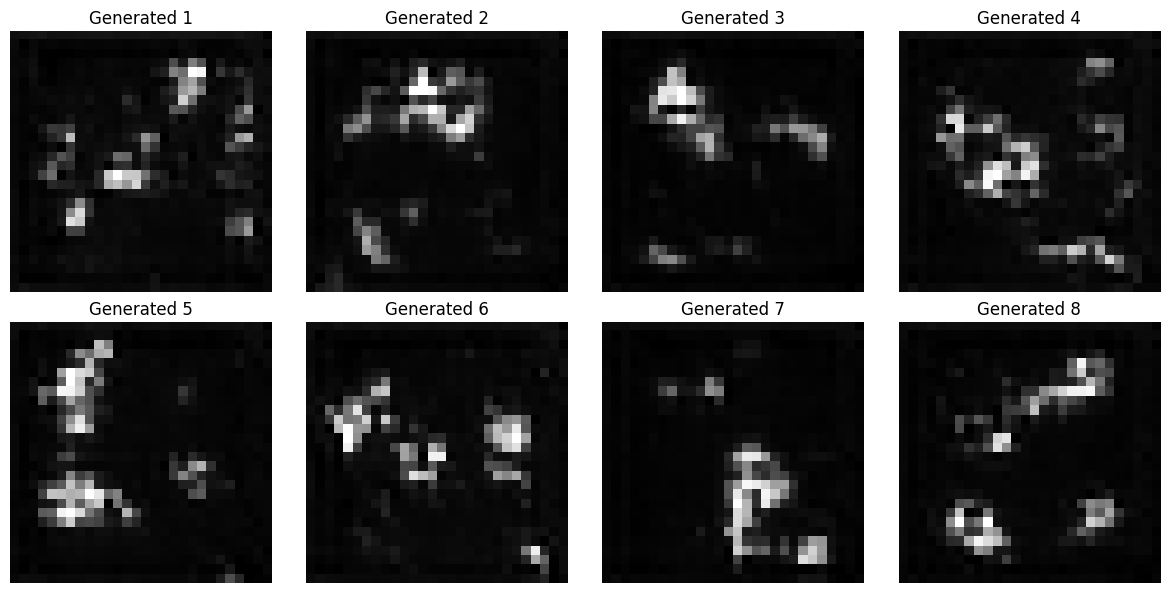


test evaluation results
  L1    : 0.008485
  MSE   : 0.000488
  LPIPS : 0.001036
  PSNR  : 39.3851 dB
  SSIM  : 0.998671
  FID   : 0.4178
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_4e-08/eval_test_dq_1e-05_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:40<00:00,  5.24it/s, rec=0.0370, g=0.0000, d=N/A, Dq=-537.5013, KLt=20267.0020]



Epoch 1/10 [sd]
  Train - Rec: 0.0887, Reg(sd): -0.0038, Disc: 0.0000
  Val   - Rec Loss: 0.0436
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0436)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.51it/s, rec=0.0316, g=0.0000, d=N/A, Dq=-580.4697, KLt=2305.4722]



Epoch 2/10 [sd]
  Train - Rec: 0.0361, Reg(sd): -0.0056, Disc: 0.0000
  Val   - Rec Loss: 0.0283
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0283)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0136, Reg(sd): -0.0054, Disc: 0.9531
  Val   - Rec Loss: 0.0132
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0132)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:27<00:00,  4.06it/s, rec=0.0117, g=-0.6663, d=0.9323, Dq=-528.9761, KLt=828.1404] 



Epoch 9/10 [sd]
  Train - Rec: 0.0120, Reg(sd): -0.0053, Disc: 0.9148
  Val   - Rec Loss: 0.0118
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0118)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:25<00:00,  4.09it/s, rec=0.0103, g=-0.2755, d=0.8654, Dq=-531.1216, KLt=493.6294] 



Epoch 10/10 [sd]
  Train - Rec: 0.0108, Reg(sd): -0.0053, Disc: 0.8763
  Val   - Rec Loss: 0.0104
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0104)

[sd] 训练完成! 最佳验证损失: 0.0104


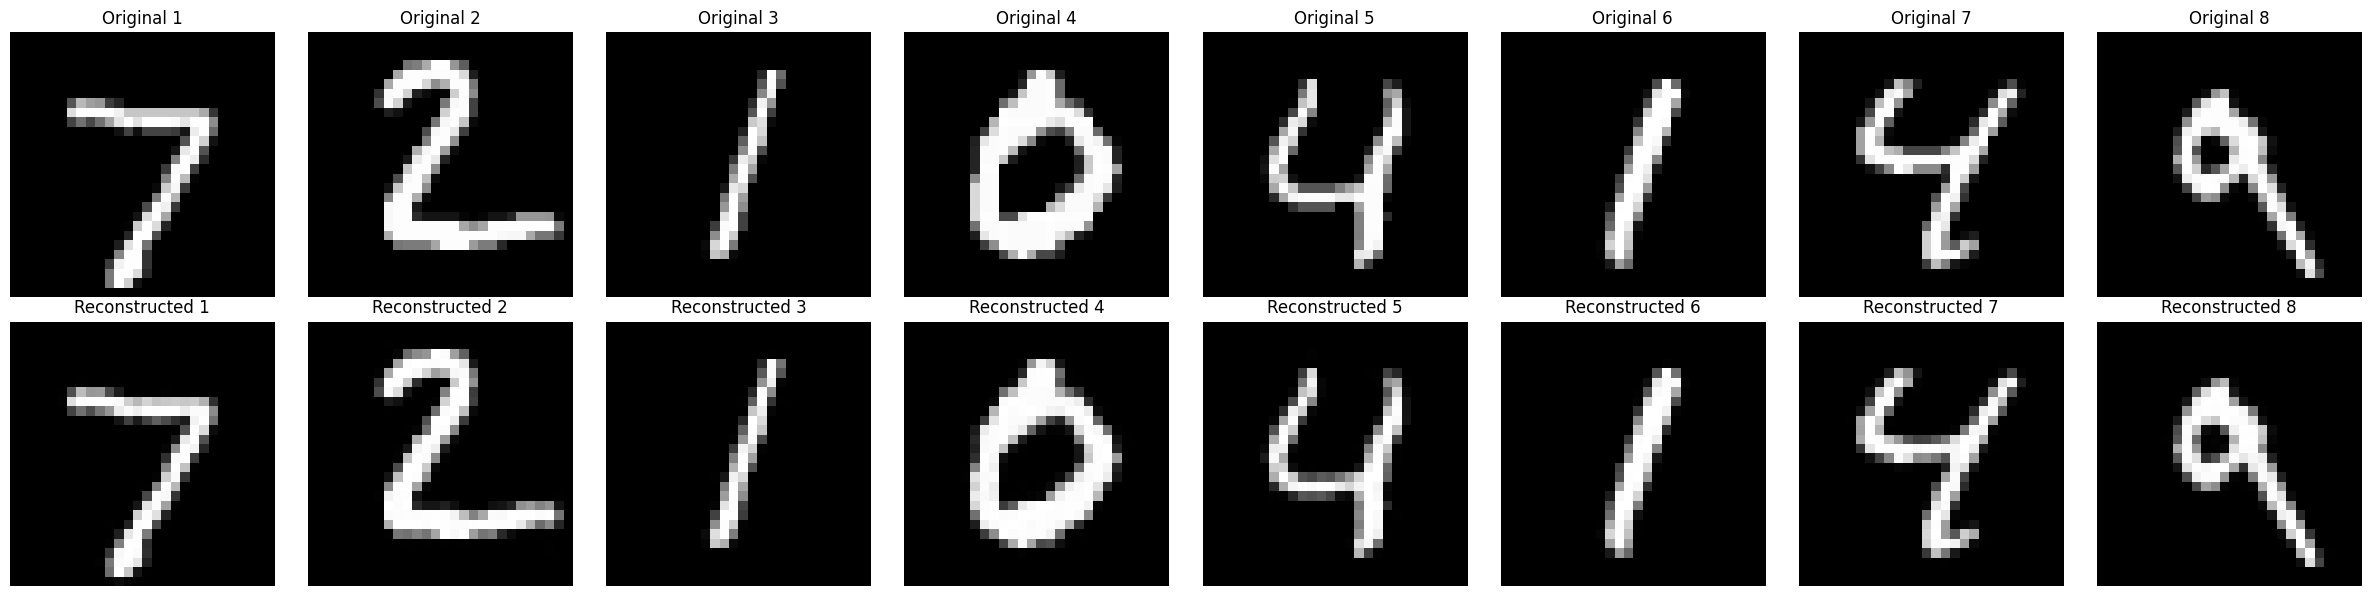

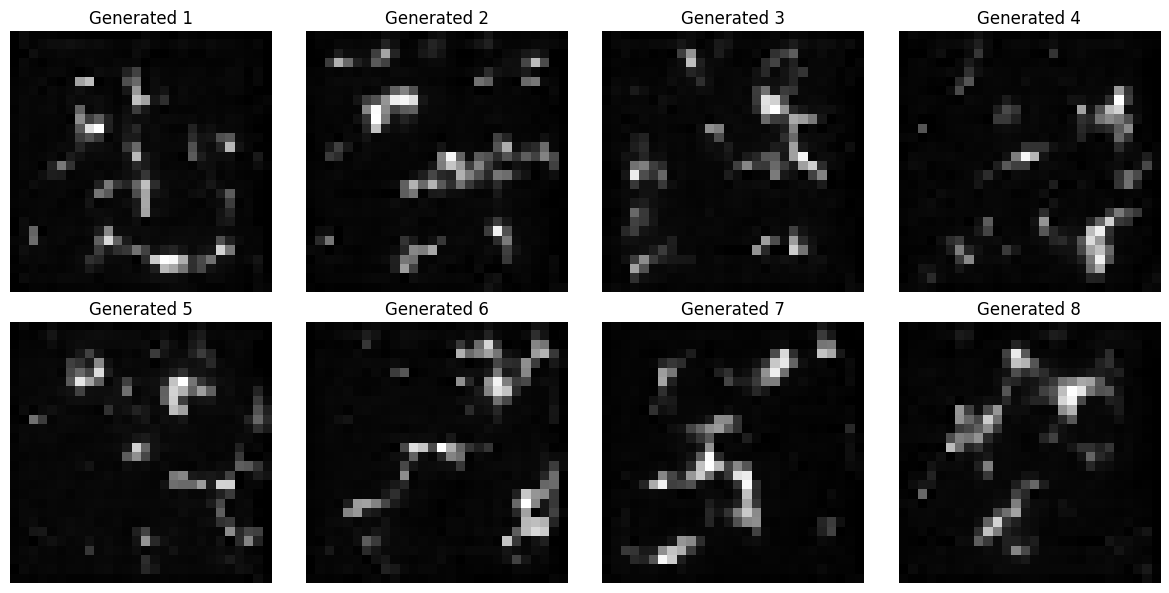


test evaluation results
  L1    : 0.009864
  MSE   : 0.000785
  LPIPS : 0.001676
  PSNR  : 37.2439 dB
  SSIM  : 0.997802
  FID   : 0.6317
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_4e-08/eval_test_dq_1e-05_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:41<00:00,  5.21it/s, rec=0.0381, g=0.0000, d=N/A, Dq=-431.4702, KLt=22459.8867]



Epoch 1/10 [sd]
  Train - Rec: 0.0852, Reg(sd): -0.0029, Disc: 0.0000
  Val   - Rec Loss: 0.0413
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0413)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.54it/s, rec=0.0259, g=0.0000, d=N/A, Dq=-507.1684, KLt=4329.3926]



Epoch 2/10 [sd]
  Train - Rec: 0.0343, Reg(sd): -0.0048, Disc: 0.0000
  Val   - Rec Loss: 0.0288
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0288)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0112, Reg(sd): -0.0051, Disc: 1.0000
  Val   - Rec Loss: 0.0111
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0111)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:09<00:00,  4.46it/s, rec=0.0092, g=0.0007, d=1.0000, Dq=-513.8048, KLt=681.5347]  



Epoch 9/10 [sd]
  Train - Rec: 0.0100, Reg(sd): -0.0051, Disc: 1.0000
  Val   - Rec Loss: 0.0095
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0095)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:08<00:00,  4.47it/s, rec=0.0088, g=0.0349, d=1.0000, Dq=-520.6614, KLt=458.7228]  



Epoch 10/10 [sd]
  Train - Rec: 0.0092, Reg(sd): -0.0051, Disc: 1.0000
  Val   - Rec Loss: 0.0089
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0089)

[sd] 训练完成! 最佳验证损失: 0.0089


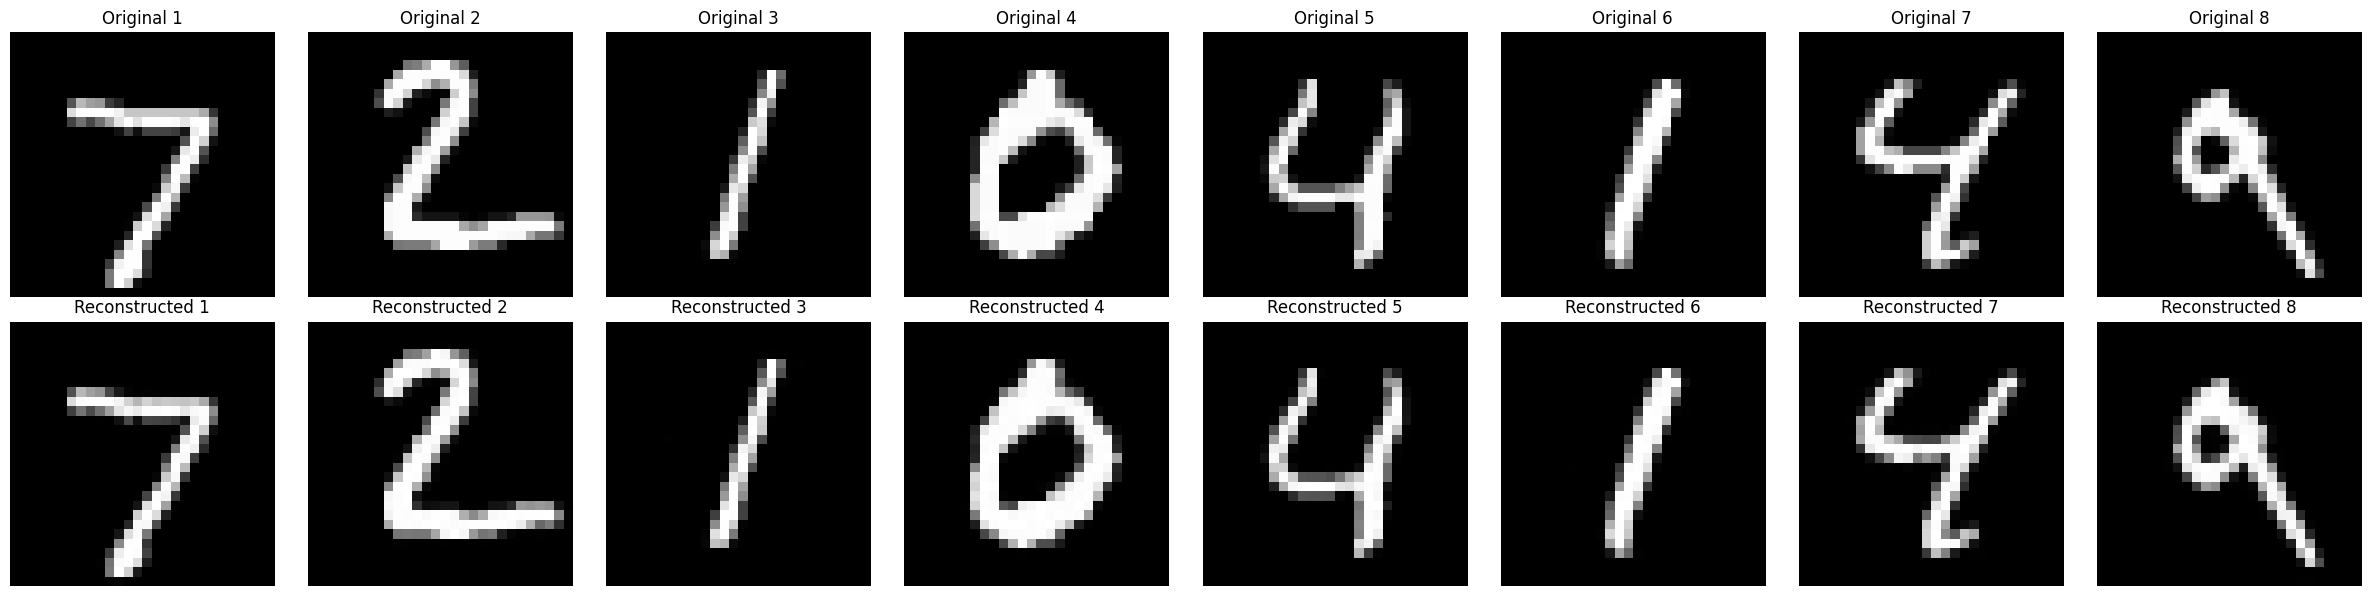

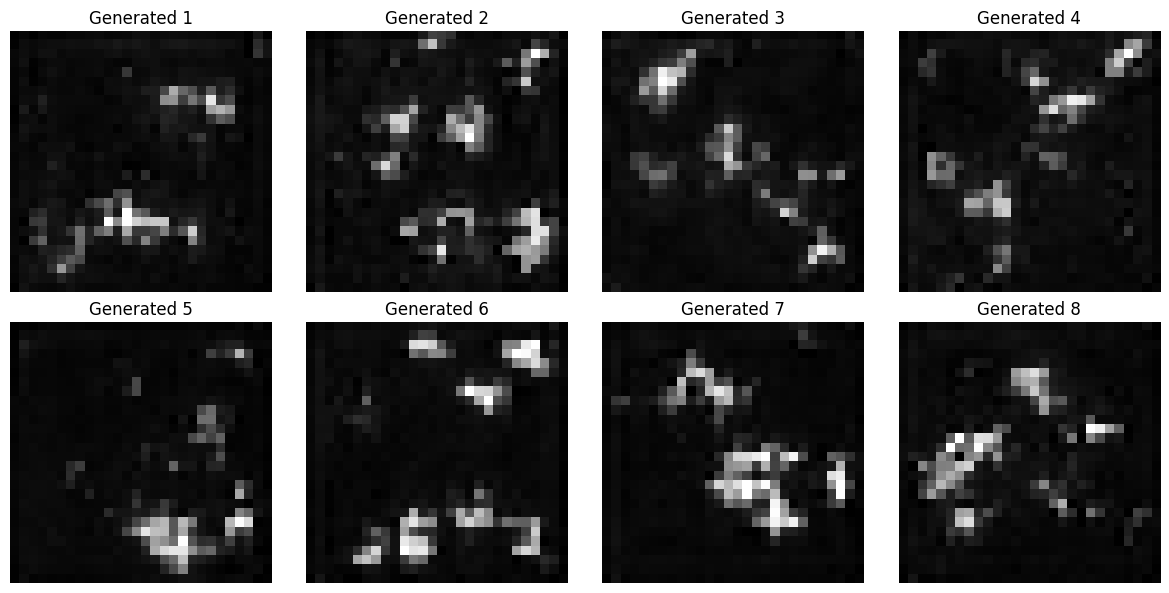


test evaluation results
  L1    : 0.008468
  MSE   : 0.000502
  LPIPS : 0.001090
  PSNR  : 39.2149 dB
  SSIM  : 0.998216
  FID   : 0.4910
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_4e-08/eval_test_dq_1e-05_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:34<00:00,  5.45it/s, rec=0.0404, g=0.0000, d=N/A, Dq=-35.8927, KLt=25641.7656]



Epoch 1/10 [sd]
  Train - Rec: 0.0883, Reg(sd): 0.0010, Disc: 0.0000
  Val   - Rec Loss: 0.0403
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0403)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:51<00:00,  4.91it/s, rec=0.0312, g=0.0000, d=N/A, Dq=-26.4330, KLt=5179.8965]



Epoch 2/10 [sd]
  Train - Rec: 0.0329, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0292
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0292)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0105, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0112
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0112)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:01<00:00,  4.65it/s, rec=0.0089, g=0.9427, d=0.9999, Dq=-1.4002, KLt=818.3540] 



Epoch 9/10 [sd]
  Train - Rec: 0.0092, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0088)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:02<00:00,  4.62it/s, rec=0.0082, g=-0.2468, d=0.9981, Dq=-1.1707, KLt=507.2322] 



Epoch 10/10 [sd]
  Train - Rec: 0.0084, Reg(sd): 0.0000, Disc: 0.9987
  Val   - Rec Loss: 0.0085
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0085)

[sd] 训练完成! 最佳验证损失: 0.0085


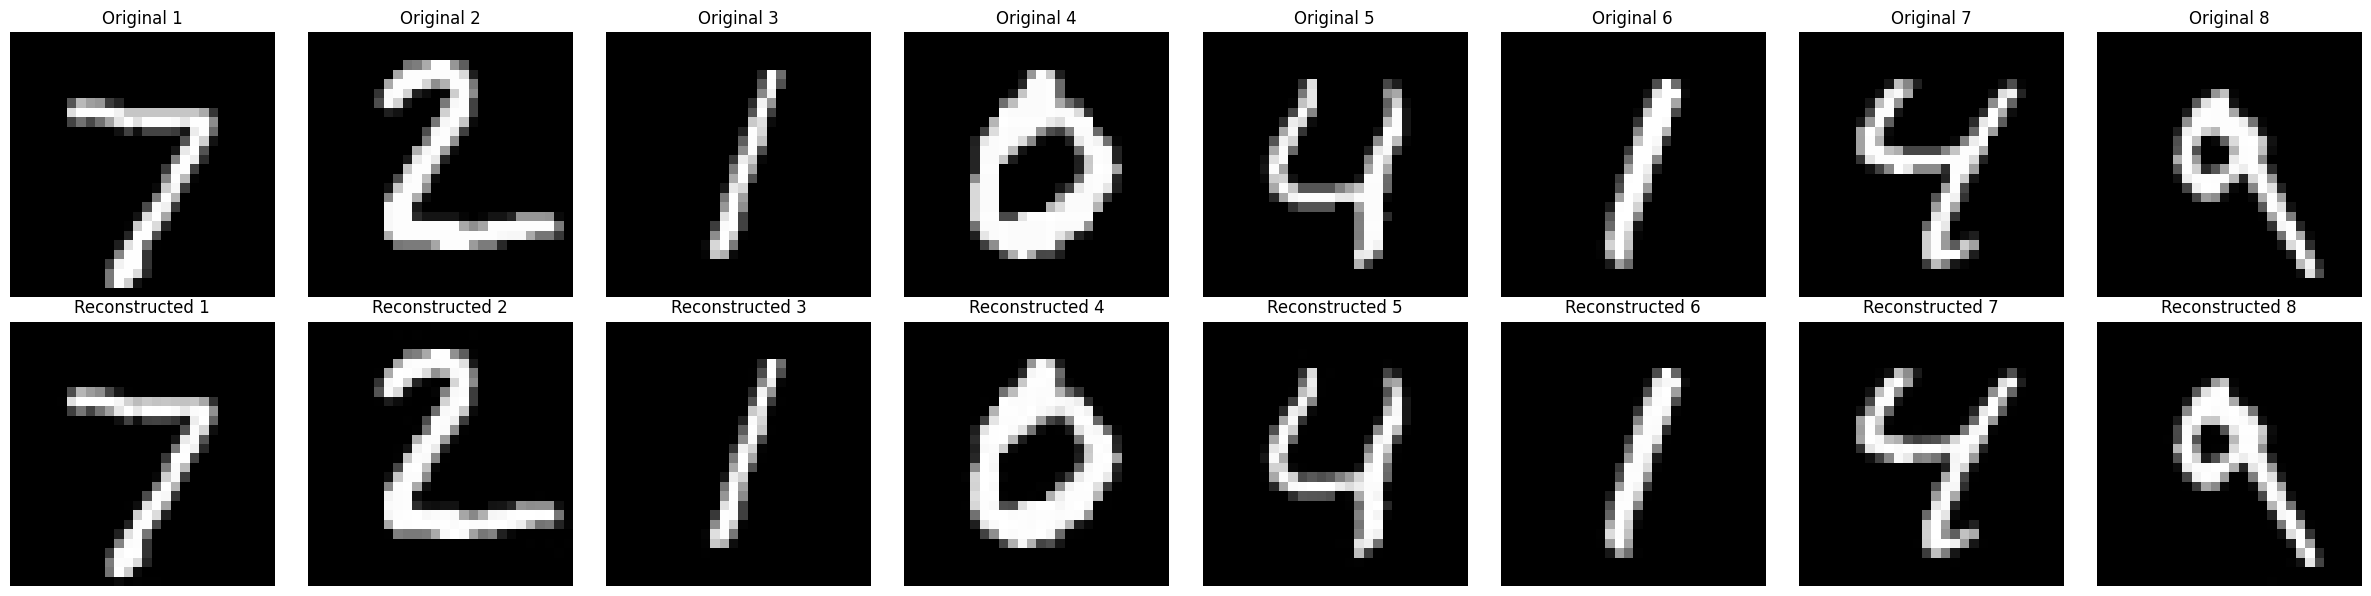

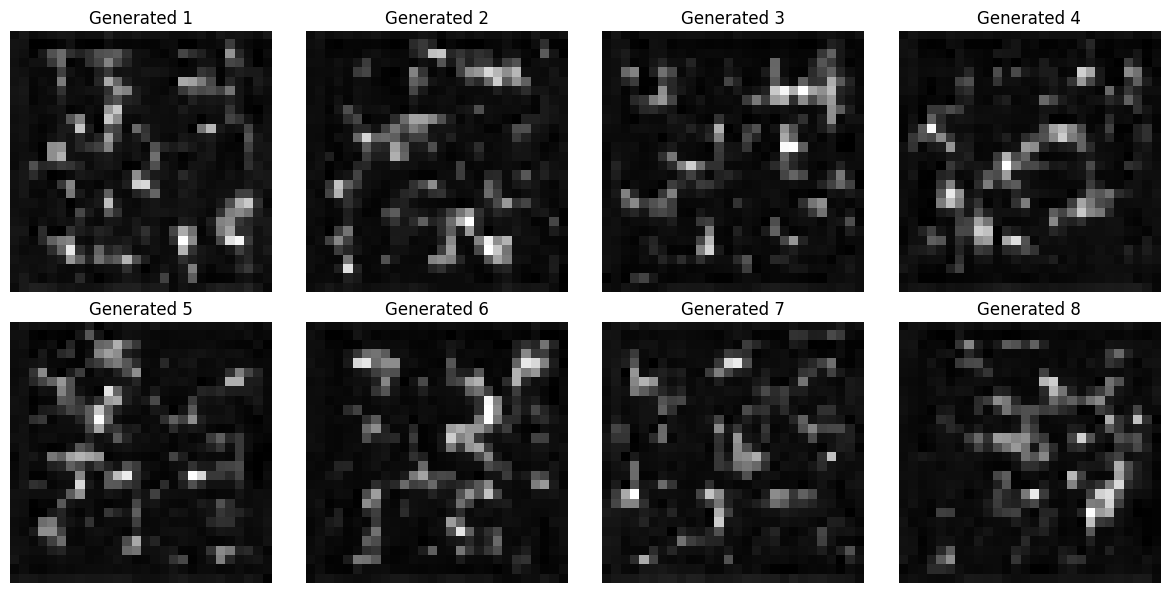


test evaluation results
  L1    : 0.008168
  MSE   : 0.000430
  LPIPS : 0.000917
  PSNR  : 39.9367 dB
  SSIM  : 0.997929
  FID   : 0.4378
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_4e-08/eval_test_dq_1e-06_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.52it/s, rec=0.0450, g=0.0000, d=N/A, Dq=9.3605, KLt=25693.8574]  



Epoch 1/10 [sd]
  Train - Rec: 0.0798, Reg(sd): 0.0009, Disc: 0.0000
  Val   - Rec Loss: 0.0401
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0401)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:26<00:00,  5.75it/s, rec=0.0305, g=0.0000, d=N/A, Dq=-18.8540, KLt=5387.3633]



Epoch 2/10 [sd]
  Train - Rec: 0.0334, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0286
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0286)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0105, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0103
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0103)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:09<00:00,  4.45it/s, rec=0.0091, g=-0.0076, d=1.0000, Dq=-1.2260, KLt=842.0930] 



Epoch 9/10 [sd]
  Train - Rec: 0.0092, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0090
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0090)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:05<00:00,  4.55it/s, rec=0.0081, g=-0.0102, d=1.0000, Dq=-0.9753, KLt=730.6508] 



Epoch 10/10 [sd]
  Train - Rec: 0.0084, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0084
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0084)

[sd] 训练完成! 最佳验证损失: 0.0084


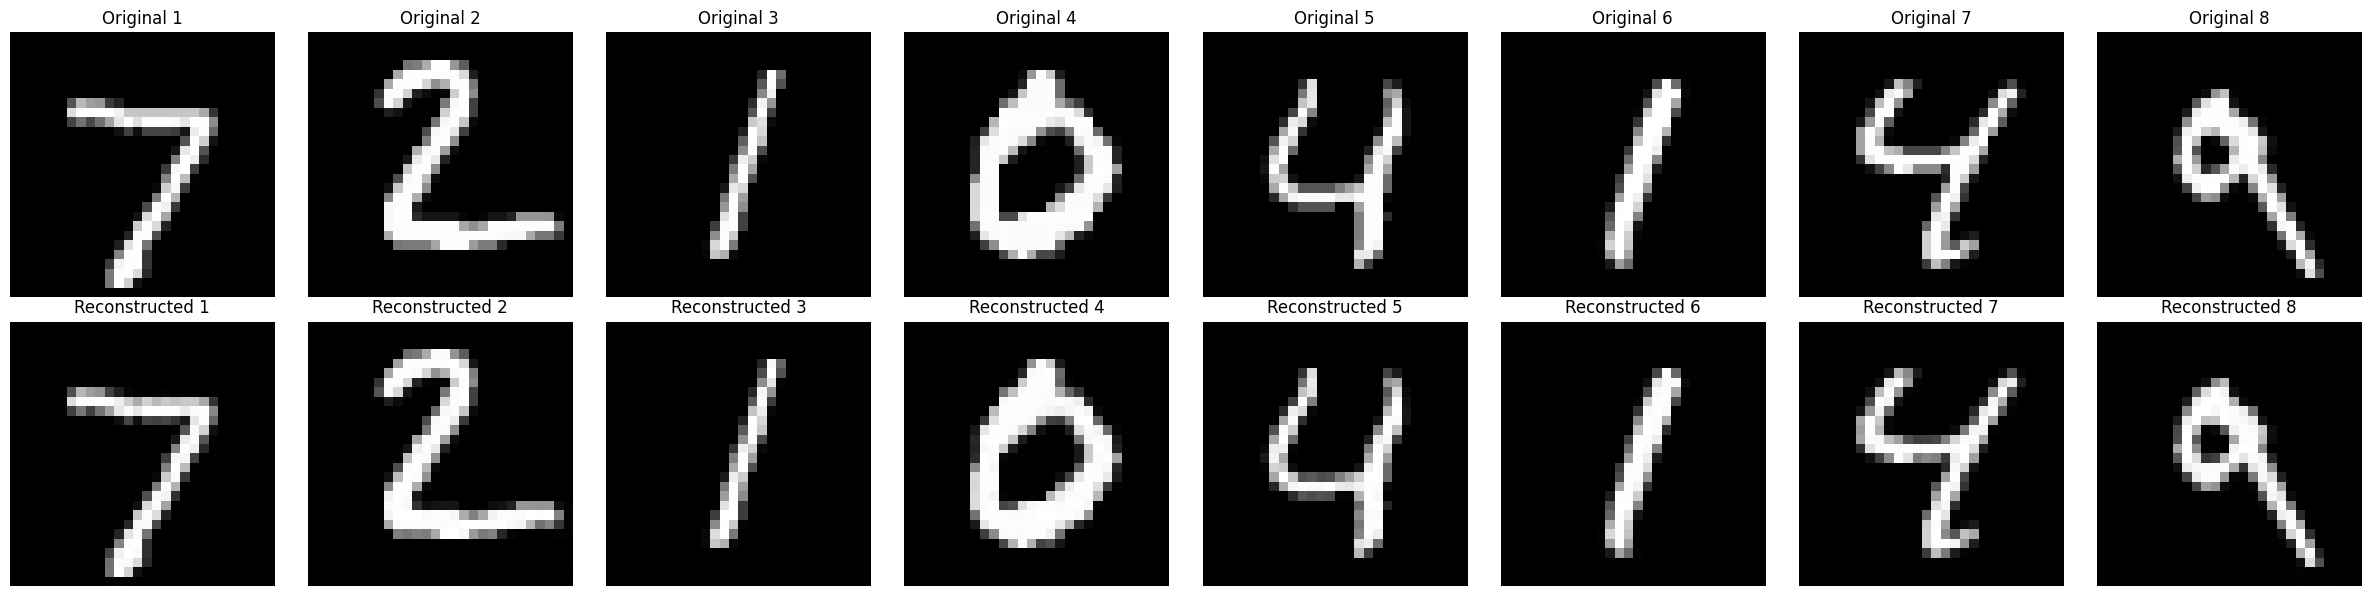

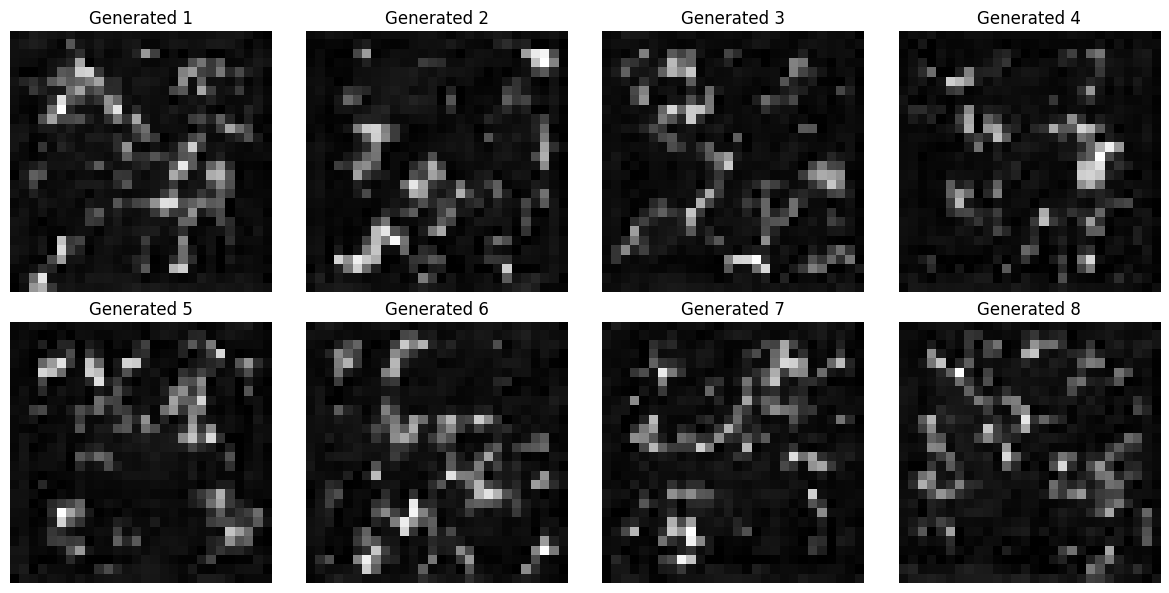


test evaluation results
  L1    : 0.008082
  MSE   : 0.000416
  LPIPS : 0.000936
  PSNR  : 40.0363 dB
  SSIM  : 0.998883
  FID   : 0.4548
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_4e-08/eval_test_dq_1e-06_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:34<00:00,  5.46it/s, rec=0.0379, g=0.0000, d=N/A, Dq=-84.2601, KLt=23575.6895] 



Epoch 1/10 [sd]
  Train - Rec: 0.0856, Reg(sd): 0.0007, Disc: 0.0000
  Val   - Rec Loss: 0.0425
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0425)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:25<00:00,  5.79it/s, rec=0.0303, g=0.0000, d=N/A, Dq=-97.6303, KLt=4629.3828] 



Epoch 2/10 [sd]
  Train - Rec: 0.0342, Reg(sd): 0.0000, Disc: 0.0000
  Val   - Rec Loss: 0.0317
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0317)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0103, Reg(sd): -0.0002, Disc: 1.0014
  Val   - Rec Loss: 0.0114
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0114)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:04<00:00,  4.58it/s, rec=0.0095, g=-0.3583, d=0.9949, Dq=-193.9257, KLt=823.9906] 



Epoch 9/10 [sd]
  Train - Rec: 0.0090, Reg(sd): -0.0002, Disc: 1.0041
  Val   - Rec Loss: 0.0089
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0089)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:04<00:00,  4.56it/s, rec=0.0081, g=-0.0916, d=0.9900, Dq=-191.7088, KLt=371.1540] 



Epoch 10/10 [sd]
  Train - Rec: 0.0083, Reg(sd): -0.0002, Disc: 0.9988
  Val   - Rec Loss: 0.0080
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0080)

[sd] 训练完成! 最佳验证损失: 0.0080


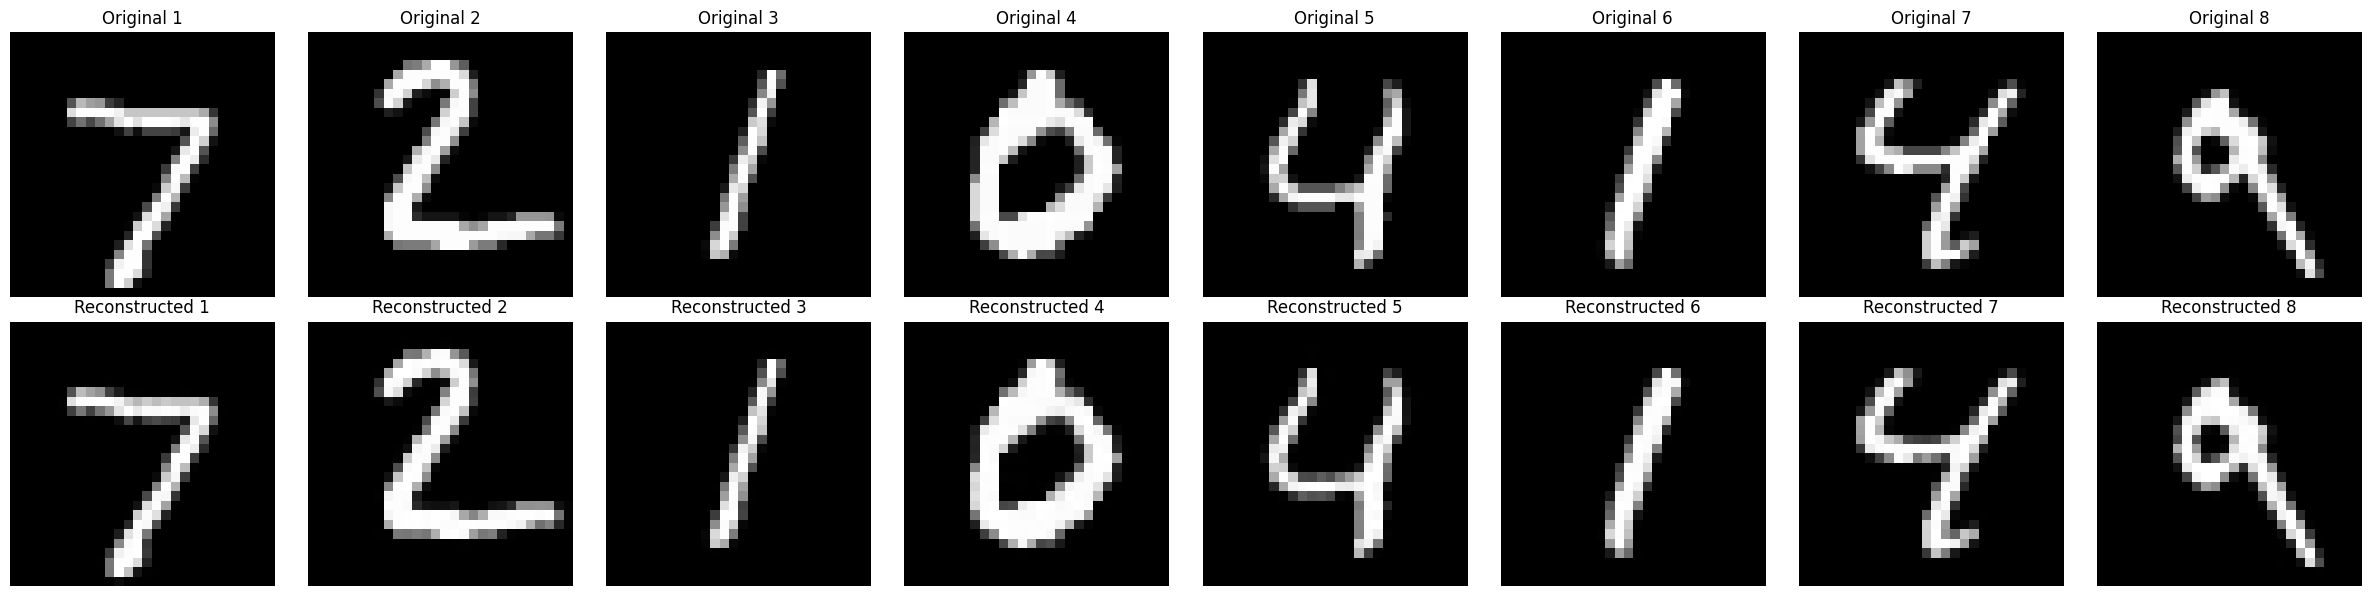

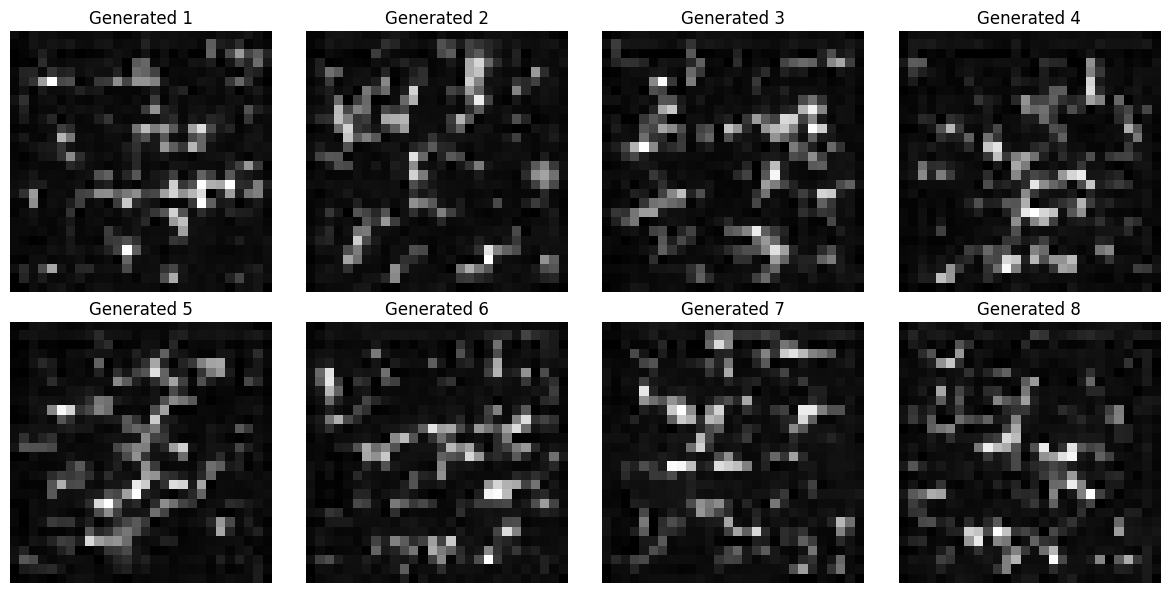


test evaluation results
  L1    : 0.007712
  MSE   : 0.000423
  LPIPS : 0.000906
  PSNR  : 39.9900 dB
  SSIM  : 0.998896
  FID   : 0.4001
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_4e-08/eval_test_dq_1e-06_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:27<00:00,  5.71it/s, rec=0.0404, g=0.0000, d=N/A, Dq=20.6070, KLt=25807.1465] 



Epoch 1/10 [sd]
  Train - Rec: 0.0852, Reg(sd): 0.0010, Disc: 0.0000
  Val   - Rec Loss: 0.0402
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0402)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:38<00:00,  5.32it/s, rec=0.0240, g=0.0000, d=N/A, Dq=-11.7668, KLt=5049.8901]



Epoch 2/10 [sd]
  Train - Rec: 0.0318, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0269
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0269)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0103, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0096
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0096)


Epoch 9 [sd]: 100%|██████████| 843/843 [02:57<00:00,  4.76it/s, rec=0.0084, g=-0.0584, d=1.0000, Dq=-1.5879, KLt=704.8583] 



Epoch 9/10 [sd]
  Train - Rec: 0.0091, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0094
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0094)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.59it/s, rec=0.0082, g=-0.0518, d=1.0000, Dq=-1.1811, KLt=711.4667] 



Epoch 10/10 [sd]
  Train - Rec: 0.0083, Reg(sd): 0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0082
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0082)

[sd] 训练完成! 最佳验证损失: 0.0082


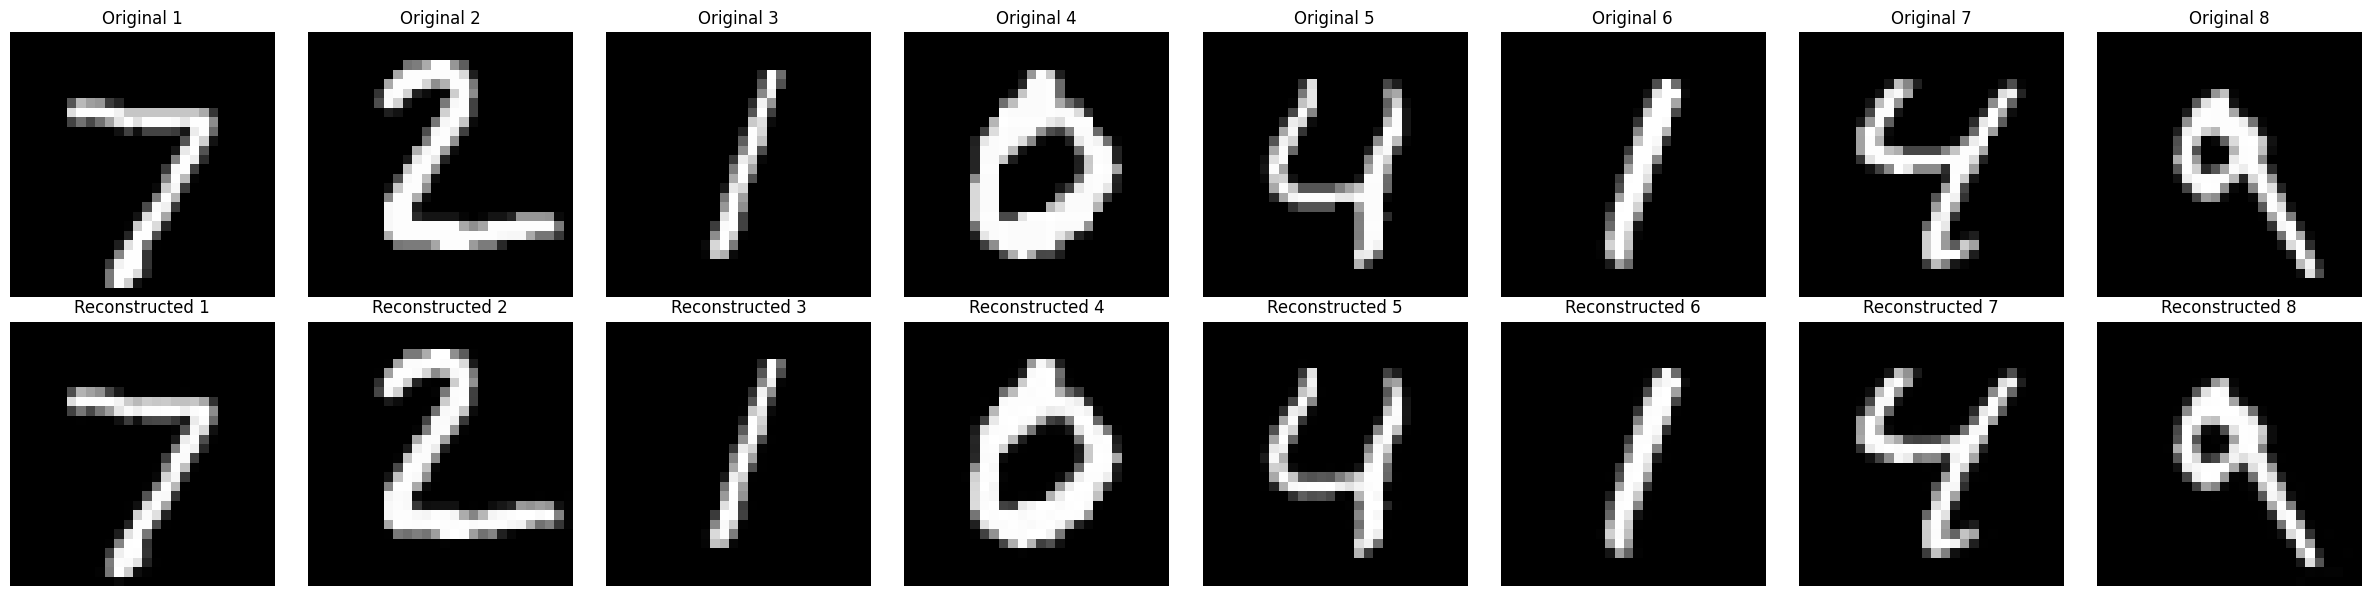

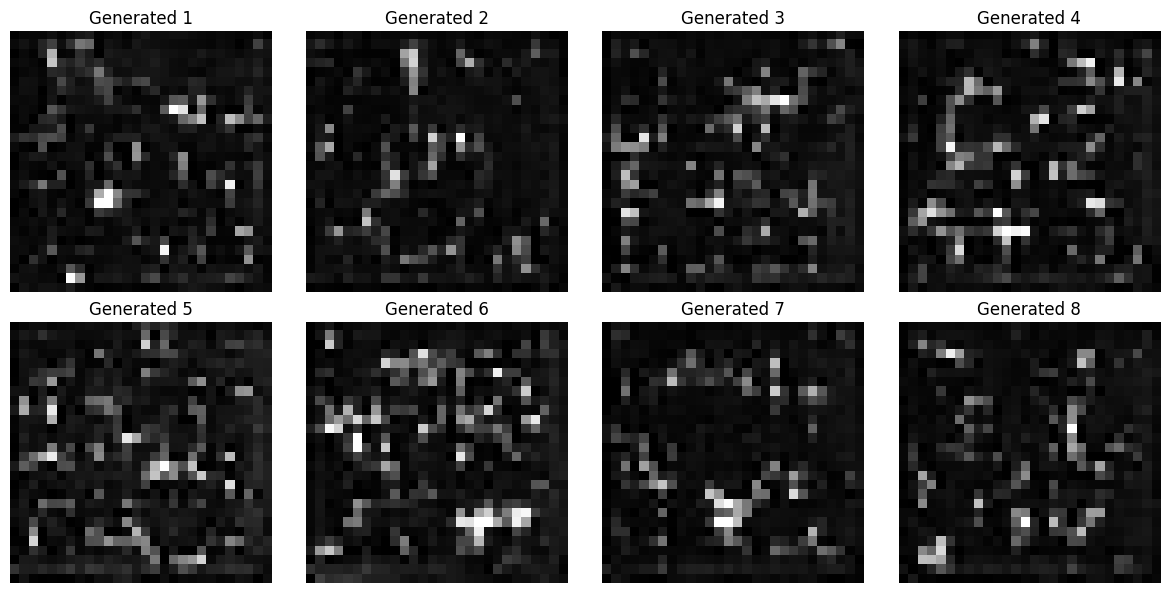


test evaluation results
  L1    : 0.007881
  MSE   : 0.000402
  LPIPS : 0.000861
  PSNR  : 40.2478 dB
  SSIM  : 0.998861
  FID   : 0.4113
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_4e-08/eval_test_dq_1e-06_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:34<00:00,  5.47it/s, rec=0.0468, g=0.0000, d=N/A, Dq=-504.8700, KLt=3093.4268]



Epoch 1/10 [sd]
  Train - Rec: 0.0901, Reg(sd): -0.0013, Disc: 0.0000
  Val   - Rec Loss: 0.0483
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0483)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:35<00:00,  5.43it/s, rec=0.0299, g=0.0000, d=N/A, Dq=-612.4498, KLt=463.1023]



Epoch 2/10 [sd]
  Train - Rec: 0.0384, Reg(sd): -0.0053, Disc: 0.0000
  Val   - Rec Loss: 0.0329
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0329)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0155, Reg(sd): -0.0063, Disc: 0.9710
  Val   - Rec Loss: 0.0159
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0159)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:05<00:00,  4.55it/s, rec=0.0141, g=-0.5797, d=0.9112, Dq=-635.1847, KLt=68.9658] 



Epoch 9/10 [sd]
  Train - Rec: 0.0142, Reg(sd): -0.0063, Disc: 0.9255
  Val   - Rec Loss: 0.0140
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0140)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:11<00:00,  4.41it/s, rec=0.0131, g=0.7133, d=0.8414, Dq=-640.2377, KLt=65.9937]  



Epoch 10/10 [sd]
  Train - Rec: 0.0133, Reg(sd): -0.0063, Disc: 0.8517
  Val   - Rec Loss: 0.0134
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0134)

[sd] 训练完成! 最佳验证损失: 0.0134


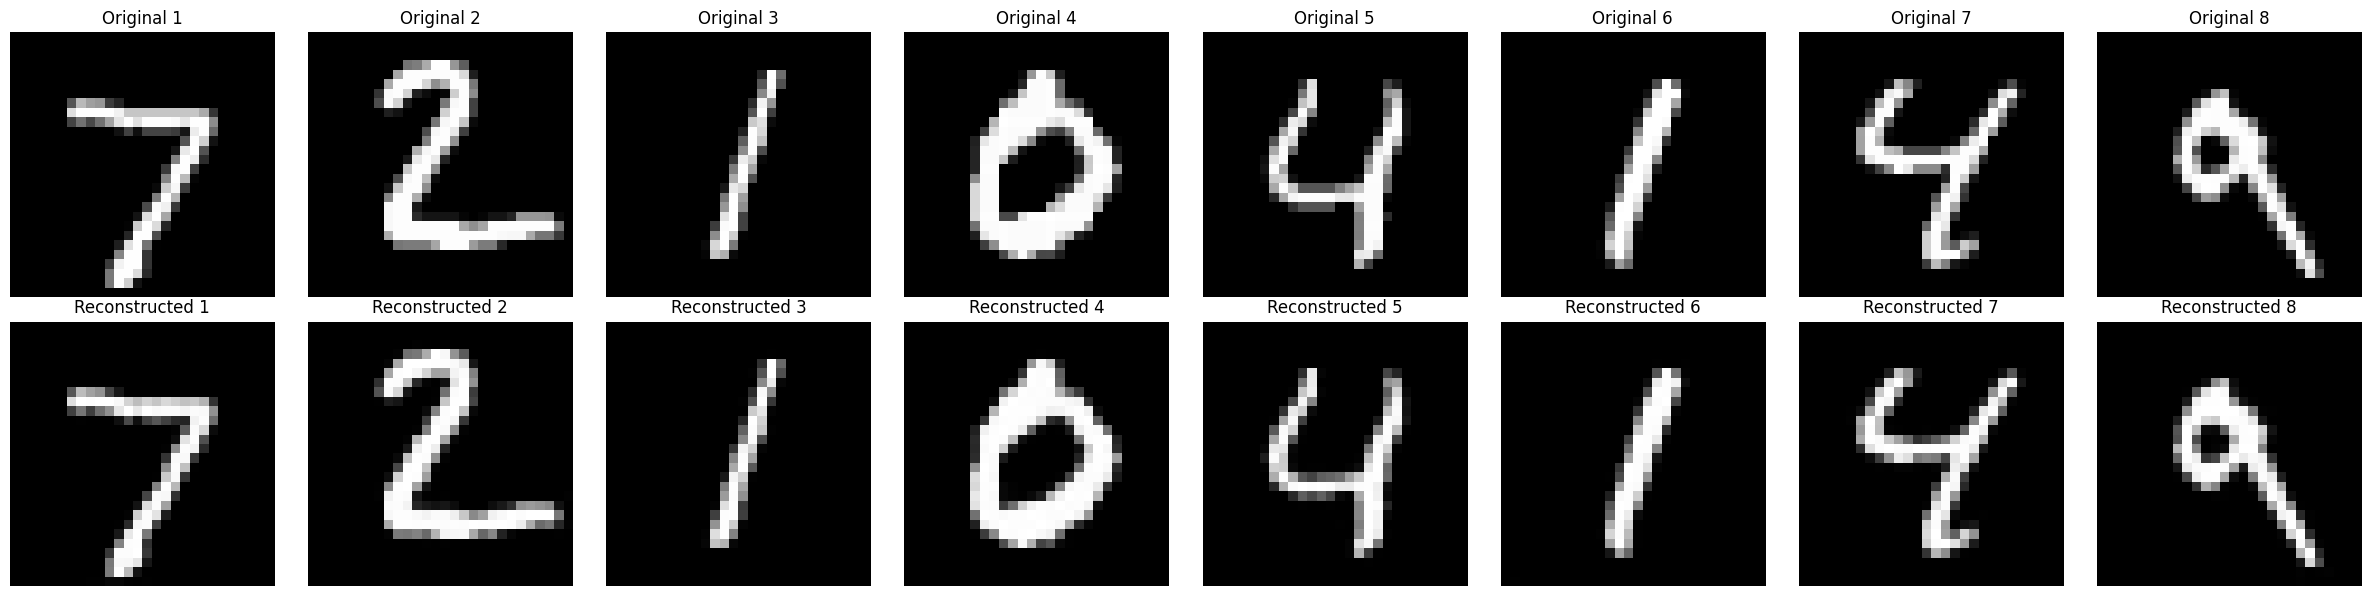

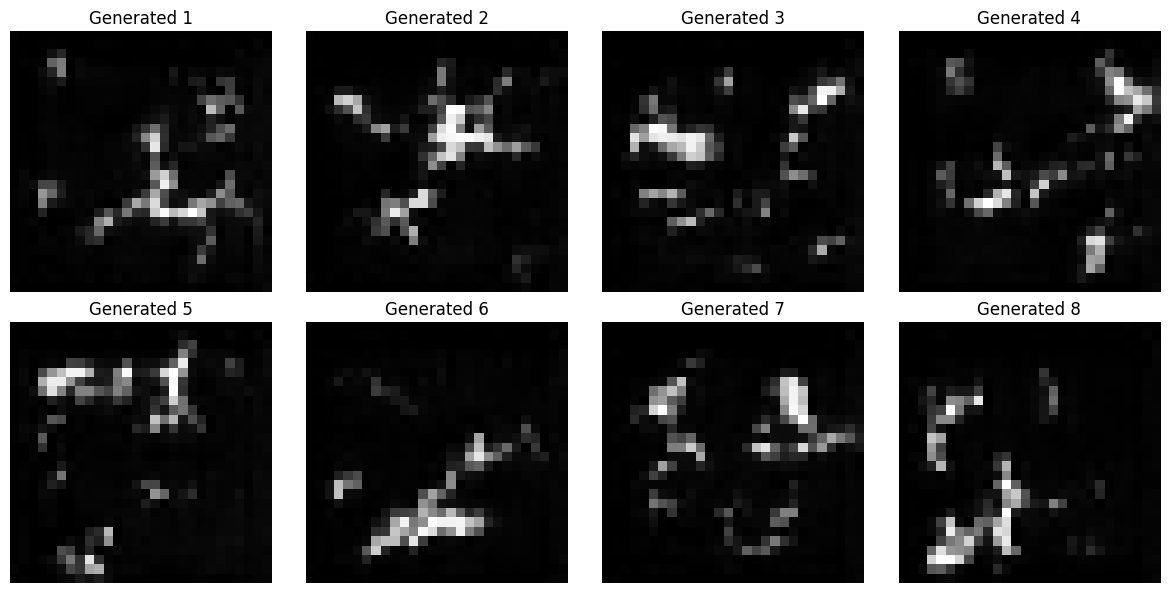


test evaluation results
  L1    : 0.012548
  MSE   : 0.001368
  LPIPS : 0.002693
  PSNR  : 34.8084 dB
  SSIM  : 0.996430
  FID   : 0.8466
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-06/eval_test_dq_1e-05_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.52it/s, rec=0.0413, g=0.0000, d=N/A, Dq=-455.6391, KLt=3294.7368]



Epoch 1/10 [sd]
  Train - Rec: 0.0920, Reg(sd): -0.0006, Disc: 0.0000
  Val   - Rec Loss: 0.0542
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0542)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:26<00:00,  5.74it/s, rec=0.0299, g=0.0000, d=N/A, Dq=-519.4564, KLt=646.1168]



Epoch 2/10 [sd]
  Train - Rec: 0.0347, Reg(sd): -0.0045, Disc: 0.0000
  Val   - Rec Loss: 0.0337
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0337)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0120, Reg(sd): -0.0056, Disc: 1.0000
  Val   - Rec Loss: 0.0114
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0114)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.60it/s, rec=0.0100, g=0.0713, d=1.0000, Dq=-570.5009, KLt=88.0633]  



Epoch 9/10 [sd]
  Train - Rec: 0.0107, Reg(sd): -0.0056, Disc: 1.0000
  Val   - Rec Loss: 0.0105
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0105)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:04<00:00,  4.57it/s, rec=0.0092, g=0.1915, d=1.0000, Dq=-578.4930, KLt=64.7652] 



Epoch 10/10 [sd]
  Train - Rec: 0.0098, Reg(sd): -0.0057, Disc: 1.0000
  Val   - Rec Loss: 0.0096
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0096)

[sd] 训练完成! 最佳验证损失: 0.0096


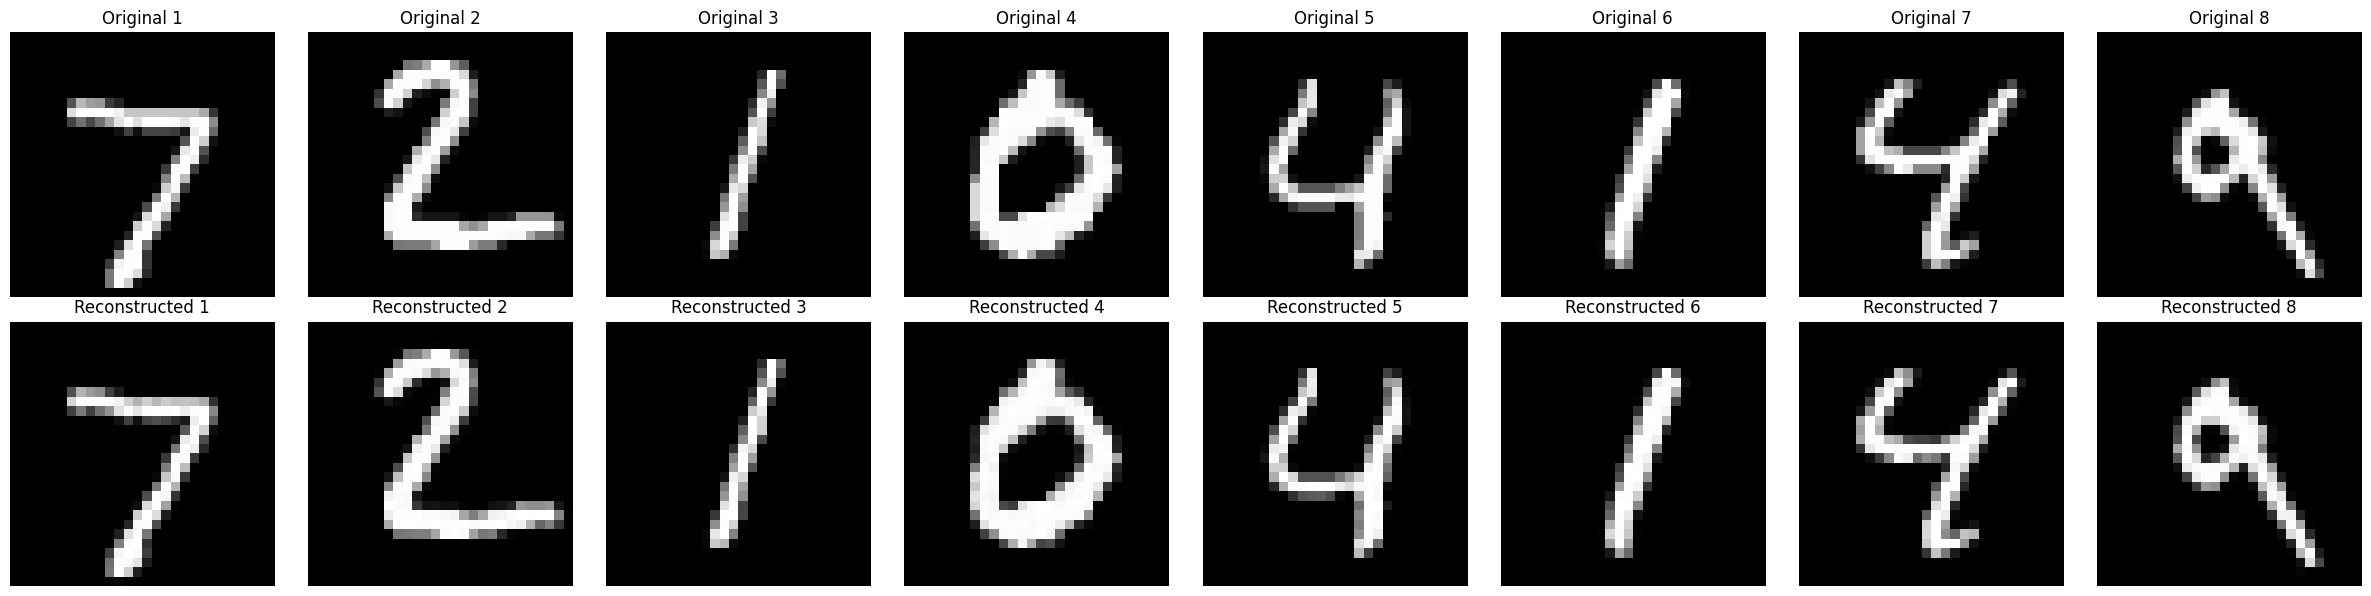

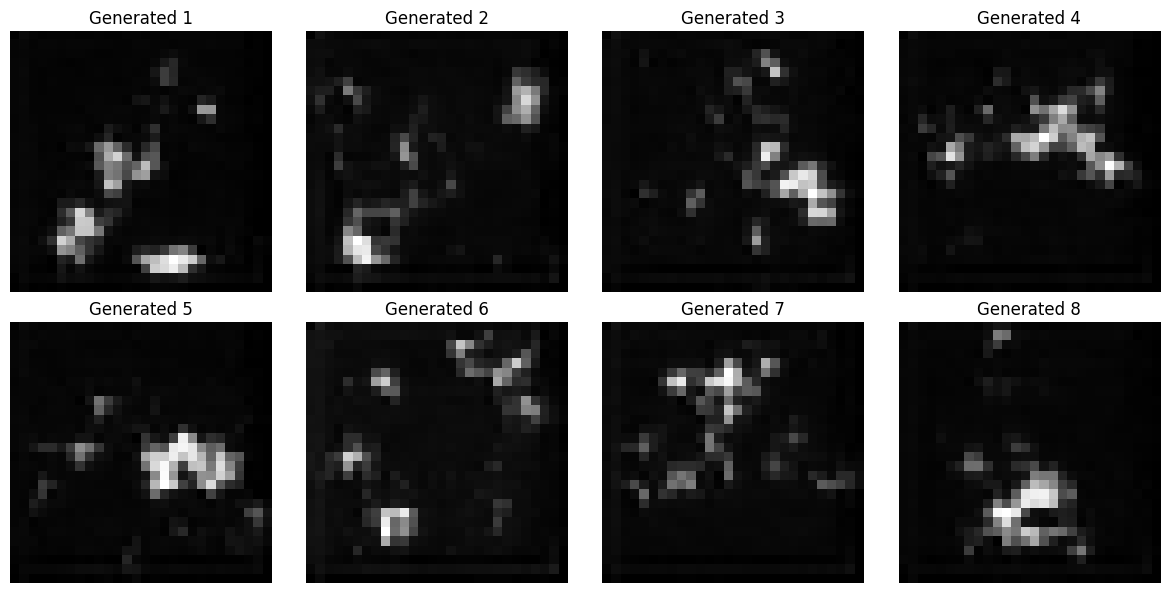


test evaluation results
  L1    : 0.009152
  MSE   : 0.000567
  LPIPS : 0.001259
  PSNR  : 38.6542 dB
  SSIM  : 0.997735
  FID   : 0.5426
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-06/eval_test_dq_1e-05_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:22<00:00,  5.90it/s, rec=0.0425, g=0.0000, d=N/A, Dq=-490.0353, KLt=3165.6614]



Epoch 1/10 [sd]
  Train - Rec: 0.0831, Reg(sd): -0.0014, Disc: 0.0000
  Val   - Rec Loss: 0.0438
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0438)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:36<00:00,  5.39it/s, rec=0.0320, g=0.0000, d=N/A, Dq=-527.8067, KLt=604.7763]



Epoch 2/10 [sd]
  Train - Rec: 0.0343, Reg(sd): -0.0047, Disc: 0.0000
  Val   - Rec Loss: 0.0300
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0300)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0115, Reg(sd): -0.0053, Disc: 1.0000
  Val   - Rec Loss: 0.0118
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0118)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:07<00:00,  4.50it/s, rec=0.0107, g=0.1487, d=1.0000, Dq=-545.6931, KLt=134.7065]



Epoch 9/10 [sd]
  Train - Rec: 0.0102, Reg(sd): -0.0054, Disc: 1.0000
  Val   - Rec Loss: 0.0103
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0103)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:07<00:00,  4.49it/s, rec=0.0091, g=0.1758, d=1.0000, Dq=-550.0247, KLt=54.2579] 



Epoch 10/10 [sd]
  Train - Rec: 0.0094, Reg(sd): -0.0054, Disc: 1.0000
  Val   - Rec Loss: 0.0092
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0092)

[sd] 训练完成! 最佳验证损失: 0.0092


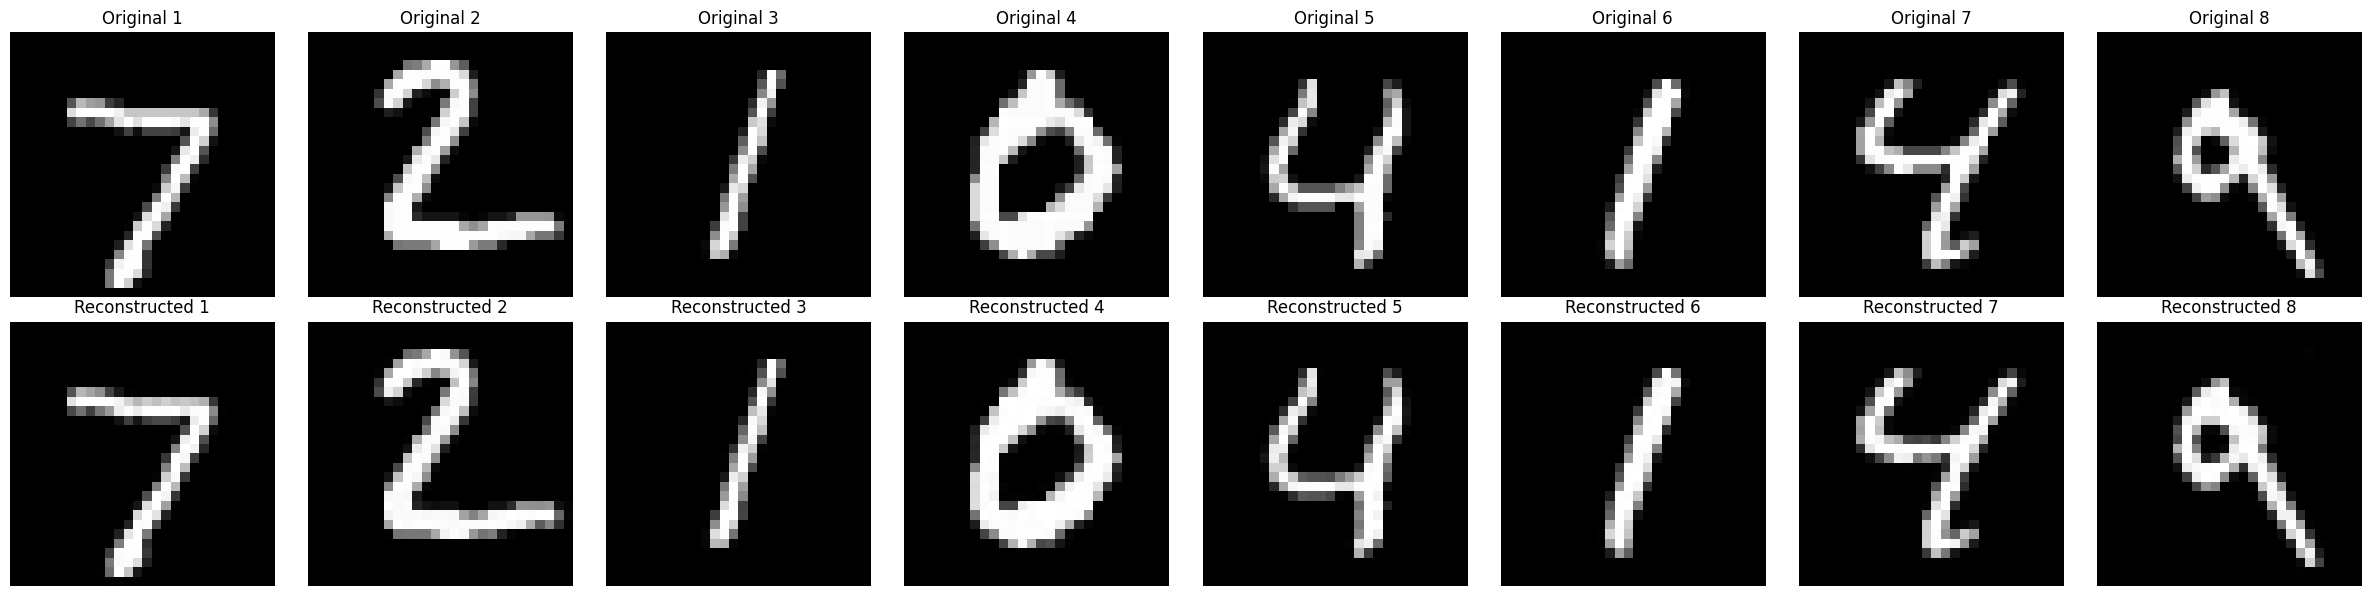

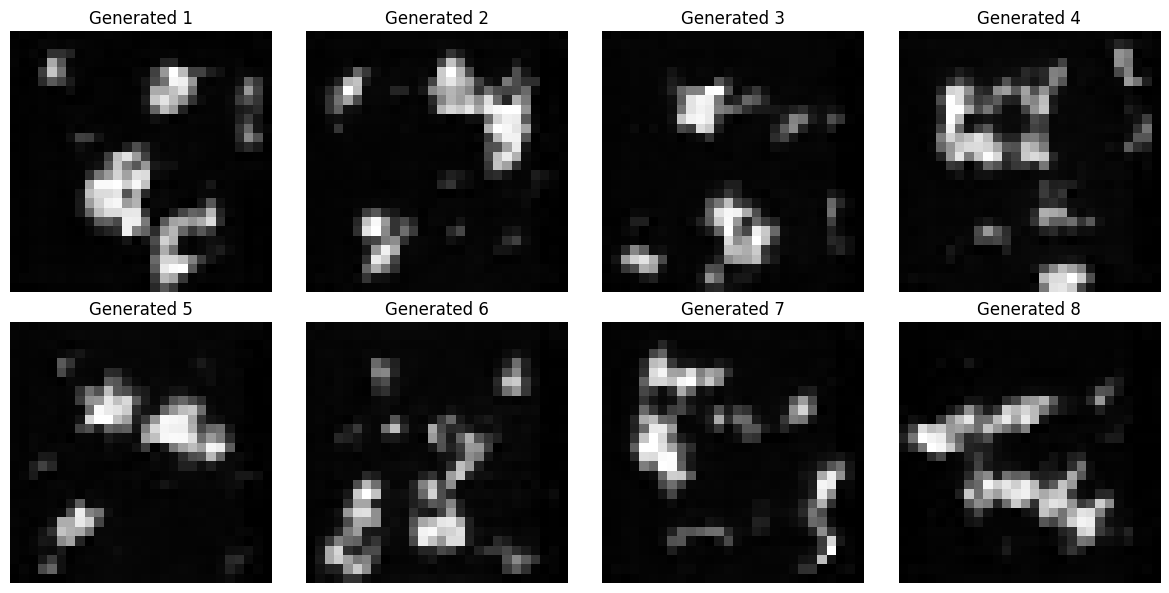


test evaluation results
  L1    : 0.008817
  MSE   : 0.000541
  LPIPS : 0.001162
  PSNR  : 38.8867 dB
  SSIM  : 0.998124
  FID   : 0.5360
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-06/eval_test_dq_1e-05_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:27<00:00,  5.73it/s, rec=0.0459, g=0.0000, d=N/A, Dq=-434.0890, KLt=3173.3931]



Epoch 1/10 [sd]
  Train - Rec: 0.0842, Reg(sd): -0.0002, Disc: 0.0000
  Val   - Rec Loss: 0.0432
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0432)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:39<00:00,  5.30it/s, rec=0.0290, g=0.0000, d=N/A, Dq=-499.4496, KLt=680.6122]



Epoch 2/10 [sd]
  Train - Rec: 0.0347, Reg(sd): -0.0041, Disc: 0.0000
  Val   - Rec Loss: 0.0284
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0284)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0112, Reg(sd): -0.0055, Disc: 0.9082
  Val   - Rec Loss: 0.0114
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0114)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:01<00:00,  4.64it/s, rec=0.0100, g=0.4756, d=0.8525, Dq=-549.6431, KLt=68.7603]  



Epoch 9/10 [sd]
  Train - Rec: 0.0101, Reg(sd): -0.0055, Disc: 0.7884
  Val   - Rec Loss: 0.0097
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0097)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.59it/s, rec=0.0103, g=0.4779, d=0.6169, Dq=-562.0542, KLt=125.4657] 



Epoch 10/10 [sd]
  Train - Rec: 0.0094, Reg(sd): -0.0055, Disc: 0.8171
  Val   - Rec Loss: 0.0098
  AE LR: 2.88e-05
  Global Step: 8430

[sd] 训练完成! 最佳验证损失: 0.0097


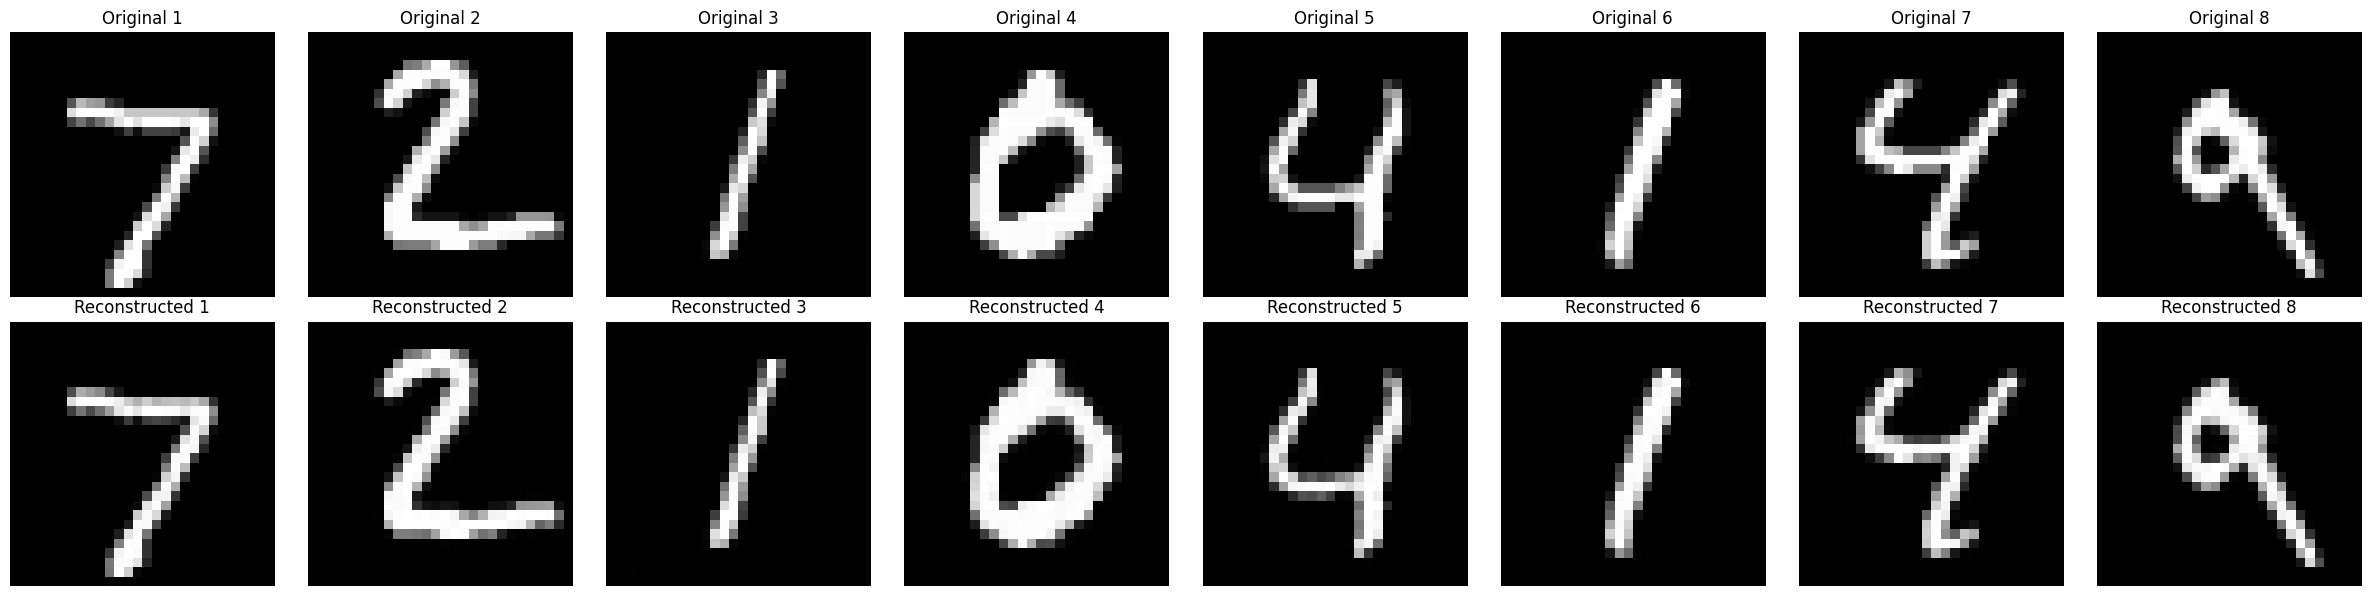

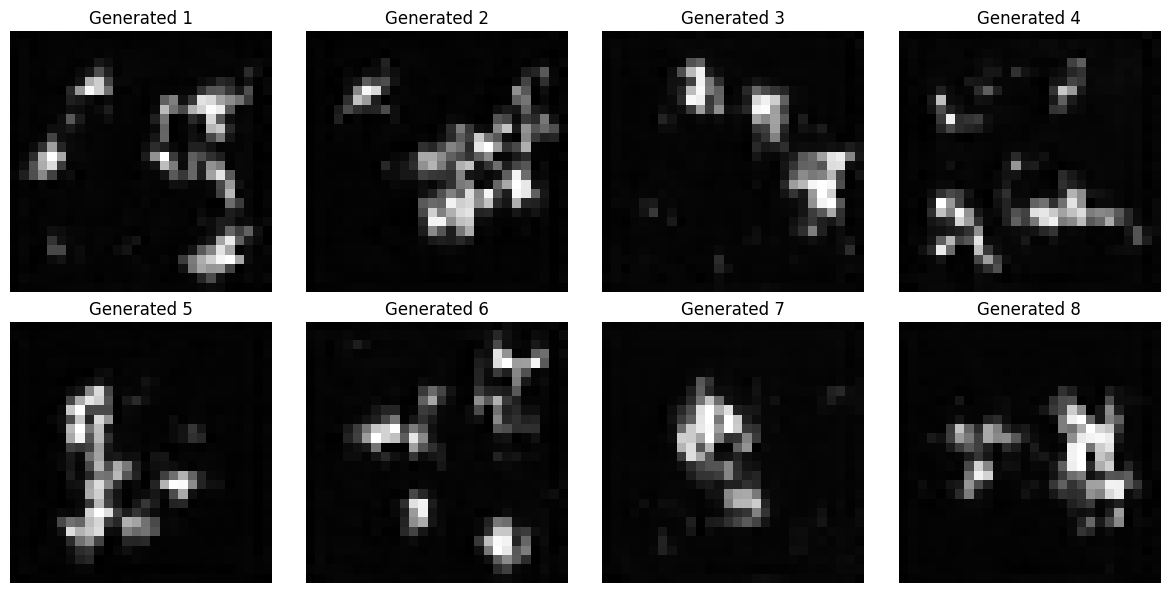


test evaluation results
  L1    : 0.009439
  MSE   : 0.000545
  LPIPS : 0.001212
  PSNR  : 38.8409 dB
  SSIM  : 0.996653
  FID   : 0.5784
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-06/eval_test_dq_1e-05_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:32<00:00,  5.51it/s, rec=0.0450, g=0.0000, d=N/A, Dq=-154.3012, KLt=3218.3354]



Epoch 1/10 [sd]
  Train - Rec: 0.0890, Reg(sd): 0.0030, Disc: 0.0000
  Val   - Rec Loss: 0.0474
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0474)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:36<00:00,  5.40it/s, rec=0.0258, g=0.0000, d=N/A, Dq=-299.0839, KLt=549.3461]



Epoch 2/10 [sd]
  Train - Rec: 0.0361, Reg(sd): 0.0002, Disc: 0.0000
  Val   - Rec Loss: 0.0295
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0295)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0116, Reg(sd): -0.0002, Disc: 1.0000
  Val   - Rec Loss: 0.0124
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0124)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.60it/s, rec=0.0102, g=0.4032, d=1.0000, Dq=-270.4452, KLt=88.5151] 



Epoch 9/10 [sd]
  Train - Rec: 0.0102, Reg(sd): -0.0002, Disc: 1.0000
  Val   - Rec Loss: 0.0097
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0097)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:10<00:00,  4.42it/s, rec=0.0098, g=0.6442, d=0.9994, Dq=-266.4621, KLt=171.1328]



Epoch 10/10 [sd]
  Train - Rec: 0.0093, Reg(sd): -0.0002, Disc: 0.9999
  Val   - Rec Loss: 0.0094
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0094)

[sd] 训练完成! 最佳验证损失: 0.0094


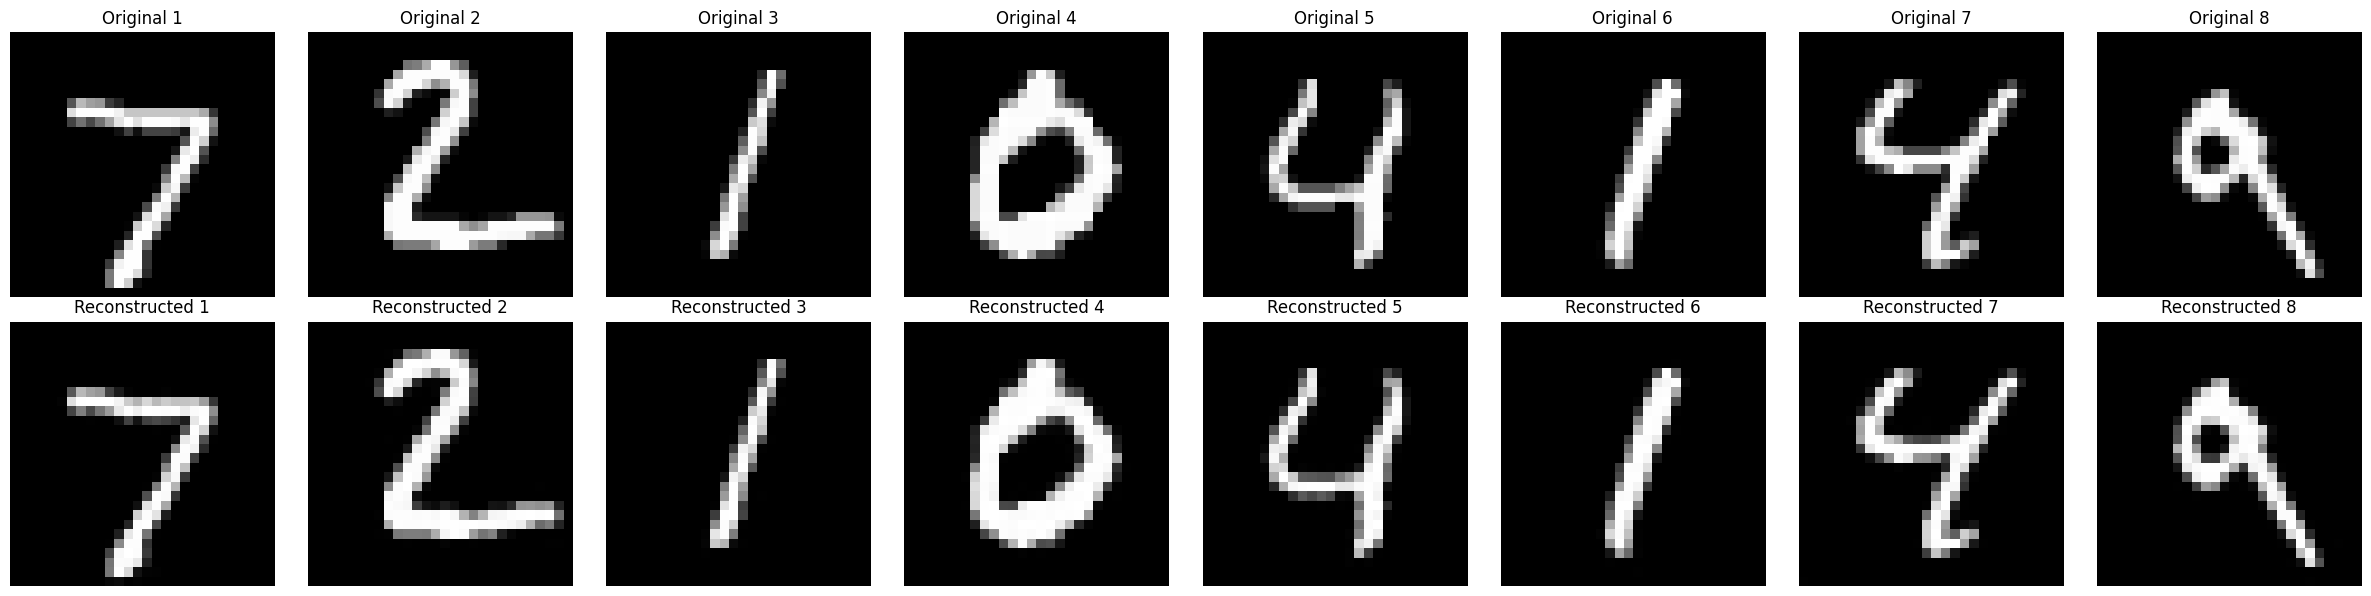

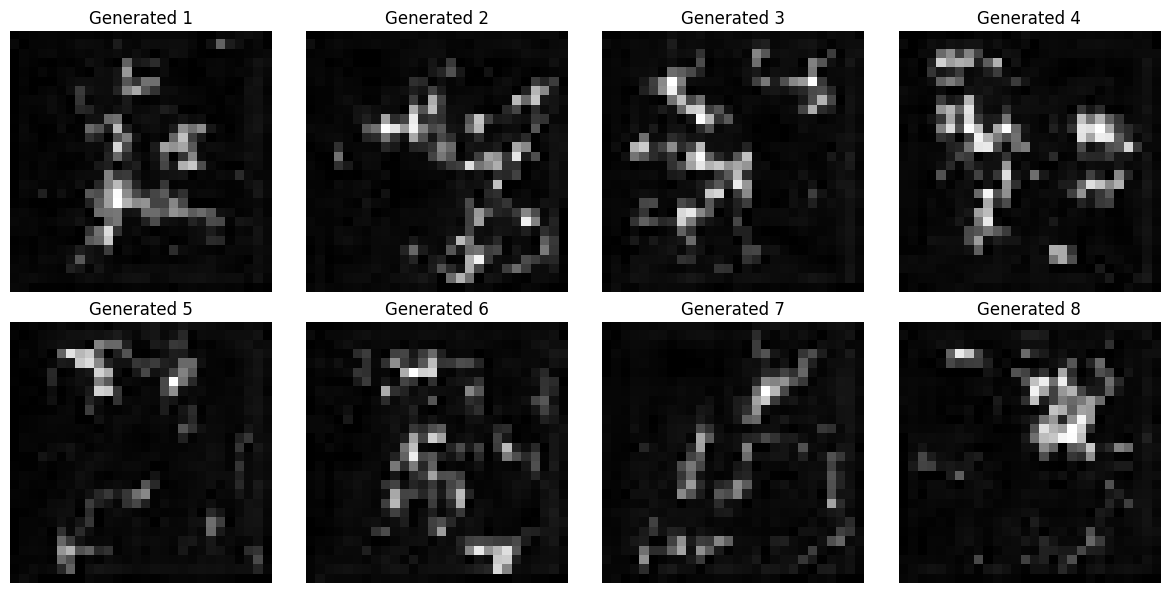


test evaluation results
  L1    : 0.009067
  MSE   : 0.000527
  LPIPS : 0.001127
  PSNR  : 39.0128 dB
  SSIM  : 0.997243
  FID   : 0.5335
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-06/eval_test_dq_1e-06_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:36<00:00,  5.38it/s, rec=0.0481, g=0.0000, d=N/A, Dq=17.3638, KLt=3539.0310] 



Epoch 1/10 [sd]
  Train - Rec: 0.0838, Reg(sd): 0.0032, Disc: 0.0000
  Val   - Rec Loss: 0.0472
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0472)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:29<00:00,  5.65it/s, rec=0.0246, g=0.0000, d=N/A, Dq=-205.8364, KLt=651.9382]



Epoch 2/10 [sd]
  Train - Rec: 0.0328, Reg(sd): 0.0003, Disc: 0.0000
  Val   - Rec Loss: 0.0243
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0243)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0109, Reg(sd): -0.0001, Disc: 1.0000
  Val   - Rec Loss: 0.0105
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0105)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:07<00:00,  4.49it/s, rec=0.0095, g=-0.0233, d=1.0000, Dq=-220.3460, KLt=172.3020]



Epoch 9/10 [sd]
  Train - Rec: 0.0097, Reg(sd): -0.0001, Disc: 1.0000
  Val   - Rec Loss: 0.0095
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0095)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:04<00:00,  4.56it/s, rec=0.0088, g=0.0832, d=1.0000, Dq=-217.9712, KLt=95.3163] 



Epoch 10/10 [sd]
  Train - Rec: 0.0089, Reg(sd): -0.0002, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0088)

[sd] 训练完成! 最佳验证损失: 0.0088


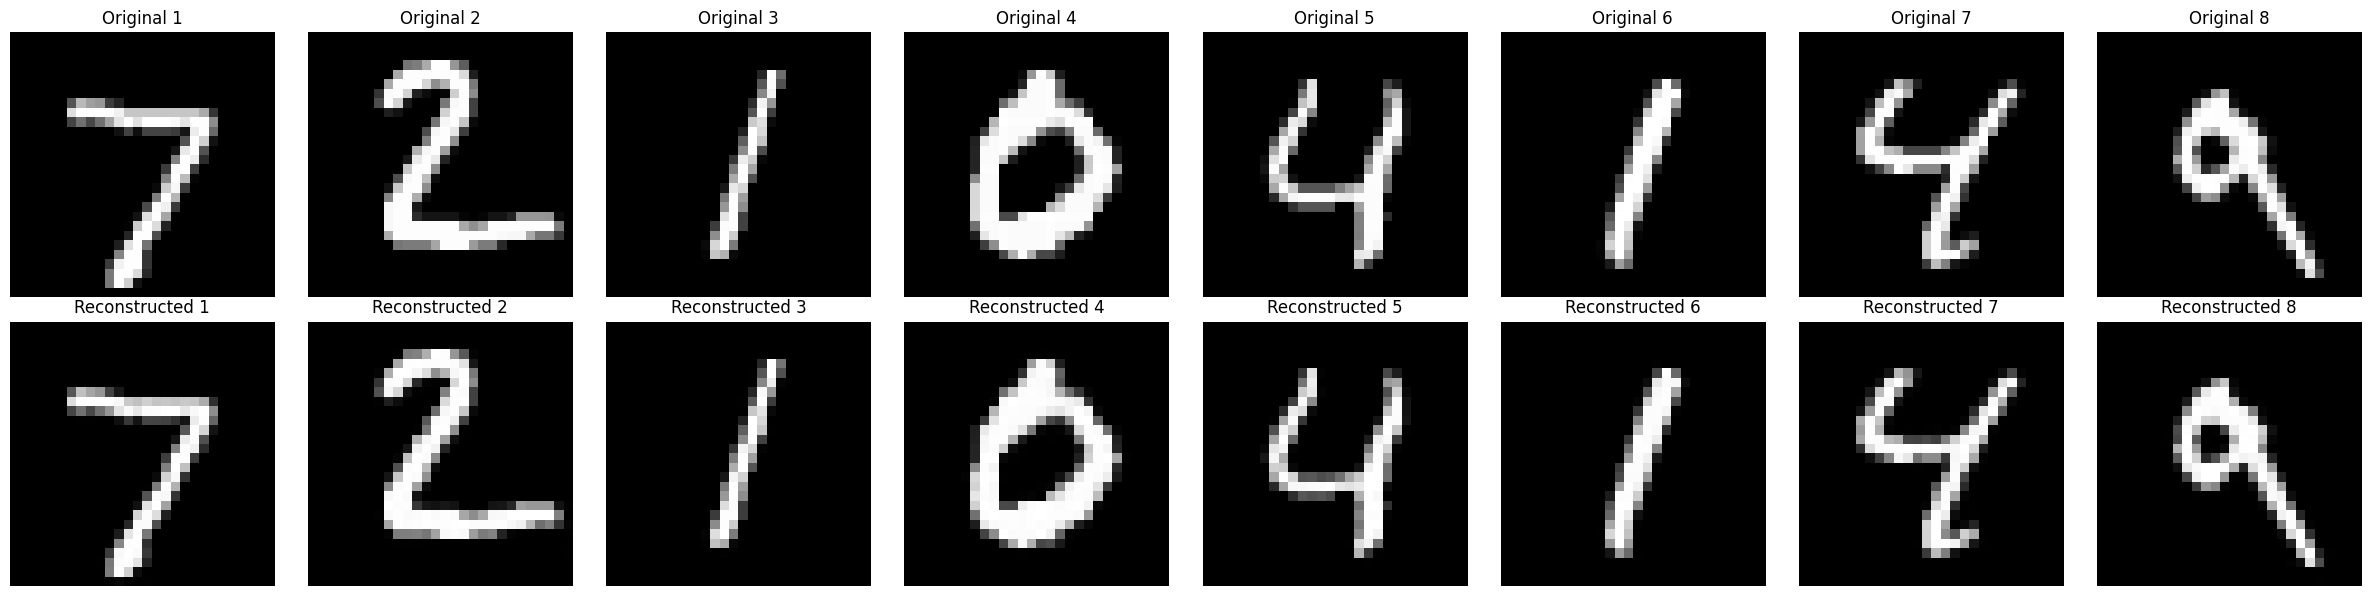

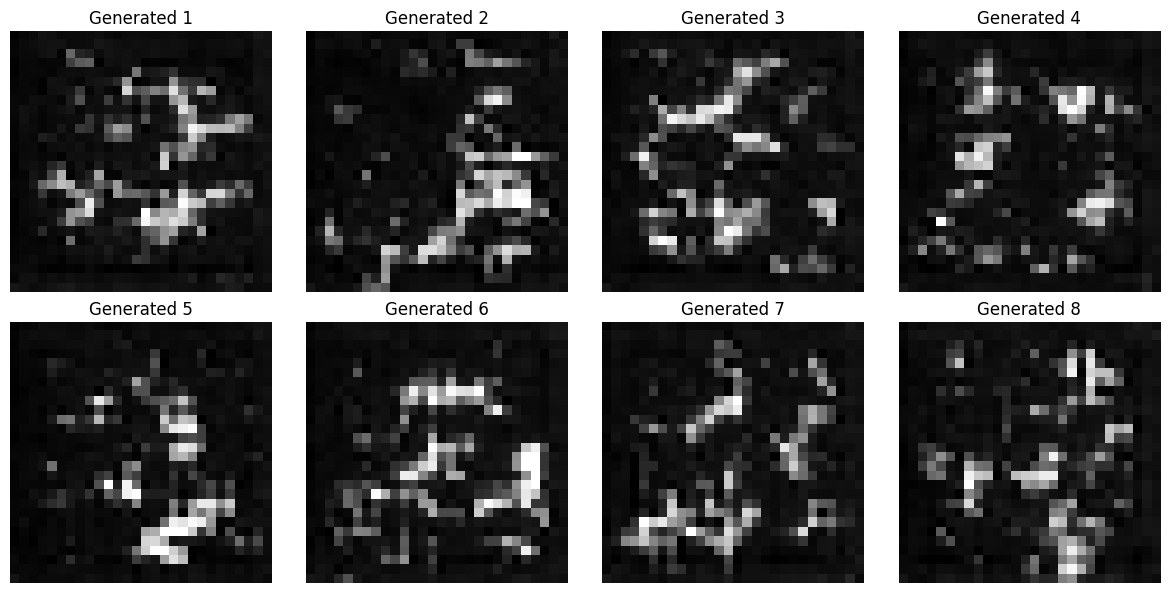


test evaluation results
  L1    : 0.008455
  MSE   : 0.000497
  LPIPS : 0.001010
  PSNR  : 39.2650 dB
  SSIM  : 0.998652
  FID   : 0.4532
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-06/eval_test_dq_1e-06_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:36<00:00,  5.37it/s, rec=0.0463, g=0.0000, d=N/A, Dq=-78.9392, KLt=3519.8843] 



Epoch 1/10 [sd]
  Train - Rec: 0.0868, Reg(sd): 0.0032, Disc: 0.0000
  Val   - Rec Loss: 0.0386
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0386)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:34<00:00,  5.47it/s, rec=0.0292, g=0.0000, d=N/A, Dq=-189.8133, KLt=777.3912]



Epoch 2/10 [sd]
  Train - Rec: 0.0328, Reg(sd): 0.0004, Disc: 0.0000
  Val   - Rec Loss: 0.0270
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0270)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0105, Reg(sd): -0.0001, Disc: 0.9760
  Val   - Rec Loss: 0.0103
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0103)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:19<00:00,  4.22it/s, rec=0.0092, g=0.5967, d=0.9231, Dq=-171.8315, KLt=91.8028]  



Epoch 9/10 [sd]
  Train - Rec: 0.0094, Reg(sd): -0.0001, Disc: 0.9650
  Val   - Rec Loss: 0.0092
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0092)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:21<00:00,  4.18it/s, rec=0.0089, g=-0.4173, d=0.9404, Dq=-163.4199, KLt=48.3052] 



Epoch 10/10 [sd]
  Train - Rec: 0.0087, Reg(sd): -0.0001, Disc: 0.9427
  Val   - Rec Loss: 0.0085
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0085)

[sd] 训练完成! 最佳验证损失: 0.0085


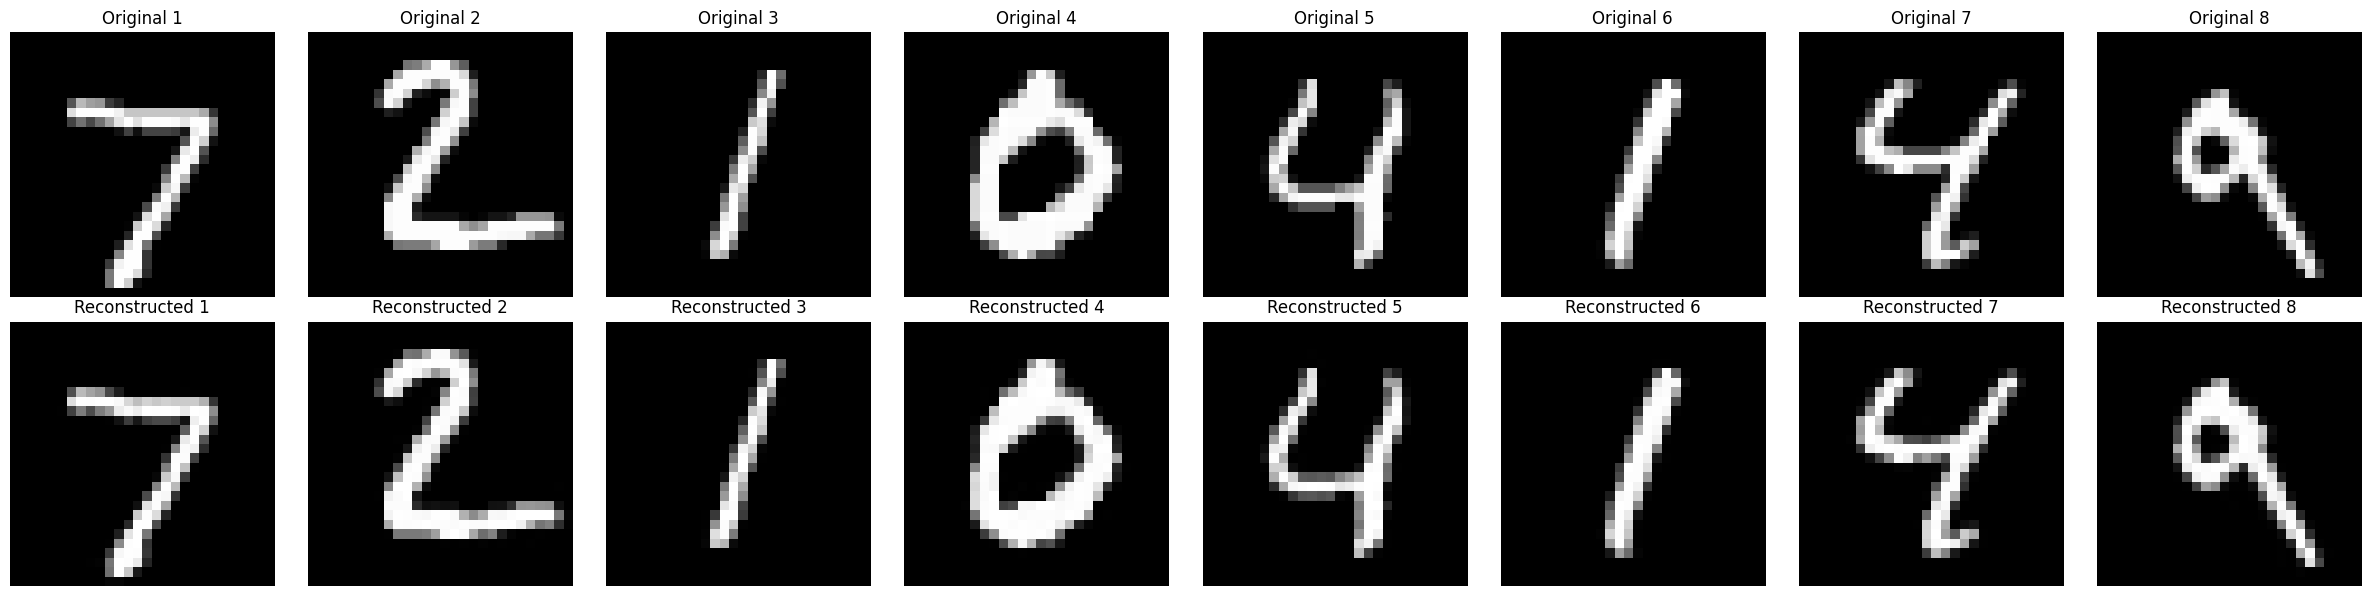

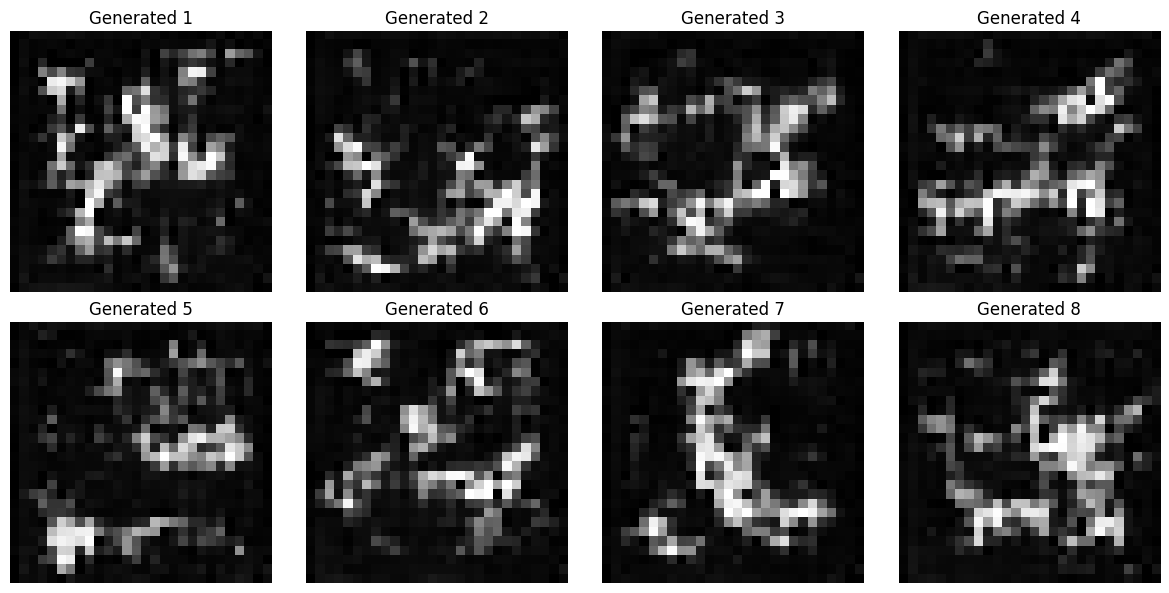


test evaluation results
  L1    : 0.008136
  MSE   : 0.000464
  LPIPS : 0.000965
  PSNR  : 39.5748 dB
  SSIM  : 0.998207
  FID   : 0.4886
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-06/eval_test_dq_1e-06_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:52<00:00,  4.89it/s, rec=0.0476, g=0.0000, d=N/A, Dq=-10.8573, KLt=3890.2139] 



Epoch 1/10 [sd]
  Train - Rec: 0.0886, Reg(sd): 0.0033, Disc: 0.0000
  Val   - Rec Loss: 0.0437
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0437)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.07it/s, rec=0.0271, g=0.0000, d=N/A, Dq=-135.9233, KLt=697.5297]



Epoch 2/10 [sd]
  Train - Rec: 0.0325, Reg(sd): 0.0005, Disc: 0.0000
  Val   - Rec Loss: 0.0247
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0247)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0108, Reg(sd): -0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0111
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0111)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:36<00:00,  3.90it/s, rec=0.0099, g=0.0881, d=1.0000, Dq=-96.4543, KLt=98.6768]  



Epoch 9/10 [sd]
  Train - Rec: 0.0096, Reg(sd): -0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0095
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0095)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:18<00:00,  4.24it/s, rec=0.0082, g=0.1603, d=1.0000, Dq=-100.4946, KLt=57.2986] 



Epoch 10/10 [sd]
  Train - Rec: 0.0088, Reg(sd): -0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0087
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0087)

[sd] 训练完成! 最佳验证损失: 0.0087


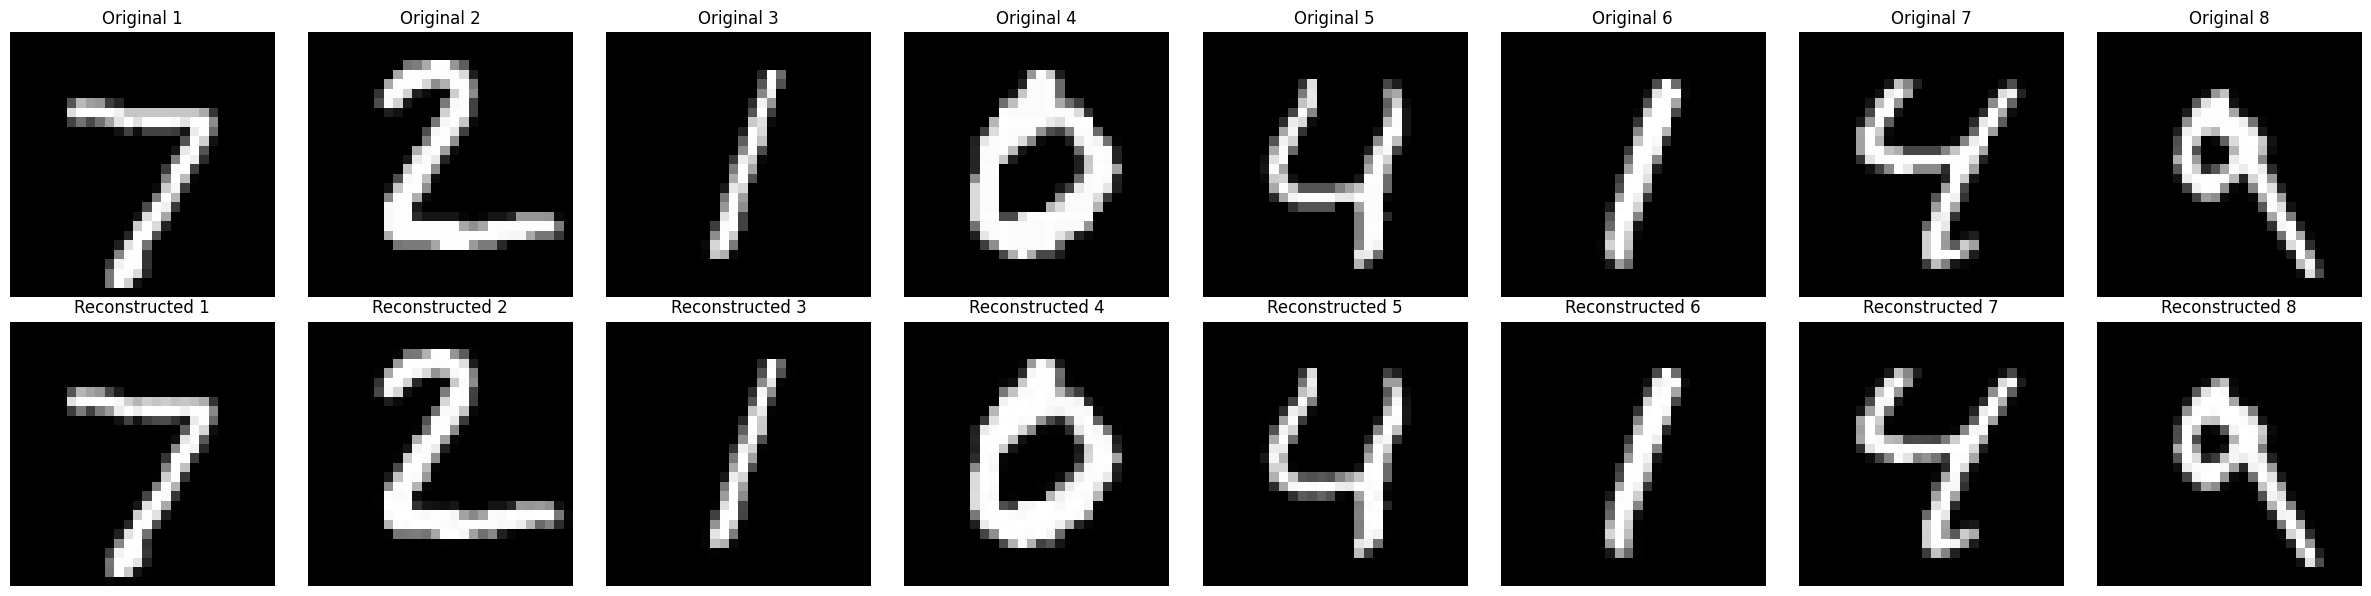

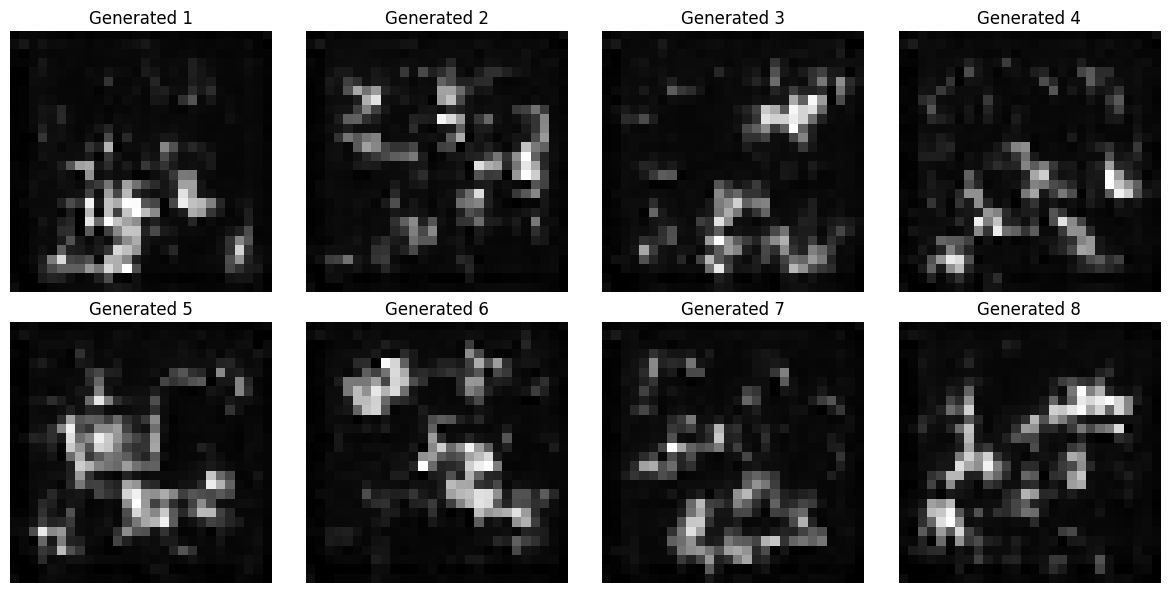


test evaluation results
  L1    : 0.008357
  MSE   : 0.000488
  LPIPS : 0.001003
  PSNR  : 39.3478 dB
  SSIM  : 0.998011
  FID   : 0.4695
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-06/eval_test_dq_1e-06_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:47<00:00,  5.04it/s, rec=0.0548, g=0.0000, d=N/A, Dq=-467.8602, KLt=739.4216]



Epoch 1/10 [sd]
  Train - Rec: 0.0934, Reg(sd): 0.0035, Disc: 0.0000
  Val   - Rec Loss: 0.0550
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0550)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.12it/s, rec=0.0382, g=0.0000, d=N/A, Dq=-548.9388, KLt=196.6000]



Epoch 2/10 [sd]
  Train - Rec: 0.0409, Reg(sd): -0.0040, Disc: 0.0000
  Val   - Rec Loss: 0.0403
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0403)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0133, Reg(sd): -0.0056, Disc: 0.9826
  Val   - Rec Loss: 0.0131
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0131)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:33<00:00,  3.95it/s, rec=0.0110, g=0.6653, d=0.9583, Dq=-583.0255, KLt=14.3612] 



Epoch 9/10 [sd]
  Train - Rec: 0.0118, Reg(sd): -0.0057, Disc: 0.9654
  Val   - Rec Loss: 0.0114
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0114)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:10<00:00,  4.43it/s, rec=0.0103, g=0.7323, d=0.9687, Dq=-584.5558, KLt=14.6390] 



Epoch 10/10 [sd]
  Train - Rec: 0.0108, Reg(sd): -0.0057, Disc: 0.9438
  Val   - Rec Loss: 0.0107
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0107)

[sd] 训练完成! 最佳验证损失: 0.0107


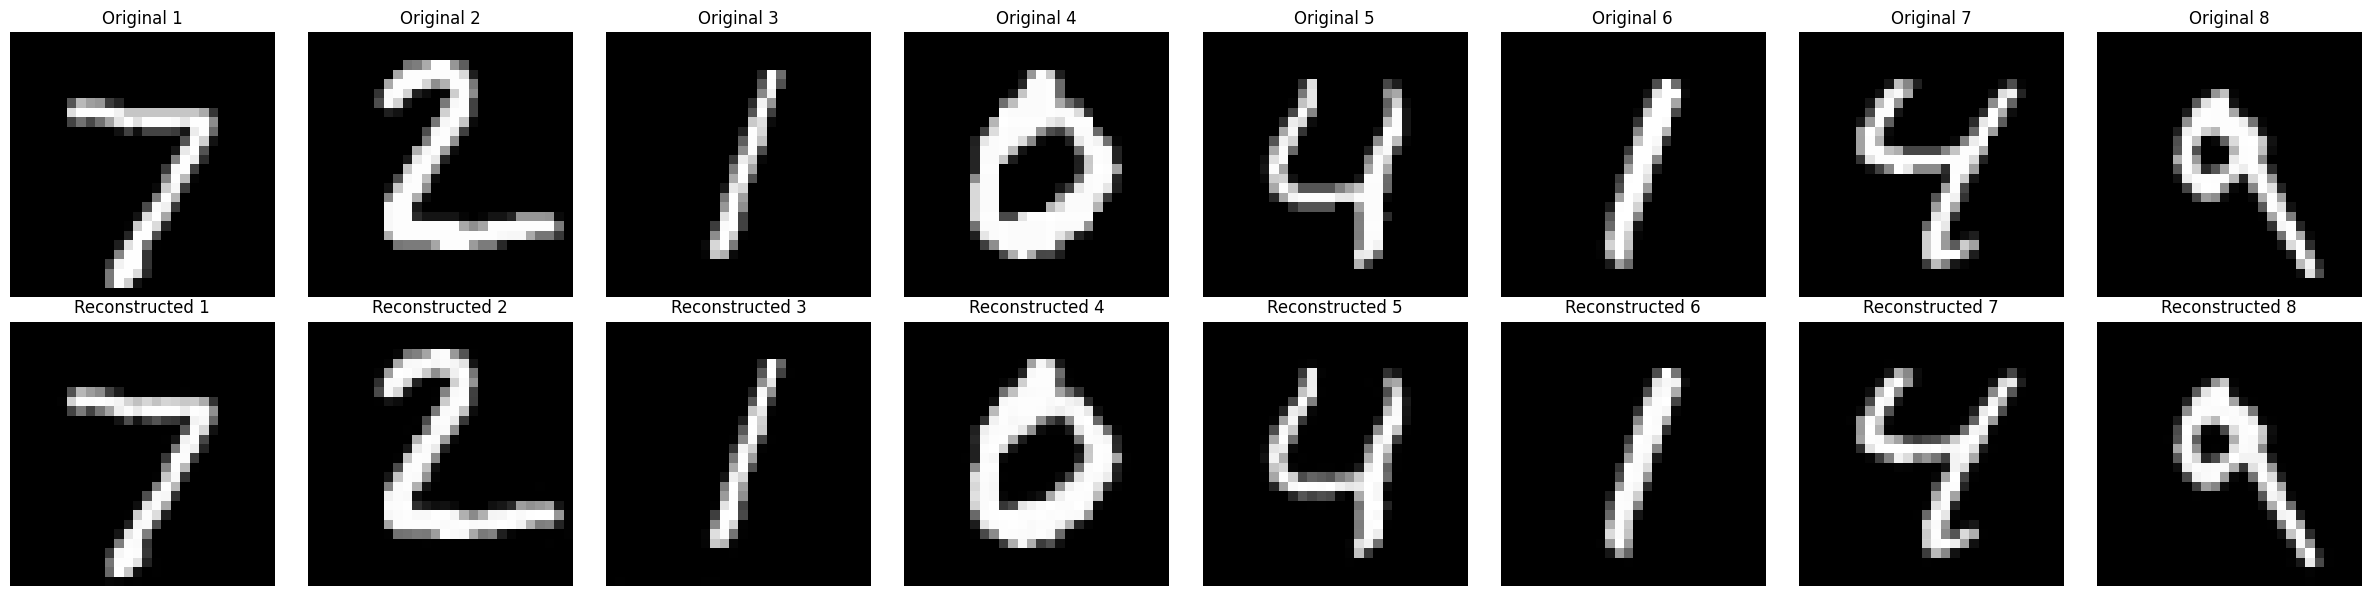

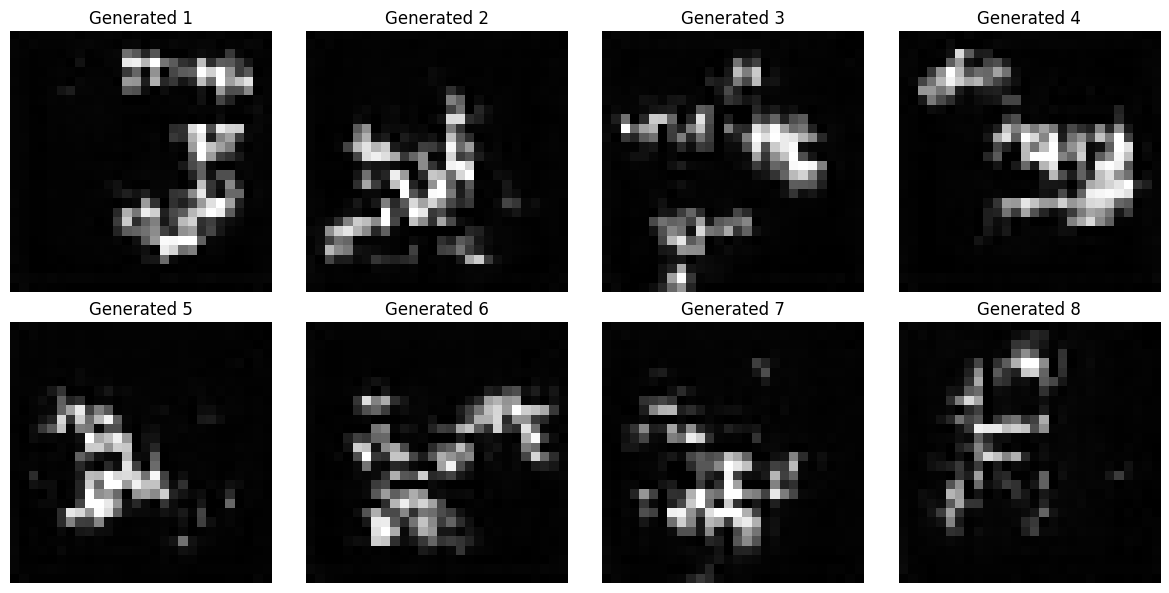


test evaluation results
  L1    : 0.010196
  MSE   : 0.000774
  LPIPS : 0.001599
  PSNR  : 37.2975 dB
  SSIM  : 0.997716
  FID   : 0.6252
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-05/eval_test_dq_1e-05_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.05it/s, rec=0.0545, g=0.0000, d=N/A, Dq=-447.2961, KLt=775.9692]



Epoch 1/10 [sd]
  Train - Rec: 0.0927, Reg(sd): 0.0039, Disc: 0.0000
  Val   - Rec Loss: 0.0564
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0564)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.05it/s, rec=0.0346, g=0.0000, d=N/A, Dq=-545.2845, KLt=175.8971]



Epoch 2/10 [sd]
  Train - Rec: 0.0397, Reg(sd): -0.0038, Disc: 0.0000
  Val   - Rec Loss: 0.0318
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0318)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0138, Reg(sd): -0.0056, Disc: 1.0000
  Val   - Rec Loss: 0.0137
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0137)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:26<00:00,  4.07it/s, rec=0.0125, g=0.0462, d=1.0000, Dq=-577.6931, KLt=22.8520] 



Epoch 9/10 [sd]
  Train - Rec: 0.0122, Reg(sd): -0.0057, Disc: 1.0000
  Val   - Rec Loss: 0.0121
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0121)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:18<00:00,  4.24it/s, rec=0.0111, g=0.2137, d=1.0000, Dq=-581.6528, KLt=12.9032]



Epoch 10/10 [sd]
  Train - Rec: 0.0111, Reg(sd): -0.0057, Disc: 1.0000
  Val   - Rec Loss: 0.0108
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0108)

[sd] 训练完成! 最佳验证损失: 0.0108


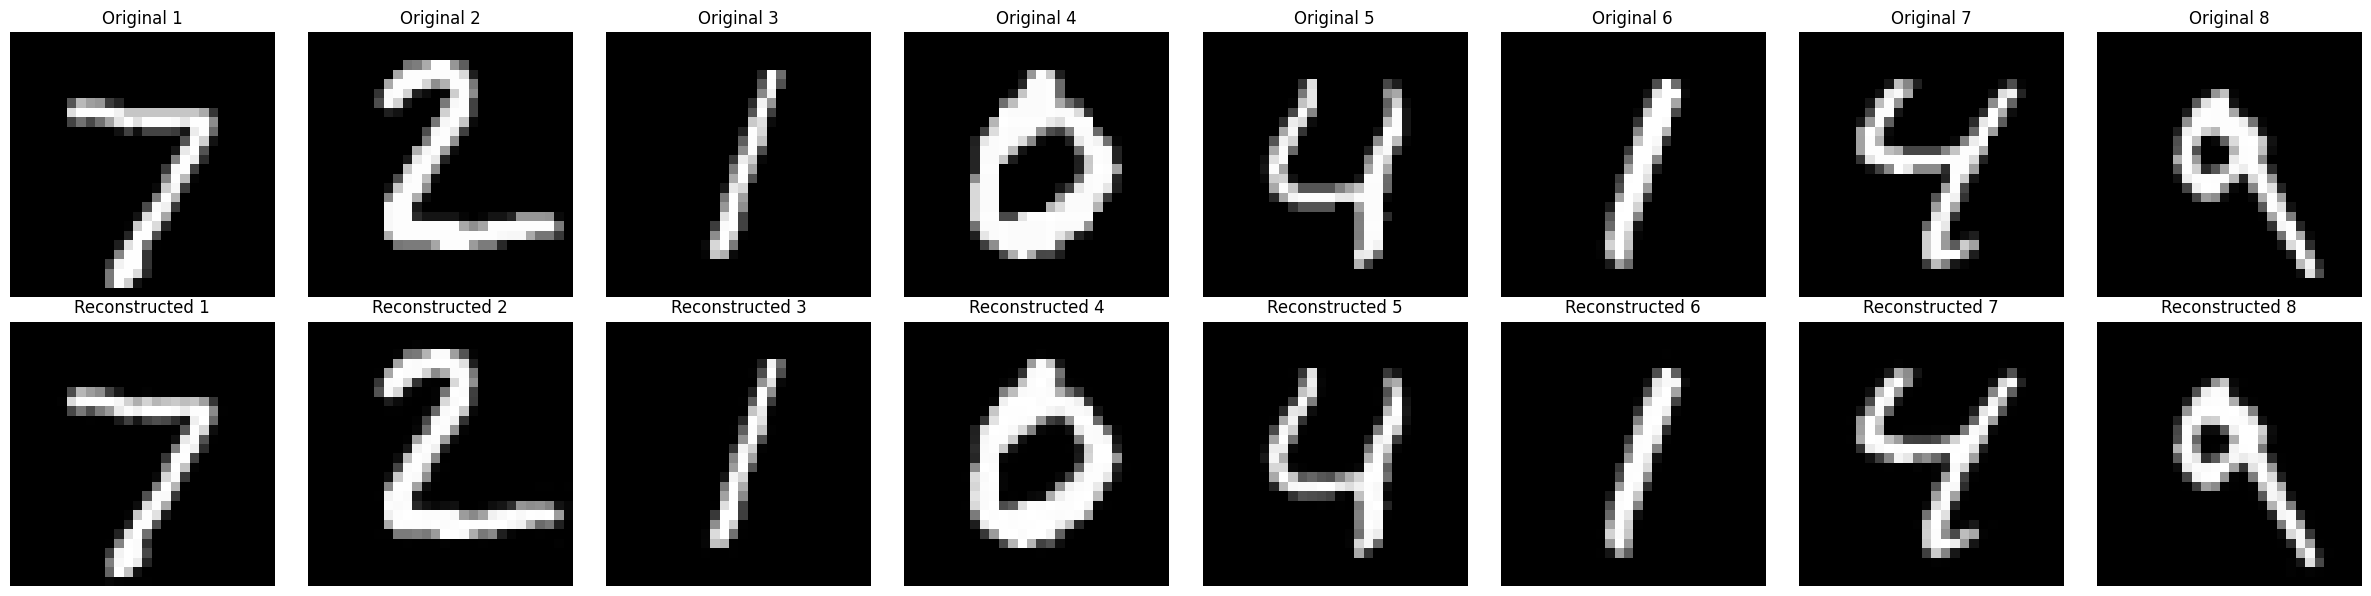

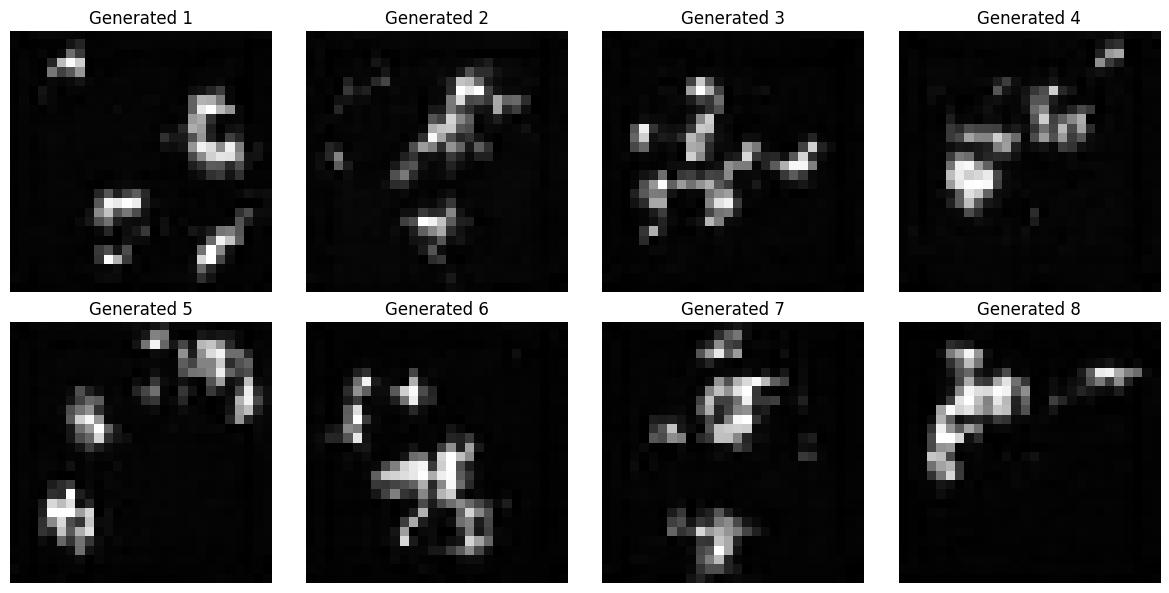


test evaluation results
  L1    : 0.010262
  MSE   : 0.000780
  LPIPS : 0.001666
  PSNR  : 37.2646 dB
  SSIM  : 0.997510
  FID   : 0.7028
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-05/eval_test_dq_1e-05_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.07it/s, rec=0.0465, g=0.0000, d=N/A, Dq=-451.0560, KLt=761.6140]



Epoch 1/10 [sd]
  Train - Rec: 0.0911, Reg(sd): 0.0034, Disc: 0.0000
  Val   - Rec Loss: 0.0534
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0534)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.12it/s, rec=0.0377, g=0.0000, d=N/A, Dq=-512.0236, KLt=202.0884]



Epoch 2/10 [sd]
  Train - Rec: 0.0386, Reg(sd): -0.0035, Disc: 0.0000
  Val   - Rec Loss: 0.0327
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0327)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0129, Reg(sd): -0.0055, Disc: 1.0000
  Val   - Rec Loss: 0.0123
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0123)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:31<00:00,  3.99it/s, rec=0.0111, g=0.0327, d=1.0000, Dq=-572.9971, KLt=17.2328] 



Epoch 9/10 [sd]
  Train - Rec: 0.0116, Reg(sd): -0.0055, Disc: 1.0000
  Val   - Rec Loss: 0.0114
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0114)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:08<00:00,  4.47it/s, rec=0.0110, g=0.0246, d=1.0000, Dq=-553.3818, KLt=12.2724] 



Epoch 10/10 [sd]
  Train - Rec: 0.0107, Reg(sd): -0.0056, Disc: 1.0000
  Val   - Rec Loss: 0.0106
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0106)

[sd] 训练完成! 最佳验证损失: 0.0106


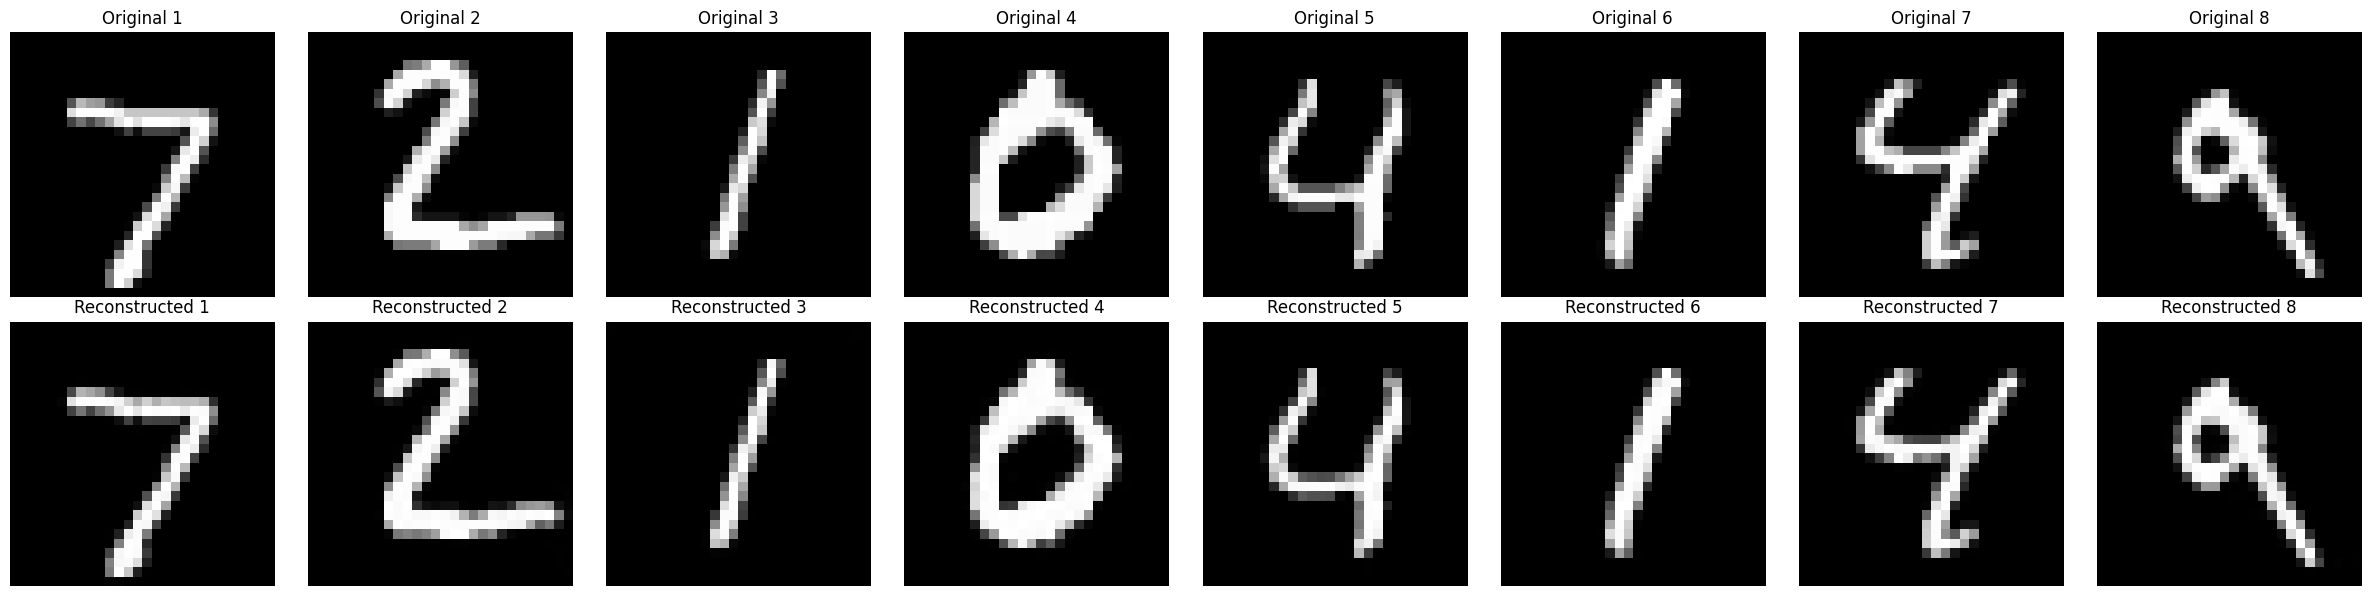

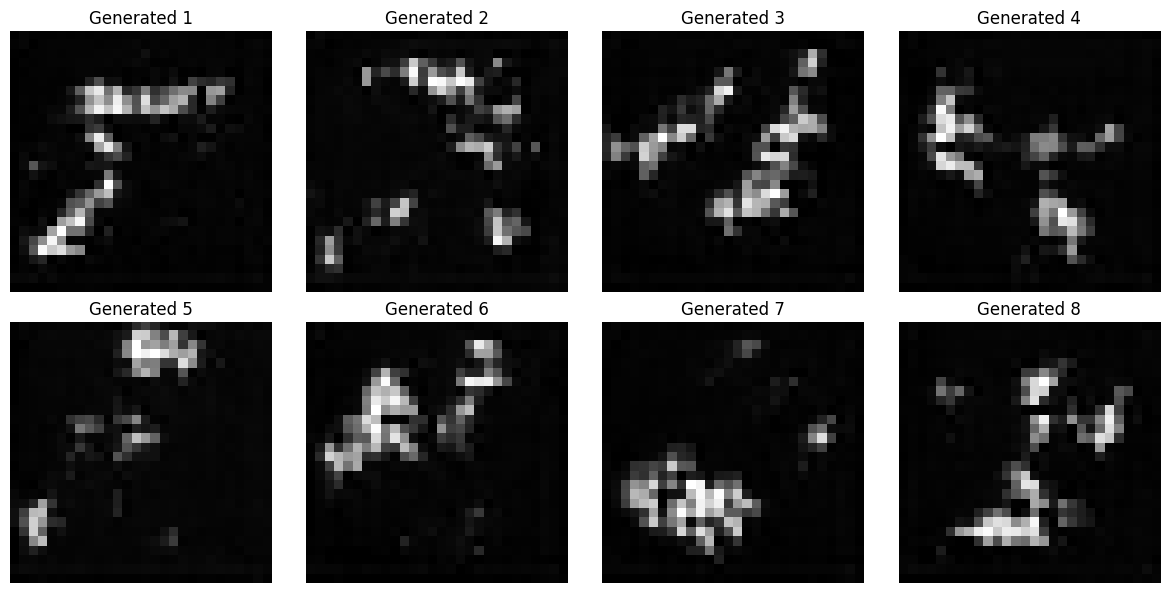


test evaluation results
  L1    : 0.010155
  MSE   : 0.000722
  LPIPS : 0.001516
  PSNR  : 37.6025 dB
  SSIM  : 0.997494
  FID   : 0.6718
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-05/eval_test_dq_1e-05_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:45<00:00,  5.10it/s, rec=0.0487, g=0.0000, d=N/A, Dq=-401.4257, KLt=810.5464]



Epoch 1/10 [sd]
  Train - Rec: 0.0973, Reg(sd): 0.0042, Disc: 0.0000
  Val   - Rec Loss: 0.0470
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0470)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.06it/s, rec=0.0316, g=0.0000, d=N/A, Dq=-464.1733, KLt=185.7002]



Epoch 2/10 [sd]
  Train - Rec: 0.0382, Reg(sd): -0.0029, Disc: 0.0000
  Val   - Rec Loss: 0.0357
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0357)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0122, Reg(sd): -0.0047, Disc: 1.0055
  Val   - Rec Loss: 0.0120
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0120)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:31<00:00,  3.99it/s, rec=0.0103, g=-0.3372, d=0.9917, Dq=-492.5329, KLt=14.4084]



Epoch 9/10 [sd]
  Train - Rec: 0.0109, Reg(sd): -0.0048, Disc: 0.9990
  Val   - Rec Loss: 0.0106
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0106)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:15<00:00,  4.31it/s, rec=0.0101, g=-0.4403, d=0.9893, Dq=-512.8314, KLt=12.2500]



Epoch 10/10 [sd]
  Train - Rec: 0.0101, Reg(sd): -0.0049, Disc: 0.9886
  Val   - Rec Loss: 0.0099
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0099)

[sd] 训练完成! 最佳验证损失: 0.0099


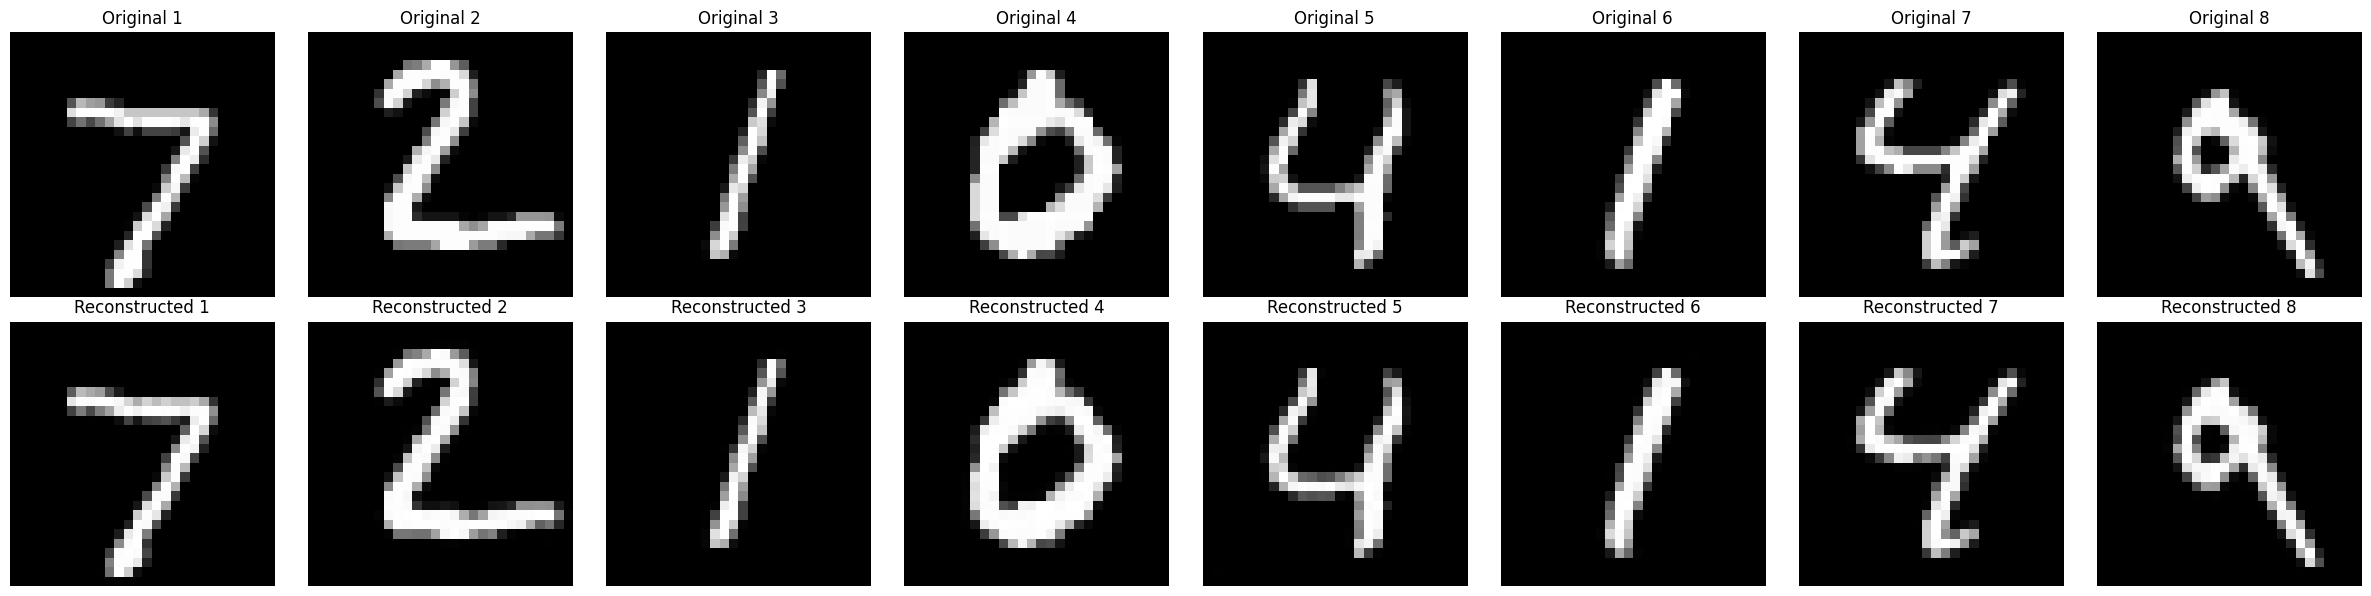

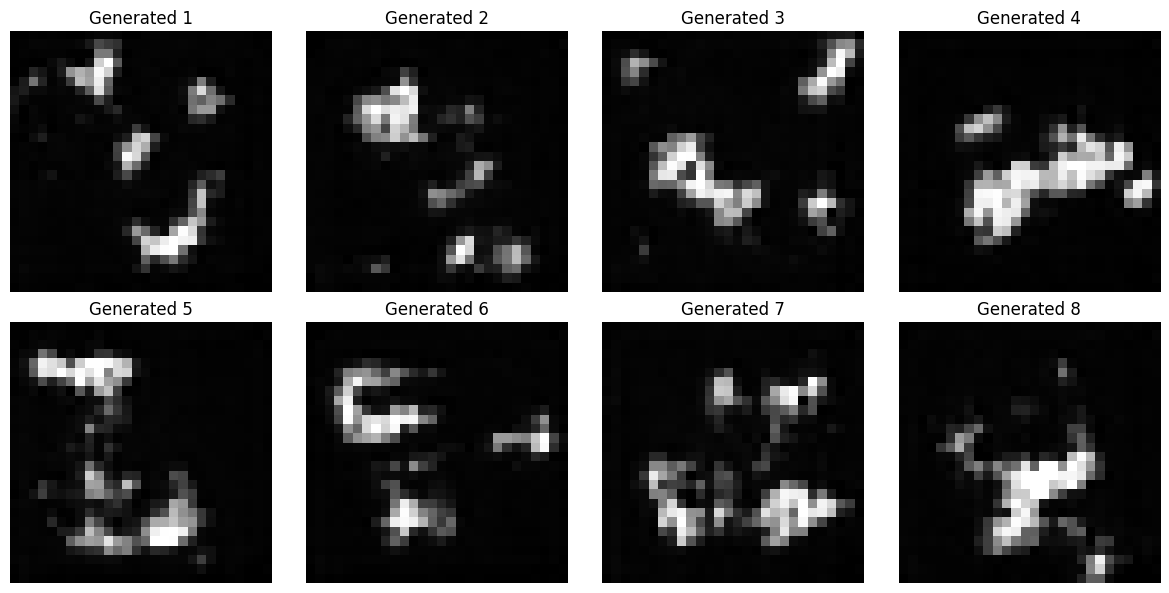


test evaluation results
  L1    : 0.009441
  MSE   : 0.000668
  LPIPS : 0.001371
  PSNR  : 37.9447 dB
  SSIM  : 0.997812
  FID   : 0.5844
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-05/eval_test_dq_1e-05_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:48<00:00,  5.00it/s, rec=0.0502, g=0.0000, d=N/A, Dq=275.2925, KLt=682.4845]



Epoch 1/10 [sd]
  Train - Rec: 0.0871, Reg(sd): 0.0077, Disc: 0.0000
  Val   - Rec Loss: 0.0495
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0495)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:49<00:00,  4.97it/s, rec=0.0362, g=0.0000, d=N/A, Dq=-128.4358, KLt=165.7264]



Epoch 2/10 [sd]
  Train - Rec: 0.0386, Reg(sd): 0.0013, Disc: 0.0000
  Val   - Rec Loss: 0.0359
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0359)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0123, Reg(sd): -0.0001, Disc: 0.9044
  Val   - Rec Loss: 0.0123
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0123)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:15<00:00,  4.31it/s, rec=0.0104, g=-0.4734, d=0.9201, Dq=-294.6369, KLt=19.2956]



Epoch 9/10 [sd]
  Train - Rec: 0.0111, Reg(sd): -0.0001, Disc: 0.8884
  Val   - Rec Loss: 0.0107
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0107)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:19<00:00,  4.23it/s, rec=0.0095, g=0.0159, d=0.8467, Dq=-292.2266, KLt=13.3241] 



Epoch 10/10 [sd]
  Train - Rec: 0.0101, Reg(sd): -0.0002, Disc: 0.9120
  Val   - Rec Loss: 0.0103
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0103)

[sd] 训练完成! 最佳验证损失: 0.0103


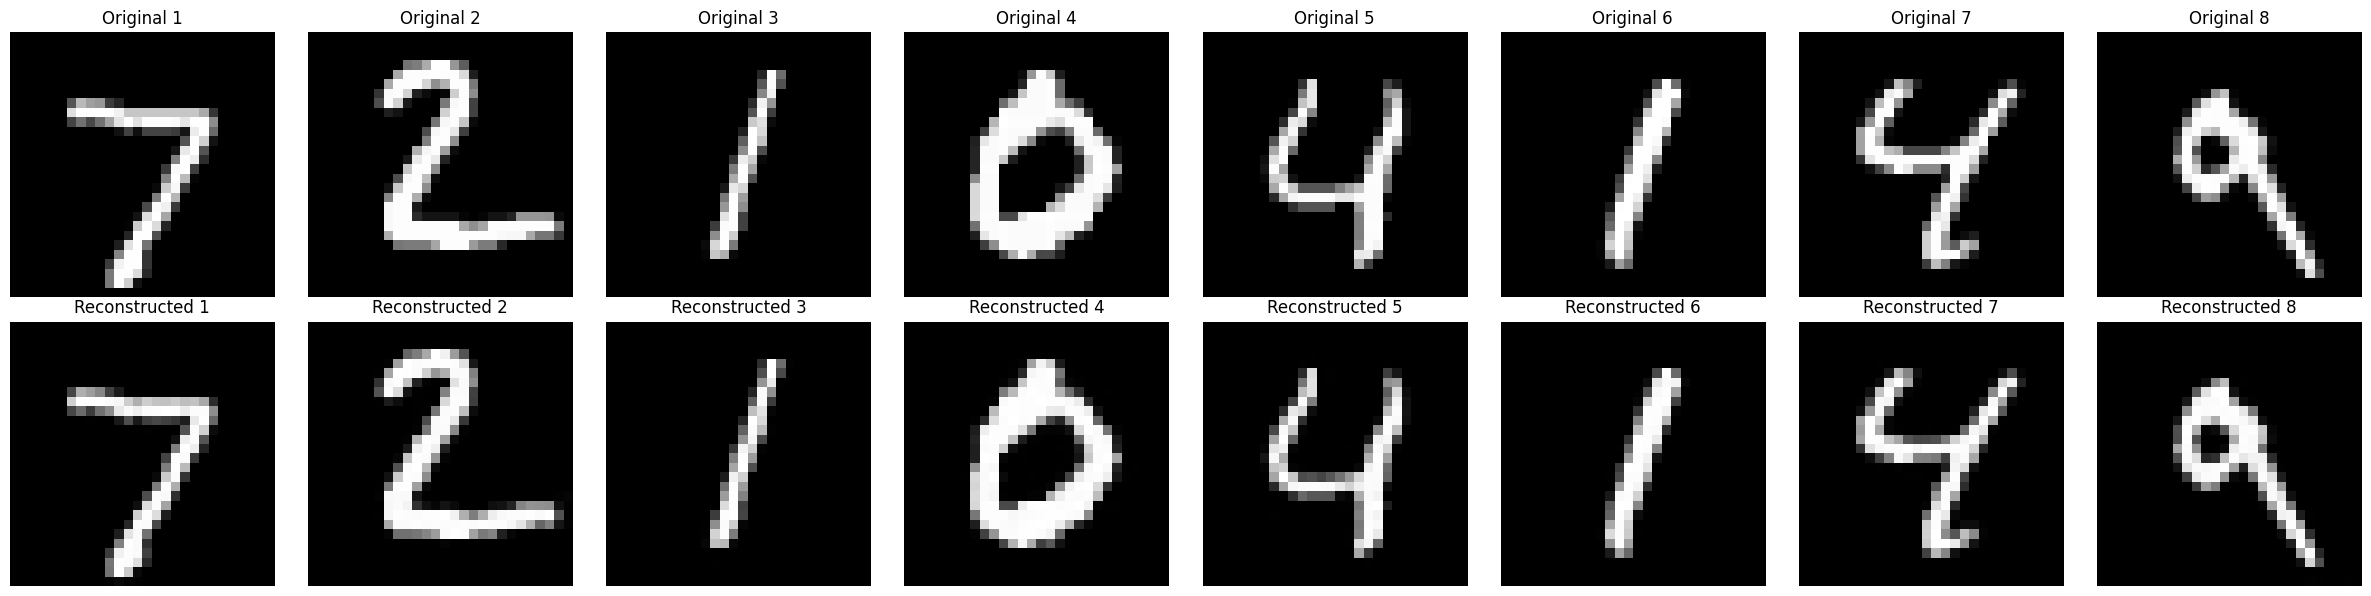

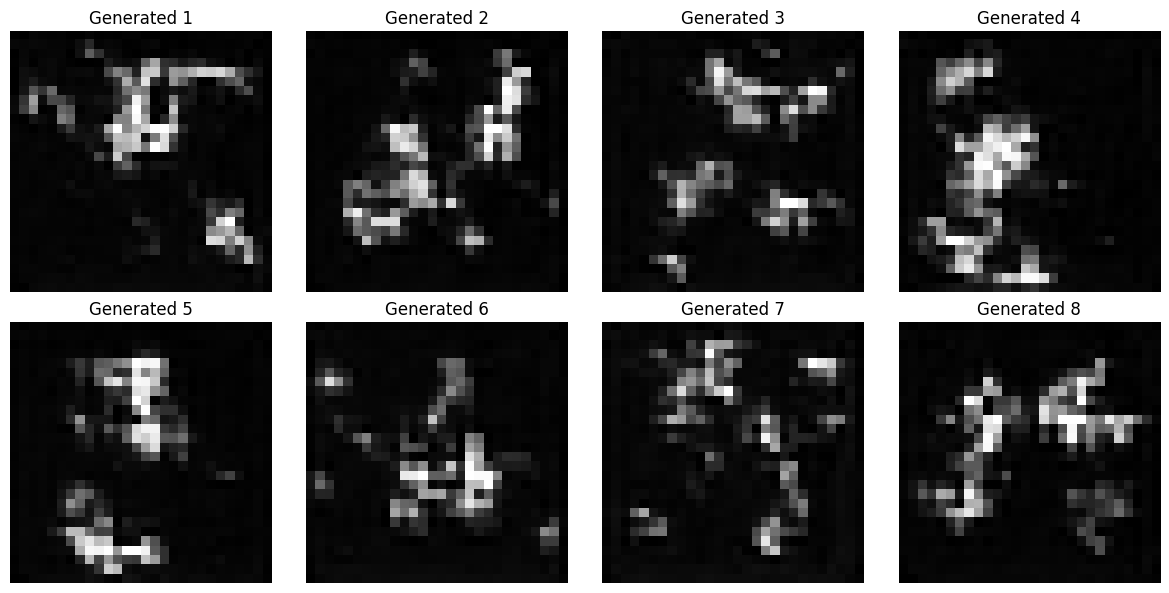


test evaluation results
  L1    : 0.009878
  MSE   : 0.000693
  LPIPS : 0.001396
  PSNR  : 37.7535 dB
  SSIM  : 0.996763
  FID   : 0.6006
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-05/eval_test_dq_1e-06_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:55<00:00,  4.80it/s, rec=0.0467, g=0.0000, d=N/A, Dq=166.2368, KLt=716.1410]



Epoch 1/10 [sd]
  Train - Rec: 0.0881, Reg(sd): 0.0074, Disc: 0.0000
  Val   - Rec Loss: 0.0467
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0467)


Epoch 2 [sd]: 100%|██████████| 843/843 [03:00<00:00,  4.67it/s, rec=0.0305, g=0.0000, d=N/A, Dq=-265.3023, KLt=183.8719]



Epoch 2/10 [sd]
  Train - Rec: 0.0365, Reg(sd): 0.0012, Disc: 0.0000
  Val   - Rec Loss: 0.0336
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0336)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0119, Reg(sd): -0.0002, Disc: 0.9768
  Val   - Rec Loss: 0.0114
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0114)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:08<00:00,  4.48it/s, rec=0.0110, g=0.9820, d=0.9702, Dq=-366.8486, KLt=12.8022] 



Epoch 9/10 [sd]
  Train - Rec: 0.0107, Reg(sd): -0.0002, Disc: 0.9588
  Val   - Rec Loss: 0.0106
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0106)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:28<00:00,  4.05it/s, rec=0.0096, g=0.6233, d=0.9581, Dq=-365.3167, KLt=9.6485]  



Epoch 10/10 [sd]
  Train - Rec: 0.0098, Reg(sd): -0.0003, Disc: 0.9243
  Val   - Rec Loss: 0.0096
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0096)

[sd] 训练完成! 最佳验证损失: 0.0096


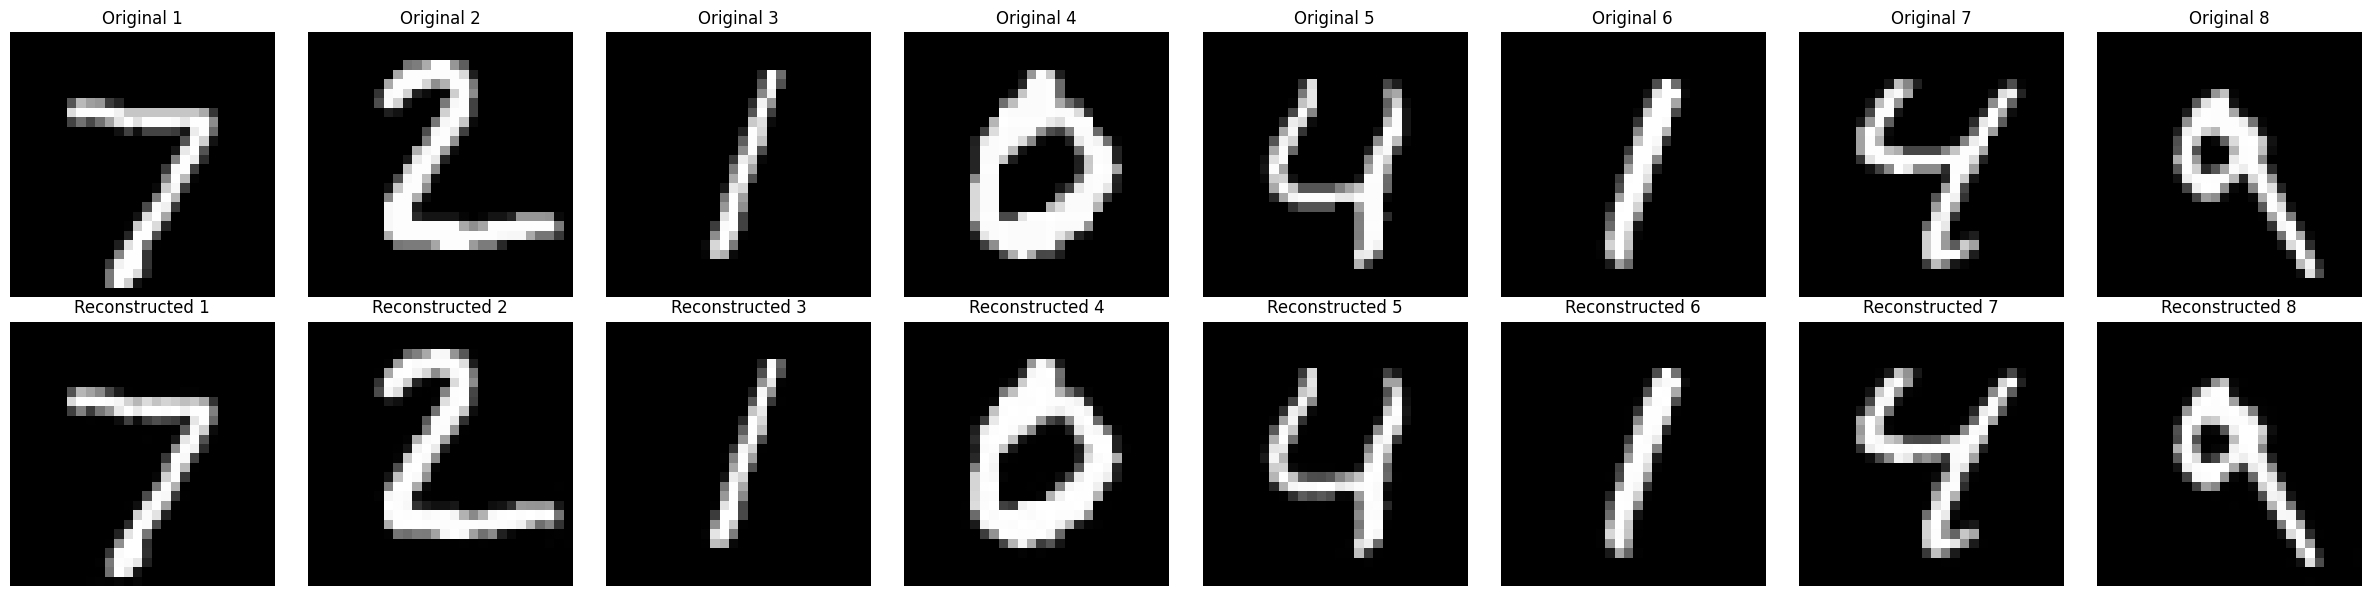

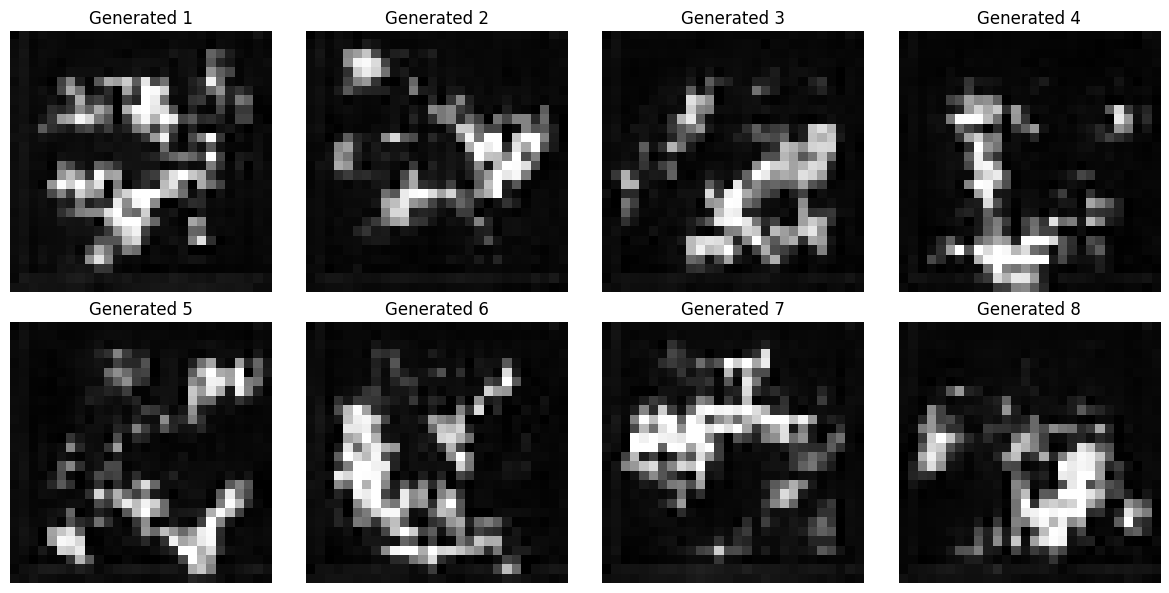


test evaluation results
  L1    : 0.009153
  MSE   : 0.000614
  LPIPS : 0.001230
  PSNR  : 38.3270 dB
  SSIM  : 0.998231
  FID   : 0.5476
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-05/eval_test_dq_1e-06_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.06it/s, rec=0.0478, g=0.0000, d=N/A, Dq=412.6030, KLt=759.1673]



Epoch 1/10 [sd]
  Train - Rec: 0.0912, Reg(sd): 0.0079, Disc: 0.0000
  Val   - Rec Loss: 0.0479
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0479)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:30<00:00,  5.61it/s, rec=0.0396, g=0.0000, d=N/A, Dq=-157.1993, KLt=159.8249]



Epoch 2/10 [sd]
  Train - Rec: 0.0395, Reg(sd): 0.0012, Disc: 0.0000
  Val   - Rec Loss: 0.0355
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0355)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0137, Reg(sd): -0.0001, Disc: 1.0015
  Val   - Rec Loss: 0.0136
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0136)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.37it/s, rec=0.0127, g=-0.0824, d=0.9892, Dq=-328.3099, KLt=18.9574]



Epoch 9/10 [sd]
  Train - Rec: 0.0121, Reg(sd): -0.0002, Disc: 0.9901
  Val   - Rec Loss: 0.0117
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0117)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:13<00:00,  4.36it/s, rec=0.0107, g=0.1316, d=0.9843, Dq=-332.8540, KLt=15.0961] 



Epoch 10/10 [sd]
  Train - Rec: 0.0110, Reg(sd): -0.0002, Disc: 0.9775
  Val   - Rec Loss: 0.0111
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0111)

[sd] 训练完成! 最佳验证损失: 0.0111


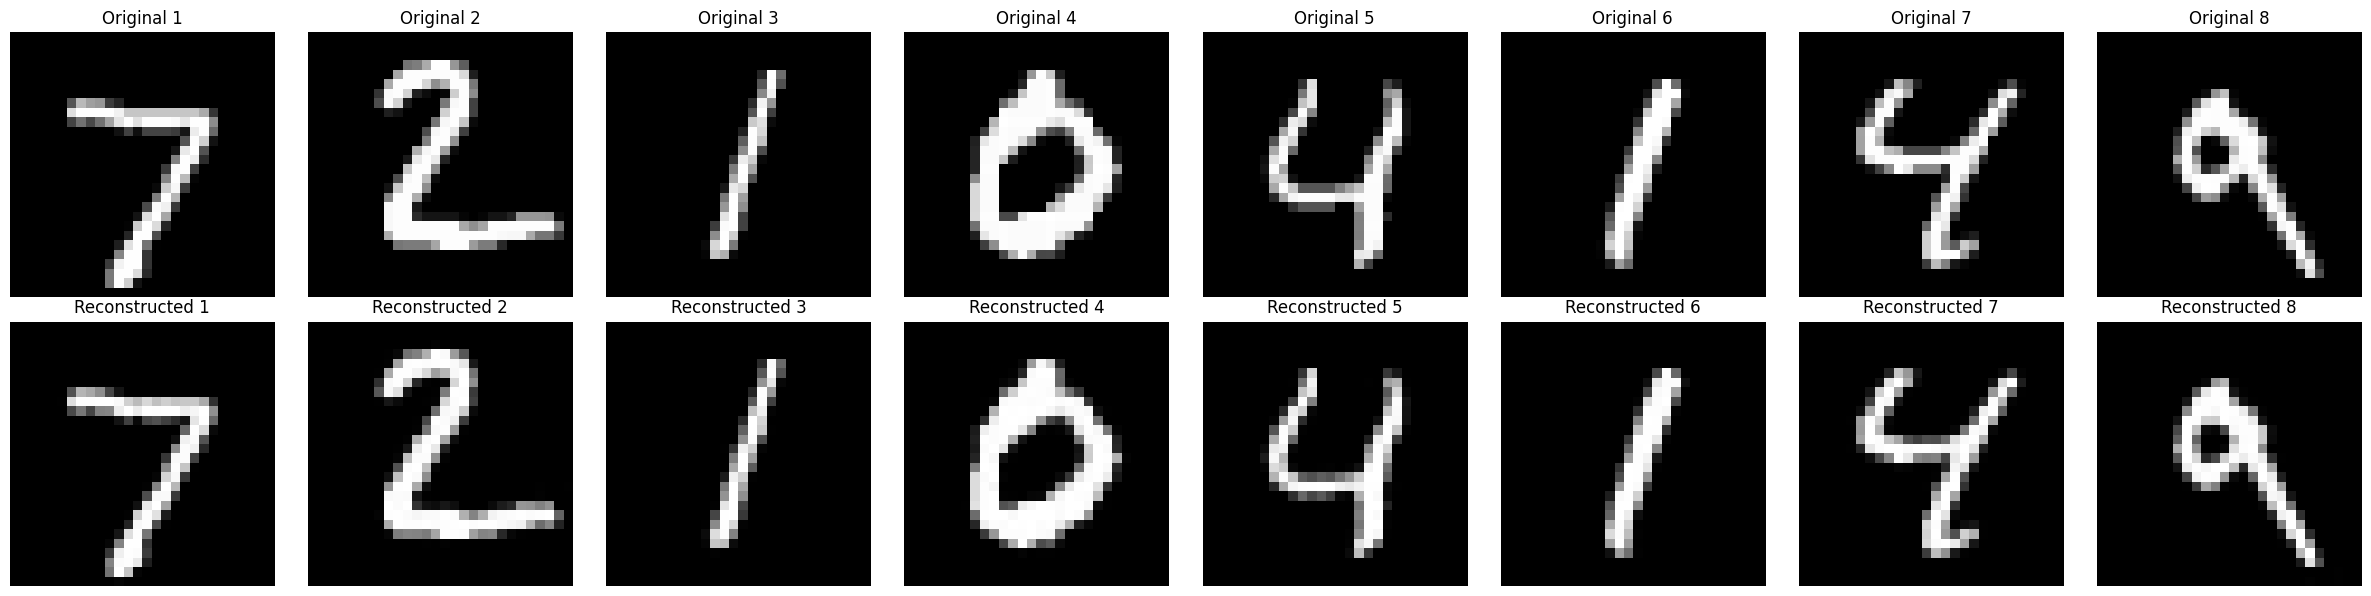

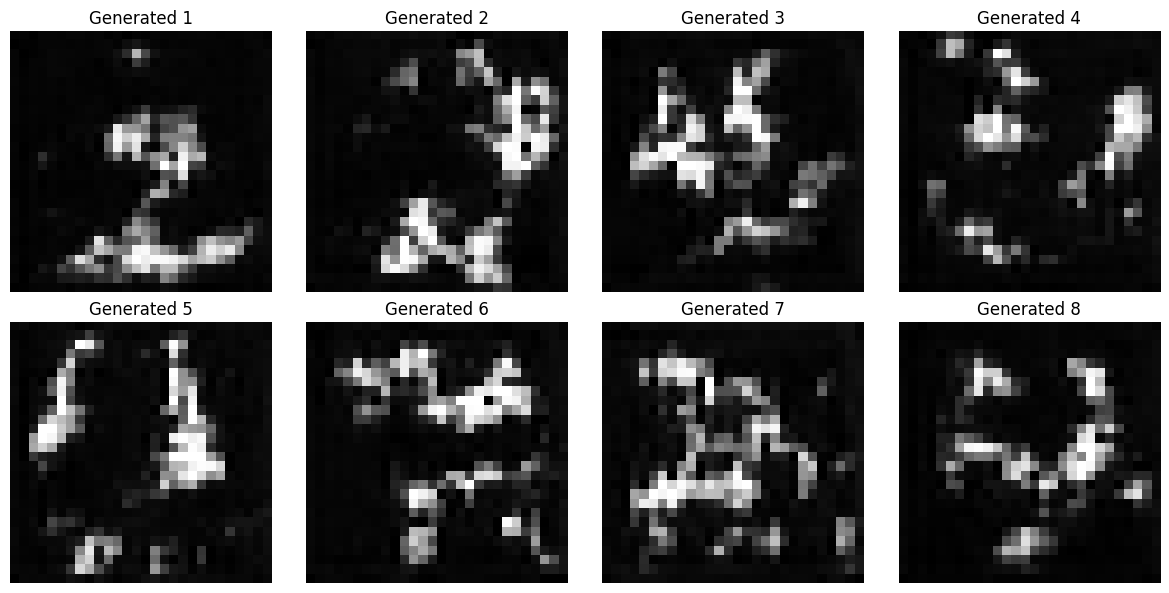


test evaluation results
  L1    : 0.010597
  MSE   : 0.000790
  LPIPS : 0.001637
  PSNR  : 37.2459 dB
  SSIM  : 0.997932
  FID   : 0.6207
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-05/eval_test_dq_1e-06_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:54<00:00,  4.83it/s, rec=0.0473, g=0.0000, d=N/A, Dq=420.2807, KLt=708.5492]



Epoch 1/10 [sd]
  Train - Rec: 0.0927, Reg(sd): 0.0080, Disc: 0.0000
  Val   - Rec Loss: 0.0493
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0493)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:56<00:00,  4.77it/s, rec=0.0309, g=0.0000, d=N/A, Dq=-53.8915, KLt=192.7610] 



Epoch 2/10 [sd]
  Train - Rec: 0.0371, Reg(sd): 0.0016, Disc: 0.0000
  Val   - Rec Loss: 0.0314
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0314)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0118, Reg(sd): -0.0001, Disc: 0.9848
  Val   - Rec Loss: 0.0119
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0119)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:13<00:00,  4.35it/s, rec=0.0115, g=0.2092, d=0.9784, Dq=-269.1250, KLt=12.4808] 



Epoch 9/10 [sd]
  Train - Rec: 0.0106, Reg(sd): -0.0001, Disc: 0.9643
  Val   - Rec Loss: 0.0105
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0105)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:28<00:00,  4.04it/s, rec=0.0098, g=-0.1186, d=0.8522, Dq=-276.4370, KLt=10.2151]



Epoch 10/10 [sd]
  Train - Rec: 0.0098, Reg(sd): -0.0002, Disc: 0.9181
  Val   - Rec Loss: 0.0097
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0097)

[sd] 训练完成! 最佳验证损失: 0.0097


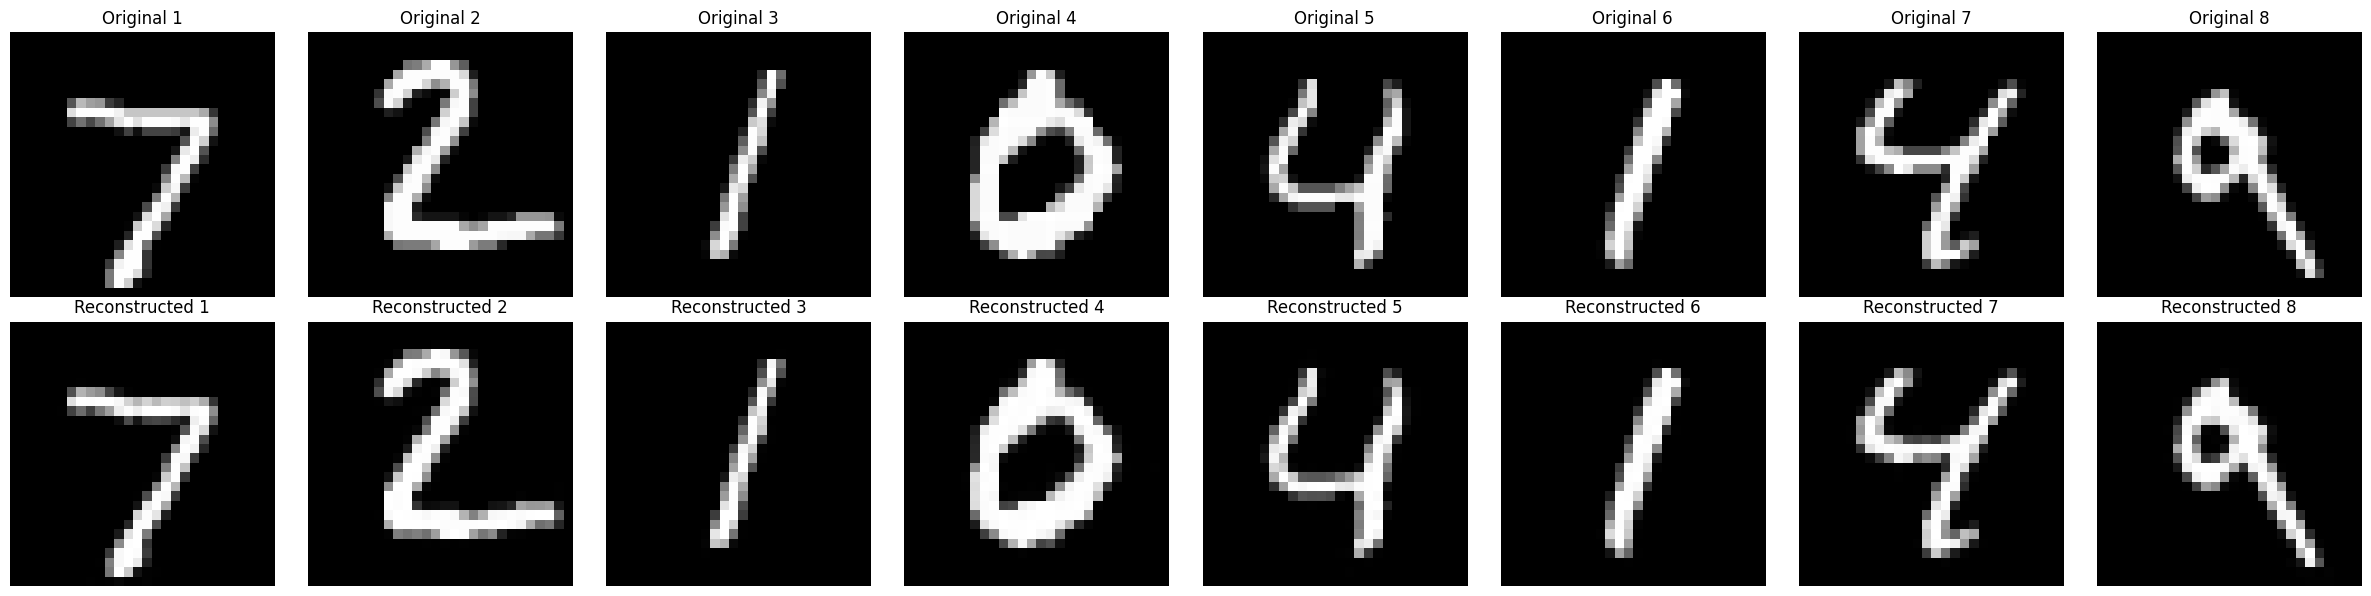

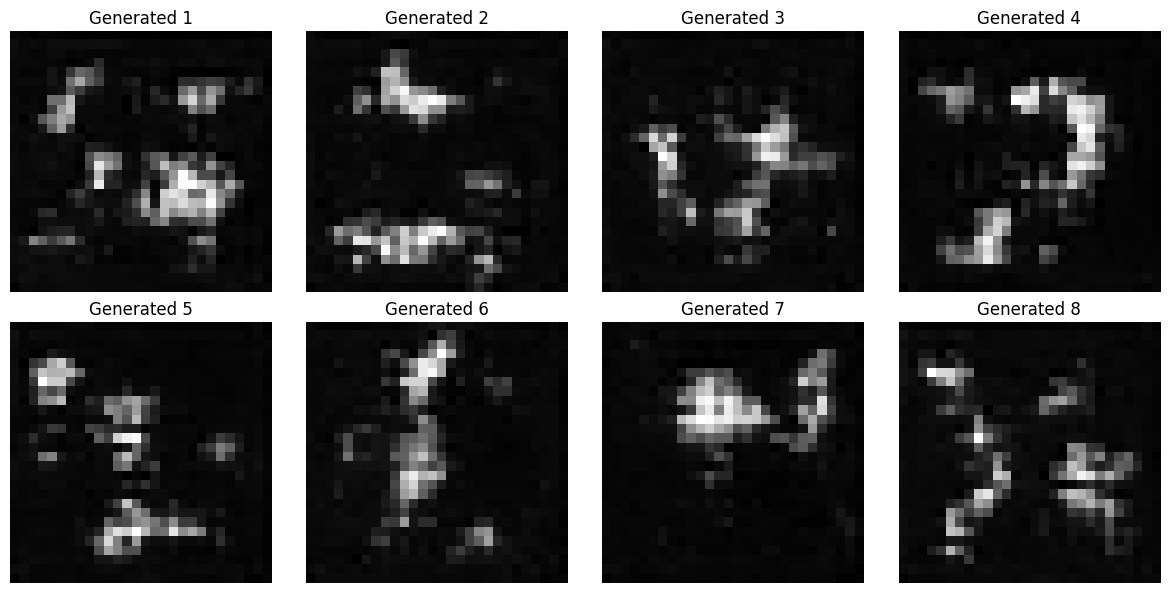


test evaluation results
  L1    : 0.009252
  MSE   : 0.000625
  LPIPS : 0.001257
  PSNR  : 38.2437 dB
  SSIM  : 0.997799
  FID   : 0.5019
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-05/eval_test_dq_1e-06_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。


In [18]:
for klt_w in [1e-8, 4e-8, 1e-6,1e-5]:
    for dq_w in [1e-5,1e-6]:
        for rep in range(4): 
            _ = run_training("sd", 
                            sd_dq_weight=dq_w, 
                            sd_klt_weight=klt_w,  
                            run_tag=f"dq_{dq_w:.0e}_klt_{klt_w:.0e}")


[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.14it/s, rec=0.0375, g=0.0000, d=N/A, Dq=-447.6678, KLt=55103.8125]



Epoch 1/10 [sd]
  Train - Rec: 0.0819, Reg(sd): -0.0033, Disc: 0.0000
  Val   - Rec Loss: 0.0416
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0416)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.07it/s, rec=0.0317, g=0.0000, d=N/A, Dq=-497.9991, KLt=14158.0527]



Epoch 2/10 [sd]
  Train - Rec: 0.0321, Reg(sd): -0.0048, Disc: 0.0000
  Val   - Rec Loss: 0.0320
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0320)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0111, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0106
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0106)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:31<00:00,  3.98it/s, rec=0.0093, g=-0.0463, d=1.0000, Dq=-521.6381, KLt=1900.9705]



Epoch 9/10 [sd]
  Train - Rec: 0.0099, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0099
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0099)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:32<00:00,  3.97it/s, rec=0.0094, g=-0.0090, d=1.0000, Dq=-515.2888, KLt=1736.4841]



Epoch 10/10 [sd]
  Train - Rec: 0.0091, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0088)

[sd] 训练完成! 最佳验证损失: 0.0088


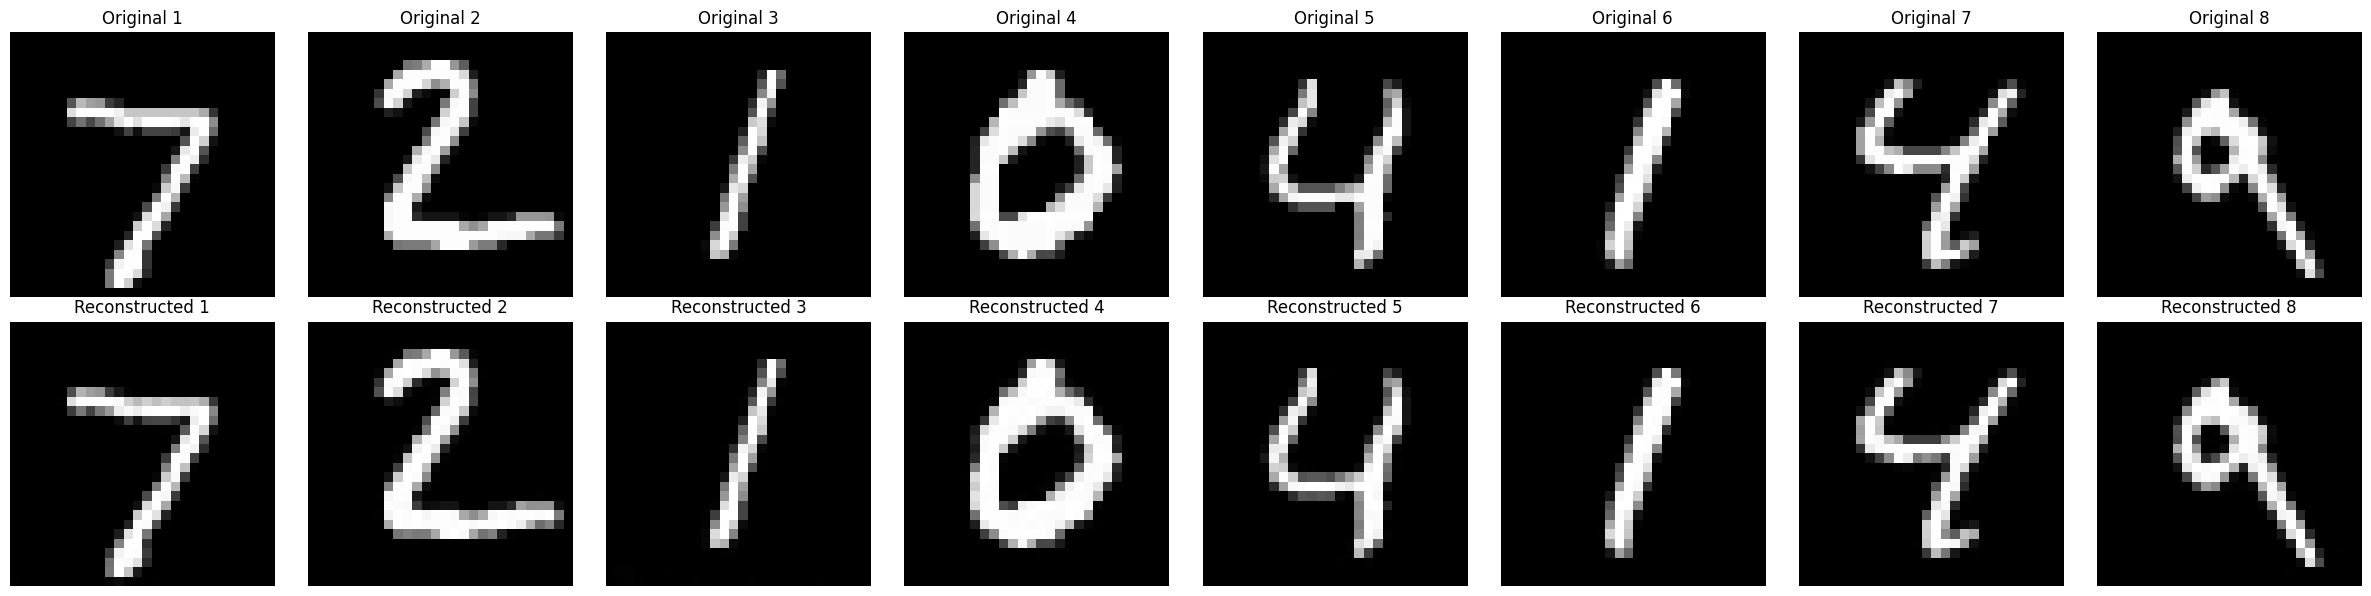

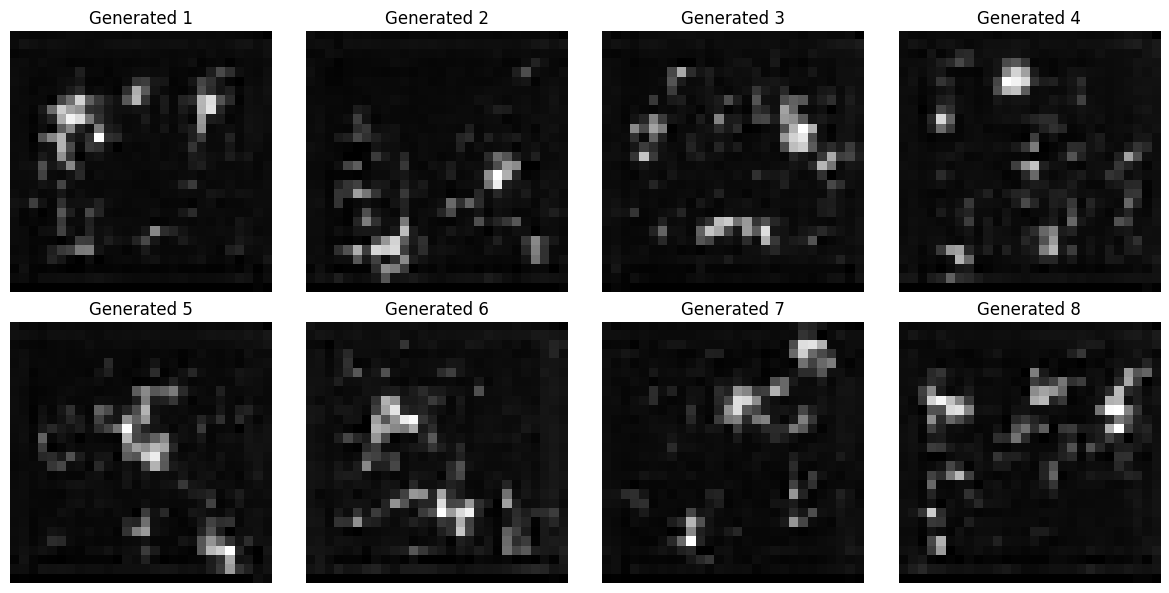


test evaluation results
  L1    : 0.008420
  MSE   : 0.000500
  LPIPS : 0.001058
  PSNR  : 39.2562 dB
  SSIM  : 0.998528
  FID   : 0.5051
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.11it/s, rec=0.0486, g=0.0000, d=N/A, Dq=-4.7611, KLt=54389.0117] 



Epoch 1/10 [sd]
  Train - Rec: 0.0886, Reg(sd): 0.0003, Disc: 0.0000
  Val   - Rec Loss: 0.0513
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0513)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:56<00:00,  4.79it/s, rec=0.0332, g=0.0000, d=N/A, Dq=-3.0877, KLt=9823.8496] 



Epoch 2/10 [sd]
  Train - Rec: 0.0357, Reg(sd): 0.0000, Disc: 0.0000
  Val   - Rec Loss: 0.0321
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0321)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0103, Reg(sd): 0.0000, Disc: 1.0027
  Val   - Rec Loss: 0.0100
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0100)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:13<00:00,  4.36it/s, rec=0.0088, g=0.4475, d=0.9836, Dq=-0.1916, KLt=1338.0845] 



Epoch 9/10 [sd]
  Train - Rec: 0.0091, Reg(sd): 0.0000, Disc: 0.9904
  Val   - Rec Loss: 0.0086
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0086)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:27<00:00,  4.06it/s, rec=0.0076, g=0.7027, d=0.9628, Dq=-0.1920, KLt=1473.4231] 



Epoch 10/10 [sd]
  Train - Rec: 0.0084, Reg(sd): 0.0000, Disc: 0.9773
  Val   - Rec Loss: 0.0081
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0081)

[sd] 训练完成! 最佳验证损失: 0.0081


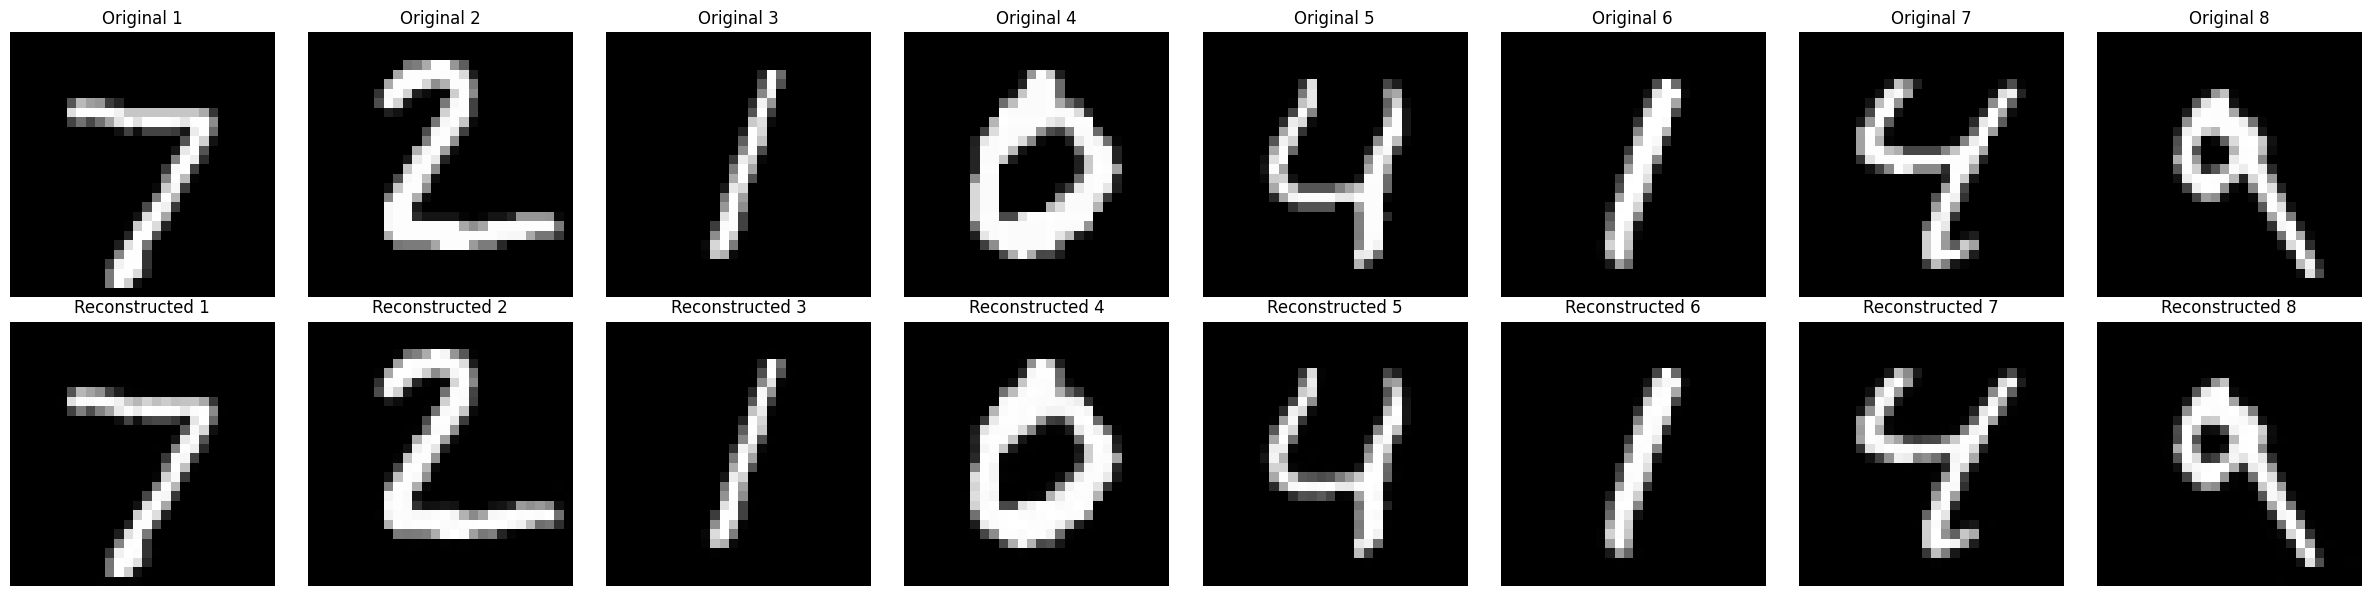

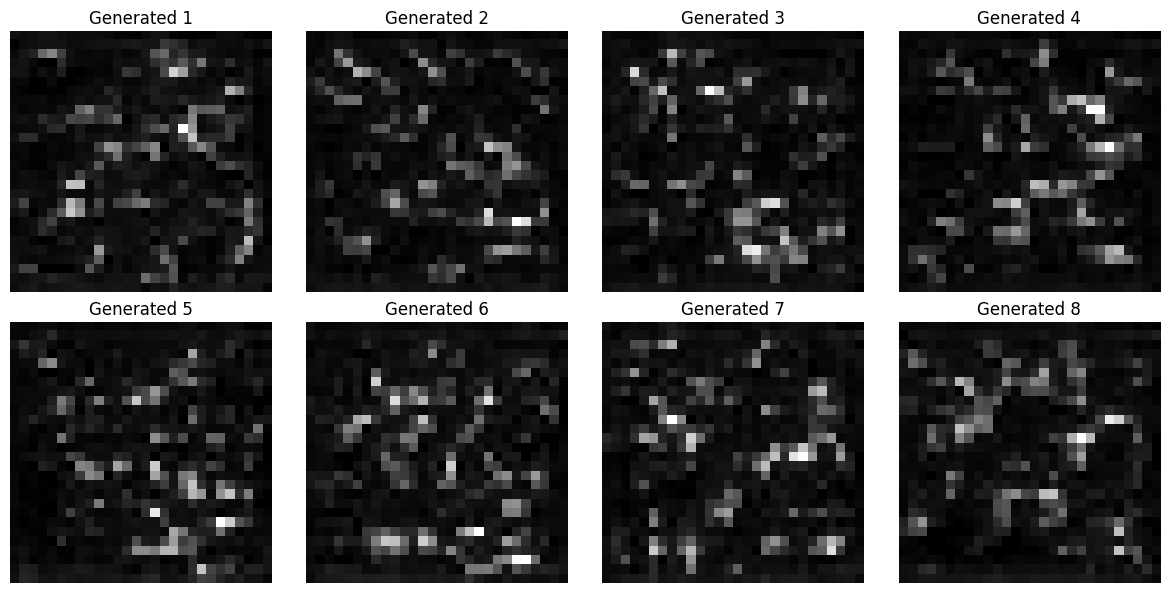


test evaluation results
  L1    : 0.007814
  MSE   : 0.000439
  LPIPS : 0.000964
  PSNR  : 39.7947 dB
  SSIM  : 0.998408
  FID   : 0.4754
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-08/eval_test_dq_1e-06_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_5e-05_klt_1e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(5.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:47<00:00,  5.04it/s, rec=0.0381, g=0.0000, d=N/A, Dq=-602.7841, KLt=67008.3984] 



Epoch 1/10 [sd]
  Train - Rec: 0.0878, Reg(sd): -0.0281, Disc: 0.0000
  Val   - Rec Loss: 0.0414
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0414)


Epoch 2 [sd]: 100%|██████████| 843/843 [03:00<00:00,  4.68it/s, rec=0.0292, g=0.0000, d=N/A, Dq=-645.8454, KLt=10031.1758]



Epoch 2/10 [sd]
  Train - Rec: 0.0379, Reg(sd): -0.0310, Disc: 0.0000
  Val   - Rec Loss: 0.0326
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0326)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0124, Reg(sd): -0.0326, Disc: 0.9739
  Val   - Rec Loss: 0.0134
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0134)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:13<00:00,  4.36it/s, rec=0.0112, g=0.2589, d=0.9745, Dq=-648.7189, KLt=1816.3374] 



Epoch 9/10 [sd]
  Train - Rec: 0.0111, Reg(sd): -0.0326, Disc: 0.9446
  Val   - Rec Loss: 0.0109
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0109)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:40<00:00,  3.82it/s, rec=0.0096, g=-0.4323, d=0.9127, Dq=-651.5388, KLt=1362.4316]



Epoch 10/10 [sd]
  Train - Rec: 0.0103, Reg(sd): -0.0325, Disc: 0.9083
  Val   - Rec Loss: 0.0103
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0103)

[sd] 训练完成! 最佳验证损失: 0.0103


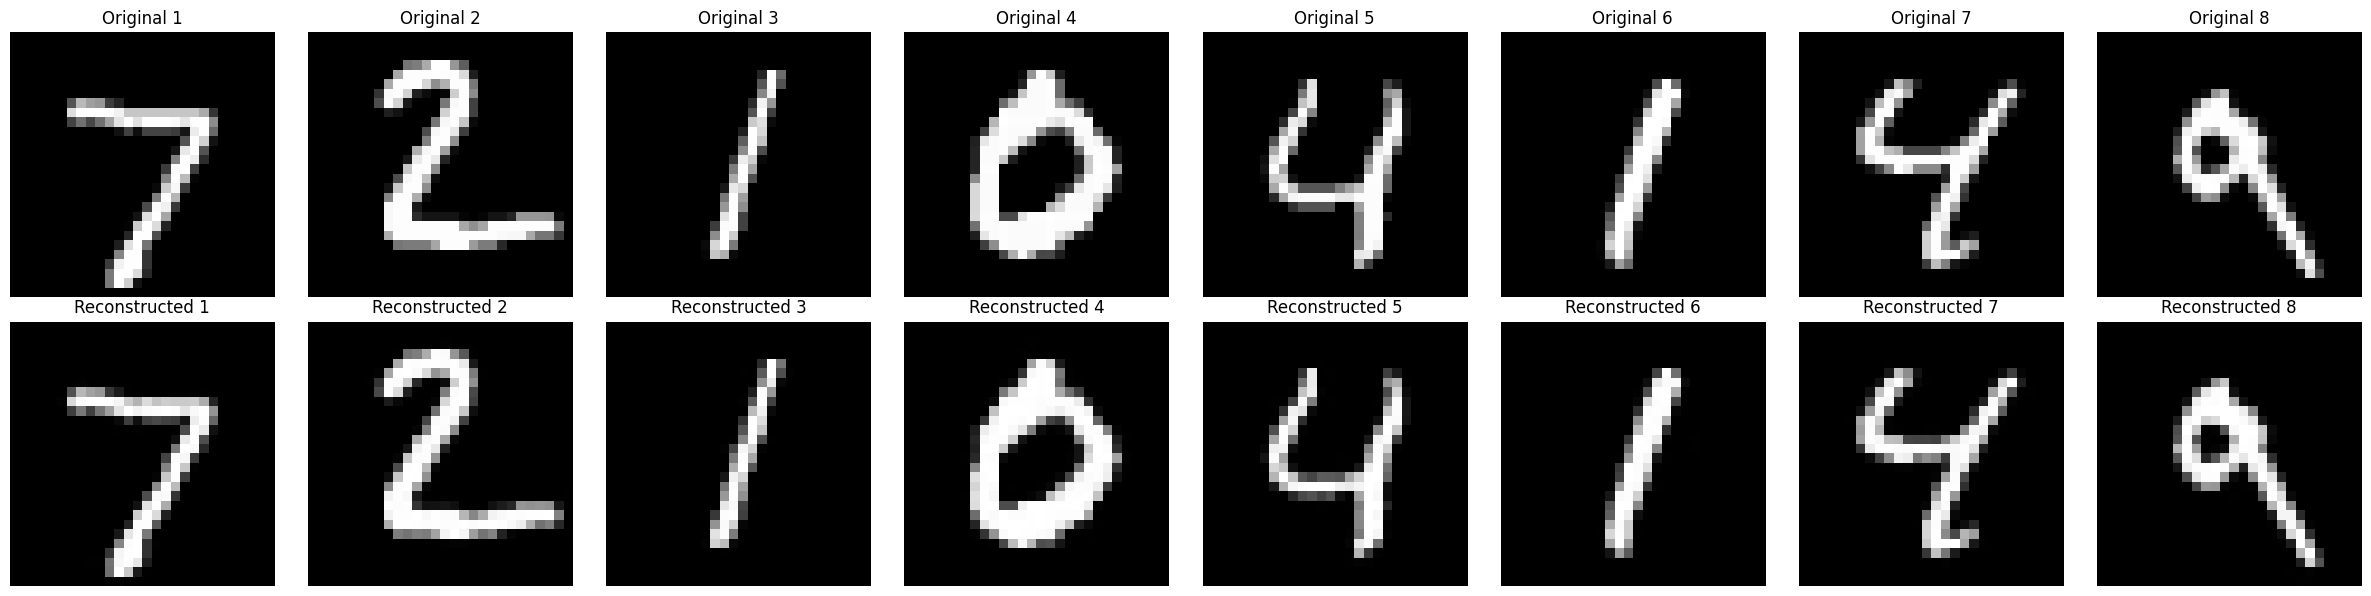

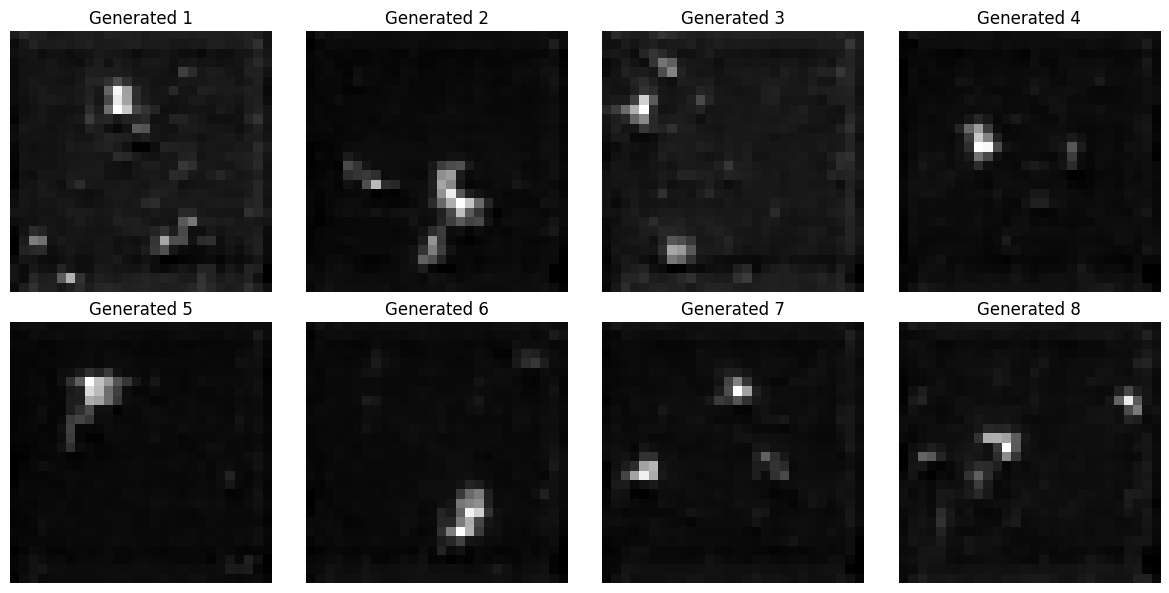


test evaluation results
  L1    : 0.009836
  MSE   : 0.000698
  LPIPS : 0.001464
  PSNR  : 37.7601 dB
  SSIM  : 0.997219
  FID   : 0.6237
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_5e-05_klt_1e-08/eval_test_dq_5e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [03:03<00:00,  4.60it/s, rec=0.0434, g=0.0000, d=N/A, Dq=-427.6133, KLt=24890.8984]



Epoch 1/10 [sd]
  Train - Rec: 0.0861, Reg(sd): -0.0027, Disc: 0.0000
  Val   - Rec Loss: 0.0402
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0402)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.07it/s, rec=0.0305, g=0.0000, d=N/A, Dq=-487.1429, KLt=3748.8679]



Epoch 2/10 [sd]
  Train - Rec: 0.0370, Reg(sd): -0.0046, Disc: 0.0000
  Val   - Rec Loss: 0.0318
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0318)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0110, Reg(sd): -0.0051, Disc: 0.9984
  Val   - Rec Loss: 0.0110
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0110)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:12<00:00,  4.37it/s, rec=0.0099, g=-0.1316, d=0.9745, Dq=-497.6668, KLt=681.6595] 



Epoch 9/10 [sd]
  Train - Rec: 0.0097, Reg(sd): -0.0051, Disc: 0.9813
  Val   - Rec Loss: 0.0094
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0094)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:29<00:00,  4.02it/s, rec=0.0088, g=0.2840, d=0.9810, Dq=-507.9782, KLt=409.9987] 



Epoch 10/10 [sd]
  Train - Rec: 0.0090, Reg(sd): -0.0051, Disc: 0.9688
  Val   - Rec Loss: 0.0090
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0090)

[sd] 训练完成! 最佳验证损失: 0.0090


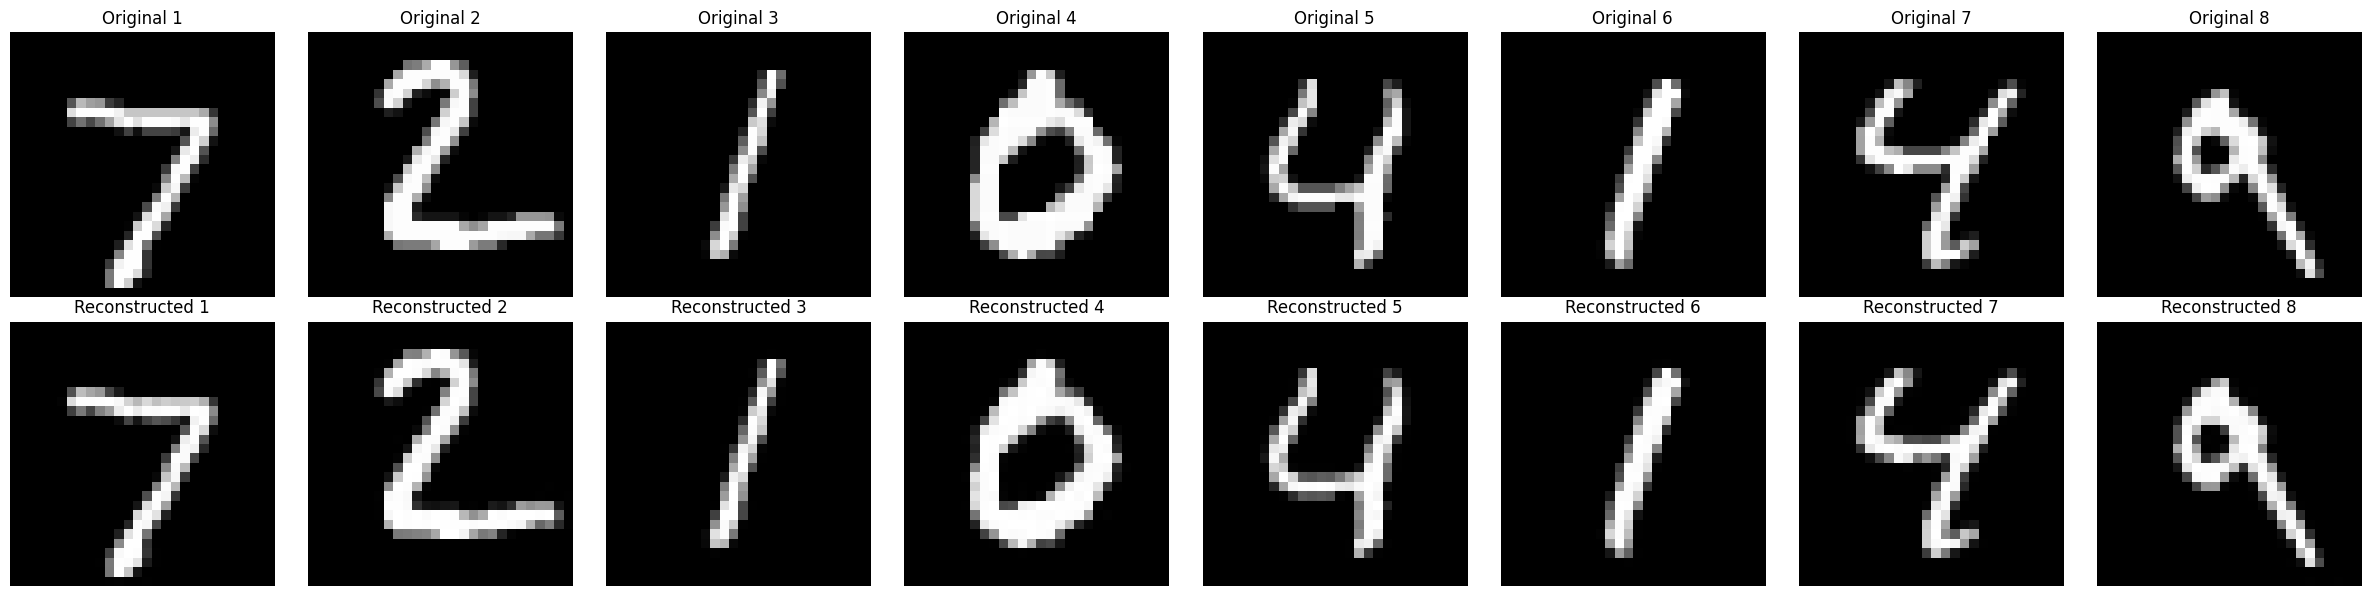

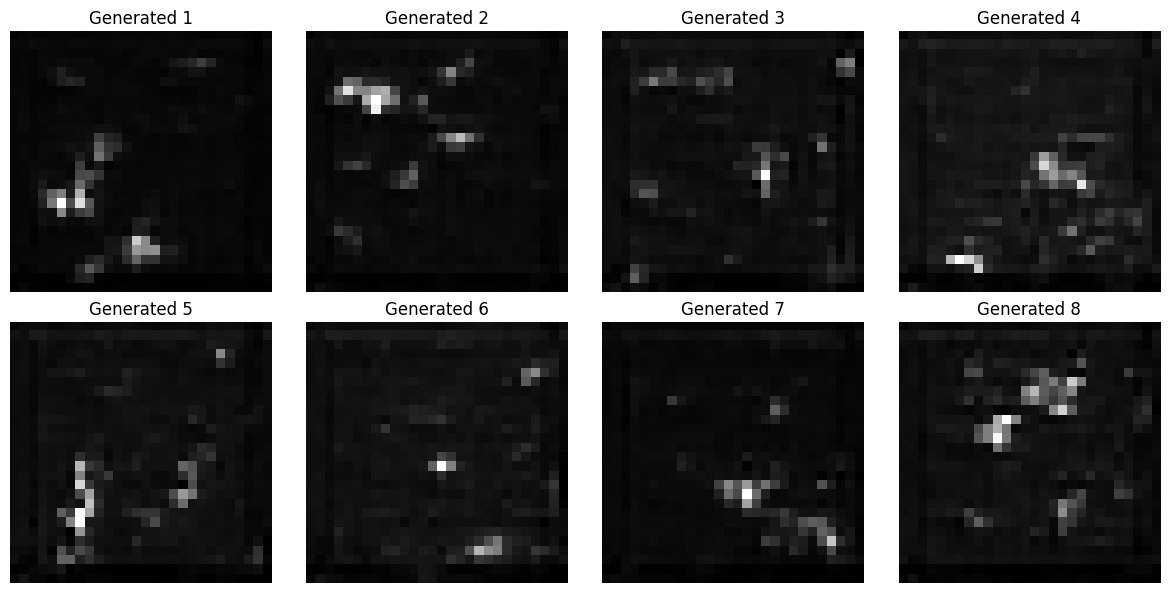


test evaluation results
  L1    : 0.008577
  MSE   : 0.000520
  LPIPS : 0.001079
  PSNR  : 39.0757 dB
  SSIM  : 0.998540
  FID   : 0.4763
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_4e-08/eval_test_dq_1e-05_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.11it/s, rec=0.0472, g=0.0000, d=N/A, Dq=-46.0232, KLt=25783.8477] 



Epoch 1/10 [sd]
  Train - Rec: 0.0819, Reg(sd): 0.0007, Disc: 0.0000
  Val   - Rec Loss: 0.0389
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0389)


Epoch 2 [sd]: 100%|██████████| 843/843 [03:04<00:00,  4.57it/s, rec=0.0261, g=0.0000, d=N/A, Dq=-19.8892, KLt=4577.7422]



Epoch 2/10 [sd]
  Train - Rec: 0.0331, Reg(sd): 0.0001, Disc: 0.0000
  Val   - Rec Loss: 0.0316
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0316)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0090, Reg(sd): 0.0000, Disc: 0.9770
  Val   - Rec Loss: 0.0083
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0083)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:29<00:00,  4.02it/s, rec=0.0073, g=-0.4682, d=0.9588, Dq=-1.1751, KLt=749.3392] 



Epoch 9/10 [sd]
  Train - Rec: 0.0078, Reg(sd): 0.0000, Disc: 0.9741
  Val   - Rec Loss: 0.0075
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0075)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:28<00:00,  4.05it/s, rec=0.0069, g=0.0488, d=0.9442, Dq=-1.0182, KLt=679.4279]  



Epoch 10/10 [sd]
  Train - Rec: 0.0070, Reg(sd): 0.0000, Disc: 0.9600
  Val   - Rec Loss: 0.0068
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0068)

[sd] 训练完成! 最佳验证损失: 0.0068


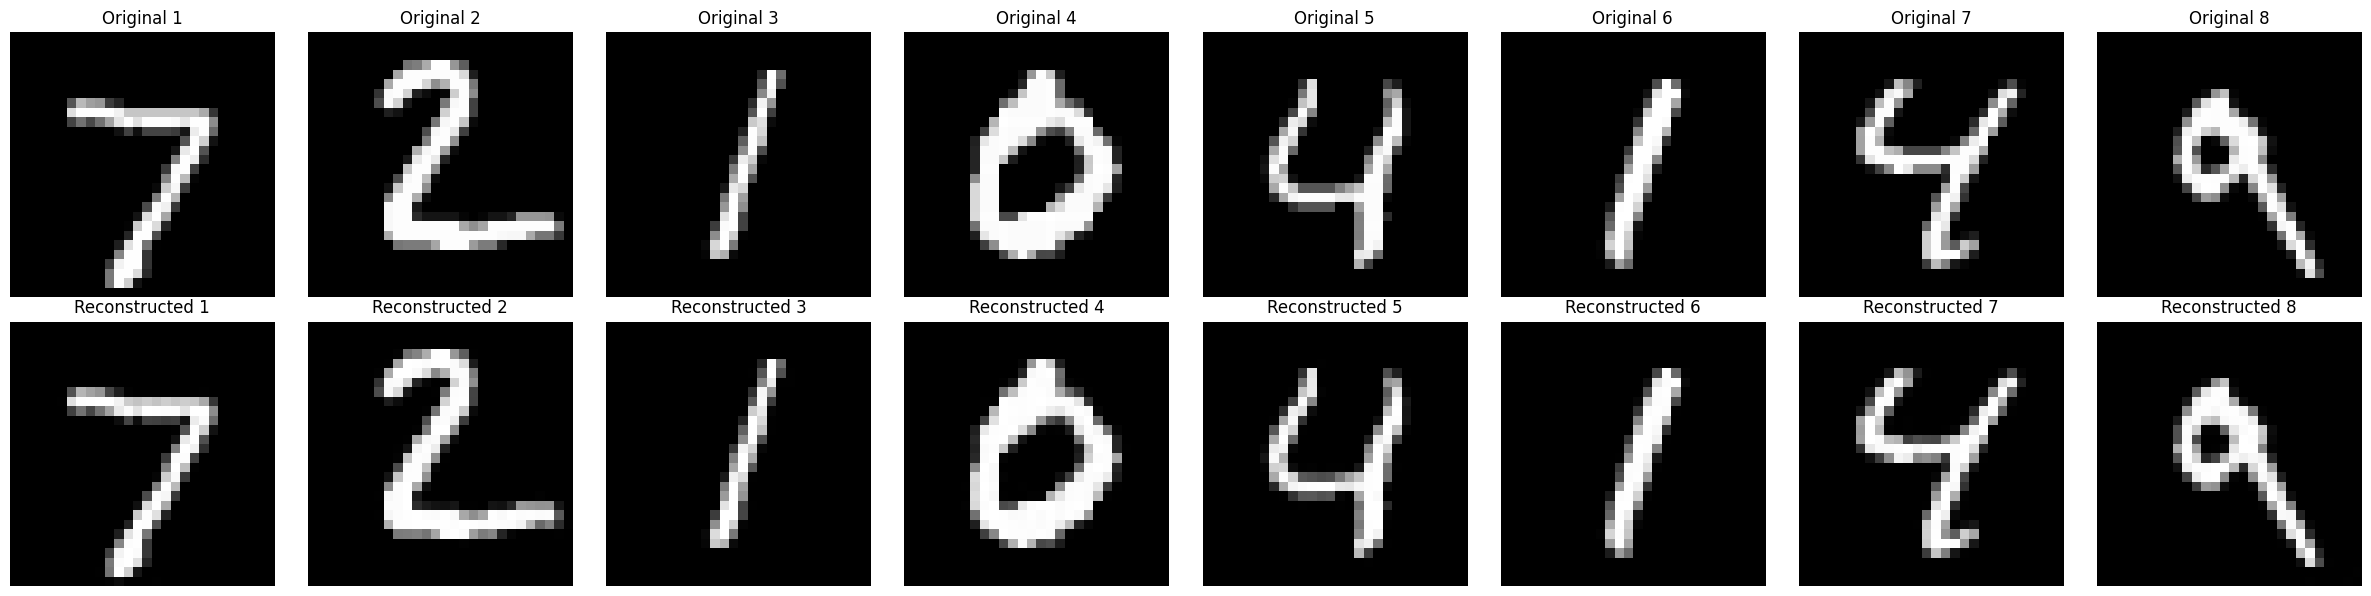

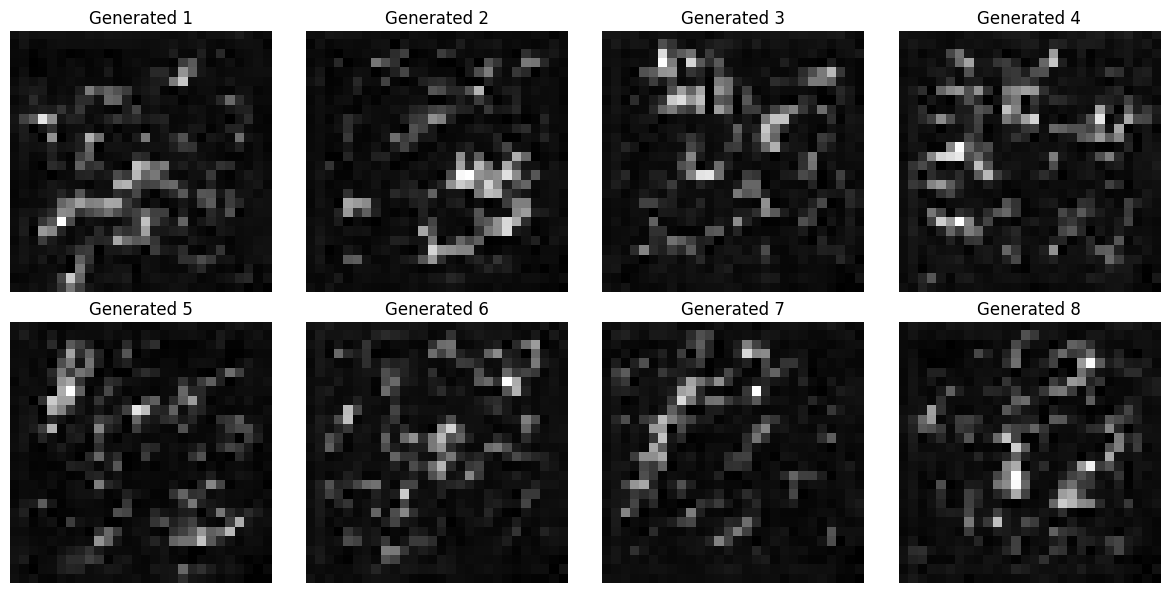


test evaluation results
  L1    : 0.006592
  MSE   : 0.000257
  LPIPS : 0.000556
  PSNR  : 42.2625 dB
  SSIM  : 0.999277
  FID   : 0.3207
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_4e-08/eval_test_dq_1e-06_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_5e-05_klt_4e-08) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(5.000e-05)*Dq + eff_klt(4.000e-08)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [03:02<00:00,  4.61it/s, rec=0.0482, g=0.0000, d=N/A, Dq=-671.6569, KLt=26954.8125]



Epoch 1/10 [sd]
  Train - Rec: 0.0919, Reg(sd): -0.0304, Disc: 0.0000
  Val   - Rec Loss: 0.0468
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0468)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.07it/s, rec=0.0340, g=0.0000, d=N/A, Dq=-692.4213, KLt=4465.6104]



Epoch 2/10 [sd]
  Train - Rec: 0.0380, Reg(sd): -0.0342, Disc: 0.0000
  Val   - Rec Loss: 0.0322
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0322)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0159, Reg(sd): -0.0344, Disc: 0.9366
  Val   - Rec Loss: 0.0158
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0158)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:18<00:00,  4.25it/s, rec=0.0147, g=1.3137, d=0.9286, Dq=-690.8436, KLt=585.6908]  



Epoch 9/10 [sd]
  Train - Rec: 0.0146, Reg(sd): -0.0344, Disc: 0.8533
  Val   - Rec Loss: 0.0144
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0144)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:24<00:00,  4.12it/s, rec=0.0133, g=-0.1340, d=0.8434, Dq=-695.0182, KLt=354.9492] 



Epoch 10/10 [sd]
  Train - Rec: 0.0138, Reg(sd): -0.0344, Disc: 0.7526
  Val   - Rec Loss: 0.0140
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0140)

[sd] 训练完成! 最佳验证损失: 0.0140


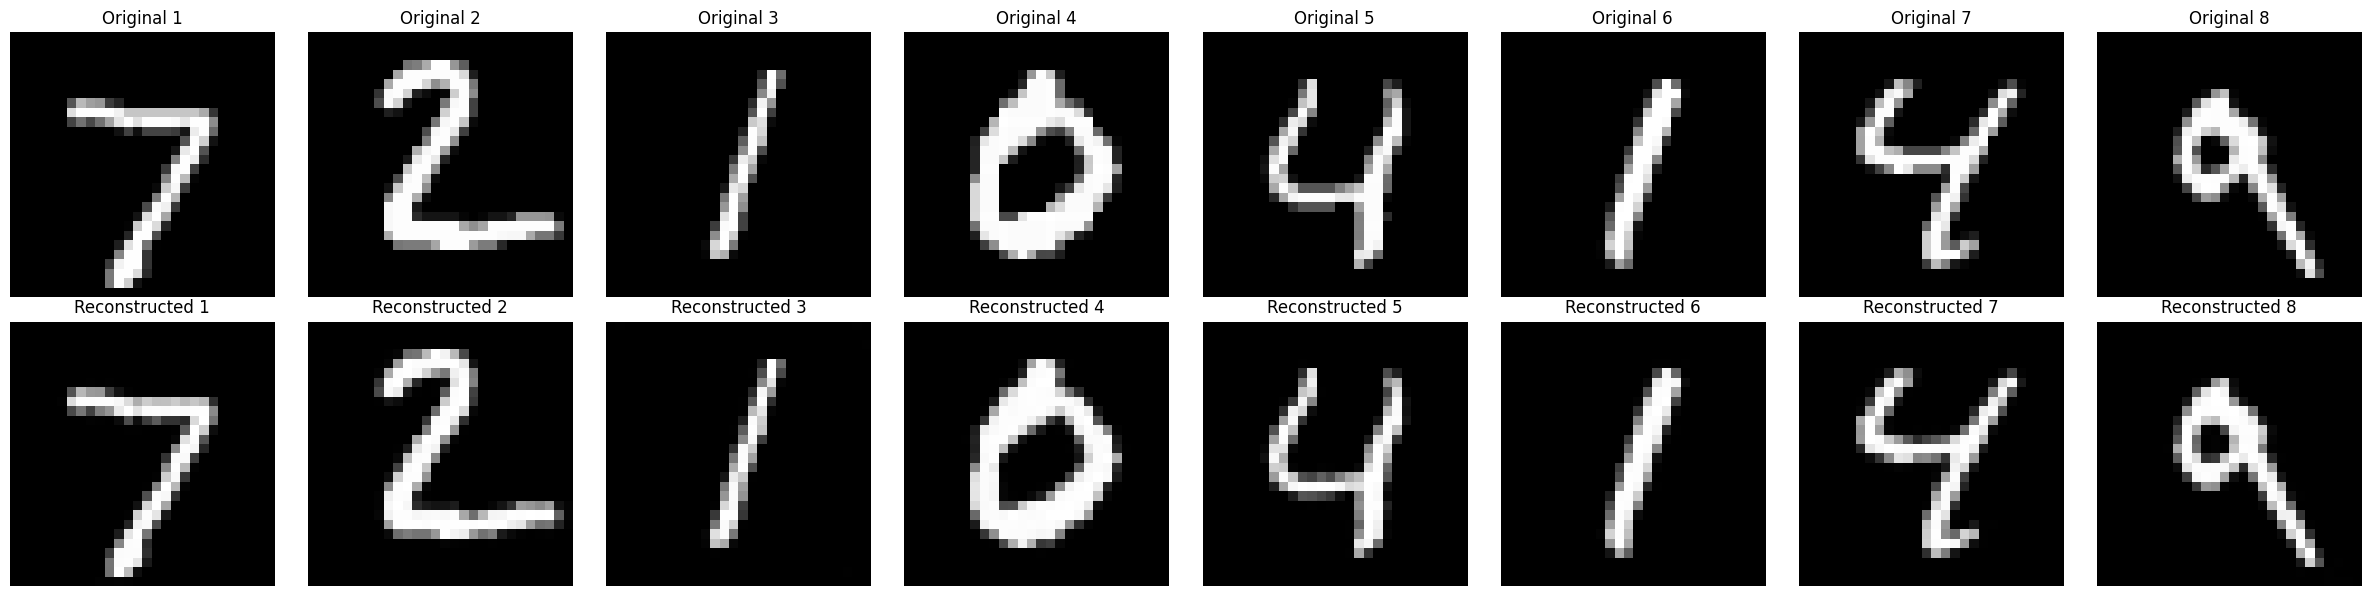

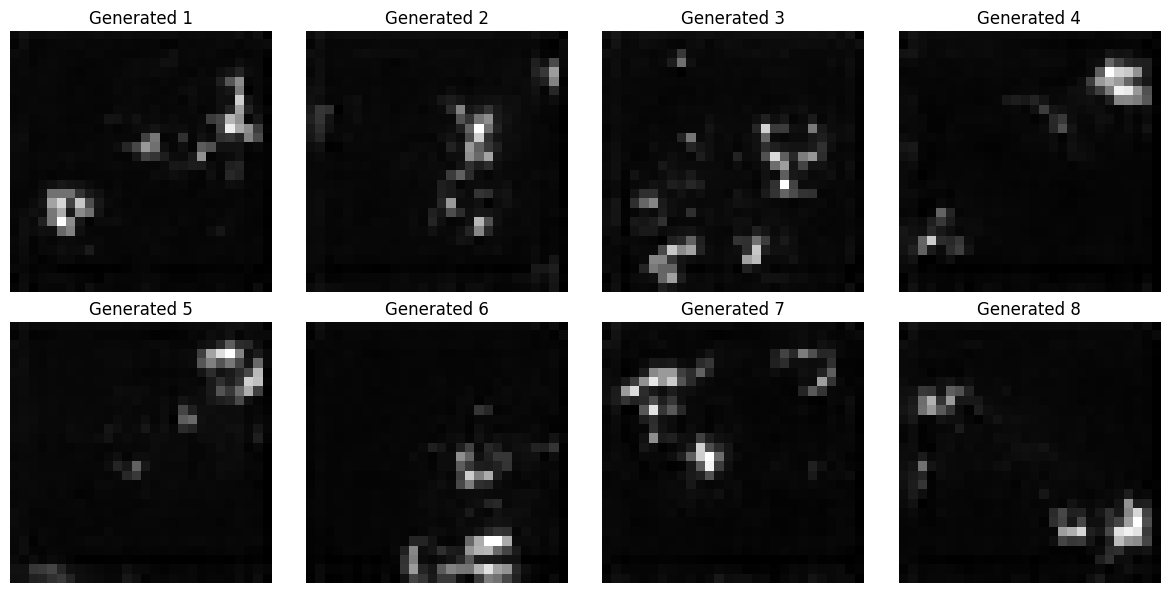


test evaluation results
  L1    : 0.013086
  MSE   : 0.001589
  LPIPS : 0.003043
  PSNR  : 34.1729 dB
  SSIM  : 0.996030
  FID   : 0.8795
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_5e-05_klt_4e-08/eval_test_dq_5e-05_klt_4e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:41<00:00,  5.22it/s, rec=0.0485, g=0.0000, d=N/A, Dq=-462.9384, KLt=3034.4282]



Epoch 1/10 [sd]
  Train - Rec: 0.0894, Reg(sd): -0.0008, Disc: 0.0000
  Val   - Rec Loss: 0.0477
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0477)


Epoch 2 [sd]: 100%|██████████| 843/843 [03:01<00:00,  4.65it/s, rec=0.0320, g=0.0000, d=N/A, Dq=-529.1771, KLt=543.8051]



Epoch 2/10 [sd]
  Train - Rec: 0.0374, Reg(sd): -0.0047, Disc: 0.0000
  Val   - Rec Loss: 0.0314
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0314)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0118, Reg(sd): -0.0057, Disc: 0.9877
  Val   - Rec Loss: 0.0115
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0115)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:26<00:00,  4.09it/s, rec=0.0105, g=0.2632, d=0.9486, Dq=-568.9751, KLt=53.6357]  



Epoch 9/10 [sd]
  Train - Rec: 0.0104, Reg(sd): -0.0057, Disc: 0.9667
  Val   - Rec Loss: 0.0102
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0102)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:15<00:00,  4.32it/s, rec=0.0094, g=0.3759, d=0.9745, Dq=-586.1804, KLt=68.0238]  



Epoch 10/10 [sd]
  Train - Rec: 0.0096, Reg(sd): -0.0057, Disc: 0.9435
  Val   - Rec Loss: 0.0095
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0095)

[sd] 训练完成! 最佳验证损失: 0.0095


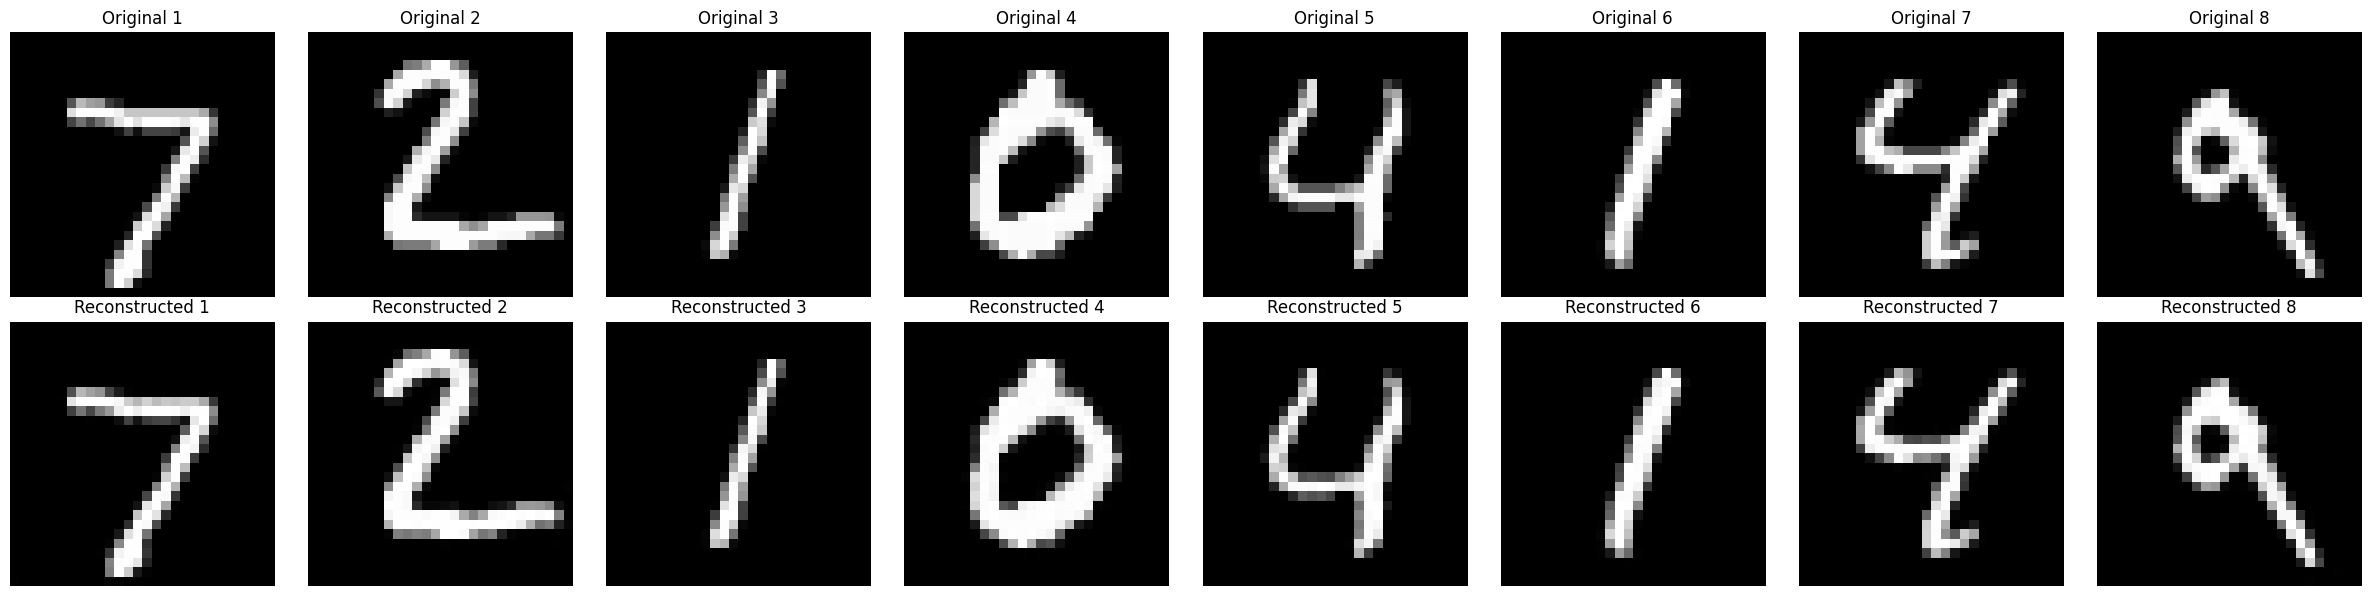

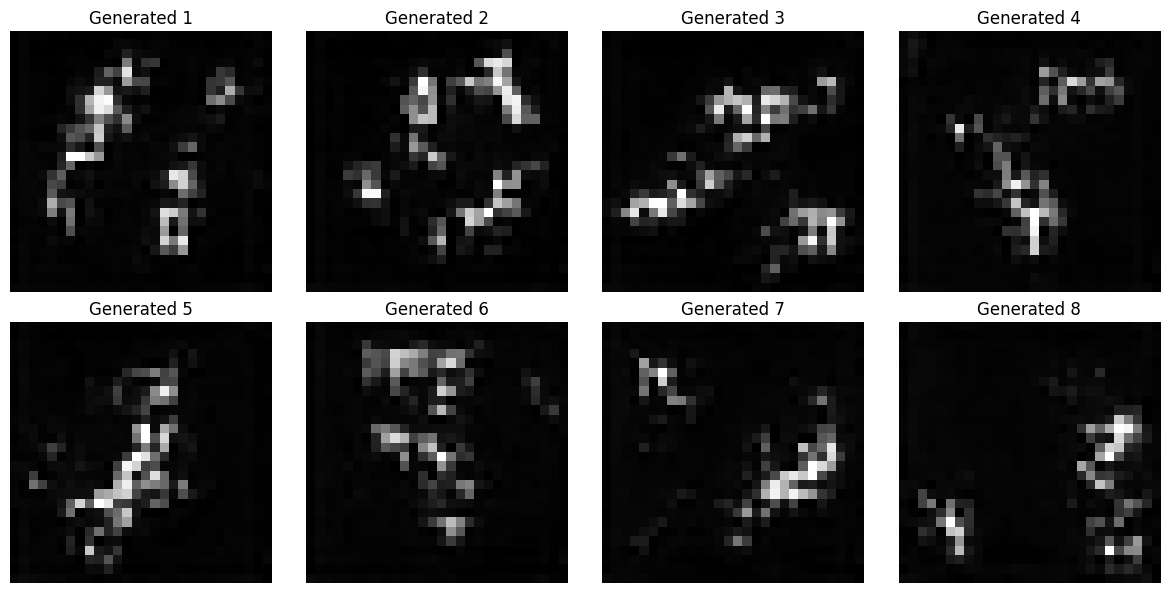


test evaluation results
  L1    : 0.009121
  MSE   : 0.000603
  LPIPS : 0.001256
  PSNR  : 38.4289 dB
  SSIM  : 0.998415
  FID   : 0.5137
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-06/eval_test_dq_1e-05_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [03:01<00:00,  4.65it/s, rec=0.0510, g=0.0000, d=N/A, Dq=73.0818, KLt=3445.3606] 



Epoch 1/10 [sd]
  Train - Rec: 0.0916, Reg(sd): 0.0032, Disc: 0.0000
  Val   - Rec Loss: 0.0410
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0410)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:43<00:00,  5.15it/s, rec=0.0294, g=0.0000, d=N/A, Dq=-109.9220, KLt=834.1527]



Epoch 2/10 [sd]
  Train - Rec: 0.0339, Reg(sd): 0.0005, Disc: 0.0000
  Val   - Rec Loss: 0.0323
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0323)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0105, Reg(sd): 0.0000, Disc: 0.9419
  Val   - Rec Loss: 0.0100
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0100)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:28<00:00,  4.04it/s, rec=0.0098, g=-0.1218, d=0.8913, Dq=-69.7561, KLt=84.6758] 



Epoch 9/10 [sd]
  Train - Rec: 0.0094, Reg(sd): -0.0000, Disc: 0.9101
  Val   - Rec Loss: 0.0093
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0093)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:24<00:00,  4.13it/s, rec=0.0087, g=-0.3448, d=0.7656, Dq=-60.8122, KLt=51.8713] 



Epoch 10/10 [sd]
  Train - Rec: 0.0087, Reg(sd): -0.0000, Disc: 0.8638
  Val   - Rec Loss: 0.0089
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0089)

[sd] 训练完成! 最佳验证损失: 0.0089


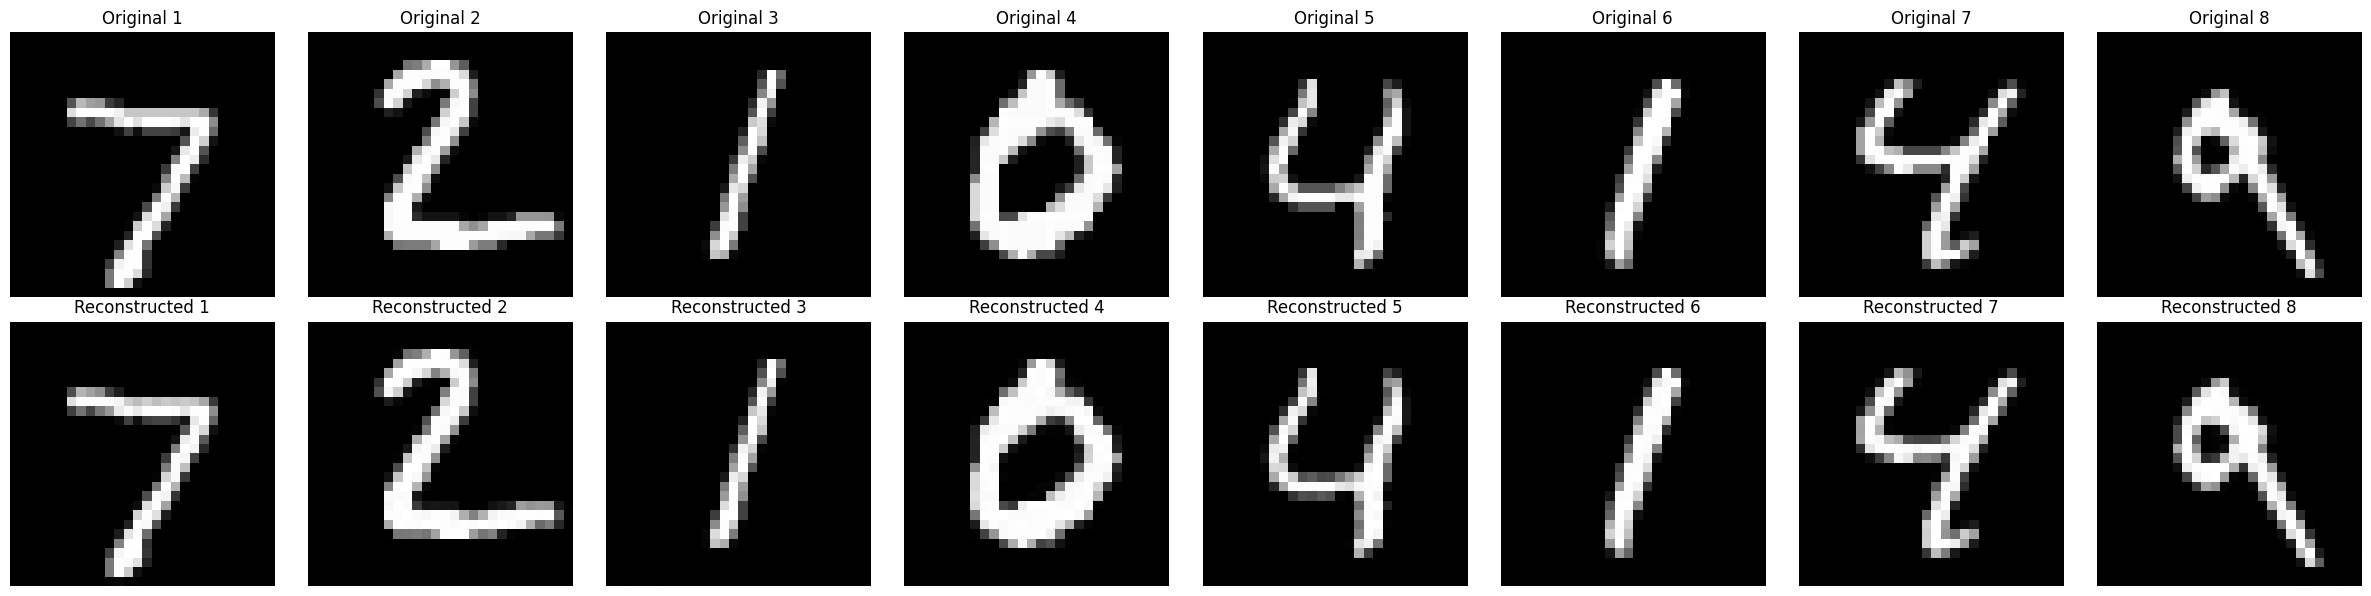

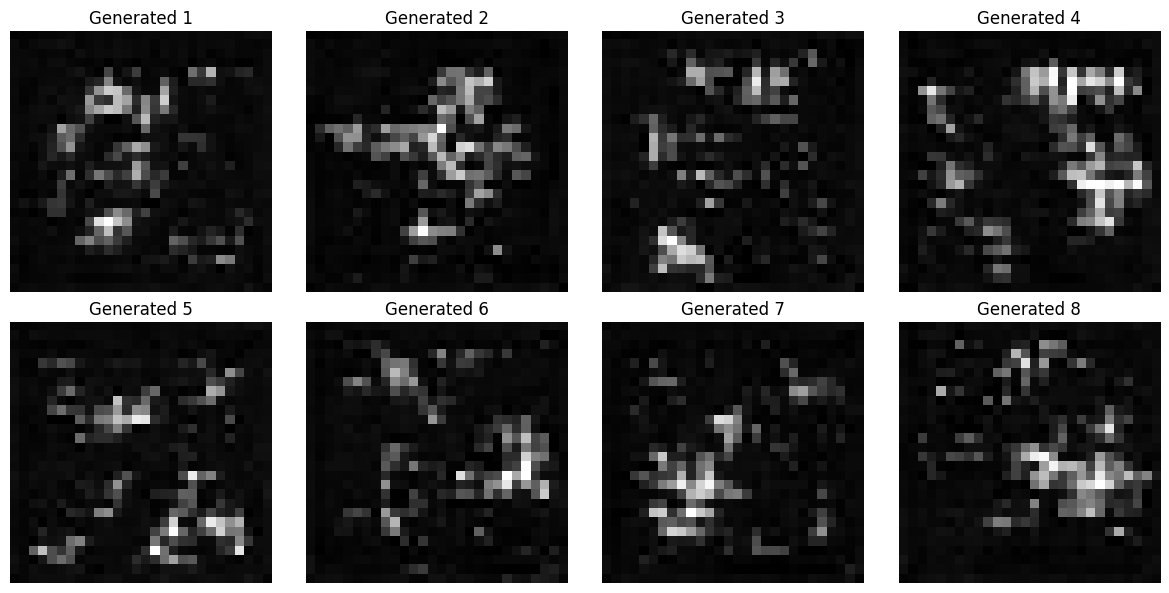


test evaluation results
  L1    : 0.008542
  MSE   : 0.000491
  LPIPS : 0.000987
  PSNR  : 39.3311 dB
  SSIM  : 0.997621
  FID   : 0.4873
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-06/eval_test_dq_1e-06_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_5e-05_klt_1e-06) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(5.000e-05)*Dq + eff_klt(1.000e-06)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:57<00:00,  4.76it/s, rec=0.0460, g=0.0000, d=N/A, Dq=-658.9648, KLt=3174.4307]



Epoch 1/10 [sd]
  Train - Rec: 0.0923, Reg(sd): -0.0262, Disc: 0.0000
  Val   - Rec Loss: 0.0478
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0478)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.12it/s, rec=0.0335, g=0.0000, d=N/A, Dq=-681.4028, KLt=360.9223]



Epoch 2/10 [sd]
  Train - Rec: 0.0388, Reg(sd): -0.0334, Disc: 0.0000
  Val   - Rec Loss: 0.0321
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0321)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0163, Reg(sd): -0.0341, Disc: 0.9242
  Val   - Rec Loss: 0.0159
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0159)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:17<00:00,  4.26it/s, rec=0.0160, g=0.7107, d=0.8241, Dq=-680.5125, KLt=107.6185] 



Epoch 9/10 [sd]
  Train - Rec: 0.0149, Reg(sd): -0.0341, Disc: 0.8677
  Val   - Rec Loss: 0.0150
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0150)


Epoch 10 [sd]: 100%|██████████| 843/843 [03:31<00:00,  3.99it/s, rec=0.0131, g=0.7490, d=0.6484, Dq=-690.8439, KLt=43.0308] 



Epoch 10/10 [sd]
  Train - Rec: 0.0140, Reg(sd): -0.0341, Disc: 0.7907
  Val   - Rec Loss: 0.0141
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0141)

[sd] 训练完成! 最佳验证损失: 0.0141


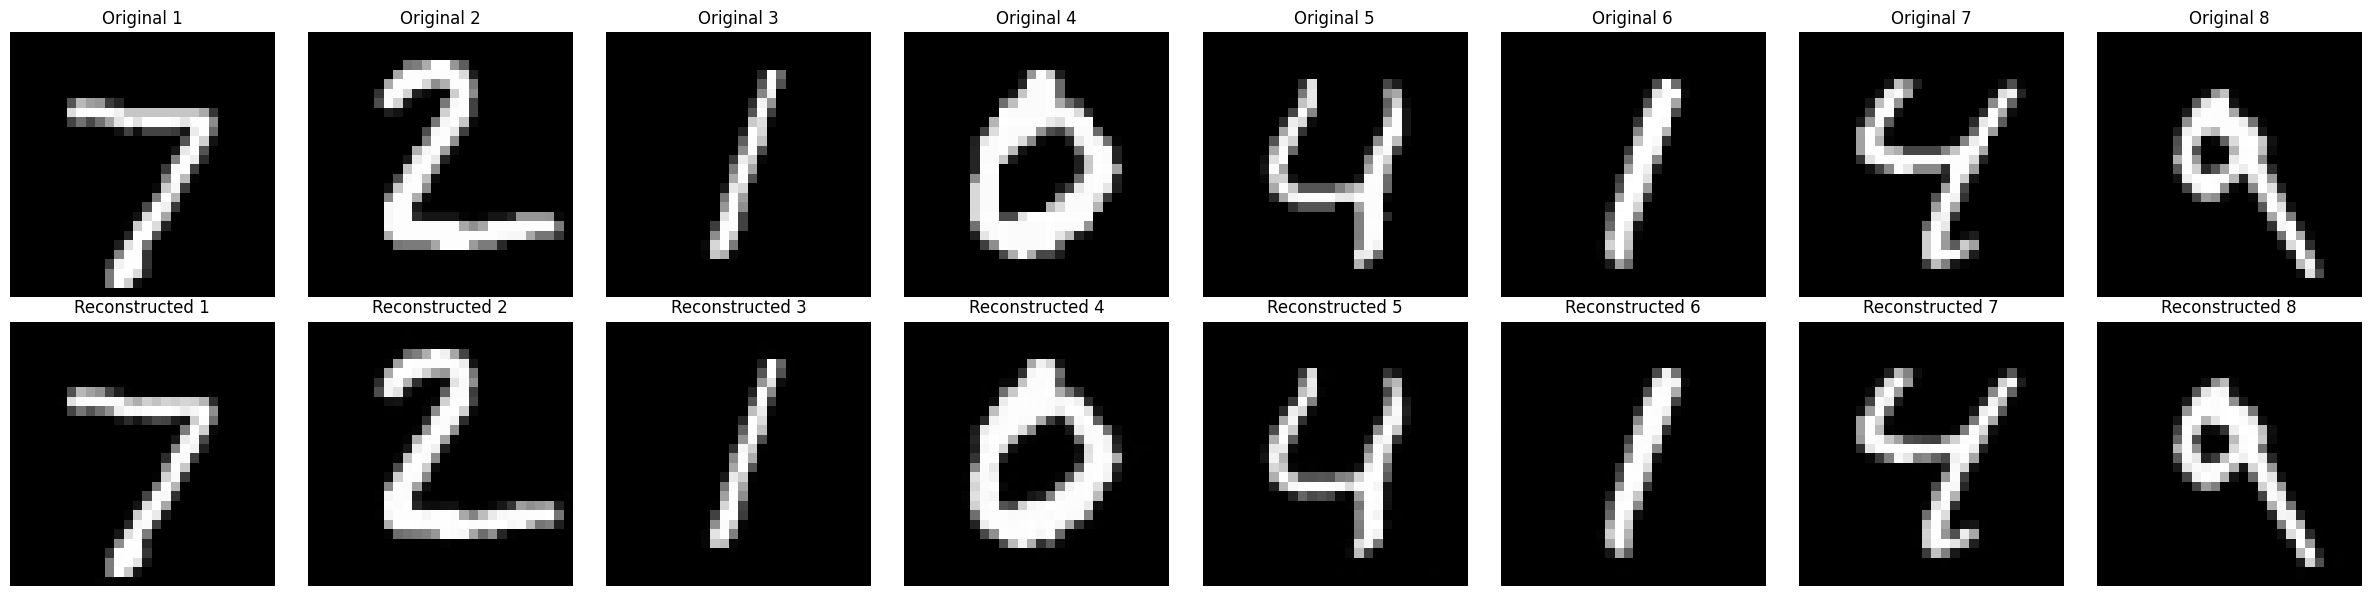

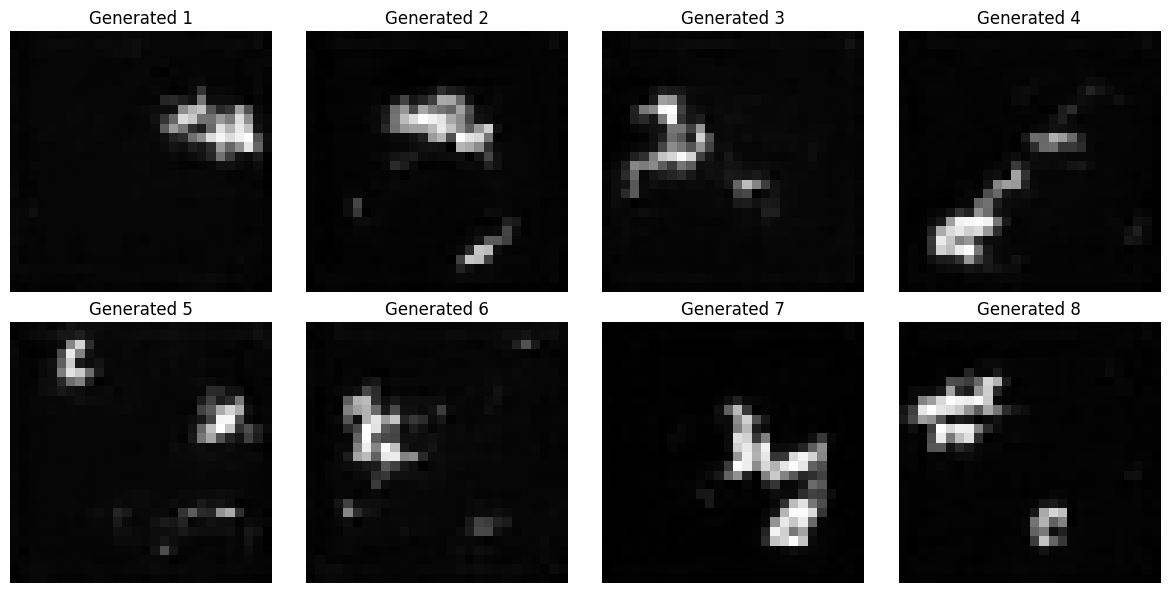


test evaluation results
  L1    : 0.013224
  MSE   : 0.001541
  LPIPS : 0.003077
  PSNR  : 34.2721 dB
  SSIM  : 0.995285
  FID   : 0.9524
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_5e-05_klt_1e-06/eval_test_dq_5e-05_klt_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:59<00:00,  4.70it/s, rec=0.0491, g=0.0000, d=N/A, Dq=-410.5758, KLt=714.8725]



Epoch 1/10 [sd]
  Train - Rec: 0.0924, Reg(sd): 0.0036, Disc: 0.0000
  Val   - Rec Loss: 0.0454
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0454)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:40<00:00,  5.25it/s, rec=0.0350, g=0.0000, d=N/A, Dq=-492.8210, KLt=198.8604]



Epoch 2/10 [sd]
  Train - Rec: 0.0369, Reg(sd): -0.0032, Disc: 0.0000
  Val   - Rec Loss: 0.0312
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0312)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0124, Reg(sd): -0.0051, Disc: 1.0000
  Val   - Rec Loss: 0.0124
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0124)


Epoch 9 [sd]: 100%|██████████| 843/843 [03:09<00:00,  4.45it/s, rec=0.0111, g=0.1636, d=1.0000, Dq=-533.5490, KLt=16.4399]



Epoch 9/10 [sd]
  Train - Rec: 0.0111, Reg(sd): -0.0052, Disc: 1.0000
  Val   - Rec Loss: 0.0107
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0107)


Epoch 10 [sd]: 100%|██████████| 843/843 [02:47<00:00,  5.02it/s, rec=0.0100, g=0.1963, d=1.0000, Dq=-539.9159, KLt=14.1615]



Epoch 10/10 [sd]
  Train - Rec: 0.0103, Reg(sd): -0.0053, Disc: 1.0000
  Val   - Rec Loss: 0.0101
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0101)

[sd] 训练完成! 最佳验证损失: 0.0101


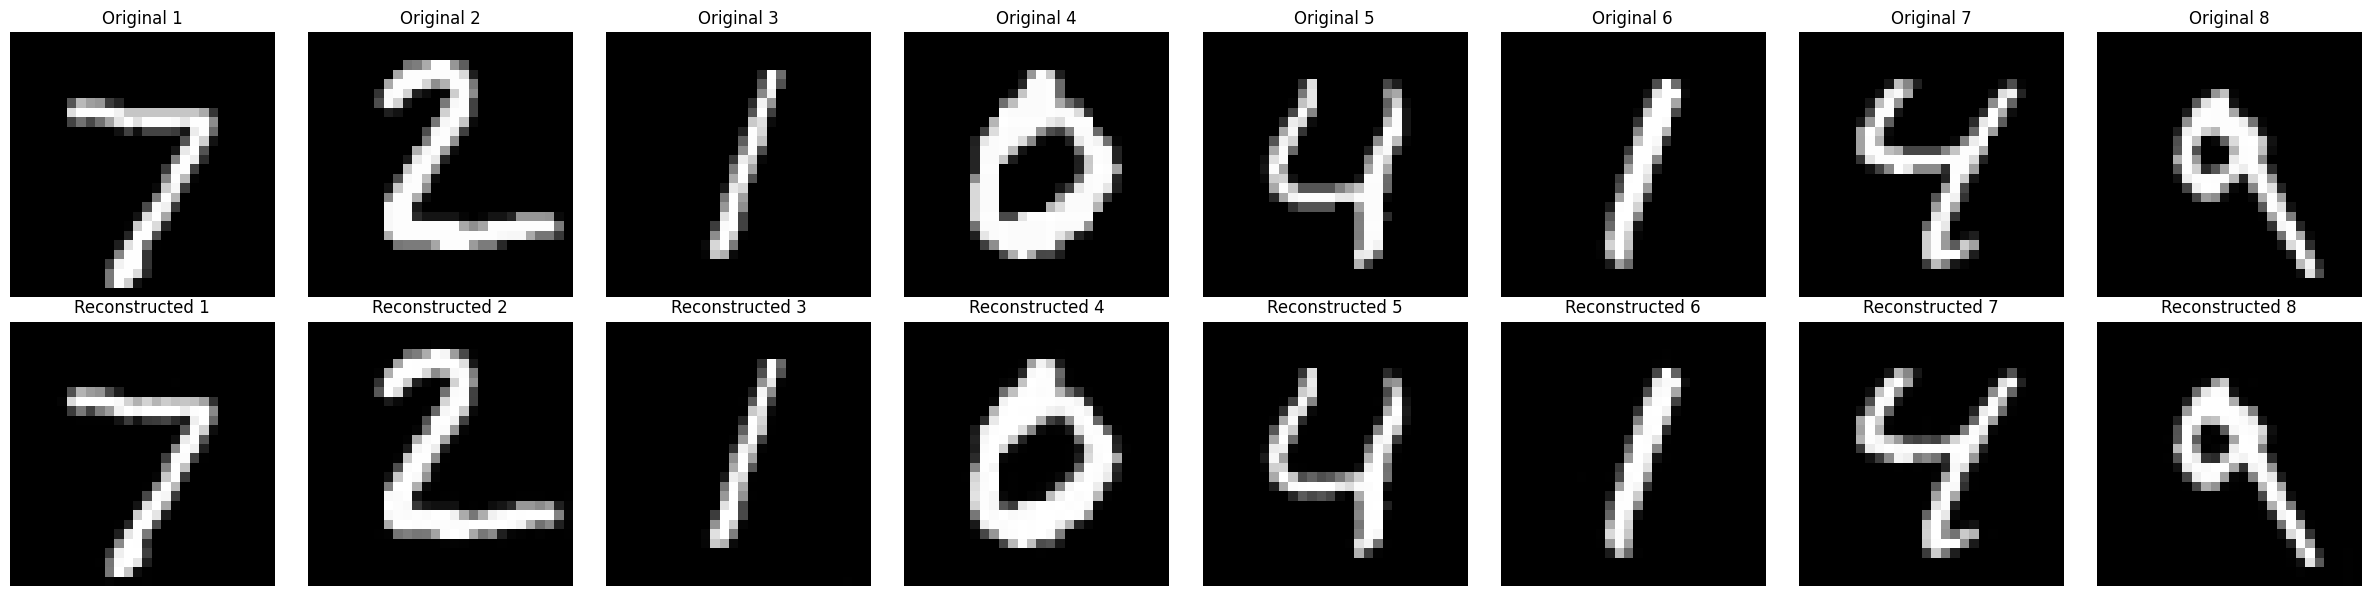

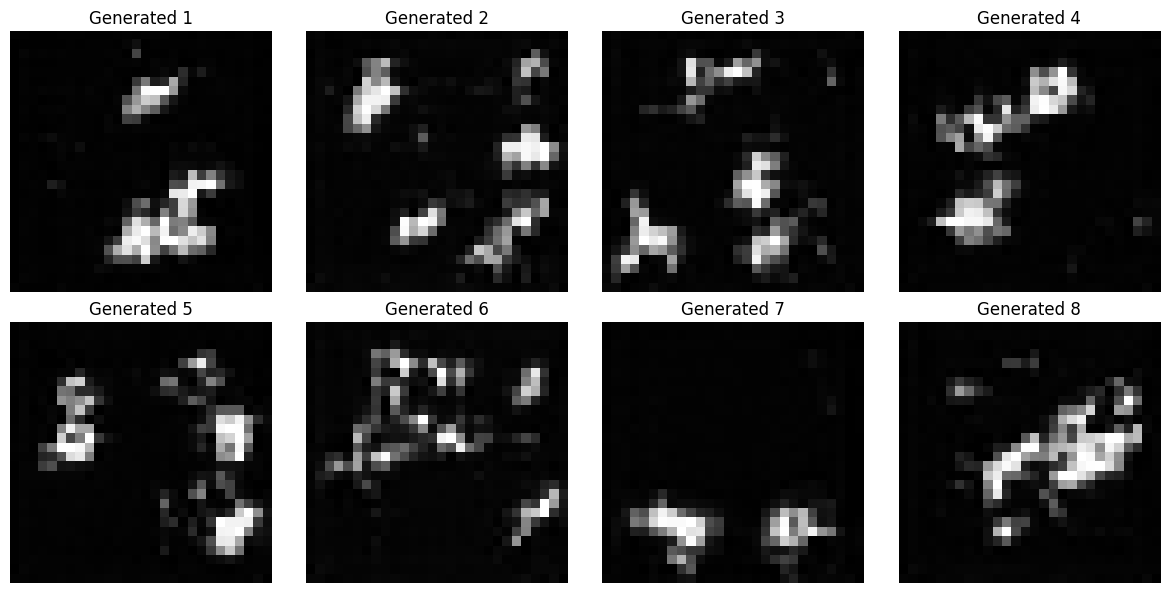


test evaluation results
  L1    : 0.009673
  MSE   : 0.000689
  LPIPS : 0.001446
  PSNR  : 37.8182 dB
  SSIM  : 0.997458
  FID   : 0.6029
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-05_klt_1e-05/eval_test_dq_1e-05_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-06_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-06)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:21<00:00,  5.94it/s, rec=0.0530, g=0.0000, d=N/A, Dq=617.6440, KLt=775.5048]



Epoch 1/10 [sd]
  Train - Rec: 0.0983, Reg(sd): 0.0083, Disc: 0.0000
  Val   - Rec Loss: 0.0567
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0567)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:18<00:00,  6.10it/s, rec=0.0365, g=0.0000, d=N/A, Dq=-37.6917, KLt=188.6318]



Epoch 2/10 [sd]
  Train - Rec: 0.0412, Reg(sd): 0.0015, Disc: 0.0000
  Val   - Rec Loss: 0.0323
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0323)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0132, Reg(sd): -0.0000, Disc: 1.0000
  Val   - Rec Loss: 0.0127
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0127)


Epoch 9 [sd]: 100%|██████████| 843/843 [02:46<00:00,  5.07it/s, rec=0.0119, g=0.0404, d=1.0000, Dq=-279.8055, KLt=18.6130] 



Epoch 9/10 [sd]
  Train - Rec: 0.0117, Reg(sd): -0.0001, Disc: 1.0000
  Val   - Rec Loss: 0.0117
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0117)


Epoch 10 [sd]: 100%|██████████| 843/843 [02:45<00:00,  5.10it/s, rec=0.0104, g=0.0580, d=1.0000, Dq=-278.2747, KLt=16.7817]



Epoch 10/10 [sd]
  Train - Rec: 0.0107, Reg(sd): -0.0001, Disc: 1.0000
  Val   - Rec Loss: 0.0103
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0103)

[sd] 训练完成! 最佳验证损失: 0.0103


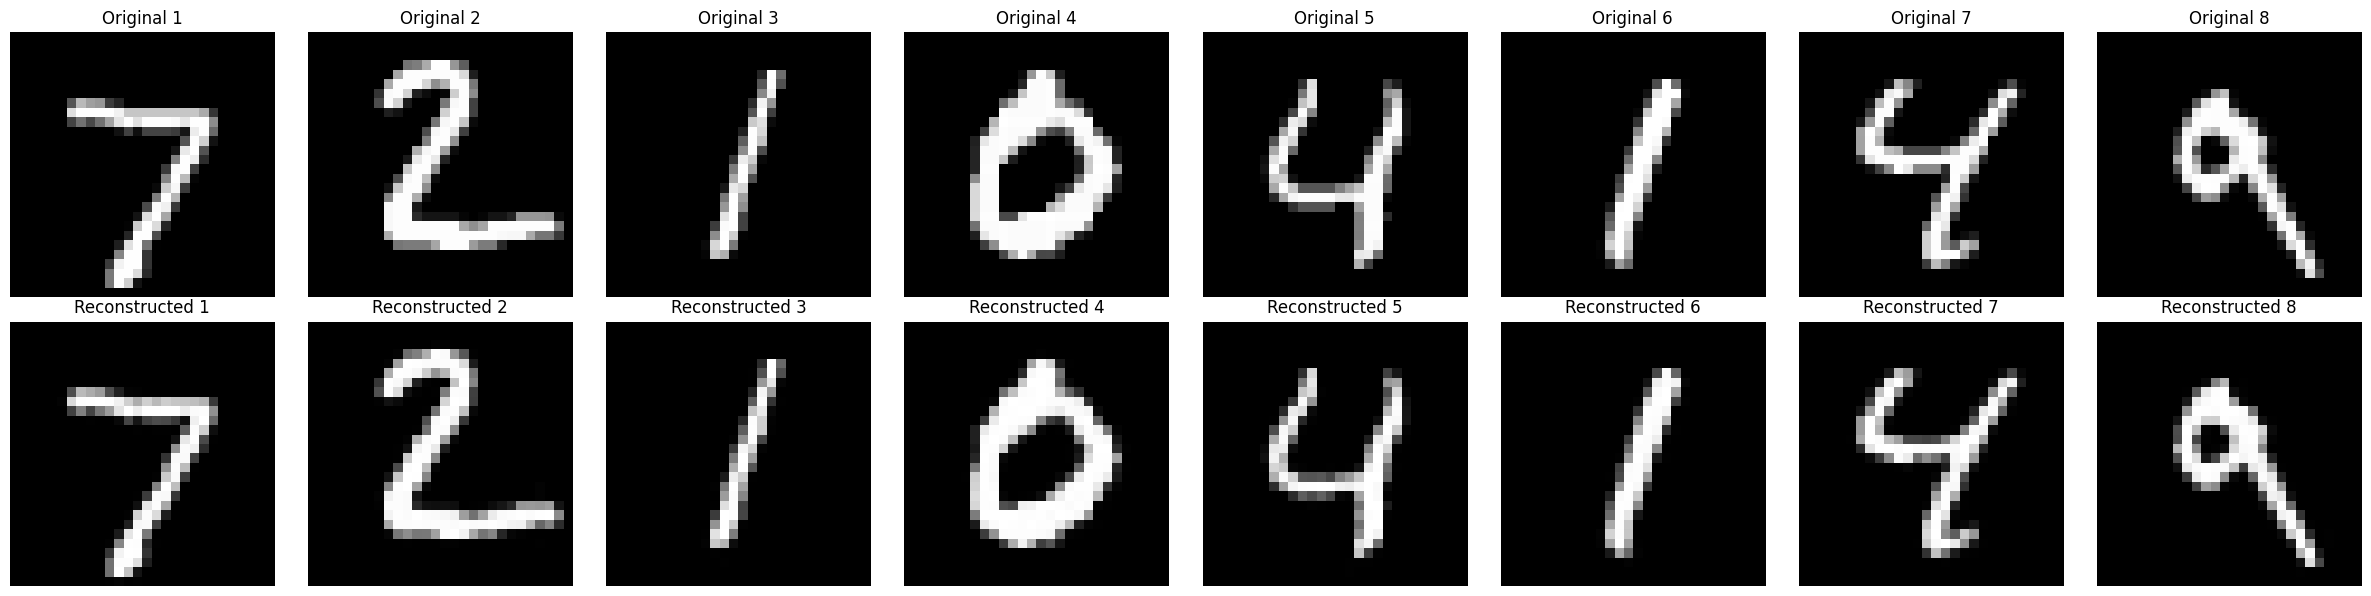

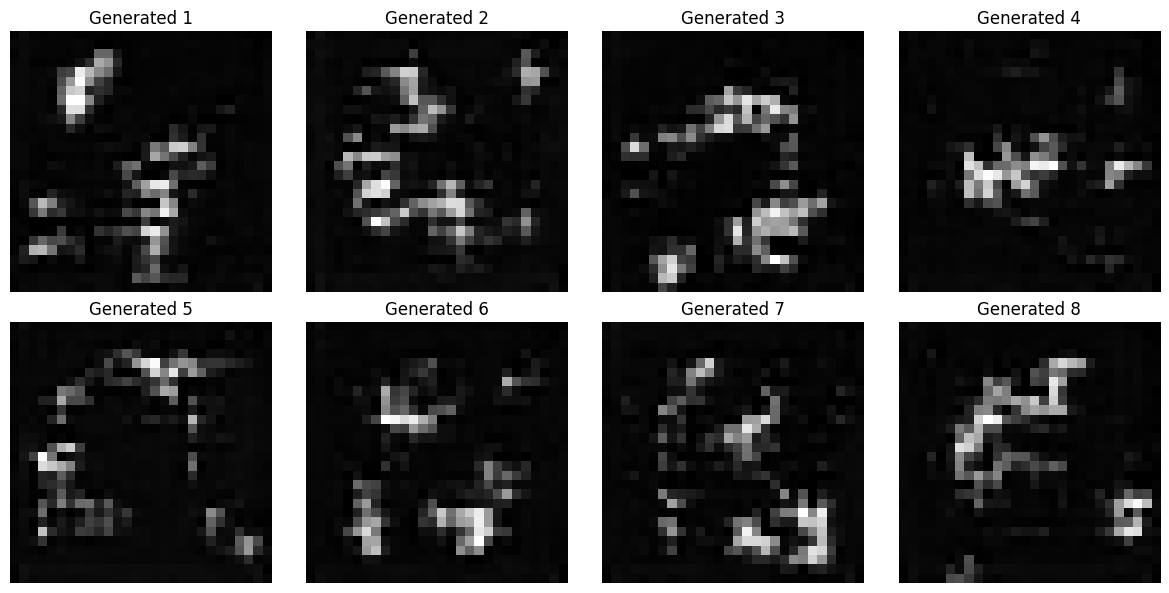


test evaluation results
  L1    : 0.009853
  MSE   : 0.000703
  LPIPS : 0.001462
  PSNR  : 37.7272 dB
  SSIM  : 0.997690
  FID   : 0.6418
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_1e-06_klt_1e-05/eval_test_dq_1e-06_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_5e-05_klt_1e-05) on mnist
损失函数: L_rec + (...) = L_rec + eff_dq(5.000e-05)*Dq + eff_klt(1.000e-05)*KL_t + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 843/843 [02:23<00:00,  5.88it/s, rec=0.0469, g=0.0000, d=N/A, Dq=-655.5261, KLt=715.0398]



Epoch 1/10 [sd]
  Train - Rec: 0.0953, Reg(sd): -0.0237, Disc: 0.0000
  Val   - Rec Loss: 0.0500
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0500)


Epoch 2 [sd]: 100%|██████████| 843/843 [02:21<00:00,  5.96it/s, rec=0.0413, g=0.0000, d=N/A, Dq=-681.9064, KLt=138.3129]



Epoch 2/10 [sd]
  Train - Rec: 0.0405, Reg(sd): -0.0327, Disc: 0.0000
  Val   - Rec Loss: 0.0398
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0398)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0173, Reg(sd): -0.0342, Disc: 0.8492
  Val   - Rec Loss: 0.0166
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0166)


Epoch 9 [sd]: 100%|██████████| 843/843 [02:44<00:00,  5.11it/s, rec=0.0164, g=0.3581, d=0.6211, Dq=-687.9229, KLt=13.9817] 



Epoch 9/10 [sd]
  Train - Rec: 0.0159, Reg(sd): -0.0342, Disc: 0.7454
  Val   - Rec Loss: 0.0156
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0156)


Epoch 10 [sd]: 100%|██████████| 843/843 [02:45<00:00,  5.09it/s, rec=0.0153, g=0.9270, d=0.7711, Dq=-689.7753, KLt=8.2533]  



Epoch 10/10 [sd]
  Train - Rec: 0.0151, Reg(sd): -0.0342, Disc: 0.6735
  Val   - Rec Loss: 0.0149
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0149)

[sd] 训练完成! 最佳验证损失: 0.0149


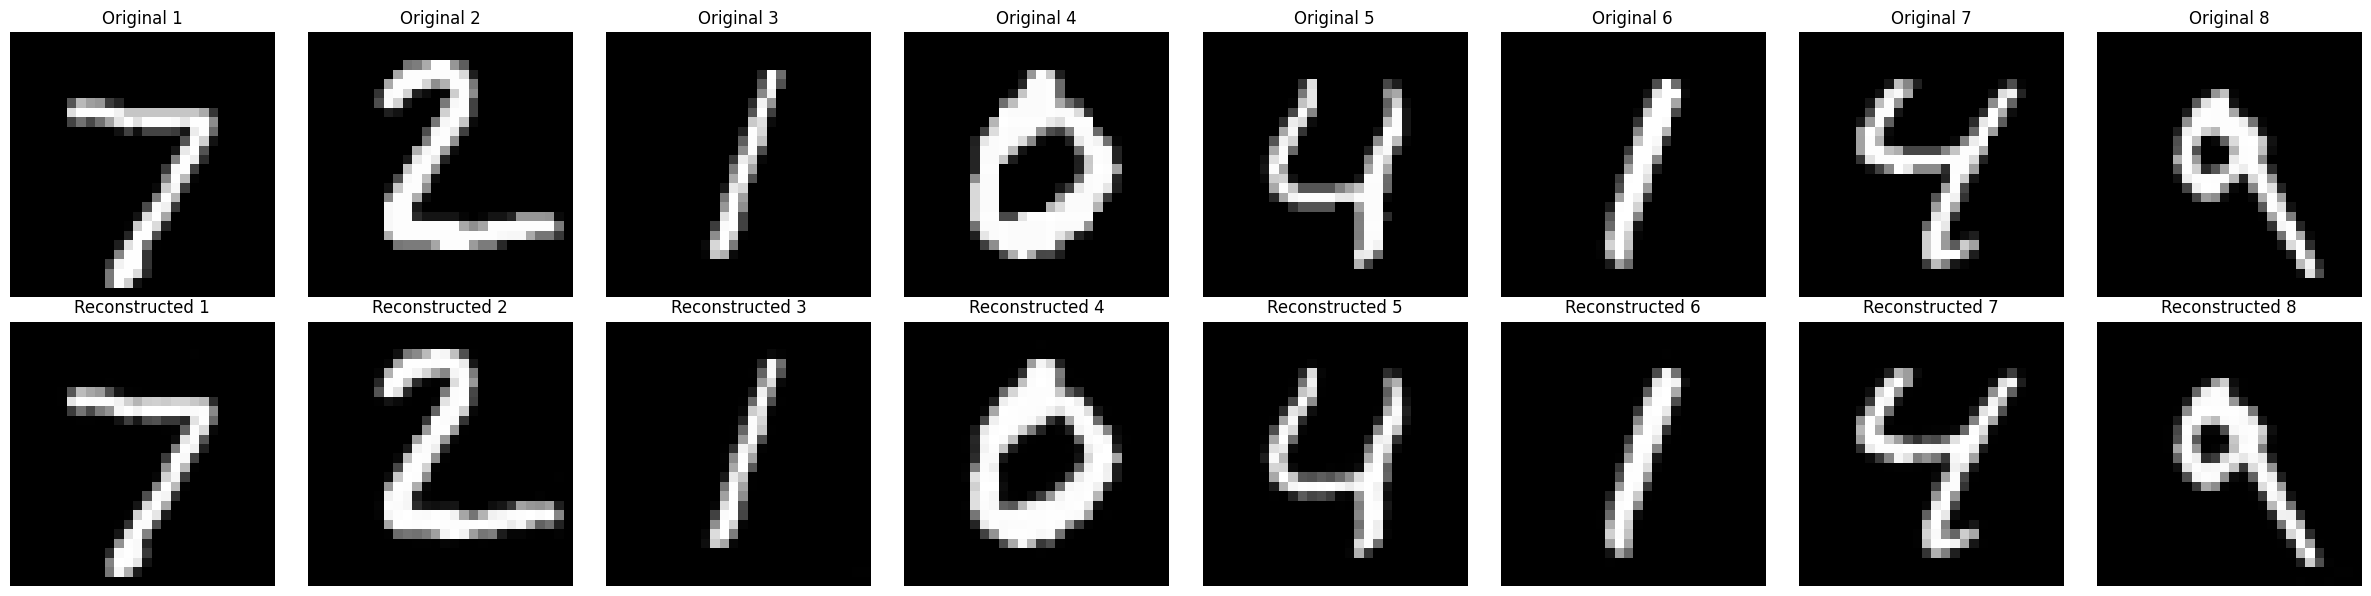

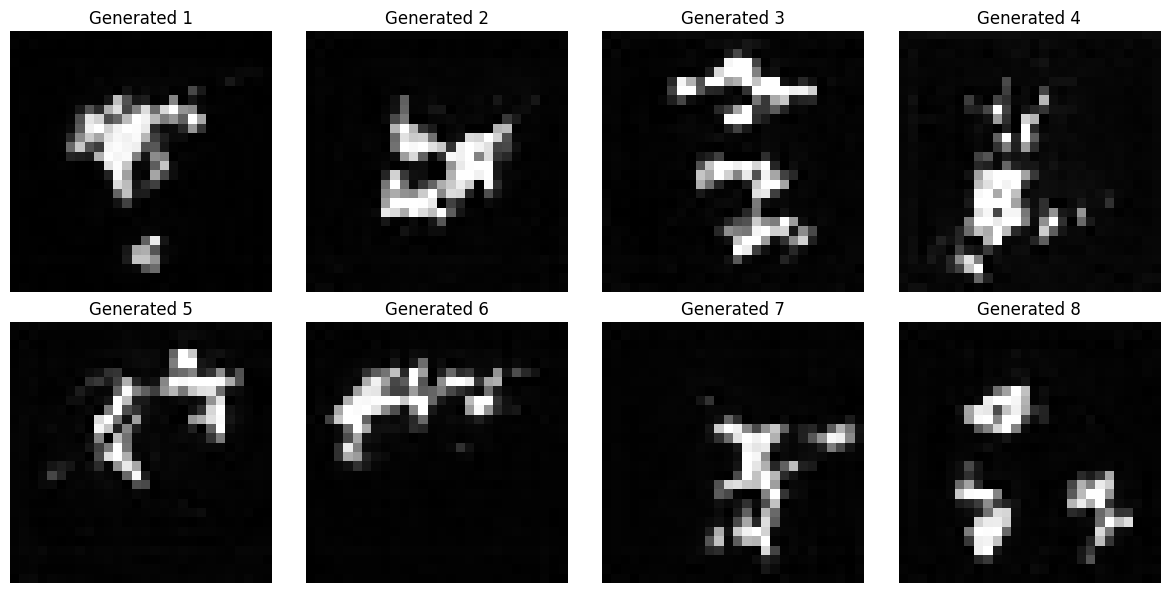


test evaluation results
  L1    : 0.013819
  MSE   : 0.001822
  LPIPS : 0.003589
  PSNR  : 33.5817 dB
  SSIM  : 0.994909
  FID   : 1.1143
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/dq_5e-05_klt_1e-05/eval_test_dq_5e-05_klt_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[sd] 最终评估完成。


In [19]:
for klt_w in [1e-8, 4e-8, 1e-6,1e-5]:
    for dq_w in [1e-5,1e-6,5e-5]:
        for rep in range(1): 
            _ = run_training("sd", 
                            sd_dq_weight=dq_w, 
                            sd_klt_weight=klt_w,  
                            run_tag=f"dq_{dq_w:.0e}_klt_{klt_w:.0e}")


### run iwae

[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [00:55<00:00, 15.22it/s, rec=0.0428, g=0.0000, d=N/A, IWAE=1377.6005]



Epoch 1/10 [iwae]
  Train - Rec: 0.0876, Reg(iwae): 1369.6931, Disc: 0.0000
  Val   - Rec Loss: 0.0406
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0406)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:06<00:00, 12.71it/s, rec=0.0377, g=0.0000, d=N/A, IWAE=1297.9398]



Epoch 2/10 [iwae]
  Train - Rec: 0.0347, Reg(iwae): 1331.1221, Disc: 0.0000
  Val   - Rec Loss: 0.0296
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0296)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0123, Reg(iwae): 1309.1624, Disc: 0.9209
  Val   - Rec Loss: 0.0121
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0121)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:32<00:00,  9.07it/s, rec=0.0109, g=0.3212, d=0.8376, IWAE=1309.6216] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0112, Reg(iwae): 1309.8842, Disc: 0.8754
  Val   - Rec Loss: 0.0109
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0109)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:32<00:00,  9.13it/s, rec=0.0110, g=-0.7396, d=0.8777, IWAE=1315.6719]



Epoch 10/10 [iwae]
  Train - Rec: 0.0105, Reg(iwae): 1309.2501, Disc: 0.8656
  Val   - Rec Loss: 0.0104
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0104)

[iwae] 训练完成! 最佳验证损失: 0.0104


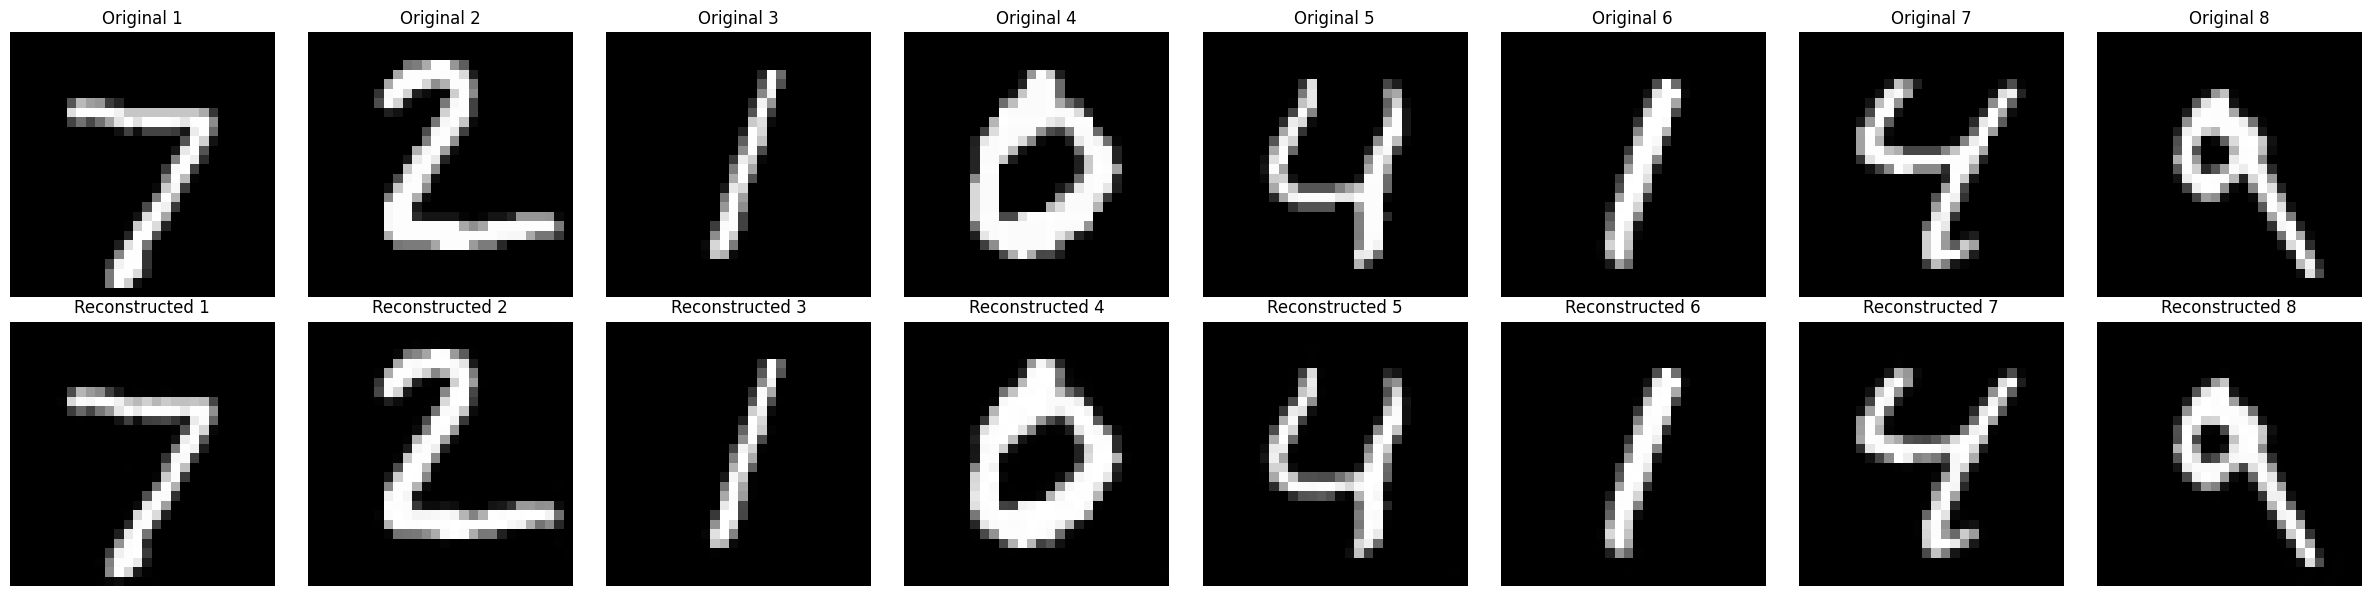

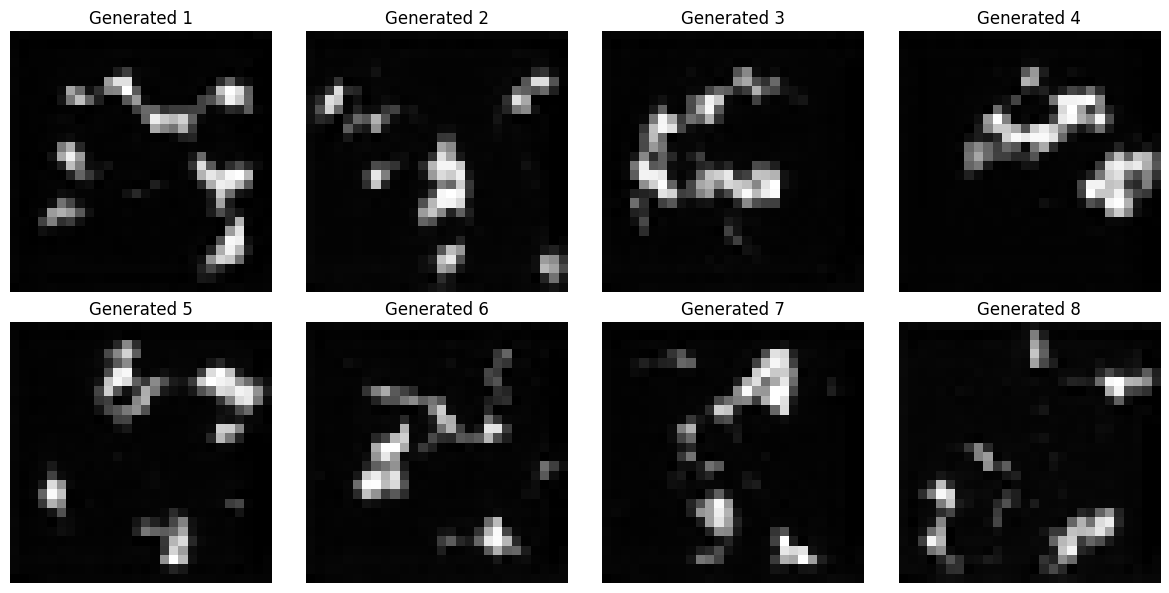


test evaluation results
  L1    : 0.009944
  MSE   : 0.000735
  LPIPS : 0.001482
  PSNR  : 37.5019 dB
  SSIM  : 0.997182
  FID   : 0.5900
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:05<00:00, 12.81it/s, rec=0.0386, g=0.0000, d=N/A, IWAE=2356.6648]



Epoch 1/10 [iwae]
  Train - Rec: 0.0834, Reg(iwae): 2236.4390, Disc: 0.0000
  Val   - Rec Loss: 0.0403
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0403)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:01<00:00, 13.74it/s, rec=0.0346, g=0.0000, d=N/A, IWAE=2352.8848]



Epoch 2/10 [iwae]
  Train - Rec: 0.0345, Reg(iwae): 2364.1953, Disc: 0.0000
  Val   - Rec Loss: 0.0275
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0275)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0104, Reg(iwae): 2227.8792, Disc: 1.0000
  Val   - Rec Loss: 0.0104
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0104)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:33<00:00,  9.01it/s, rec=0.0093, g=0.0081, d=1.0000, IWAE=2238.9653] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0091, Reg(iwae): 2232.1852, Disc: 1.0000
  Val   - Rec Loss: 0.0086
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0086)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:20<00:00, 10.48it/s, rec=0.0083, g=0.0520, d=1.0000, IWAE=2256.6489] 



Epoch 10/10 [iwae]
  Train - Rec: 0.0083, Reg(iwae): 2239.1660, Disc: 1.0000
  Val   - Rec Loss: 0.0081
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0081)

[iwae] 训练完成! 最佳验证损失: 0.0081


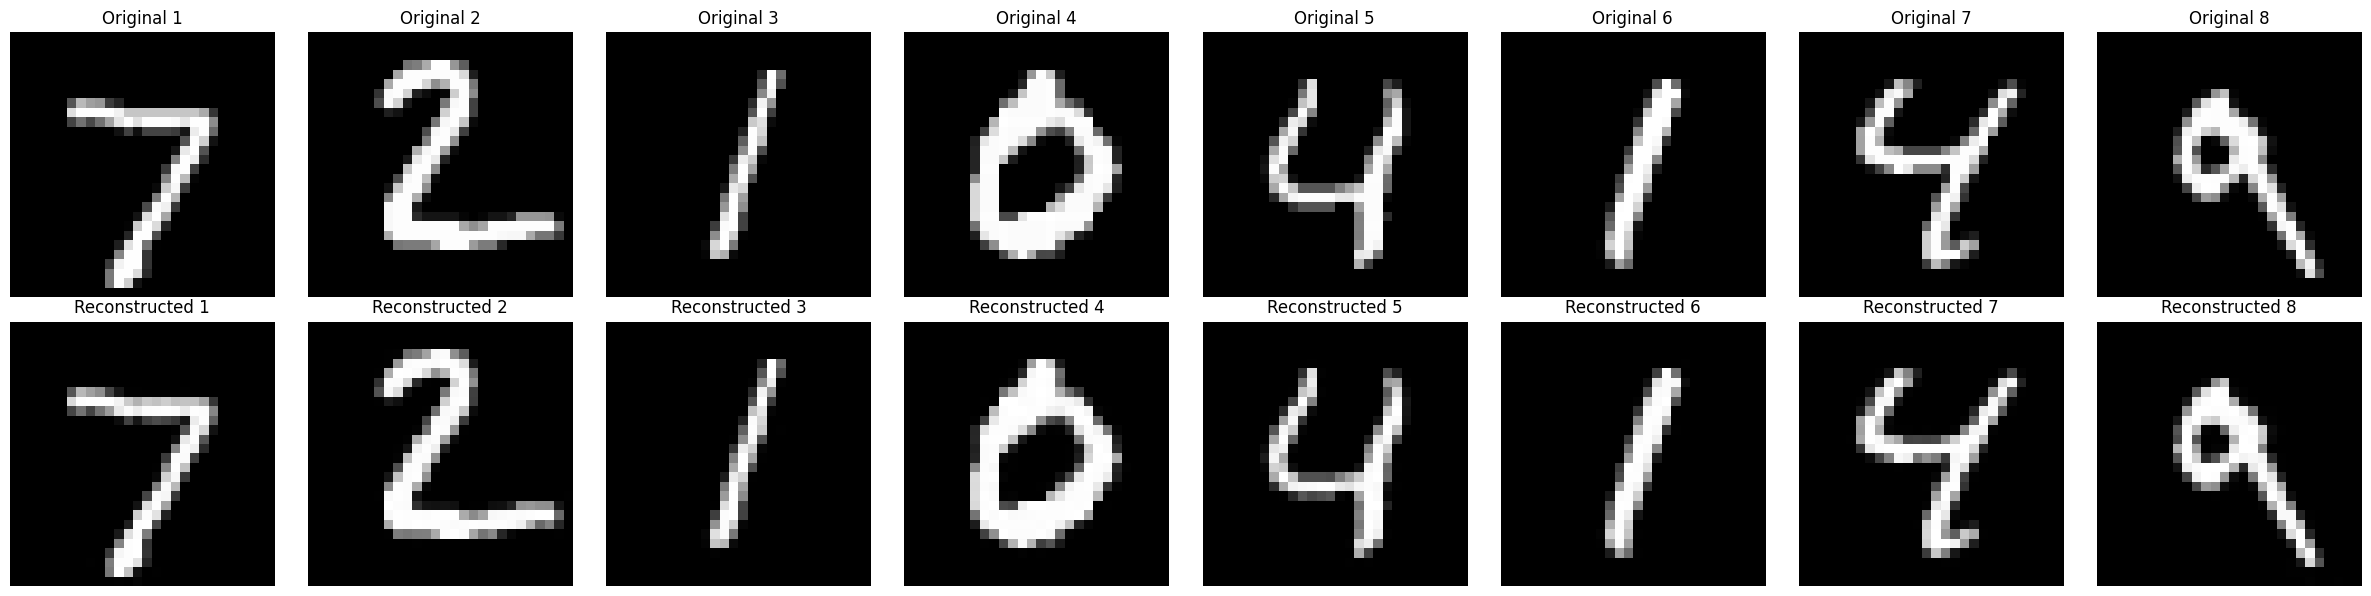

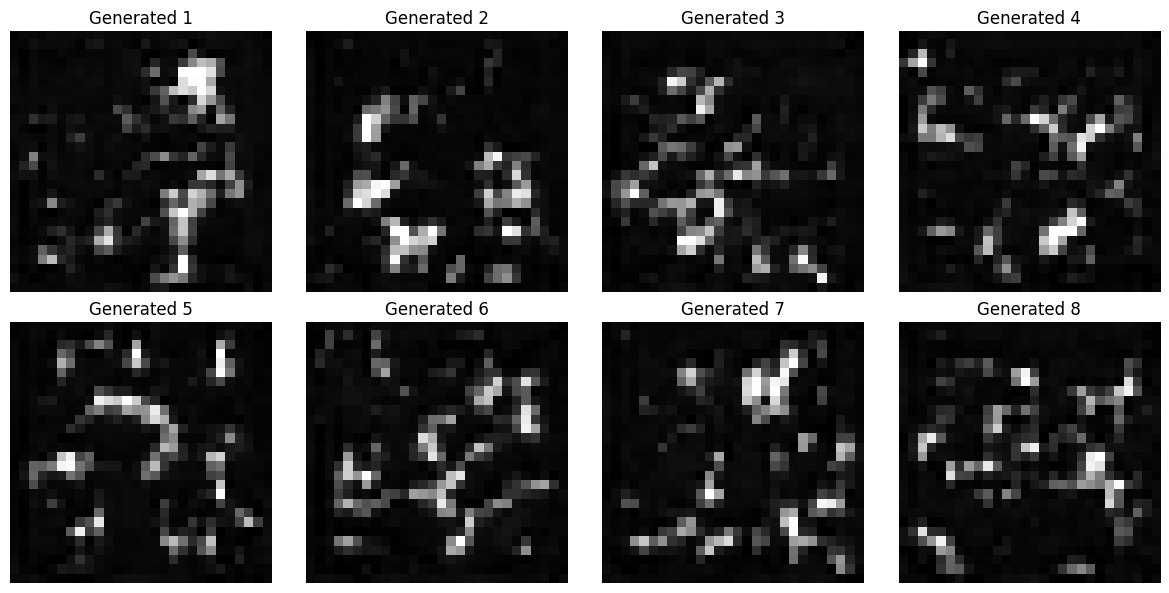


test evaluation results
  L1    : 0.007786
  MSE   : 0.000387
  LPIPS : 0.000838
  PSNR  : 40.3794 dB
  SSIM  : 0.998545
  FID   : 0.4058
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。


In [20]:
for w in [1e-5,1e-6]:
    for rep in range(1): 
        _ = run_training("iwae", kl_weight=w, run_tag=f"iwae_kl_{w:.0e}")


[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [00:57<00:00, 14.60it/s, rec=0.0435, g=0.0000, d=N/A, IWAE=1325.1499]



Epoch 1/10 [iwae]
  Train - Rec: 0.0847, Reg(iwae): 1334.1480, Disc: 0.0000
  Val   - Rec Loss: 0.0394
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0394)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:04<00:00, 13.06it/s, rec=0.0298, g=0.0000, d=N/A, IWAE=1241.3381]



Epoch 2/10 [iwae]
  Train - Rec: 0.0363, Reg(iwae): 1289.0979, Disc: 0.0000
  Val   - Rec Loss: 0.0260
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0260)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0124, Reg(iwae): 1219.9247, Disc: 1.0000
  Val   - Rec Loss: 0.0125
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0125)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.20it/s, rec=0.0122, g=0.0607, d=1.0000, IWAE=1234.7830] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0111, Reg(iwae): 1222.4719, Disc: 1.0000
  Val   - Rec Loss: 0.0107
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0107)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:22<00:00, 10.19it/s, rec=0.0101, g=0.0408, d=1.0000, IWAE=1220.7650]



Epoch 10/10 [iwae]
  Train - Rec: 0.0103, Reg(iwae): 1224.2141, Disc: 1.0000
  Val   - Rec Loss: 0.0099
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0099)

[iwae] 训练完成! 最佳验证损失: 0.0099


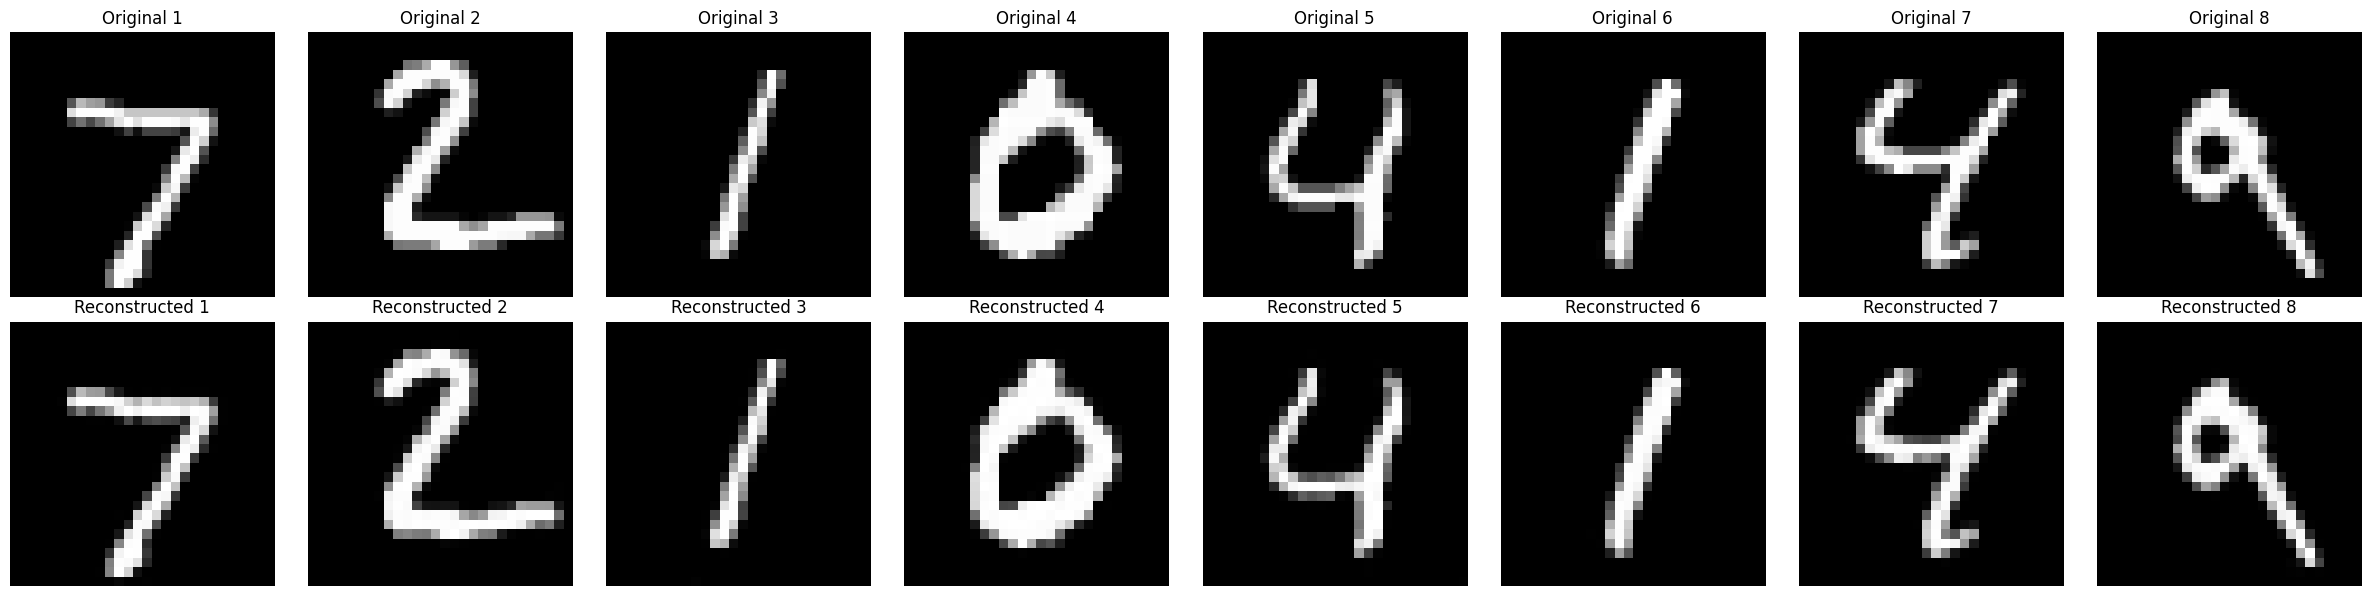

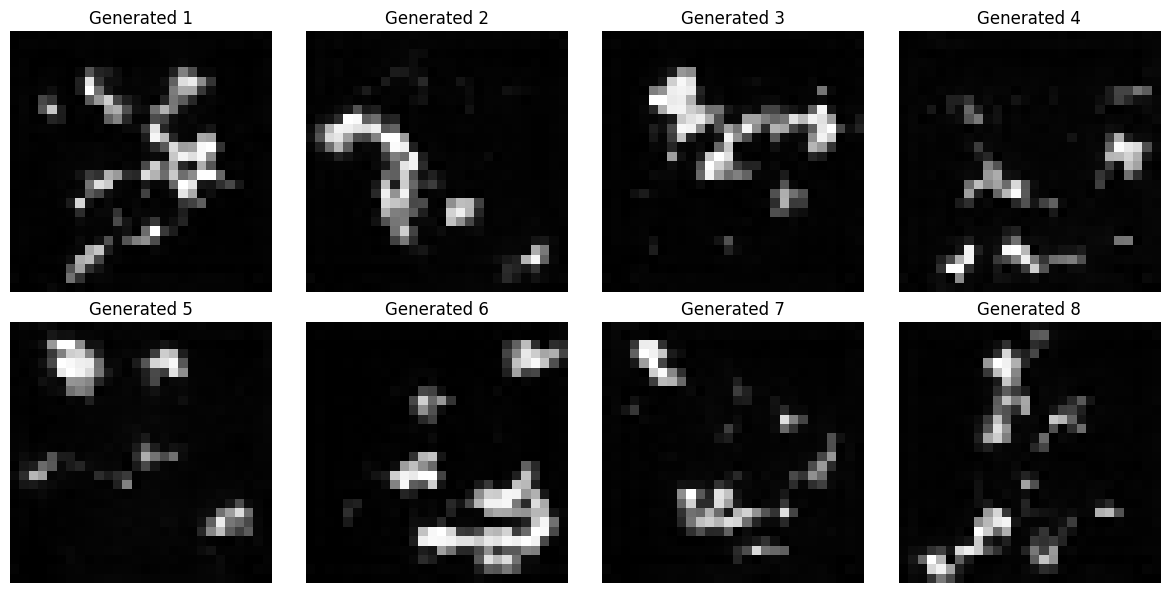


test evaluation results
  L1    : 0.009456
  MSE   : 0.000649
  LPIPS : 0.001371
  PSNR  : 38.0534 dB
  SSIM  : 0.998108
  FID   : 0.5515
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:00<00:00, 13.83it/s, rec=0.0429, g=0.0000, d=N/A, IWAE=1280.3535]



Epoch 1/10 [iwae]
  Train - Rec: 0.0869, Reg(iwae): 1325.0720, Disc: 0.0000
  Val   - Rec Loss: 0.0425
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0425)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:08<00:00, 12.32it/s, rec=0.0330, g=0.0000, d=N/A, IWAE=1268.2483]



Epoch 2/10 [iwae]
  Train - Rec: 0.0369, Reg(iwae): 1262.4067, Disc: 0.0000
  Val   - Rec Loss: 0.0301
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0301)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0125, Reg(iwae): 1308.0034, Disc: 0.9718
  Val   - Rec Loss: 0.0124
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0124)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:32<00:00,  9.13it/s, rec=0.0108, g=0.3403, d=0.9529, IWAE=1298.1163] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0113, Reg(iwae): 1309.7010, Disc: 0.9387
  Val   - Rec Loss: 0.0108
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0108)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:26<00:00,  9.72it/s, rec=0.0108, g=0.2607, d=0.8040, IWAE=1306.4873] 



Epoch 10/10 [iwae]
  Train - Rec: 0.0105, Reg(iwae): 1309.0438, Disc: 0.8819
  Val   - Rec Loss: 0.0108
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0108)

[iwae] 训练完成! 最佳验证损失: 0.0108


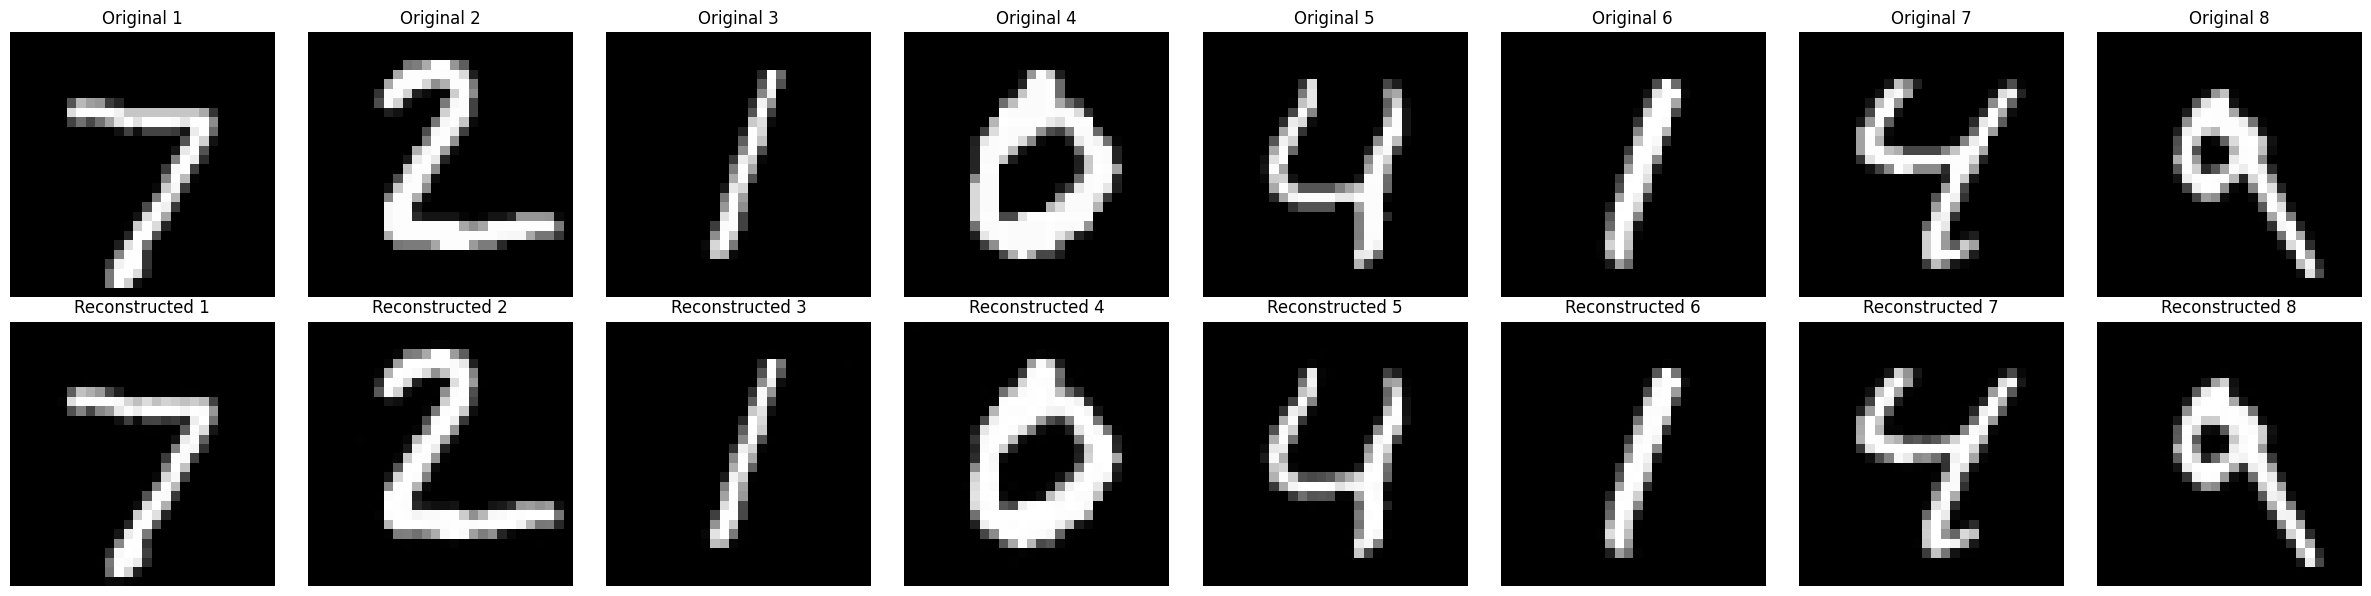

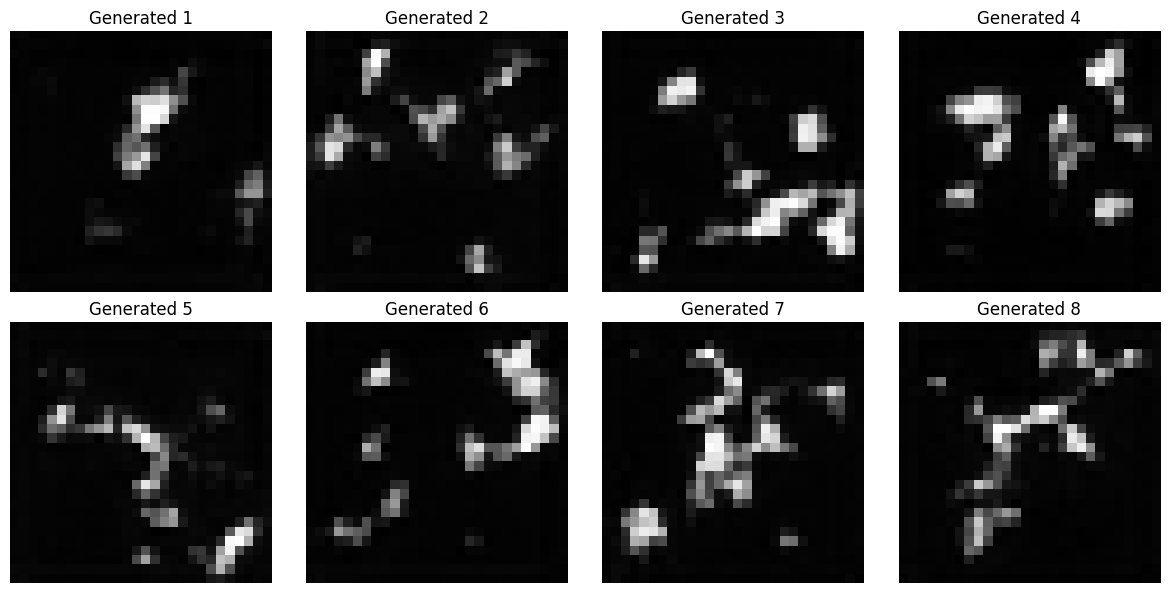


test evaluation results
  L1    : 0.010318
  MSE   : 0.000786
  LPIPS : 0.001473
  PSNR  : 37.2138 dB
  SSIM  : 0.996993
  FID   : 0.5444
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:03<00:00, 13.20it/s, rec=0.0419, g=0.0000, d=N/A, IWAE=1193.0388]



Epoch 1/10 [iwae]
  Train - Rec: 0.0850, Reg(iwae): 1313.1732, Disc: 0.0000
  Val   - Rec Loss: 0.0432
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0432)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:05<00:00, 12.82it/s, rec=0.0308, g=0.0000, d=N/A, IWAE=1150.5317]



Epoch 2/10 [iwae]
  Train - Rec: 0.0374, Reg(iwae): 1155.8088, Disc: 0.0000
  Val   - Rec Loss: 0.0310
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0310)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0123, Reg(iwae): 1194.0229, Disc: 0.9948
  Val   - Rec Loss: 0.0117
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0117)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:32<00:00,  9.11it/s, rec=0.0098, g=0.1002, d=0.9977, IWAE=1182.9214] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0110, Reg(iwae): 1198.2905, Disc: 0.9824
  Val   - Rec Loss: 0.0109
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0109)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.21it/s, rec=0.0094, g=-0.3597, d=0.9925, IWAE=1185.5505]



Epoch 10/10 [iwae]
  Train - Rec: 0.0102, Reg(iwae): 1200.8877, Disc: 0.9675
  Val   - Rec Loss: 0.0099
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0099)

[iwae] 训练完成! 最佳验证损失: 0.0099


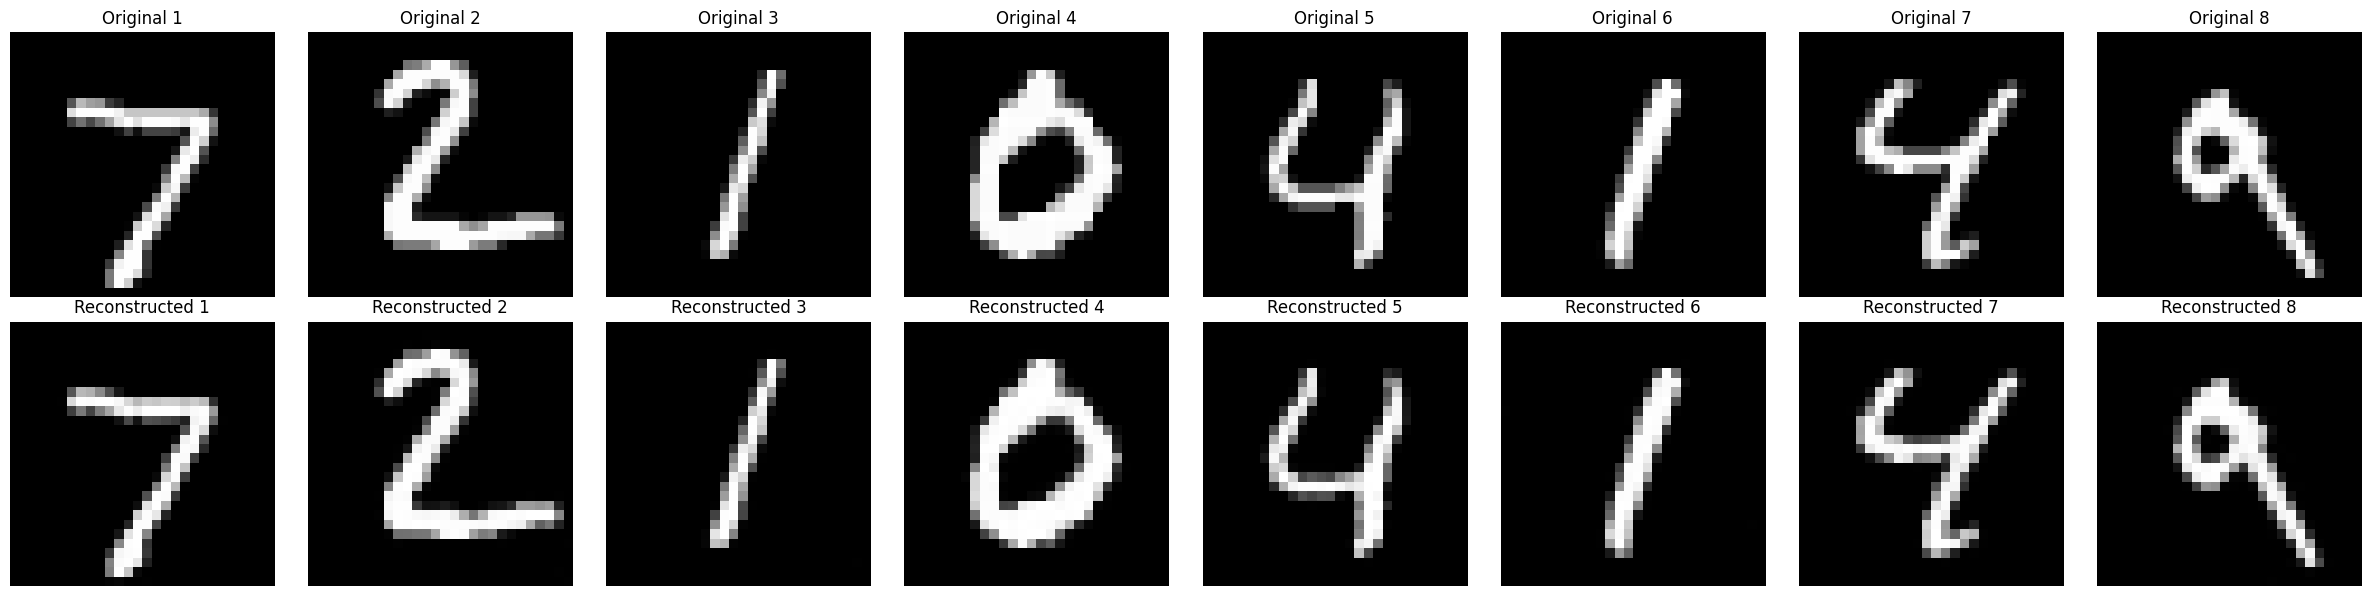

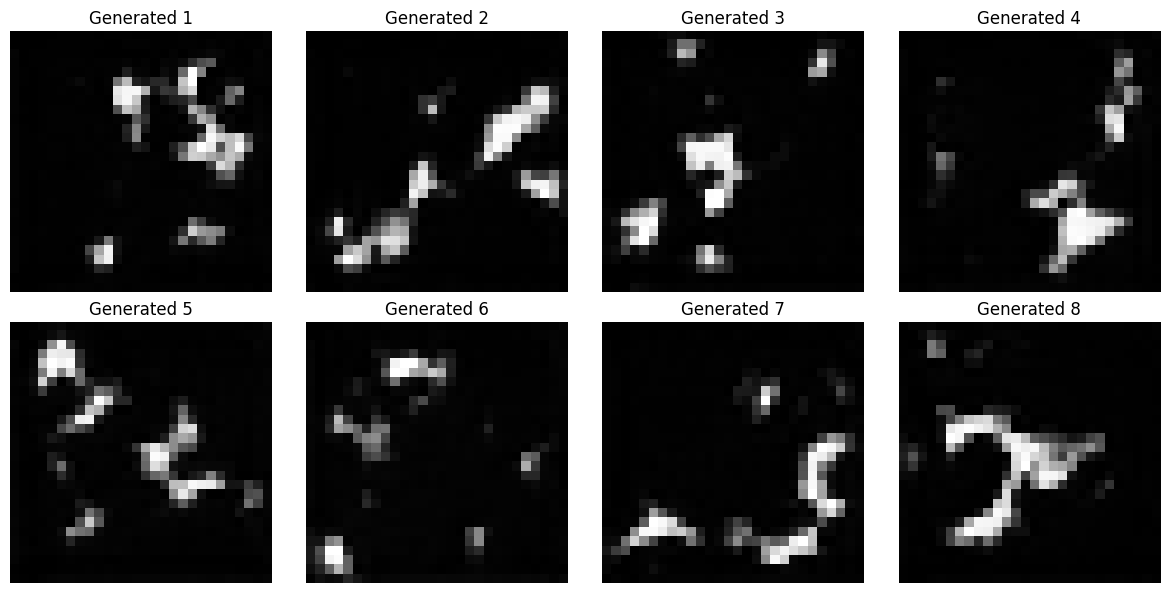


test evaluation results
  L1    : 0.009497
  MSE   : 0.000651
  LPIPS : 0.001356
  PSNR  : 38.0492 dB
  SSIM  : 0.997709
  FID   : 0.5829
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:02<00:00, 13.46it/s, rec=0.0477, g=0.0000, d=N/A, IWAE=1209.7521]



Epoch 1/10 [iwae]
  Train - Rec: 0.0847, Reg(iwae): 1322.6170, Disc: 0.0000
  Val   - Rec Loss: 0.0414
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0414)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:06<00:00, 12.74it/s, rec=0.0354, g=0.0000, d=N/A, IWAE=1161.8188]



Epoch 2/10 [iwae]
  Train - Rec: 0.0373, Reg(iwae): 1174.2808, Disc: 0.0000
  Val   - Rec Loss: 0.0337
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0337)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0127, Reg(iwae): 1201.8110, Disc: 1.0000
  Val   - Rec Loss: 0.0124
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0124)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:34<00:00,  8.92it/s, rec=0.0108, g=-0.0060, d=1.0000, IWAE=1202.7532]



Epoch 9/10 [iwae]
  Train - Rec: 0.0113, Reg(iwae): 1204.2557, Disc: 1.0000
  Val   - Rec Loss: 0.0108
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0108)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:33<00:00,  9.01it/s, rec=0.0107, g=-0.0035, d=1.0000, IWAE=1201.2045]



Epoch 10/10 [iwae]
  Train - Rec: 0.0105, Reg(iwae): 1205.4911, Disc: 1.0000
  Val   - Rec Loss: 0.0106
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0106)

[iwae] 训练完成! 最佳验证损失: 0.0106


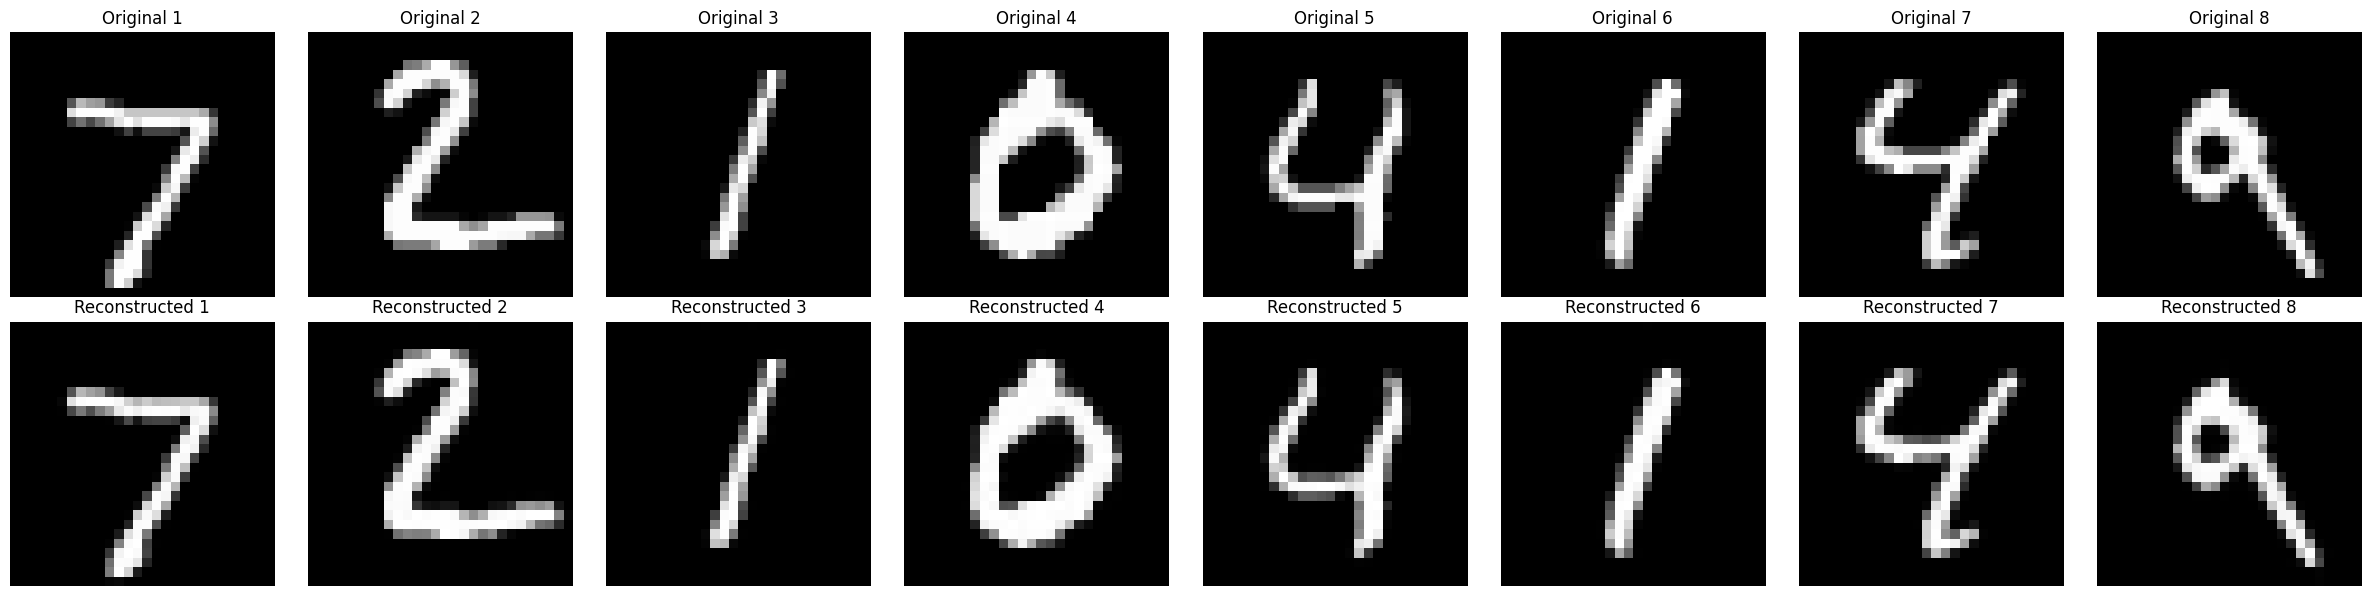

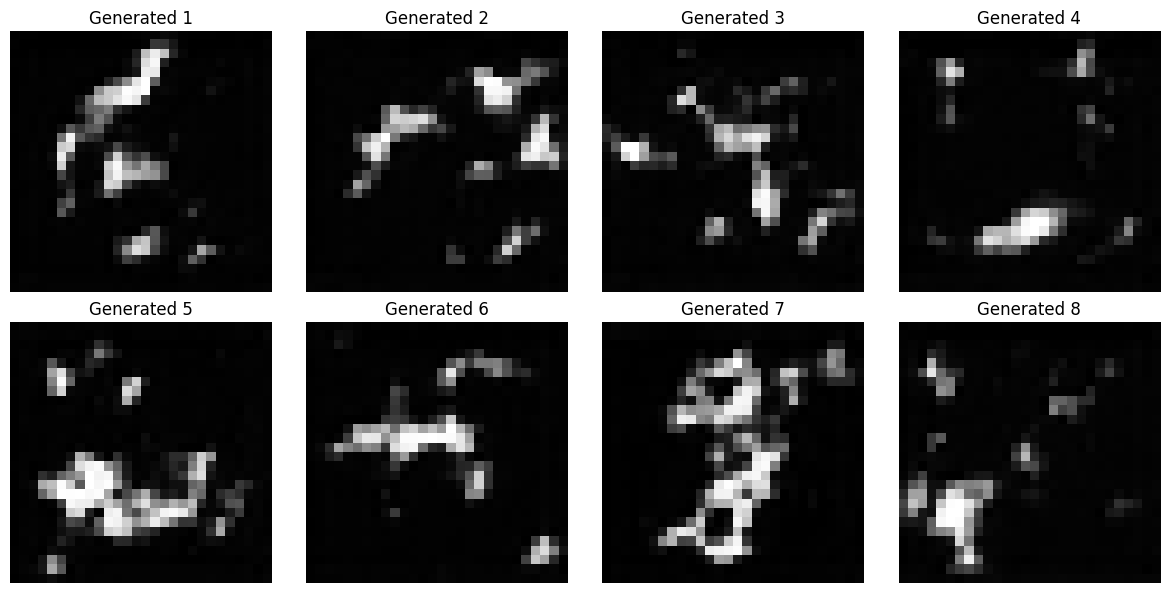


test evaluation results
  L1    : 0.010117
  MSE   : 0.000739
  LPIPS : 0.001468
  PSNR  : 37.4922 dB
  SSIM  : 0.997892
  FID   : 0.5949
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:06<00:00, 12.60it/s, rec=0.0420, g=0.0000, d=N/A, IWAE=1311.2980]



Epoch 1/10 [iwae]
  Train - Rec: 0.0885, Reg(iwae): 1325.5213, Disc: 0.0000
  Val   - Rec Loss: 0.0404
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0404)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:06<00:00, 12.62it/s, rec=0.0338, g=0.0000, d=N/A, IWAE=1271.7069]



Epoch 2/10 [iwae]
  Train - Rec: 0.0350, Reg(iwae): 1296.4907, Disc: 0.0000
  Val   - Rec Loss: 0.0311
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0311)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0127, Reg(iwae): 1211.0025, Disc: 1.0000
  Val   - Rec Loss: 0.0126
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0126)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:35<00:00,  8.81it/s, rec=0.0106, g=-0.0225, d=1.0000, IWAE=1200.6267]



Epoch 9/10 [iwae]
  Train - Rec: 0.0113, Reg(iwae): 1210.5639, Disc: 1.0000
  Val   - Rec Loss: 0.0111
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0111)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:26<00:00,  9.78it/s, rec=0.0102, g=-0.0164, d=1.0000, IWAE=1199.1136]



Epoch 10/10 [iwae]
  Train - Rec: 0.0105, Reg(iwae): 1211.9387, Disc: 1.0000
  Val   - Rec Loss: 0.0105
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0105)

[iwae] 训练完成! 最佳验证损失: 0.0105


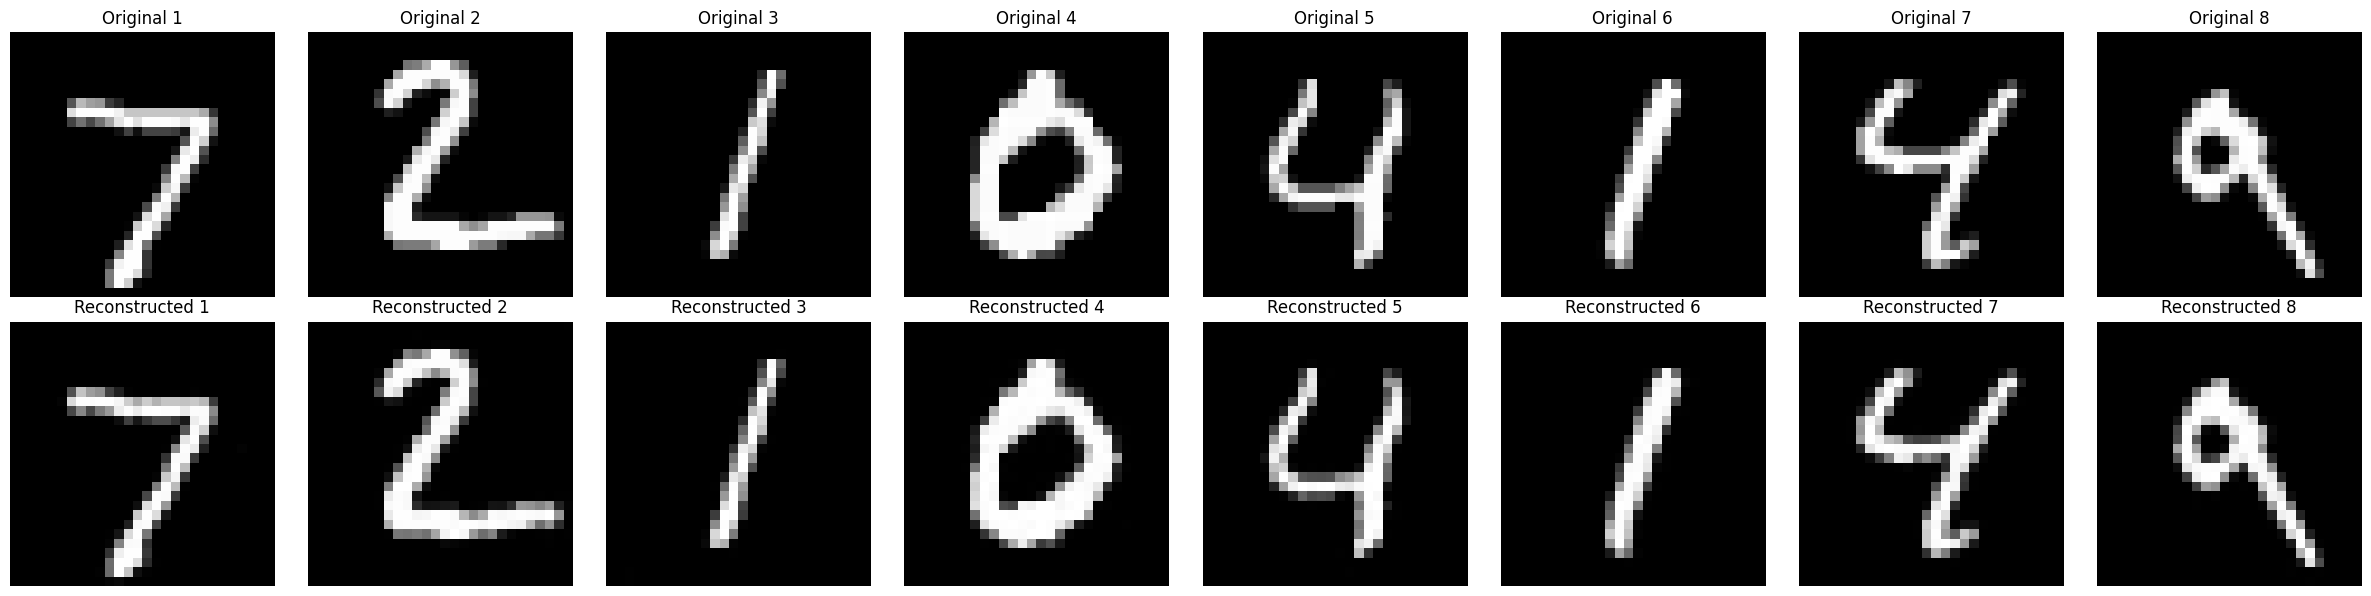

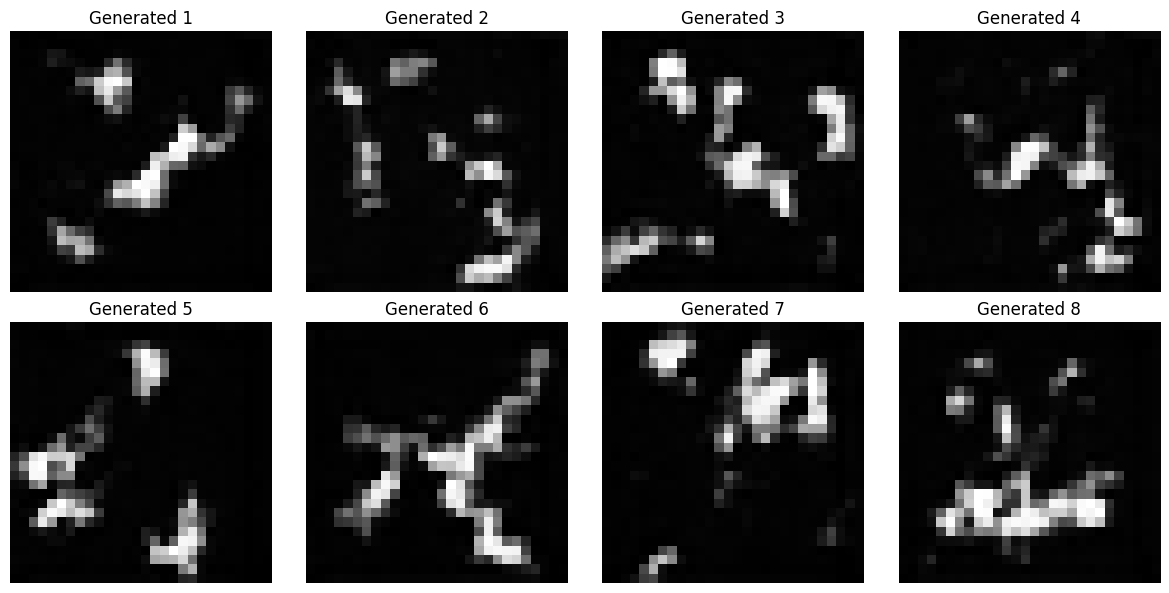


test evaluation results
  L1    : 0.010110
  MSE   : 0.000692
  LPIPS : 0.001391
  PSNR  : 37.7505 dB
  SSIM  : 0.996723
  FID   : 0.6339
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:03<00:00, 13.37it/s, rec=0.0440, g=0.0000, d=N/A, IWAE=1287.5896]



Epoch 1/10 [iwae]
  Train - Rec: 0.0842, Reg(iwae): 1327.8659, Disc: 0.0000
  Val   - Rec Loss: 0.0490
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0490)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:02<00:00, 13.38it/s, rec=0.0308, g=0.0000, d=N/A, IWAE=1241.1682]



Epoch 2/10 [iwae]
  Train - Rec: 0.0364, Reg(iwae): 1253.8188, Disc: 0.0000
  Val   - Rec Loss: 0.0346
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0346)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0127, Reg(iwae): 1216.4802, Disc: 1.0000
  Val   - Rec Loss: 0.0129
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0129)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:34<00:00,  8.89it/s, rec=0.0121, g=0.5502, d=1.0000, IWAE=1231.6580]



Epoch 9/10 [iwae]
  Train - Rec: 0.0113, Reg(iwae): 1218.4467, Disc: 1.0000
  Val   - Rec Loss: 0.0113
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0113)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:29<00:00,  9.41it/s, rec=0.0101, g=0.6479, d=0.9987, IWAE=1223.0605] 



Epoch 10/10 [iwae]
  Train - Rec: 0.0104, Reg(iwae): 1219.5296, Disc: 0.9994
  Val   - Rec Loss: 0.0105
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0105)

[iwae] 训练完成! 最佳验证损失: 0.0105


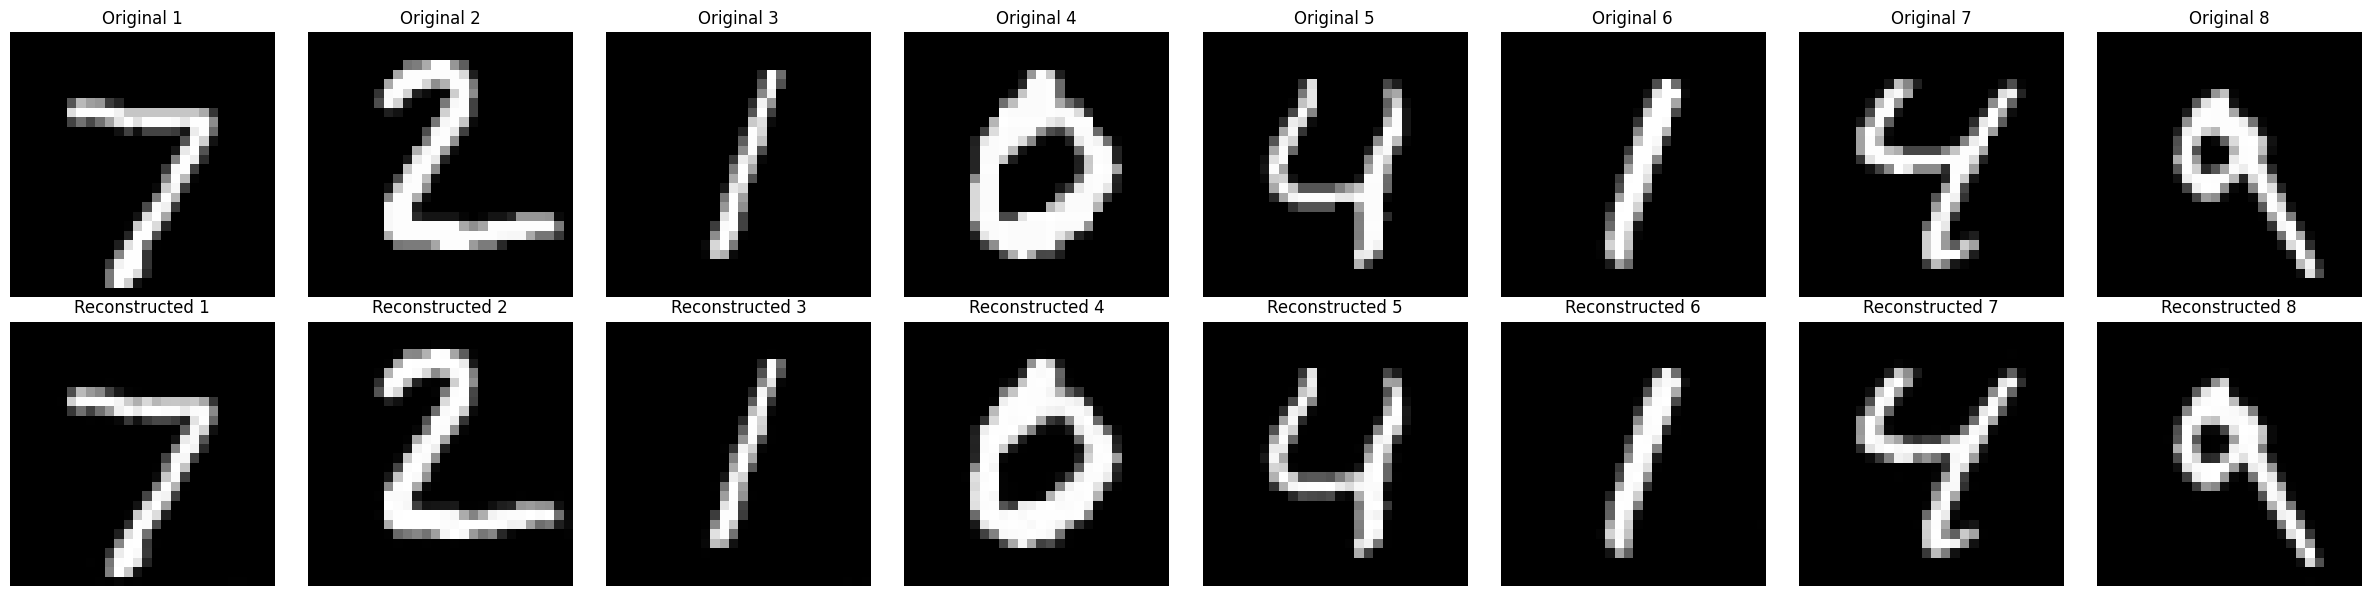

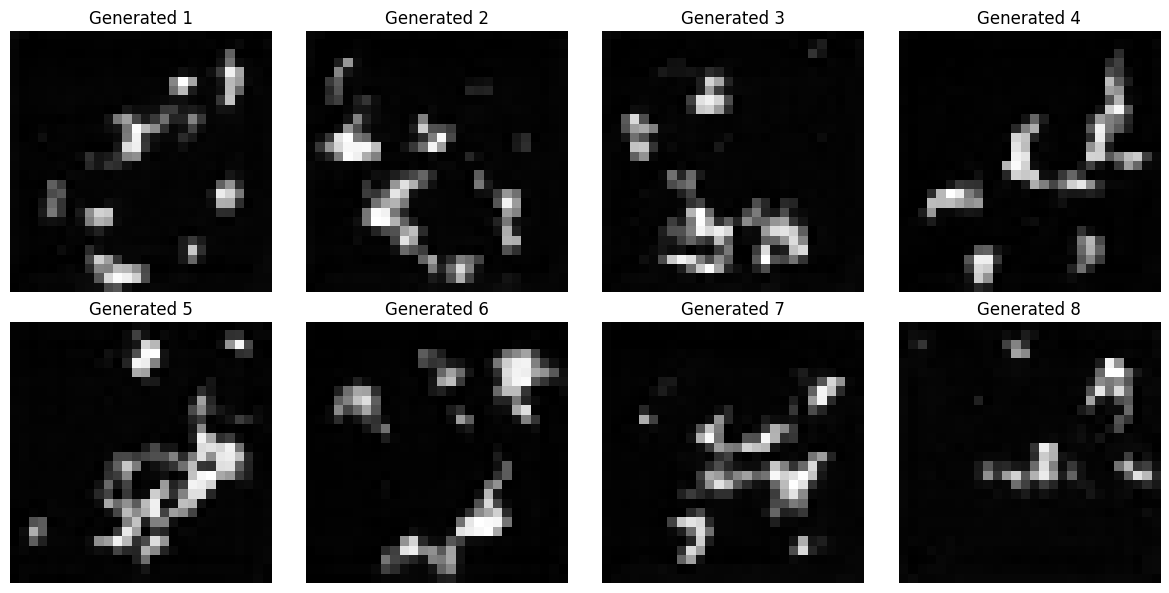


test evaluation results
  L1    : 0.010063
  MSE   : 0.000686
  LPIPS : 0.001392
  PSNR  : 37.8267 dB
  SSIM  : 0.998145
  FID   : 0.5720
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on mnist
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:05<00:00, 12.83it/s, rec=0.0507, g=0.0000, d=N/A, IWAE=1447.1523]



Epoch 1/10 [iwae]
  Train - Rec: 0.0852, Reg(iwae): 1427.8988, Disc: 0.0000
  Val   - Rec Loss: 0.0472
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0472)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:09<00:00, 12.07it/s, rec=0.0313, g=0.0000, d=N/A, IWAE=1325.0747]



Epoch 2/10 [iwae]
  Train - Rec: 0.0364, Reg(iwae): 1369.2466, Disc: 0.0000
  Val   - Rec Loss: 0.0349
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0349)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0127, Reg(iwae): 1326.1676, Disc: 0.9827
  Val   - Rec Loss: 0.0128
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0128)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:33<00:00,  9.01it/s, rec=0.0116, g=-0.5351, d=0.9436, IWAE=1322.6274]



Epoch 9/10 [iwae]
  Train - Rec: 0.0115, Reg(iwae): 1330.3262, Disc: 0.9579
  Val   - Rec Loss: 0.0111
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0111)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.22it/s, rec=0.0112, g=-0.1226, d=0.9073, IWAE=1329.7522]



Epoch 10/10 [iwae]
  Train - Rec: 0.0108, Reg(iwae): 1332.3220, Disc: 0.9300
  Val   - Rec Loss: 0.0107
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0107)

[iwae] 训练完成! 最佳验证损失: 0.0107


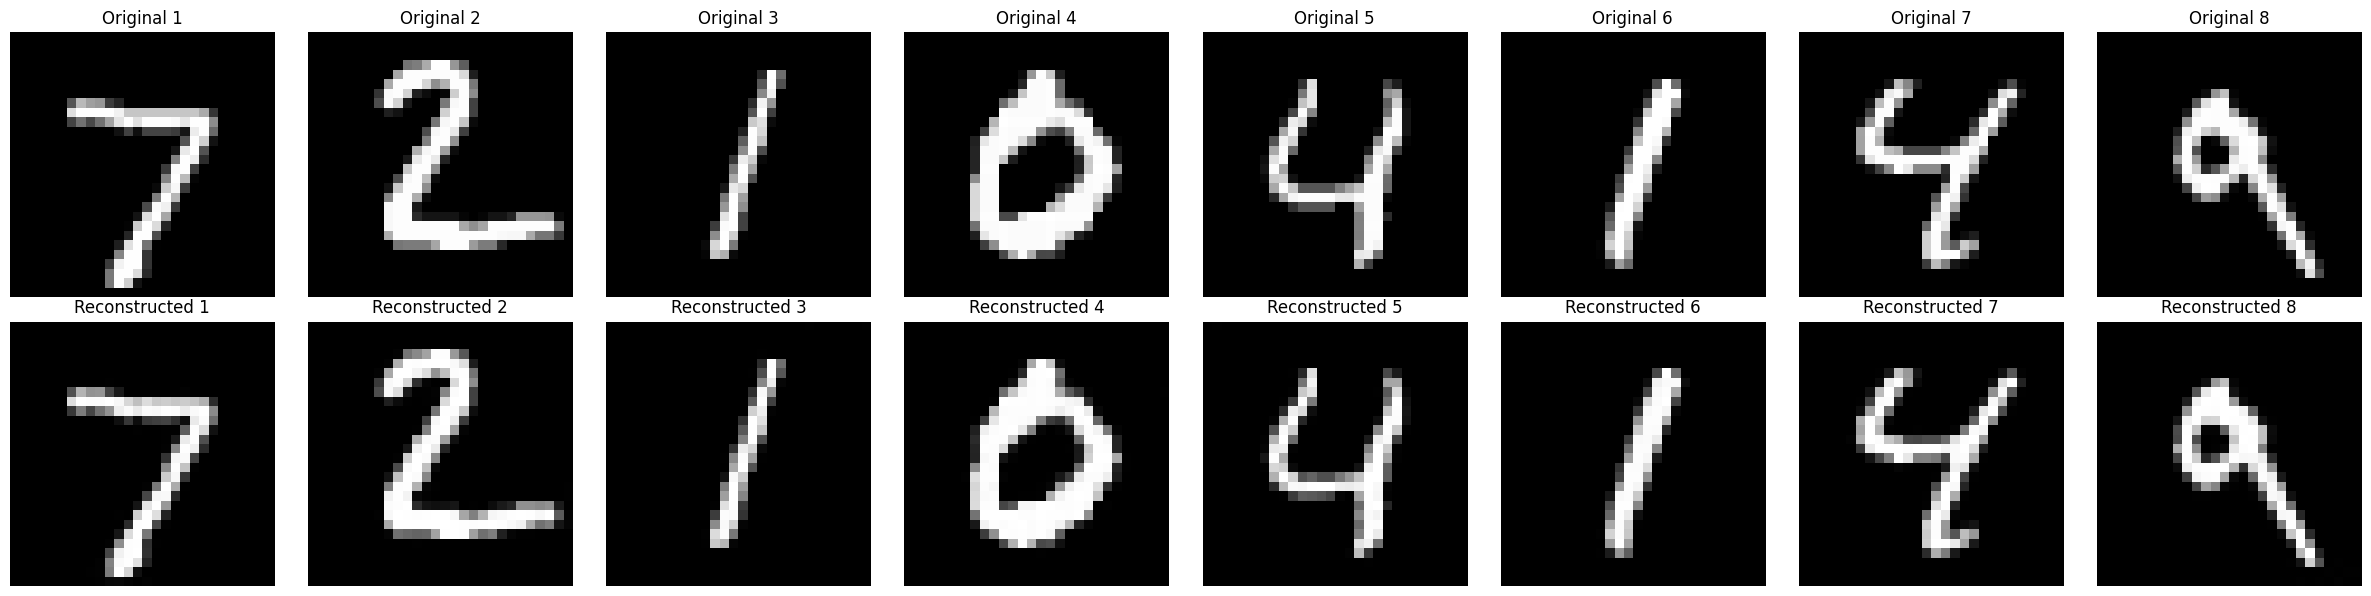

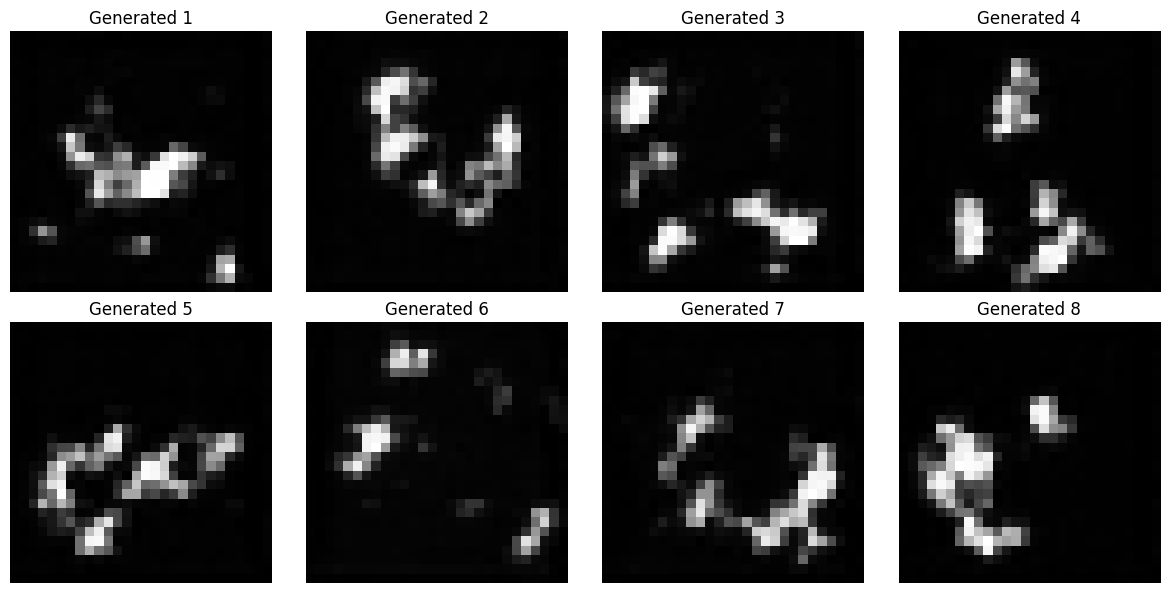


test evaluation results
  L1    : 0.010184
  MSE   : 0.000751
  LPIPS : 0.001517
  PSNR  : 37.4363 dB
  SSIM  : 0.997973
  FID   : 0.5750
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:02<00:00, 13.59it/s, rec=0.0397, g=0.0000, d=N/A, IWAE=2606.0278]



Epoch 1/10 [iwae]
  Train - Rec: 0.0788, Reg(iwae): 2354.7207, Disc: 0.0000
  Val   - Rec Loss: 0.0367
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0367)


Epoch 2 [iwae]: 100%|██████████| 843/843 [00:55<00:00, 15.16it/s, rec=0.0288, g=0.0000, d=N/A, IWAE=2510.2666]



Epoch 2/10 [iwae]
  Train - Rec: 0.0311, Reg(iwae): 2529.9757, Disc: 0.0000
  Val   - Rec Loss: 0.0283
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0283)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0102, Reg(iwae): 2379.3520, Disc: 0.9669
  Val   - Rec Loss: 0.0098
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0098)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.18it/s, rec=0.0083, g=-0.8496, d=0.9603, IWAE=2340.8408]



Epoch 9/10 [iwae]
  Train - Rec: 0.0091, Reg(iwae): 2378.2165, Disc: 0.9354
  Val   - Rec Loss: 0.0089
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0089)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:26<00:00,  9.75it/s, rec=0.0082, g=-0.5757, d=0.8692, IWAE=2378.9148]



Epoch 10/10 [iwae]
  Train - Rec: 0.0084, Reg(iwae): 2370.8959, Disc: 0.9093
  Val   - Rec Loss: 0.0082
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0082)

[iwae] 训练完成! 最佳验证损失: 0.0082


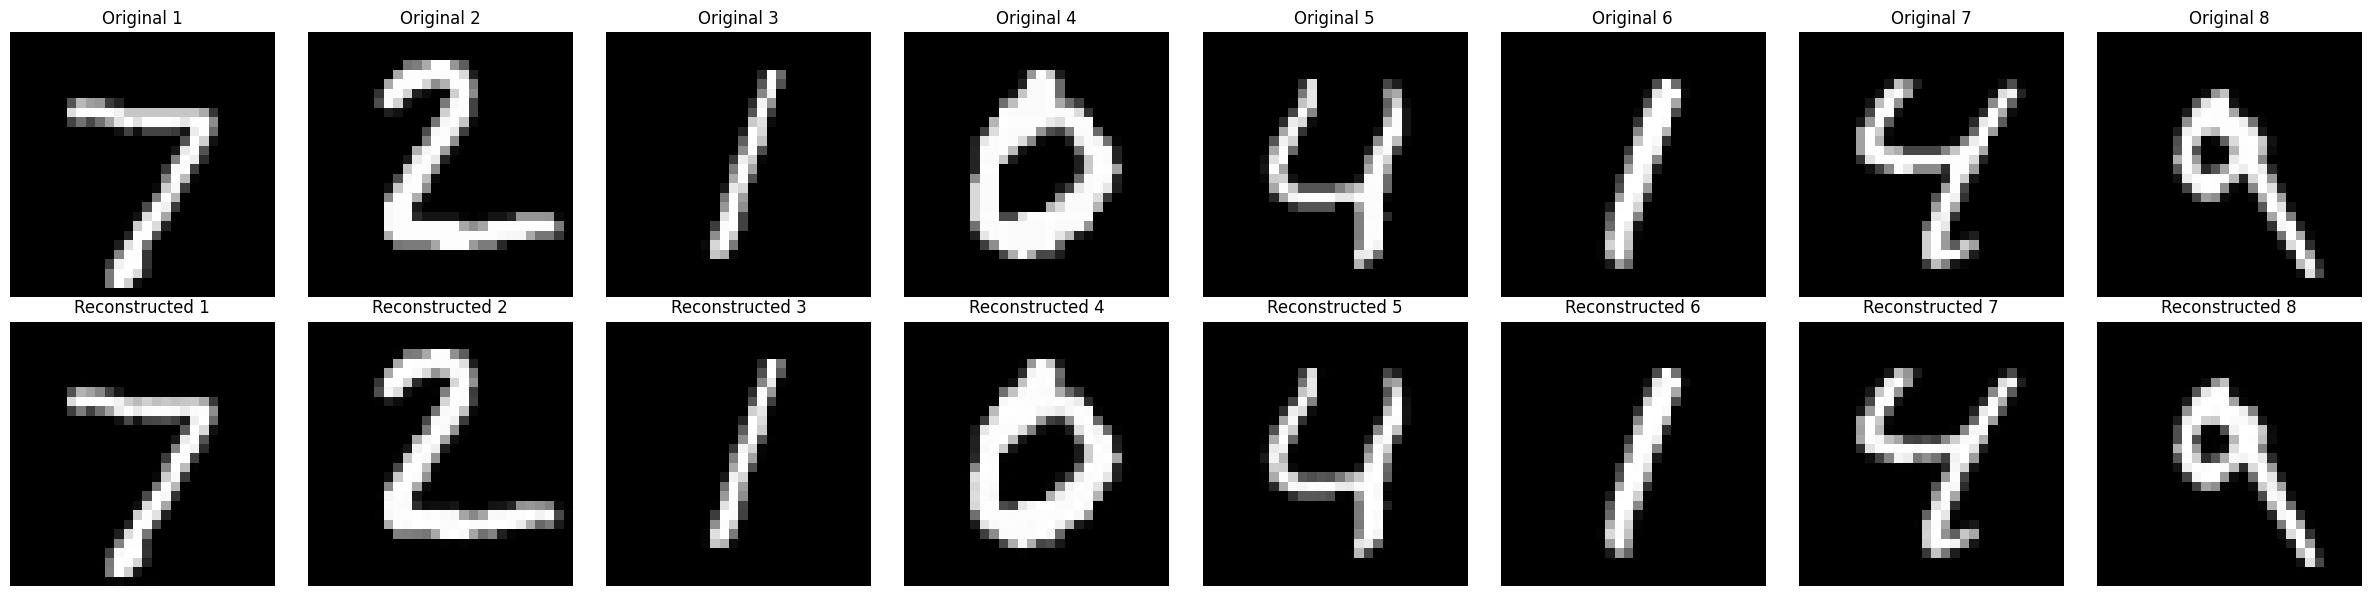

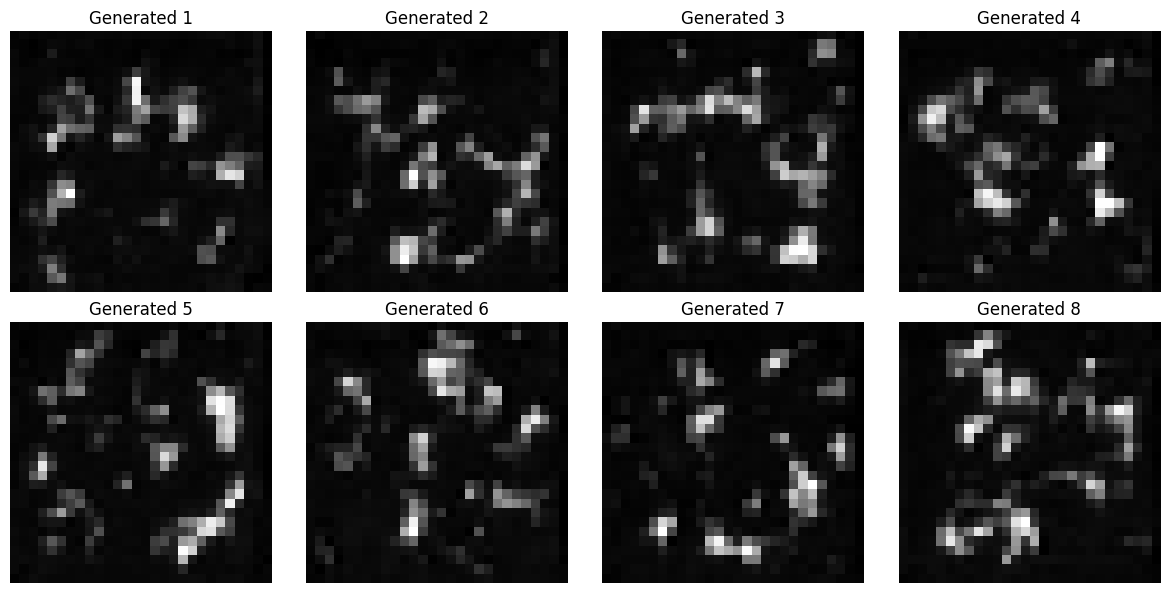


test evaluation results
  L1    : 0.007878
  MSE   : 0.000434
  LPIPS : 0.000911
  PSNR  : 39.8518 dB
  SSIM  : 0.998219
  FID   : 0.4573
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:04<00:00, 12.98it/s, rec=0.0429, g=0.0000, d=N/A, IWAE=2527.0017]



Epoch 1/10 [iwae]
  Train - Rec: 0.0806, Reg(iwae): 2438.1980, Disc: 0.0000
  Val   - Rec Loss: 0.0463
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0463)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:09<00:00, 12.07it/s, rec=0.0348, g=0.0000, d=N/A, IWAE=2353.8799]



Epoch 2/10 [iwae]
  Train - Rec: 0.0326, Reg(iwae): 2429.9180, Disc: 0.0000
  Val   - Rec Loss: 0.0240
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0240)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0097, Reg(iwae): 2248.1252, Disc: 1.0000
  Val   - Rec Loss: 0.0094
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0094)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.22it/s, rec=0.0081, g=0.0687, d=1.0000, IWAE=2292.3887]



Epoch 9/10 [iwae]
  Train - Rec: 0.0082, Reg(iwae): 2268.1815, Disc: 1.0000
  Val   - Rec Loss: 0.0075
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0075)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:28<00:00,  9.57it/s, rec=0.0068, g=0.0698, d=1.0000, IWAE=2279.5347] 



Epoch 10/10 [iwae]
  Train - Rec: 0.0074, Reg(iwae): 2286.8246, Disc: 1.0000
  Val   - Rec Loss: 0.0072
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0072)

[iwae] 训练完成! 最佳验证损失: 0.0072


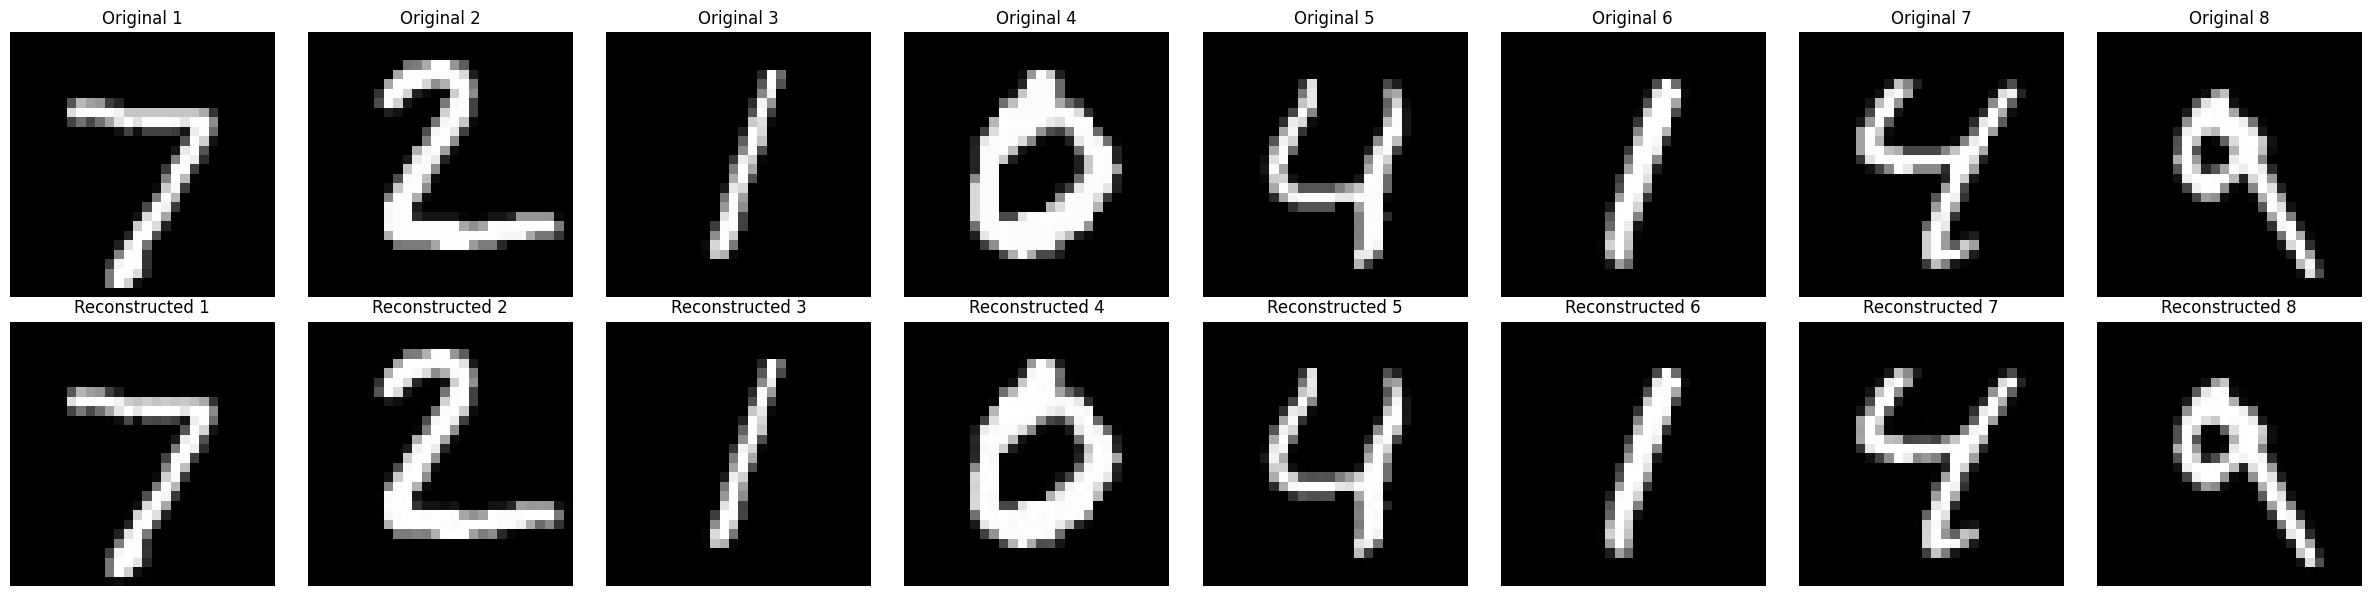

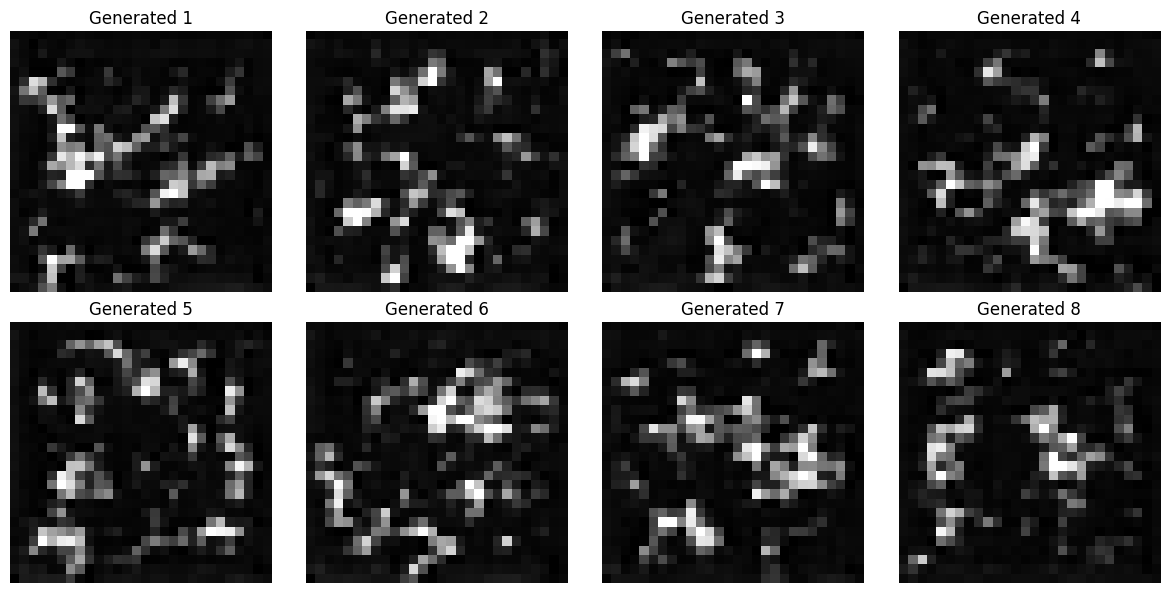


test evaluation results
  L1    : 0.007002
  MSE   : 0.000287
  LPIPS : 0.000626
  PSNR  : 41.8032 dB
  SSIM  : 0.999179
  FID   : 0.3364
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [00:56<00:00, 14.86it/s, rec=0.0420, g=0.0000, d=N/A, IWAE=1915.3357]



Epoch 1/10 [iwae]
  Train - Rec: 0.0846, Reg(iwae): 1772.9473, Disc: 0.0000
  Val   - Rec Loss: 0.0532
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0532)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:07<00:00, 12.50it/s, rec=0.0257, g=0.0000, d=N/A, IWAE=1899.5699]



Epoch 2/10 [iwae]
  Train - Rec: 0.0350, Reg(iwae): 1891.9096, Disc: 0.0000
  Val   - Rec Loss: 0.0303
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0303)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0109, Reg(iwae): 1940.3266, Disc: 1.0000
  Val   - Rec Loss: 0.0109
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0109)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:32<00:00,  9.15it/s, rec=0.0093, g=0.0766, d=1.0000, IWAE=1915.8958] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0096, Reg(iwae): 1929.0912, Disc: 1.0000
  Val   - Rec Loss: 0.0094
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0094)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:30<00:00,  9.28it/s, rec=0.0087, g=0.0946, d=1.0000, IWAE=1926.1624]



Epoch 10/10 [iwae]
  Train - Rec: 0.0088, Reg(iwae): 1919.4632, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0088)

[iwae] 训练完成! 最佳验证损失: 0.0088


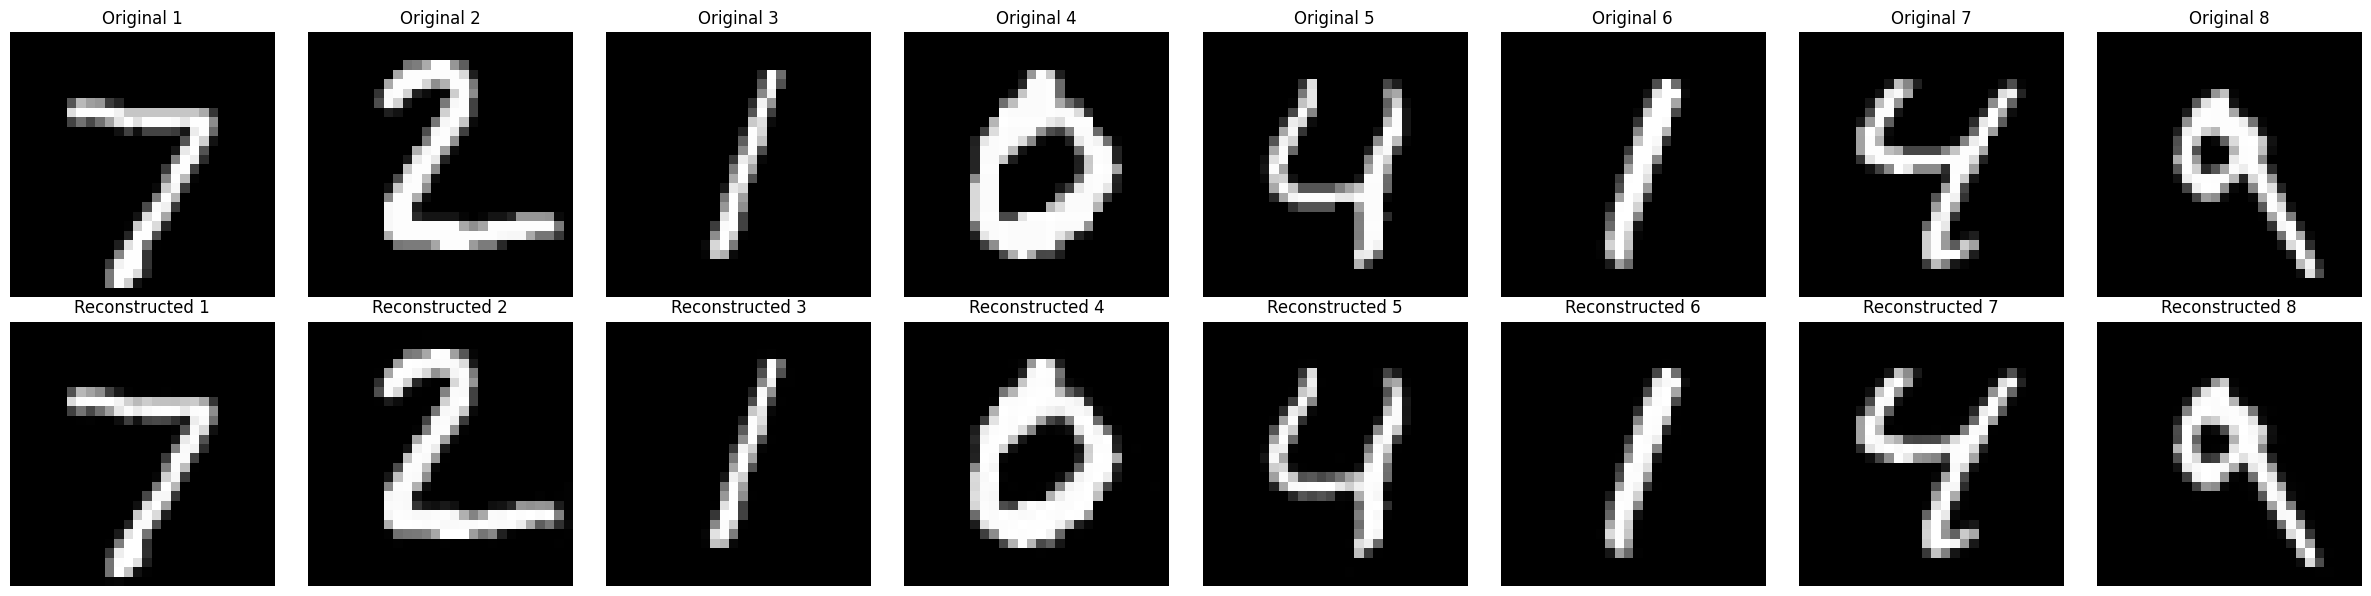

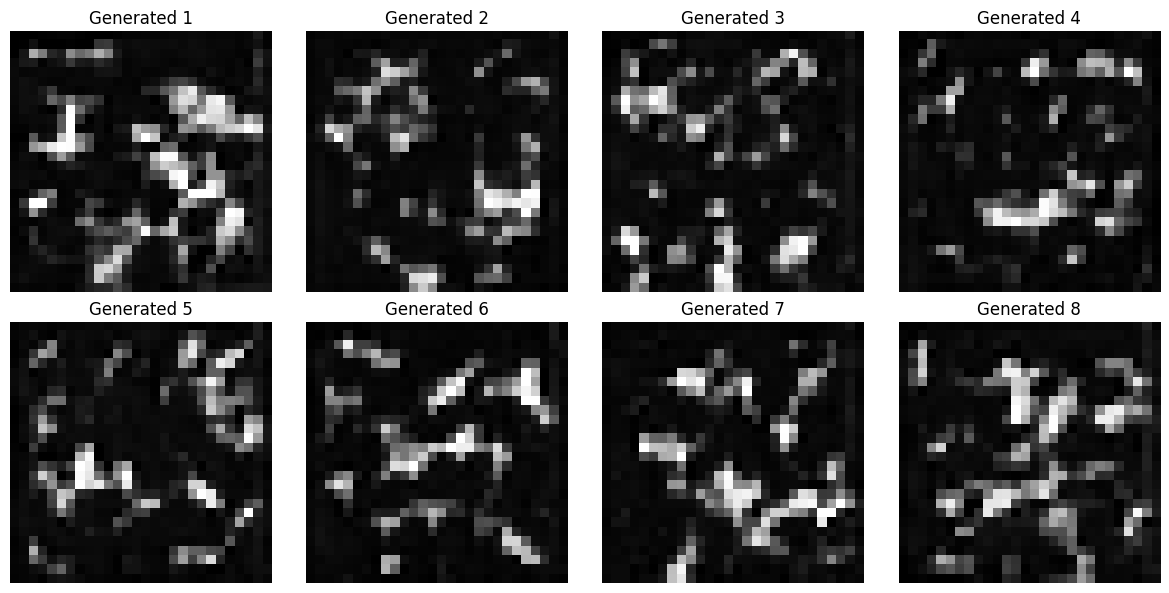


test evaluation results
  L1    : 0.008484
  MSE   : 0.000488
  LPIPS : 0.001021
  PSNR  : 39.3434 dB
  SSIM  : 0.998077
  FID   : 0.4511
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:07<00:00, 12.50it/s, rec=0.0375, g=0.0000, d=N/A, IWAE=2524.1875]



Epoch 1/10 [iwae]
  Train - Rec: 0.0803, Reg(iwae): 2306.2536, Disc: 0.0000
  Val   - Rec Loss: 0.0408
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0408)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:06<00:00, 12.60it/s, rec=0.0283, g=0.0000, d=N/A, IWAE=2521.2319]



Epoch 2/10 [iwae]
  Train - Rec: 0.0321, Reg(iwae): 2505.8858, Disc: 0.0000
  Val   - Rec Loss: 0.0273
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0273)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0091, Reg(iwae): 2500.6406, Disc: 1.0000
  Val   - Rec Loss: 0.0088
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0088)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.18it/s, rec=0.0077, g=-0.0112, d=1.0000, IWAE=2543.6506]



Epoch 9/10 [iwae]
  Train - Rec: 0.0079, Reg(iwae): 2521.6183, Disc: 1.0000
  Val   - Rec Loss: 0.0081
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0081)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.17it/s, rec=0.0072, g=0.0631, d=1.0000, IWAE=2549.1074] 



Epoch 10/10 [iwae]
  Train - Rec: 0.0071, Reg(iwae): 2536.5666, Disc: 1.0000
  Val   - Rec Loss: 0.0070
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0070)

[iwae] 训练完成! 最佳验证损失: 0.0070


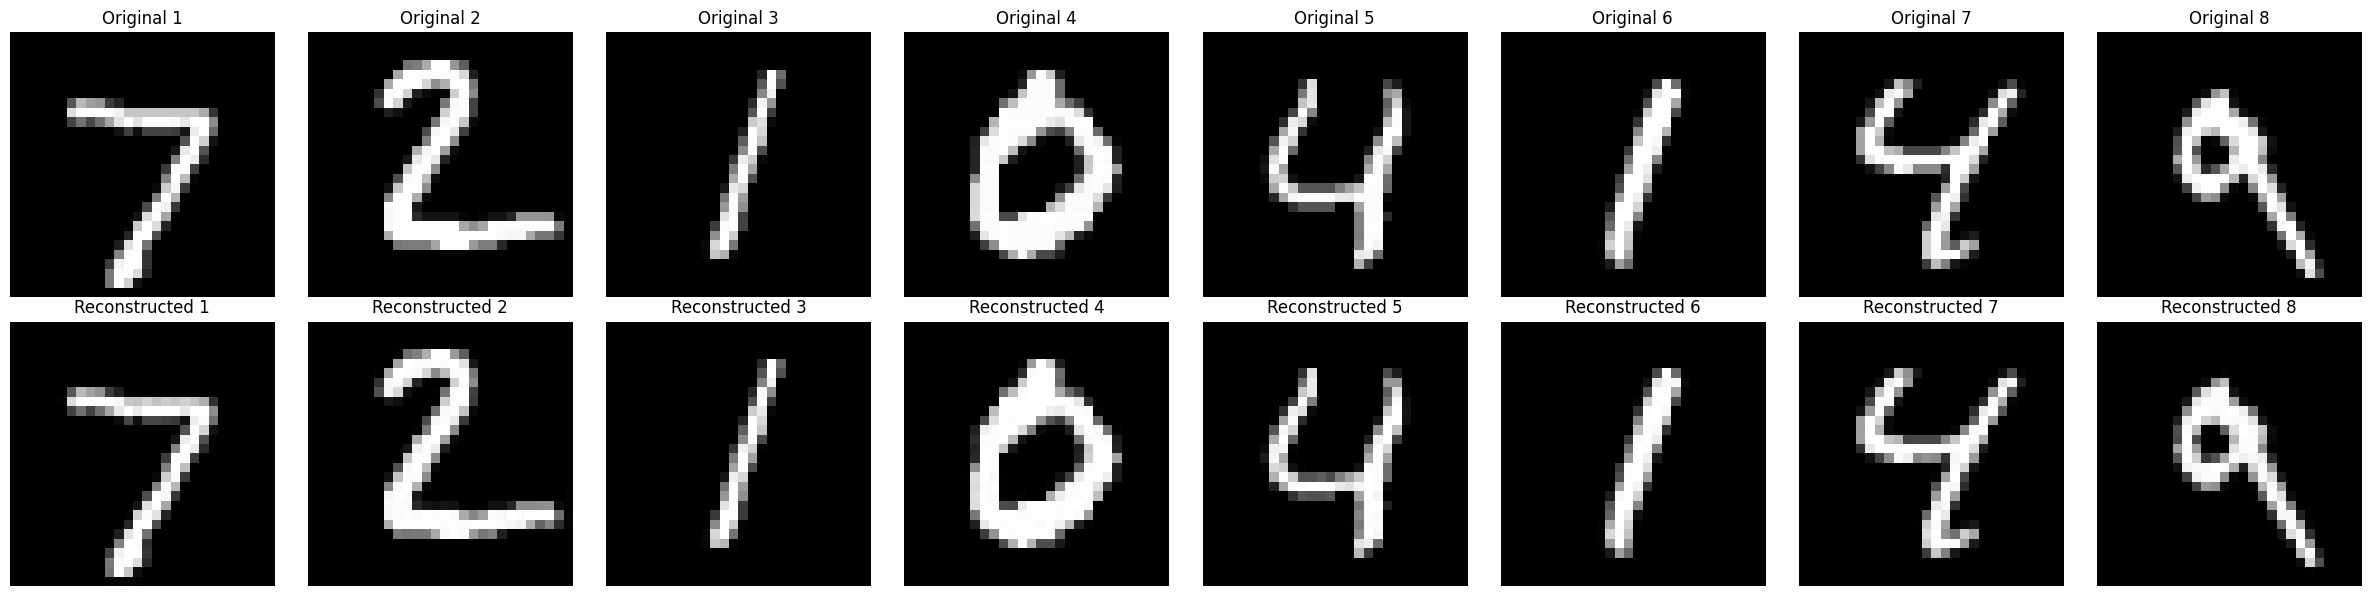

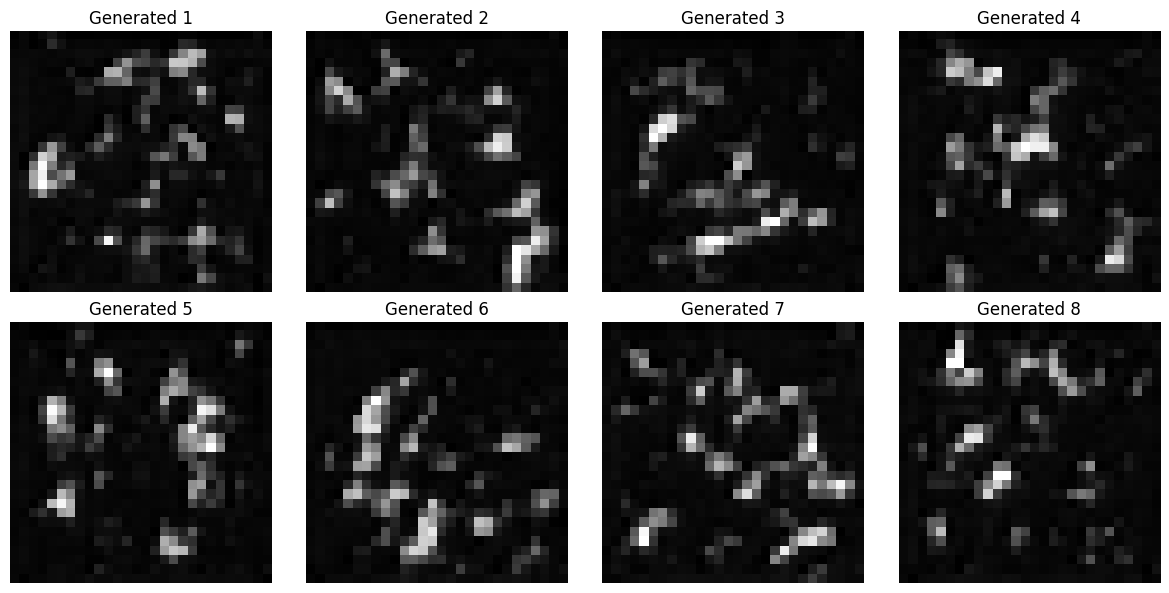


test evaluation results
  L1    : 0.006786
  MSE   : 0.000263
  LPIPS : 0.000587
  PSNR  : 42.1599 dB
  SSIM  : 0.999272
  FID   : 0.3032
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:04<00:00, 12.97it/s, rec=0.0491, g=0.0000, d=N/A, IWAE=2204.1577]



Epoch 1/10 [iwae]
  Train - Rec: 0.0835, Reg(iwae): 2120.8292, Disc: 0.0000
  Val   - Rec Loss: 0.0422
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0422)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:04<00:00, 13.11it/s, rec=0.0348, g=0.0000, d=N/A, IWAE=2210.0933]



Epoch 2/10 [iwae]
  Train - Rec: 0.0340, Reg(iwae): 2191.7188, Disc: 0.0000
  Val   - Rec Loss: 0.0293
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0293)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0098, Reg(iwae): 2199.7676, Disc: 1.0000
  Val   - Rec Loss: 0.0096
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0096)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:30<00:00,  9.34it/s, rec=0.0082, g=-0.0059, d=1.0000, IWAE=2183.1914]



Epoch 9/10 [iwae]
  Train - Rec: 0.0084, Reg(iwae): 2215.1804, Disc: 1.0000
  Val   - Rec Loss: 0.0080
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0080)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:32<00:00,  9.08it/s, rec=0.0075, g=-0.0214, d=1.0000, IWAE=2218.9797]



Epoch 10/10 [iwae]
  Train - Rec: 0.0075, Reg(iwae): 2226.3499, Disc: 1.0000
  Val   - Rec Loss: 0.0077
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0077)

[iwae] 训练完成! 最佳验证损失: 0.0077


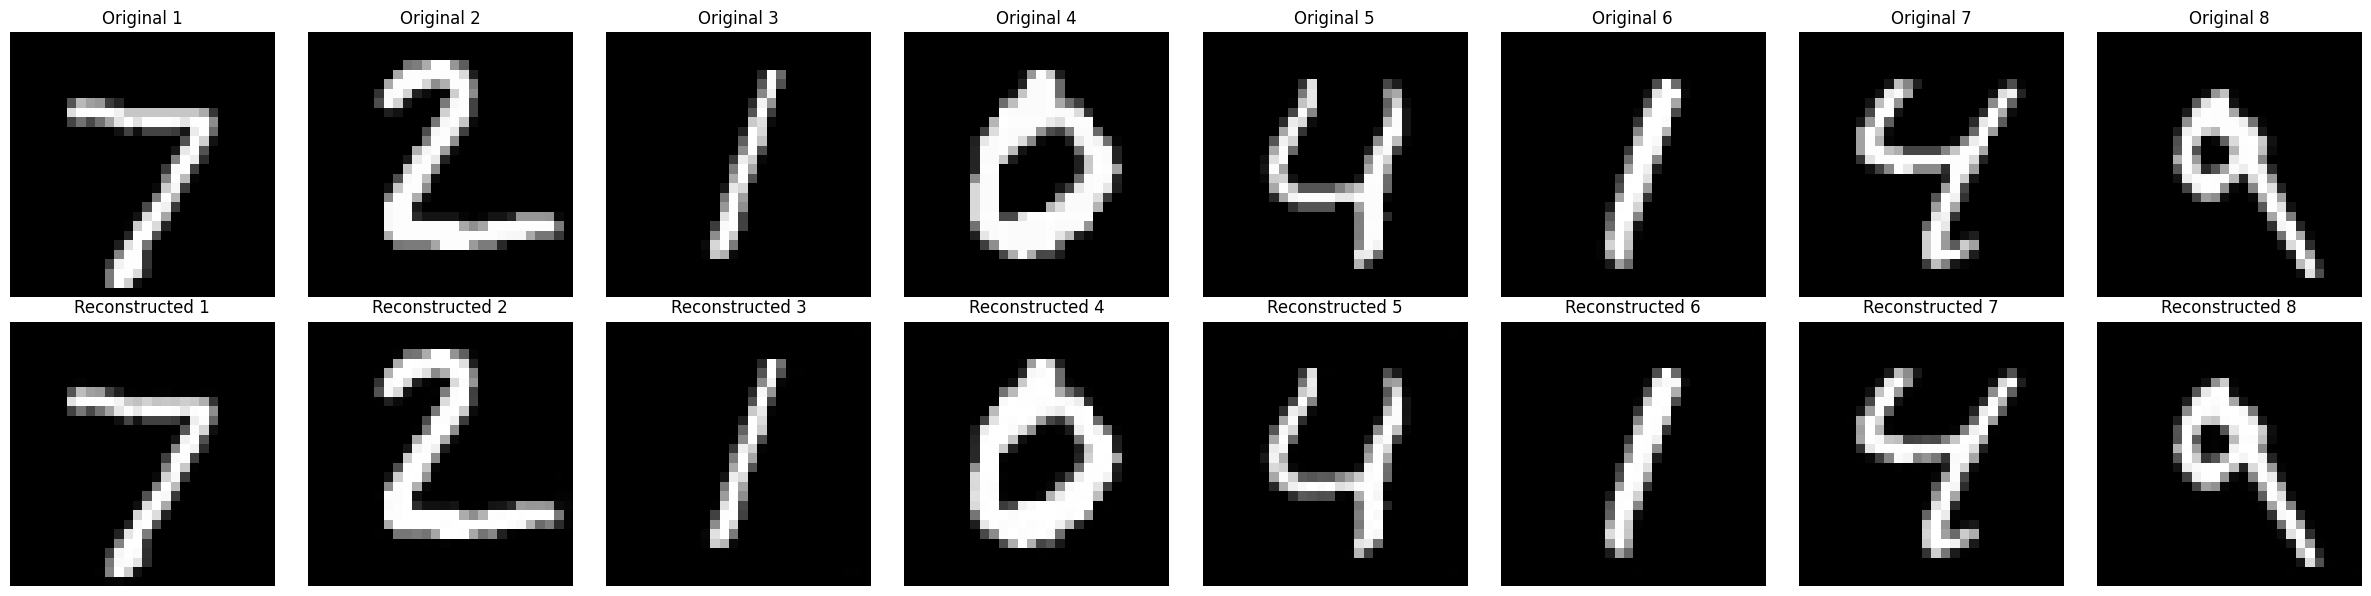

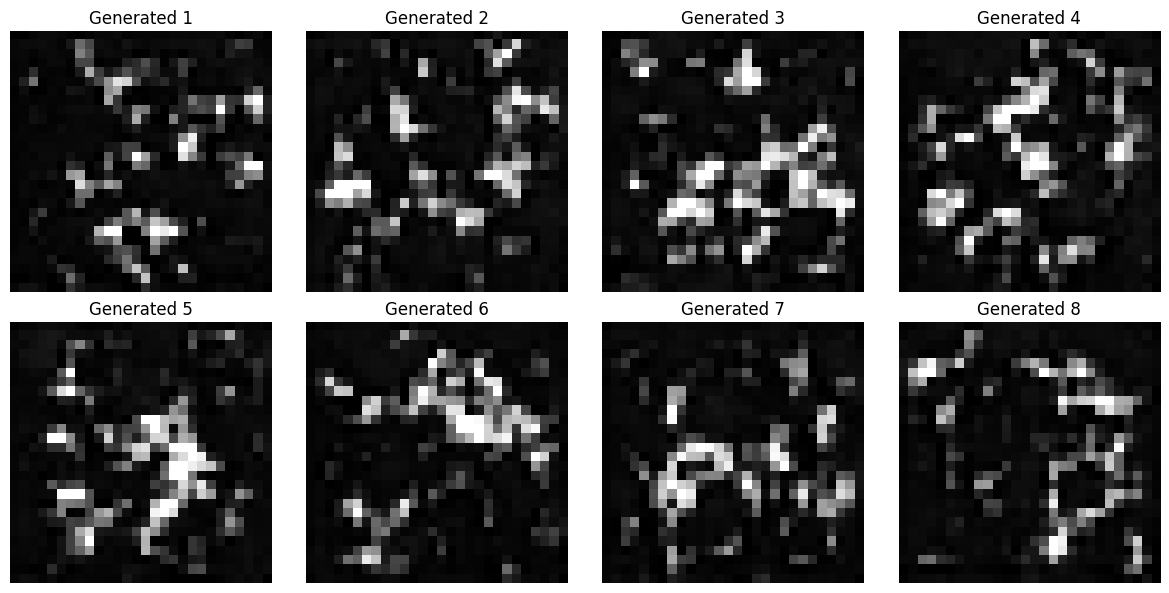


test evaluation results
  L1    : 0.007431
  MSE   : 0.000333
  LPIPS : 0.000691
  PSNR  : 41.1601 dB
  SSIM  : 0.999125
  FID   : 0.3102
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:06<00:00, 12.75it/s, rec=0.0386, g=0.0000, d=N/A, IWAE=2240.5342]



Epoch 1/10 [iwae]
  Train - Rec: 0.0881, Reg(iwae): 2052.5419, Disc: 0.0000
  Val   - Rec Loss: 0.0331
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0331)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:04<00:00, 13.04it/s, rec=0.0266, g=0.0000, d=N/A, IWAE=2196.2380]



Epoch 2/10 [iwae]
  Train - Rec: 0.0328, Reg(iwae): 2237.5940, Disc: 0.0000
  Val   - Rec Loss: 0.0248
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0248)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0108, Reg(iwae): 2175.9787, Disc: 1.0000
  Val   - Rec Loss: 0.0103
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0103)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.17it/s, rec=0.0092, g=0.1268, d=1.0000, IWAE=2139.8730] 



Epoch 9/10 [iwae]
  Train - Rec: 0.0096, Reg(iwae): 2179.3762, Disc: 1.0000
  Val   - Rec Loss: 0.0093
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0093)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:25<00:00,  9.89it/s, rec=0.0090, g=0.1895, d=1.0000, IWAE=2198.4336]



Epoch 10/10 [iwae]
  Train - Rec: 0.0088, Reg(iwae): 2183.9841, Disc: 1.0000
  Val   - Rec Loss: 0.0090
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0090)

[iwae] 训练完成! 最佳验证损失: 0.0090


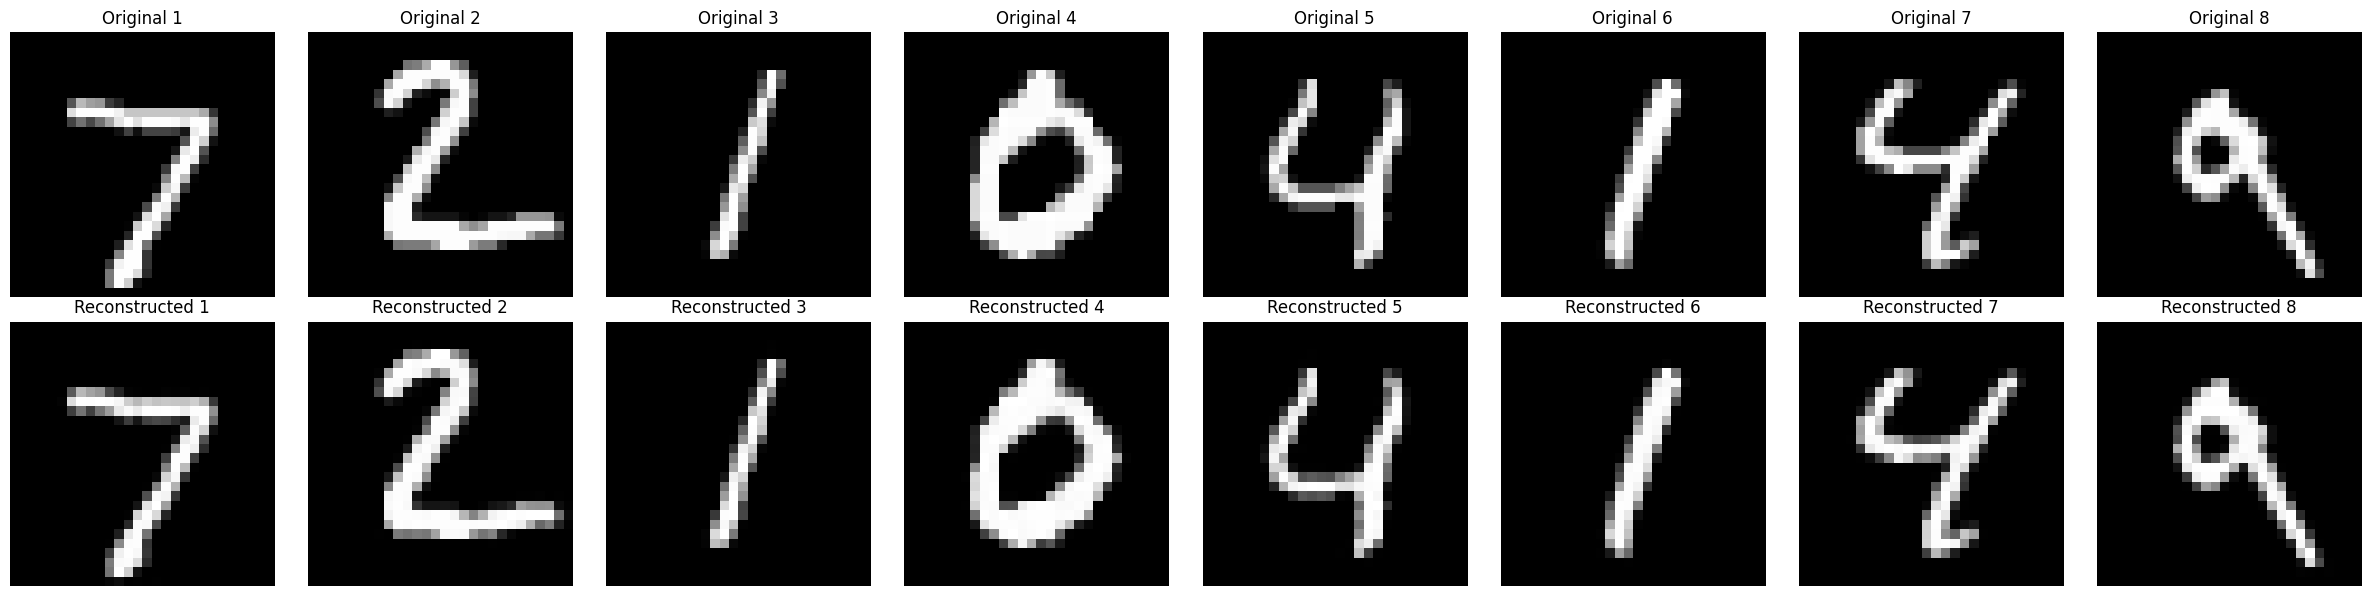

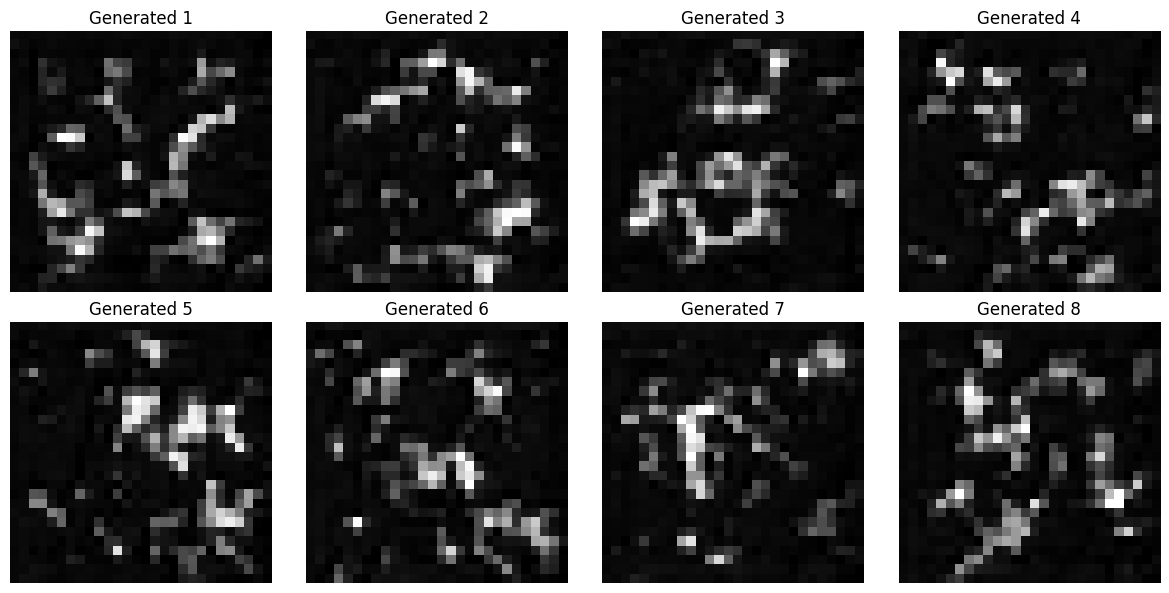


test evaluation results
  L1    : 0.008675
  MSE   : 0.000476
  LPIPS : 0.001006
  PSNR  : 39.4707 dB
  SSIM  : 0.998787
  FID   : 0.4418
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-06) on mnist
损失函数: L_rec + 1e-06*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 2.88e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 843/843 [01:03<00:00, 13.35it/s, rec=0.0397, g=0.0000, d=N/A, IWAE=2400.9497]



Epoch 1/10 [iwae]
  Train - Rec: 0.0803, Reg(iwae): 2190.0398, Disc: 0.0000
  Val   - Rec Loss: 0.0359
  AE LR: 2.82e-04
  Global Step: 843
  ✓ 保存最佳模型 (val_loss: 0.0359)


Epoch 2 [iwae]: 100%|██████████| 843/843 [01:04<00:00, 13.02it/s, rec=0.0271, g=0.0000, d=N/A, IWAE=2378.4851]



Epoch 2/10 [iwae]
  Train - Rec: 0.0321, Reg(iwae): 2401.6596, Disc: 0.0000
  Val   - Rec Loss: 0.0275
  AE LR: 2.63e-04
  Global Step: 1686
  ✓ 保存最佳模型 (val_loss: 0.0275)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0107, Reg(iwae): 2190.2640, Disc: 1.0000
  Val   - Rec Loss: 0.0106
  AE LR: 5.36e-05
  Global Step: 6744
  ✓ 保存最佳模型 (val_loss: 0.0106)


Epoch 9 [iwae]: 100%|██████████| 843/843 [01:30<00:00,  9.35it/s, rec=0.0096, g=0.0922, d=1.0000, IWAE=2194.5503]



Epoch 9/10 [iwae]
  Train - Rec: 0.0095, Reg(iwae): 2193.1202, Disc: 1.0000
  Val   - Rec Loss: 0.0095
  AE LR: 3.51e-05
  Global Step: 7587
  ✓ 保存最佳模型 (val_loss: 0.0095)


Epoch 10 [iwae]: 100%|██████████| 843/843 [01:31<00:00,  9.23it/s, rec=0.0089, g=0.0859, d=1.0000, IWAE=2242.8677]



Epoch 10/10 [iwae]
  Train - Rec: 0.0087, Reg(iwae): 2197.5171, Disc: 1.0000
  Val   - Rec Loss: 0.0084
  AE LR: 2.88e-05
  Global Step: 8430
  ✓ 保存最佳模型 (val_loss: 0.0084)

[iwae] 训练完成! 最佳验证损失: 0.0084


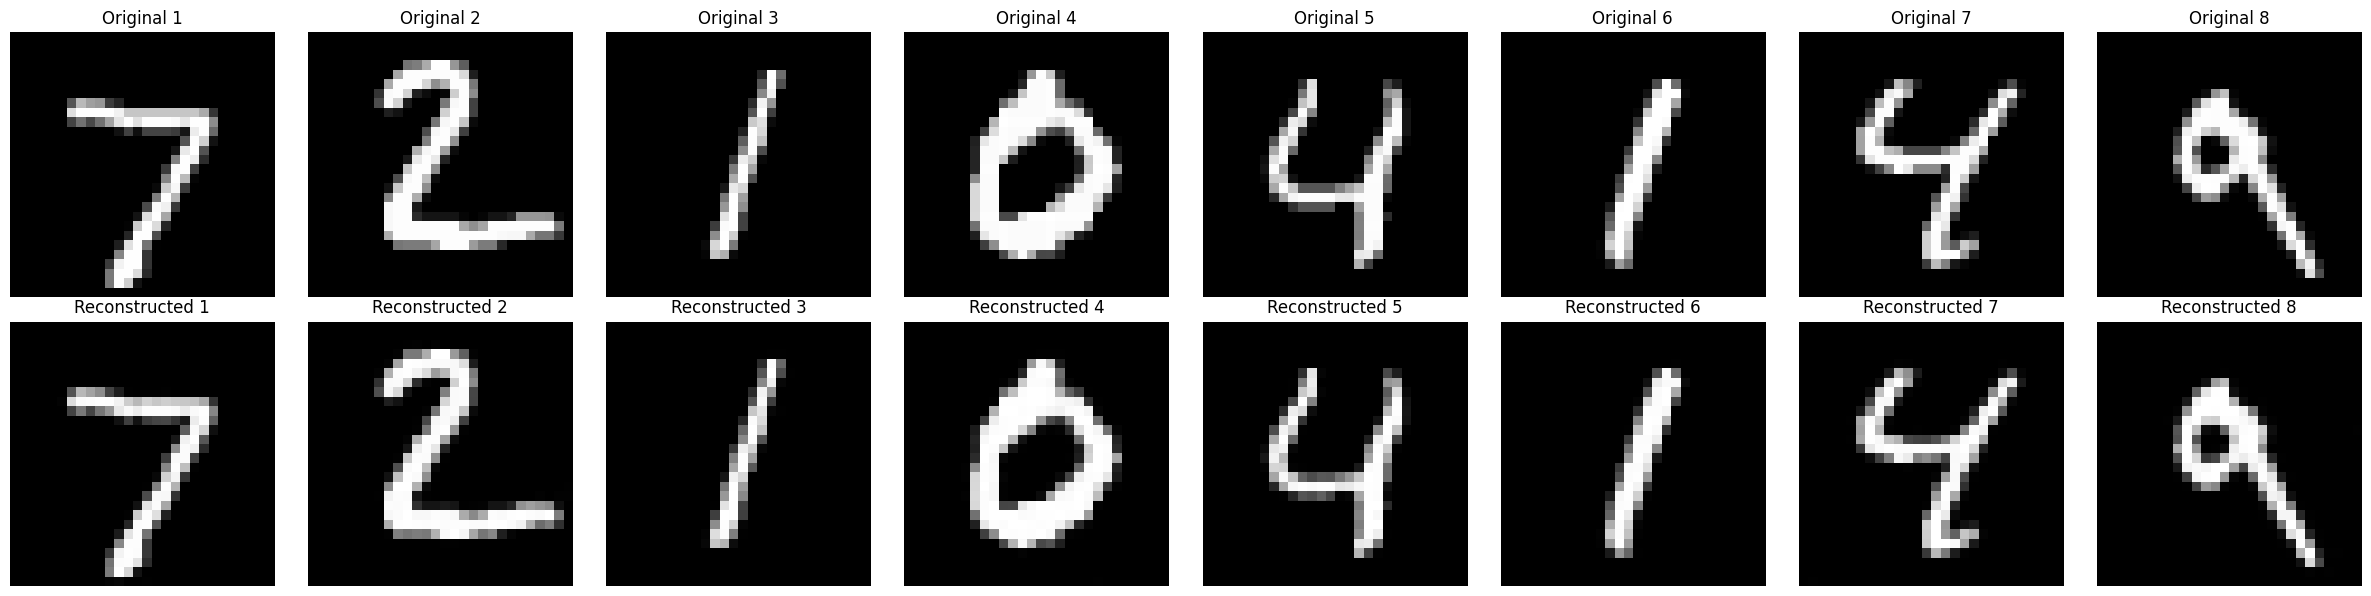

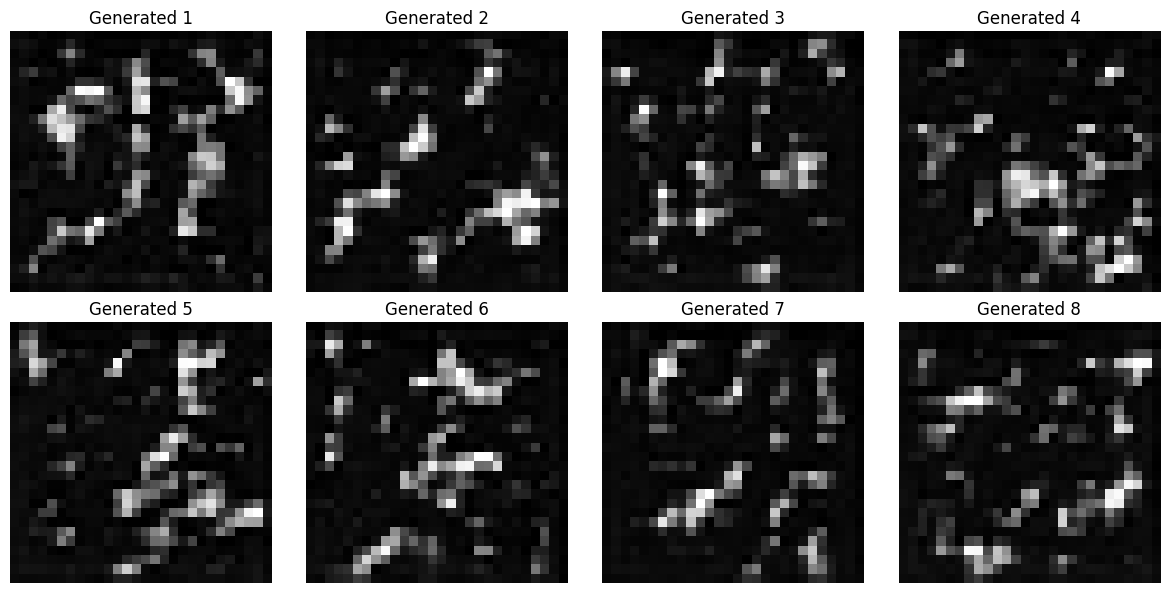


test evaluation results
  L1    : 0.008030
  MSE   : 0.000449
  LPIPS : 0.000981
  PSNR  : 39.7257 dB
  SSIM  : 0.998555
  FID   : 0.4364
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-06/eval_test_iwae_kl_1e-06.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/medvae-re-mnist.log
[iwae] 最终评估完成。


: 

In [ ]:
for w in [1e-5,1e-6]:
    for rep in range(7): 
        _ = run_training("iwae", kl_weight=w, run_tag=f"iwae_kl_{w:.0e}")


## eof